# Post-Selection Inference for Top-K Selection

Clean, refactored implementation comparing five methods
(Standard / Randomized PSI / Polyhedral PSI / Data Splitting / Zoom Correction)
across three data-generating processes (Gaussian, Binomial dosage, Bradley-Terry-Davidson).

## Structure

1. **Imports**
2. **Core CI primitives** (cdf_from_density, selective bisection)
3. **Models**: TopKSelectionModel / PolyhedralTopKInference / NaiveSubsetInference / Zoom Correction
4. **Data generators**: Gaussian / Binomial / Bradley-Terry-Davidson
5. **Unified helpers** for statistic + covariance + signal strength
6. **Simulation drivers** (per-method + orchestrators)
7. **Plotting utilities**
8. **SI=0 fix and fast CI install**
9. **Final simulations** — one cell each for Gaussian / Binomial / BT-Davidson, each producing a 3-panel figure: Selection Quality | Coverage Rate | CI Length.


## 1. Imports

In [1]:
# ============================================================
# Consolidated imports (single source of truth for the notebook)
# ============================================================
import ast
import time
import warnings
from dataclasses import dataclass
from functools import lru_cache
from itertools import combinations
from statistics import NormalDist
from typing import Any, Callable, Dict, Iterable, List, Literal, Optional, Tuple, Union

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from scipy.integrate import quad
from scipy.interpolate import interp1d, PchipInterpolator
from scipy.optimize import brentq, minimize
from scipy.stats import norm, multivariate_normal, kstest, t, uniform

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold

from joblib import Parallel, delayed, parallel_backend
from tqdm import tqdm
from sklearn.tree import DecisionTreeRegressor

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, SplineTransformer, PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import Nystroem
from sklearn.neural_network import MLPRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from math import comb, log
from scipy.special import expit as sigmoid
from scipy.special import ndtr, log_ndtr
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from scipy.optimize import minimize



# np.trapz fires a DeprecationWarning under NumPy >= 2.0; the engine
# still uses it heavily, so silence just that message.
warnings.filterwarnings("ignore", message=".*trapz.*", category=DeprecationWarning)
warnings.filterwarnings("ignore", message=".*simps.*", category=DeprecationWarning)


## 2. Core CI primitives

### 2.1 `selective_confidence_interval_bisect_single_safe`

In [2]:
def selective_confidence_interval_bisect_single_safe(
    model,
    target_idx,          
    S_obs,
    u_obs,
    v_obs,              
    u_star,           
    alpha=0.05,
    search_scale=13.0,  
    init_points=13,      
    max_expand=8,        
    expand_mult=2.0,
    tol=1e-6,
    max_iter=120,
    seed=None
):
    rng = np.random.default_rng(seed)
    target_idx = int(np.atleast_1d(target_idx)[0])
    mu0   = float(model.true_mu[target_idx])
    sigma = float(np.sqrt(model.true_Sigma[target_idx, target_idx]))

    @lru_cache(maxsize=None)
    def F_at_theta(theta):
        mu_new = model.true_mu.astype(float).copy()
        mu_new[target_idx] = float(theta)
        dens_dict = model.conditional_density_grid(
            u=u_obs,
            v=v_obs,
            S=S_obs,
            grid_size=model.grid_size,
            true_mu=mu_new,
            true_sigma=model.true_Sigma
        )
        matched = None
        for info in dens_dict.values():
            if int(info["var_index"]) == target_idx:
                matched = info
                break
        if matched is None:
            return np.nan

        grid = np.asarray(matched["grid"], dtype=float)
        dens = np.asarray(matched["density"], dtype=float)

        dens = np.maximum(dens, 0.0)
        Z = np.trapz(dens, grid)
        if not np.isfinite(Z) or Z <= 1e-12:
            dx = np.diff(grid)
            if dx.size and np.allclose(dx, dx[0]):
                Z = dens.sum() * (grid[1] - grid[0])
            if not np.isfinite(Z) or Z <= 1e-12:
                return np.nan
        dens = dens / Z
        F_vals = np.concatenate([[0.0], np.cumsum(0.5*(dens[1:]+dens[:-1])*np.diff(grid))])
        F_vals = F_vals / F_vals[-1]
        if u_star <= grid[0]:
            return 0.0
        if u_star >= grid[-1]:
            return 1.0
        i = np.searchsorted(grid, u_star) - 1
        t = (u_star - grid[i]) / (grid[i+1] - grid[i])
        val = (1-t)*F_vals[i] + t*F_vals[i+1]
        return float(np.clip(val, 0.0, 1.0))

    lo0, hi0 = mu0 - search_scale*sigma, mu0 + search_scale*sigma
    k_in = max(0, int(init_points) - 2)
    if k_in > 0:
        inner = np.linspace(lo0, hi0, k_in)
        theta_grid = np.sort(np.unique(np.concatenate(([lo0, hi0], inner))))
    else:
        theta_grid = np.array([lo0, hi0], dtype=float)

    F_vals = np.array([F_at_theta(th) for th in theta_grid], dtype=float)
    if np.all(np.isnan(F_vals)):
        return (None, None)

    finite_mask = np.isfinite(F_vals)
    if finite_mask.sum() >= 2:
        F_start = F_vals[finite_mask][0]
        F_end   = F_vals[finite_mask][-1]
        increasing = (F_end >= F_start)
    else:
        increasing = True

    tL = (1 - alpha/2) if increasing else (alpha/2)
    tU = (alpha/2)      if increasing else (1 - alpha/2)
    def find_bracket(target, tg, fv):
        for i in range(len(tg) - 1):
            a, b   = tg[i], tg[i+1]
            Fa, Fb = fv[i], fv[i+1]
            if not np.isfinite(Fa) or not np.isfinite(Fb):
                continue
            if (Fa - target) * (Fb - target) < 0:
                return float(a), float(b)
        return None

    def expand_for(target):
        nonlocal theta_grid, F_vals
        for _ in range(max_expand + 1):
            br = find_bracket(target, theta_grid, F_vals)
            if br is not None:
                return br
            span = theta_grid[-1] - theta_grid[0]
            ctr  = 0.5 * (theta_grid[-1] + theta_grid[0])
            half = 0.5 * span * (expand_mult if expand_mult > 1 else 1.8)
            new_lo, new_hi = ctr - half, ctr + half

            theta_grid = np.linspace(new_lo, new_hi, max(len(theta_grid), init_points))
            F_vals = np.array([F_at_theta(th) for th in theta_grid], dtype=float)
            if np.all(np.isnan(F_vals)):
                return None
        return None

    brL = expand_for(tL)
    brU = expand_for(tU)
    def bisect_root(target, a, b):
        Fa, Fb = F_at_theta(a), F_at_theta(b)
        if (not np.isfinite(Fa)) or (not np.isfinite(Fb)) or (Fa - target) * (Fb - target) > 0:
            print("Fail to perform bisection")
            return None
        aa, bb = float(a), float(b)
        for _ in range(max_iter):
            m  = 0.5*(aa + bb)
            Fm = F_at_theta(m)
            if not np.isfinite(Fm):
                m = np.nextafter(m, bb)
                Fm = F_at_theta(m)
                if not np.isfinite(Fm):
                    return None
            if abs(Fm - target) < tol:
                return float(m)
            if (Fa - target)*(Fm - target) < 0:
                bb, Fb = m, Fm
            else:
                aa, Fa = m, Fm
        return float(0.5*(aa + bb))

    

    L = bisect_root(tL, *brL) if brL else None
    U = bisect_root(tU, *brU) if brU else None
    if (L is not None) and (U is not None) and (L > U):
        L, U = U, L
    if L is not None: L = float(np.round(L, 6))
    if U is not None: U = float(np.round(U, 6))

    
    return (L, U)


## 3. Models

### 3.1 `cdf_from_density` + `TopKSelectionModel` (Randomized PSI)

In [3]:
def cdf_from_density(grid_u, density):
    grid_u = np.asarray(grid_u, dtype=float)
    density = np.asarray(density, dtype=float)
    dx = np.diff(grid_u)
    area_segments = 0.5 * (density[:-1] + density[1:]) * dx
    cum_area = np.concatenate([[0.0], np.cumsum(area_segments)])
    total_area = cum_area[-1]+0.000000001
    if total_area <= 0:
        raise ValueError("Integral of Density is Non-positive")
    F_vals = cum_area / total_area
    cdf_spline = interp1d(grid_u, F_vals, kind="cubic",fill_value="extrapolate",bounds_error=False)
    def F(x):
        return np.clip(cdf_spline(x), 0.0, 1.0)
    return F, (grid_u, F_vals)

class TopKSelectionModel:
    def __init__(self, X: np.ndarray, k: int, H0_mu,true_Sigma,utility_fn=None,epsilon=1.,grid_size=1000, sel_scale='adaptive'):
        self.X = X
        self.M = len(X)
        self.k = k
        self.utility_fn = utility_fn or self.default_utility
        #self.utilities = self.compute_utilities()
        self.selected_indices = self.select_top_k()
        self.epsilon=epsilon
        self.true_mu=H0_mu
        self.true_Sigma=true_Sigma 
        self.grid_size=grid_size
        self.sel_scale=sel_scale  # 'adaptive' or 'none' — must match randomized_selected_top_k(scale=)

    def default_utility(self,X: np.ndarray) -> float:
        col_means = X
        return col_means


    def select_top_k(self, X=None):
        if X is None:
            X = self.X
        X = np.asarray(X, dtype=float).reshape(-1)   # (p,)
    
        utilities = self.utility_fn(X)               # should return (p,)
        utilities = np.asarray(utilities, dtype=float).reshape(-1)
    
        return np.argsort(utilities)[-self.k:][::-1]

    def top_k_additive_utility(self,S,X=None):
        if X is None:
            X=self.X
        return self.utility_fn(X[list(S)]).sum()

    def get_projection(self, index_set, X=None, Sigma=None):
        if X is None:
            X = self.X
        if Sigma is None:
            Sigma = self.true_Sigma
    
        k = self.k
    
        X = np.asarray(X, dtype=float).reshape(-1, 1) 
    
        E_S = np.zeros((self.M, k))
        for i, idx in enumerate(index_set):
            E_S[idx, i] = 1.0
    
        Sigma_S = E_S.T @ Sigma @ E_S                  # (k,k)
        Sigma_inv_proj = Sigma @ E_S @ np.linalg.inv(Sigma_S)   # (p,k)
        X_S = E_S.T @ X                                # (k,1)
        proj = Sigma_inv_proj @ X_S                    # (p,1)
        orth = X - proj                                # (p,1)
    
        return proj, orth

    def randomized_selected_top_k(
        self,
        X=None,
        k=None,
        epsilon=None,
        method="gumbel",
        scale="adaptive",
        seed=None,
        return_log_prob=False,
        scale_floor=1e-8,
    ):
        if X is None:
            X = self.X
        if k is None:
            k = self.k
        if epsilon is None:
            epsilon = self.epsilon
    
        X = np.asarray(X, dtype=float).reshape(-1)
        M = len(X)
    
        scores = np.asarray(self.utility_fn(X), dtype=float).reshape(-1)
    
        if scores.shape[0] != M:
            raise ValueError("utility_fn(X) must return a length-M vector.")
    
        # --------------------------------------------------
        # scale_value
        # --------------------------------------------------
        if scale == "adaptive":
            s_bar = float(np.mean(scores))
            centered_scores = scores - s_bar
    
            if M <= 1:
                subset_score_var = 0.0
            else:
                item_var = float(np.mean(centered_scores ** 2))
                subset_score_var = float(k * (M - k) / (M - 1) * item_var)
    
            # snoise(t)^2 = Var_E[s_E(t)] + eps_stab^2
            # Var_E[s_E] = k(M-k)/(M-1) * item_var  (subset-score variance)
            scale_value = float(np.sqrt(subset_score_var + scale_floor ** 2))
    
            # Subtracting the mean does not change selection probs
            scores_for_logits = centered_scores
    
        elif scale == "mean":
            scale_value = np.mean(np.abs(scores)) + 1e-12
            scores_for_logits = scores
    
        elif scale == "range":
            scale_value = np.ptp(scores) + 1e-12
            scores_for_logits = scores
    
        elif scale == "none":
            scale_value = 1.0
            scores_for_logits = scores
    
        else:
            raise ValueError("scale must be one of {'adaptive', 'mean', 'range', 'none'}.")
    
        logits = ((float(epsilon) / scale_value) * scores_for_logits).reshape(-1)
    
        rng = np.random.default_rng(seed)
    
        if method == "gumbel":
            g = rng.gumbel(size=M)
            y = logits + g
            idx = np.argpartition(y, -k)[-k:]
            selected_subset = tuple(sorted(int(i) for i in idx))
        else:
            raise NotImplementedError("Only method='gumbel' implemented here.")
    
        return selected_subset, None

    def prob_subset_dp(
        self,
        X,
        S,
        epsilon,
        *,
        scale="adaptive",
        return_log=False,
        scale_floor=1e-8,
    ):
        if X is None:
            X = self.X
    
        X = np.asarray(X, dtype=float).reshape(-1)
        S = tuple(sorted(int(i) for i in S))
        k = len(S)
    
        s = np.asarray(self.utility_fn(X), dtype=float).reshape(-1)
        M = s.size
    
        if s.shape[0] != X.shape[0]:
            raise ValueError("utility_fn(X) must return a vector with the same length as X.")
    
        if not (0 <= k <= M):
            raise ValueError(f"Invalid subset size k={k} for M={M}.")
    
        # --------------------------------------------------
        # scale_value
        # --------------------------------------------------
        if scale == "adaptive":
            s_bar = float(np.mean(s))
            centered_s = s - s_bar
    
            if M <= 1:
                subset_score_var = 0.0
            else:
                item_var = float(np.mean(centered_s ** 2))
                subset_score_var = float(k * (M - k) / (M - 1) * item_var)
    
            # snoise(t)^2 = Var_E[s_E(t)] + eps_stab^2  (matches theory, §2)
            scale_value = float(np.sqrt(subset_score_var + scale_floor ** 2))
    
            # Centered scores: s_E - s_bar = sum_{j in E}(X_j - X_bar)
            s_for_logw = centered_s
    
        elif scale == "mean":
            scale_value = max(1e-12, float(k) * float(np.mean(s)))
            s_for_logw = s
    
        elif scale == "range":
            scale_value = max(
                1e-12,
                float(k) * (float(np.max(s)) - float(np.min(s)))
            )
            s_for_logw = s
    
        elif scale == "none":
            scale_value = 1.0
            s_for_logw = s
    
        else:
            raise ValueError("scale must be one of {'adaptive', 'mean', 'range', 'none'}.")
    
        logw = (float(epsilon) / scale_value) * s_for_logw
    
        log_num = float(np.sum(logw[list(S)]))
    
        a = np.full(k + 1, -np.inf, dtype=float)
        a[0] = 0.0
    
        for i in range(M):
            lw = float(logw[i])
            upper = min(k, i + 1)
            for ell in range(upper, 0, -1):
                a[ell] = np.logaddexp(a[ell], lw + a[ell - 1])
    
        logZ = float(a[k])
        logp = log_num - logZ
    
        return logp if return_log else float(np.exp(logp))

    def direct_selected_top_k(self, X=None, k=None):
        if X is None:
            X = self.X
        if k is None:
            k = self.k
        u = self.utility_fn(X)
        return tuple(np.argsort(-u)[:k])

    def conditional_density_grid(
        self,u, v, S,
        grid_size=None,
        span=20.0,
        true_mu=None,
        true_sigma=None,
        density_cutoff=1e-6
    ):
        epsilon = self.epsilon
        mu = self.true_mu if true_mu is None else true_mu
        Sigma = self.true_Sigma if true_sigma is None else true_sigma
        if grid_size is None:
            grid_size = self.grid_size
        k = len(S)
        M = self.M
        E_S = np.zeros((M, k))
        for i, idx in enumerate(S):
            E_S[idx, i] = 1.0
        Sigma_S = E_S.T @ Sigma @ E_S
        Sigma_S_inv = np.linalg.inv(Sigma_S)
        mu_S = np.asarray(mu[list(S)], dtype=float)
        results_dict = {}
        for j in range(k):
            mu_j = mu_S[j]
            mu_j_cen=u[j]
            sig_j = np.sqrt(Sigma_S[j, j])
            grid_j = np.linspace(mu_j_cen - span * sig_j, mu_j_cen + span * sig_j, grid_size)
            dens_vals = np.zeros_like(grid_j)
    
            for i, u_val in enumerate(grid_j):
                u_vec = u.copy()
                u_vec[j] = u_val  
                #X = self.utility_fn(Sigma @ E_S @ Sigma_S_inv @ u_vec + v.T)  
                X = Sigma @ E_S @ Sigma_S_inv @ u_vec + v.T
                phi_val = norm.pdf(u_val, loc=mu_j, scale=sig_j)
                dens_vals[i] = phi_val * self.prob_subset_dp(X, S, epsilon)

            #print(dens_vals)
            Z = np.trapz(dens_vals, grid_j)+0.00000001
            if Z <= 0:
                raise ValueError("Integral of density is non-positive.")
            dens_vals /= Z    
            results_dict[f"top{j+1}"] = {
                "grid": grid_j,
                "density": dens_vals,
                "var_index": S[j]
            }
        return results_dict


        
    def post_selection_inference_on_top_k(self,H0_mu=None, Sigma=None, alpha=0.05,
                    k=None, epsilon=None, grid_size=None, tail="two_tails",
                    span=4.0, density_cutoff=1e-4, S=None):
        if H0_mu is None: H0_mu = self.true_mu
        if Sigma is None: Sigma = self.true_Sigma
        if k is None: k = self.k
        if epsilon is None: epsilon = self.epsilon
        if grid_size is None: grid_size = self.grid_size 
        X=self.X
        pivots_per_rank = [[] for _ in range(k)]
        p_right_per_rank = [[] for _ in range(k)]
        p_two_per_rank = [[] for _ in range(k)]
        varidx_per_rank = [[] for _ in range(k)] 
        details_per_sim = []
        S_list = []
        #S, _ = self.randomized_selected_top_k(X=X, k=k, epsilon=epsilon)
        # S,_=self.randomized_selected_top_k(X=X, k=k, epsilon=epsilon)
        S = S
        _, v = self.get_projection(S, X, Sigma=Sigma) 
        u=X[S]
        dens_dict = self.conditional_density_grid(u=u,
            v=v, S=S, grid_size=grid_size, span=span,
            true_mu=H0_mu, true_sigma=Sigma, density_cutoff=density_cutoff
        )
        sim_records = []
        for r in range(1, k + 1):
            key = f"top{r}"
            if key not in dens_dict:
                continue  
            info = dens_dict[key]
            grid_j, dens_j, var_idx = info["grid"], info["density"], info["var_index"]
            F_j, _ = cdf_from_density(grid_j, dens_j)
            u_star_j = X[ var_idx]
            pivot_j = float(F_j(u_star_j).item())
            p_right_j = pivot_j
            p_two_j = 2.0 * min(pivot_j, 1.0 - pivot_j)
            pivots_per_rank[r - 1].append(pivot_j)
            p_right_per_rank[r - 1].append(p_right_j)
            p_two_per_rank[r - 1].append(p_two_j)
            varidx_per_rank[r - 1].append(var_idx)
            sim_records.append({
                "rank": r,
                "var_index": var_idx,
                "u_star": float(u_star_j.item()),
                "pivot": float(pivot_j),
                "p_right": float(p_right_j),
                "p_two": float(p_two_j),
                "grid": grid_j,
                "density": dens_j
            })   
        return sim_records   
        
    def confidence_interval_topk(
        self,
        S_obs=None,
        Sigma=None,
        alpha=0.05,
        k=None,
        epsilon=None,
        grid_size=None,
        ci_func=selective_confidence_interval_bisect_single_safe,
        seed=None,
        verbose=True,
    ):
        rng = np.random.default_rng(seed)
        if Sigma is None: Sigma = self.true_Sigma
        if k is None: k = self.k
        if epsilon is None: epsilon = self.epsilon
        if grid_size is None: grid_size = self.grid_size
        if ci_func is None:
            raise ValueError("Must provide ci_func, e.g. selective_confidence_interval_bisect_fast")

        per_rank_records = {r: [] for r in range(1, k + 1)}
        X = self.X
        if S_obs is None:
            S_obs, _ = self.randomized_selected_top_k(X=X, k=k, epsilon=epsilon)
        else:
            S_obs=S_obs
        S_obs = list(S_obs)
        _, v_obs = self.get_projection(S_obs, X,  Sigma=Sigma)
        utils = [self.utility_fn(X[ idx]) for idx in S_obs]
        order = np.argsort(utils)[::-1]
        S_sorted = [S_obs[i] for i in order]
        u_obs=X[S_obs]
        for rank, idx in enumerate(S_sorted, start=1):
            u_star = float(X[ idx])
            L, U = ci_func(self,[idx],  S_obs, u_obs,v_obs,u_star,alpha=alpha,seed=int(rng.integers(1e9)))
            per_rank_records[rank].append({ "idx": idx,"L": L,"U": U, })
        return { "S_obs": S_obs,"per_rank": per_rank_records,}

    def plot_conditional_density(
        self,
        S,
        v,
        theta,
        sigma,
        u=None,
        grid_size=None,
        span=5.0,
        n_samples=5000,
        bins=35,
        seed=123
    ):
        import numpy as np
        import matplotlib.pyplot as plt
    
        if grid_size is None:
            grid_size = self.grid_size
    
        S = list(S)
        if u is None:
            u = np.asarray(self.X[S], dtype=float)
        else:
            u = np.asarray(u, dtype=float)
    
        dens_dict = self.conditional_density_grid(
            u=u,
            v=v,
            S=S,
            grid_size=grid_size,
            span=span,
            true_mu=theta,
            true_sigma=sigma
        )
    
        plt.figure(figsize=(11, 5))
        rng = np.random.default_rng(seed)
    
        top_keys = sorted(
            [k for k in dens_dict.keys() if k.startswith("top")],
            key=lambda x: int(x.replace("top", ""))
        )
    
        for j, key in enumerate(top_keys, start=1):
            info = dens_dict[key]
            grid = np.asarray(info["grid"], dtype=float)
            density = np.asarray(info["density"], dtype=float)
            var_idx = info["var_index"]
    
            dx = np.diff(grid)
            mass = 0.5 * (density[:-1] + density[1:]) * dx
            mass = np.clip(mass, 0.0, None)
    
            if mass.sum() <= 0:
                continue
            mass = mass / mass.sum()
    
            local_rng = np.random.default_rng(seed + j)
            idx = local_rng.choice(len(dx), size=n_samples, p=mass)
            samples = grid[idx] + local_rng.random(n_samples) * (grid[idx + 1] - grid[idx])

            plt.hist(
                samples,
                bins=bins,
                density=True,
                alpha=0.25,
                edgecolor="white",
                label=f"Winner-{j} histogram"
            )
            plt.plot(
                grid,
                density,
                linewidth=2.2,
                label=f"Winner-{j} density"
            )
            plt.axvline(
                self.X[var_idx],
                linestyle="--",
                linewidth=1.6,
                label=f"Winner-{j} observed"
            )
    
        plt.xlabel("u")
        plt.ylabel("Density")
        plt.title("Conditional Densities for Selected Winners")
        plt.legend(
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5)
        )
        plt.tight_layout(rect=[0, 0, 0.72, 1])
        plt.show()
     
          
    
    
    
    


### 3.2 `PolyhedralTopKInference` (Polyhedral PSI)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass
from scipy.stats import norm
from scipy.optimize import brentq


@dataclass
class SelectiveInferenceResult:
    rank: int
    index: int
    observed_value: float
    observed_target_mean: float
    trunc_lower: float
    trunc_upper: float
    sigma: float
    pivot_at_truth: float
    pvalue_two_sided: float
    ci_lower: float
    ci_upper: float
    covered: bool
    length: float


class PolyhedralTopKInference:
    def __init__(
        self,
        X: np.ndarray,
        k: int,
        H0_mu: np.ndarray,
        Sigma: np.ndarray,
        utility_fn=None,
        grid_size: int = 500,
        alpha: float = 0.05,
        selected_subset=None,
    ):
        self.X = np.asarray(X, dtype=float)
        self.k = int(k)
        self.mu = np.asarray(H0_mu, dtype=float)
        self.Sigma = np.asarray(Sigma, dtype=float)
        self.grid_size = int(grid_size)
        self.alpha = float(alpha)

        if utility_fn is None:
            self.utility_fn = lambda x: x
        else:
            self.utility_fn = utility_fn

        if self.X.ndim != 1:
            raise ValueError("X must be a 1D array.")
        if self.mu.ndim != 1:
            raise ValueError("H0_mu must be a 1D array.")
        if self.Sigma.ndim != 2:
            raise ValueError("Sigma must be a 2D array.")
        if len(self.X) != len(self.mu):
            raise ValueError("X and H0_mu must have the same length.")
        if self.Sigma.shape != (len(self.X), len(self.X)):
            raise ValueError("Sigma must be p x p.")
        if not (1 <= self.k < len(self.X)):
            raise ValueError("Need 1 <= k < p.")

        self.p = len(self.X)

        self.utility = np.asarray(self.utility_fn(self.X), dtype=float)
        if self.utility.shape != self.X.shape:
            raise ValueError("utility_fn must return a vector of same shape as X.")

        self.order_desc = np.argsort(self.utility)[::-1]

        if selected_subset is None:
            self.selected_set = self._top_k_indices(self.utility, self.k)
        else:
            selected_subset = np.asarray(selected_subset, dtype=int)
        
            if selected_subset.ndim != 1:
                raise ValueError("selected_subset must be a 1D array-like of indices.")
            if len(selected_subset) != self.k:
                raise ValueError(f"selected_subset must have length k={self.k}.")
            if len(np.unique(selected_subset)) != self.k:
                raise ValueError("selected_subset contains duplicated indices.")
            if np.any(selected_subset < 0) or np.any(selected_subset >= self.p):
                raise ValueError("selected_subset contains invalid indices.")
        
            self.selected_set = selected_subset.copy()
        
        self.not_selected_set = np.array(
            [j for j in range(self.p) if j not in self.selected_set],
            dtype=int
        )
        
        # still define t_kplus1 from the observed utility ranking
        self.t_kplus1 = float(self.utility[self.order_desc[self.k]])

    @staticmethod
    def _top_k_indices(x: np.ndarray, k: int) -> np.ndarray:
        return np.argsort(x)[::-1][:k]

    def _ranked_selected_from_subset(self) -> np.ndarray:
        return self.selected_set[np.argsort(self.utility[self.selected_set])[::-1]]

    def _sigma_j(self, j0: int) -> float:
        val = float(self.Sigma[j0, j0])
        if val <= 0:
            raise ValueError(f"Sigma[{j0},{j0}] must be positive.")
        return np.sqrt(val)

    def _t_perp(self, j0: int) -> np.ndarray:
        idx_other = np.array([i for i in range(self.p) if i != j0], dtype=int)
        sigma_jj = self.Sigma[j0, j0]
        return self.X[idx_other] - self.Sigma[idx_other, j0] * self.X[j0] / sigma_jj

    def truncation_bounds(self, j0: int, tol: float = 1e-10):
        j0 = int(j0)
    
        if j0 not in self.selected_set:
            raise ValueError(f"j0={j0} is not in the observed selected set.")
    
        sigma_jj = float(self.Sigma[j0, j0])
        if sigma_jj <= 0:
            raise ValueError(f"Sigma[{j0},{j0}] must be positive.")
    
        t_obs = float(self.X[j0])
    
        E = np.asarray(self.selected_set, dtype=int)
        G = np.asarray(
            [i for i in range(self.p) if i not in set(E.tolist())],
            dtype=int
        )
        beta = self.Sigma[:, j0] / sigma_jj
        beta[j0] = 1.0
        z = self.X - beta * t_obs
        z[j0] = 0.0
    
        lower = -np.inf
        upper = np.inf
        for e in E:
            for l in G:
                # X_e(t) - X_l(t) = (z_e - z_l) + (beta_e - beta_l) t >= 0
                a = float(beta[e] - beta[l])
                c = float(z[e] - z[l])
    
                if abs(a) <= tol:
                    # inequality does not depend on t
                    if c < -tol:
                        raise RuntimeError(
                            f"Observed selection event is inconsistent for constraint "
                            f"e={e}, l={l}: c={c}."
                        )
                    continue
    
                bound = -c / a
    
                if a > 0:
                    # t >= bound
                    lower = max(lower, bound)
                else:
                    # t <= bound
                    upper = min(upper, bound)
    
        # Numerical protection only.
        # The observed t should satisfy lower <= t_obs <= upper.
        eps = 1e-8 * max(1.0, abs(t_obs), self._sigma_j(j0))
    
        if np.isfinite(lower) and t_obs < lower - 100 * eps:
            raise RuntimeError(
                f"Observed value violates lower truncation bound for j0={j0}: "
                f"x={t_obs}, lower={lower}, upper={upper}."
            )
    
        if np.isfinite(upper) and t_obs > upper + 100 * eps:
            raise RuntimeError(
                f"Observed value violates upper truncation bound for j0={j0}: "
                f"x={t_obs}, lower={lower}, upper={upper}."
            )
    
        # Avoid exact boundary sticking caused by floating point error.
        if np.isfinite(lower) and abs(t_obs - lower) <= eps:
            lower = t_obs - eps
    
        if np.isfinite(upper) and abs(t_obs - upper) <= eps:
            upper = t_obs + eps
    
        if np.isfinite(lower) and np.isfinite(upper) and lower >= upper:
            raise RuntimeError(
                f"Invalid truncation interval for j0={j0}: "
                f"lower={lower}, upper={upper}, x={t_obs}."
            )
    
        return float(lower), float(upper)

    @staticmethod

    @staticmethod
    def _logdiffexp(log_x, log_y):
        """
        Stable calculation of
    
            log(exp(log_x) - exp(log_y))
    
        assuming log_x >= log_y.
        """
        log_x = float(log_x)
        log_y = float(log_y)
    
        if np.isneginf(log_y):
            return log_x
    
        if log_y > log_x:
            if log_y - log_x < 1e-12:
                return -np.inf
    
            raise ValueError(
                "Expected log_x >= log_y in _logdiffexp, "
                f"got log_x={log_x}, log_y={log_y}."
            )
        if log_x == log_y:
            return -np.inf
        return log_x + np.log1p(-np.exp(log_y - log_x))


    @classmethod
    def _log_normal_interval_prob(cls, lower, upper):
        lower = float(lower)
        upper = float(upper)
        if lower >= upper:
            return -np.inf
        if np.isneginf(lower) and np.isposinf(upper):
            return 0.0
        if np.isneginf(lower):
            return float(log_ndtr(upper))
        if np.isposinf(upper):
            return float(log_ndtr(-lower))
        if upper <= 0.0:
            log_upper = float(log_ndtr(upper))
            log_lower = float(log_ndtr(lower))
    
            return cls._logdiffexp(
                log_upper,
                log_lower,
            )
        if lower >= 0.0:
            log_sf_lower = float(log_ndtr(-lower))
            log_sf_upper = float(log_ndtr(-upper))
    
            return cls._logdiffexp(
                log_sf_lower,
                log_sf_upper,
            )
        probability = (
            float(norm.cdf(upper))
            - float(norm.cdf(lower))
        )
        if probability <= 0.0:
            return -np.inf
        return float(np.log(probability))
    
    
    @classmethod
    def _trunc_cdf(cls, x, mu, sigma, a, b):
        x = float(x)
        mu = float(mu)
        sigma = float(sigma)
        a = float(a)
        b = float(b)
        if not np.isfinite(sigma) or sigma <= 0.0:
            raise ValueError(
                f"sigma must be positive and finite; got {sigma}."
            )
        if x <= a:
            return 0.0
        if x >= b:
            return 1.0
        za = (
            (a - mu) / sigma
            if np.isfinite(a)
            else -np.inf
        )
        zx = (x - mu) / sigma
        zb = (
            (b - mu) / sigma
            if np.isfinite(b)
            else np.inf
        )
        log_left = cls._log_normal_interval_prob(
            za,
            zx,
        )
        log_right = cls._log_normal_interval_prob(
            zx,
            zb,
        )
        log_denom = float(
            np.logaddexp(log_left, log_right)
        )
        if not np.isfinite(log_denom):
            raise RuntimeError(
                f"x={x}, mu={mu}, sigma={sigma}, "
                f"a={a}, b={b}, "
                f"za={za}, zx={zx}, zb={zb}."
            )
        if log_left <= log_right:
            value = np.exp(log_left - log_denom)
        else:
            right_probability = np.exp(
                log_right - log_denom
            )
            value = 1.0 - right_probability
        return float(np.clip(value, 0.0, 1.0))

    def pivot(self, j0: int, mu0: float = None) -> float:
        if mu0 is None:
            mu0 = float(self.mu[j0])
        t_j0 = float(self.X[j0])
        sigma = self._sigma_j(j0)
        v_minus, v_plus = self.truncation_bounds(j0)
        return self._trunc_cdf(t_j0, mu0, sigma, v_minus, v_plus)

    def pvalue(self, j0: int, mu0: float = None, two_sided: bool = True) -> float:
        piv = self.pivot(j0, mu0)
        if two_sided:
            return float(min(1.0, 2.0 * min(piv, 1.0 - piv)))
        return float(1.0 - piv)

    def confidence_interval(
        self,
        j0: int,
        alpha: float = None,
        search_radius: float = 16.0,
        max_expand: int = 10,
    ):
        if alpha is None:
            alpha = self.alpha
        t_j0 = float(self.X[j0])
        sigma = self._sigma_j(j0)
        v_minus, v_plus = self.truncation_bounds(j0)
        def F(theta):
            return self._trunc_cdf(t_j0, theta, sigma, v_minus, v_plus)
        def f_lower(theta):
            return F(theta) - (1.0 - alpha / 2.0)
        def f_upper(theta):
            return F(theta) - (alpha / 2.0)
        center = t_j0
        left = center - search_radius * sigma
        right = center + search_radius * sigma
        def bracket_root(fun, left, right):
            fl = fun(left)
            fr = fun(right)
            n_expand = 0
            while fl * fr > 0 and n_expand < max_expand:
                width = right - left
                left -= 0.75 * width
                right += 0.75 * width
                fl = fun(left)
                fr = fun(right)
                n_expand += 1
            if fl * fr > 0:
                return None
            return left, right
        br1 = bracket_root(f_lower, left, right)
        br2 = bracket_root(f_upper, left, right)
        if br1 is None or br2 is None:
            raise RuntimeError(
                f"Could not bracket CI root for j0={j0}. "
                f"Observed x={t_j0:.6f}, trunc=({v_minus:.6f}, {v_plus})."
            )
        ci_lower = brentq(f_lower, br1[0], br1[1])
        ci_upper = brentq(f_upper, br2[0], br2[1])
        return float(ci_lower), float(ci_upper)
    
    def post_selection_inference_on_top_k(self, alpha: float = None):
        if alpha is None:
            alpha = self.alpha
        results = []
        ranked_selected = self._ranked_selected_from_subset()
        for rank, j0 in enumerate(ranked_selected, start=1):
            v_minus, v_plus = self.truncation_bounds(int(j0))
            sigma = self._sigma_j(int(j0))
            piv = self.pivot(int(j0), self.mu[int(j0)])
            pval = self.pvalue(int(j0), self.mu[int(j0)], two_sided=True)
            ci_l, ci_u = self.confidence_interval(int(j0), alpha=alpha)
            truth = float(self.mu[int(j0)])
            results.append(
                SelectiveInferenceResult(
                    rank=rank,
                    index=int(j0),
                    observed_value=float(self.X[int(j0)]),
                    observed_target_mean=truth,
                    trunc_lower=float(v_minus),
                    trunc_upper=float(v_plus),
                    sigma=float(sigma),
                    pivot_at_truth=float(piv),
                    pvalue_two_sided=float(pval),
                    ci_lower=float(ci_l),
                    ci_upper=float(ci_u),
                    covered=bool(ci_l <= truth <= ci_u),
                    length=float(ci_u - ci_l),
                )
            )
        return results

    def confidence_interval_topk(self, alpha: float = None):
        if alpha is None:
            alpha = self.alpha

        out = []
        ranked_selected = self._ranked_selected_from_subset()
        for rank, j0 in enumerate(ranked_selected, start=1):
            ci_l, ci_u = self.confidence_interval(int(j0), alpha=alpha)
            out.append({
                "rank": rank,
                "index": int(j0),
                "ci_lower": float(ci_l),
                "ci_upper": float(ci_u),
                "truth": float(self.mu[int(j0)]),
                "covered": bool(ci_l <= self.mu[int(j0)] <= ci_u),
                "length": float(ci_u - ci_l),
            })
        return out

    def plot_density(self, j0: int, mu0: float = None, num_grid: int = 500):
        if mu0 is None:
            mu0 = float(self.mu[j0])

        sigma = self._sigma_j(j0)
        v_minus, v_plus = self.truncation_bounds(j0)
        t_j0 = float(self.X[j0])

        left = v_minus if np.isfinite(v_minus) else (mu0 - 4 * sigma)
        right = v_plus if np.isfinite(v_plus) else (max(t_j0, mu0) + 4 * sigma)

        xs = np.linspace(left, right, num_grid)
        za = (v_minus - mu0) / sigma if np.isfinite(v_minus) else -np.inf
        zb = (v_plus - mu0) / sigma if np.isfinite(v_plus) else np.inf
        denom = norm.cdf(zb) - norm.cdf(za)

        dens = norm.pdf((xs - mu0) / sigma) / sigma / denom
        dens[(xs < v_minus) | (xs > v_plus)] = 0.0

        plt.figure(figsize=(7, 4.5))
        plt.plot(xs, dens, lw=2)
        plt.axvline(t_j0, ls="--", lw=1.5, label=f"observed T[{j0}]")
        plt.axvline(v_minus, ls=":", lw=1.5, label="trunc lower")
        if np.isfinite(v_plus):
            plt.axvline(v_plus, ls=":", lw=1.5, label="trunc upper")
        plt.xlabel("t")
        plt.ylabel("density")
        plt.title(f"Selective truncated-normal density for coordinate {j0}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_density_topk(self, num_grid: int = 500):
        ranked_selected = self._ranked_selected_from_subset()
        for rank, j0 in enumerate(ranked_selected, start=1):
            print(f"rank={rank}, index={j0}")
            self.plot_density(int(j0), num_grid=num_grid)

    def plot_pivot_curve(self, j0: int, theta_min: float = None, theta_max: float = None, num_grid: int = 300):
        t_j0 = float(self.X[j0])
        sigma = self._sigma_j(j0)

        if theta_min is None:
            theta_min = t_j0 - 5 * sigma
        if theta_max is None:
            theta_max = t_j0 + 5 * sigma

        thetas = np.linspace(theta_min, theta_max, num_grid)
        vals = np.array([self.pivot(j0, mu0=th) for th in thetas])

        plt.figure(figsize=(7, 4.5))
        plt.plot(thetas, vals, lw=2)
        plt.axhline(self.alpha / 2, ls="--", lw=1.5, label=r"$\alpha/2$")
        plt.axhline(1 - self.alpha / 2, ls="--", lw=1.5, label=r"$1-\alpha/2$")
        plt.xlabel(r"$\theta$")
        plt.ylabel(r"$F_{j_0}(\theta)$")
        plt.title(f"Pivot curve for coordinate {j0}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def summary(self, alpha: float = None):
        results = self.post_selection_inference_on_top_k(alpha=alpha)
        print(f"Observed selected set: {self.selected_set.tolist()}")
        print(f"Observed (k+1)-th largest value: {self.t_kplus1:.6f}")
        print("-" * 90)
        for r in results:
            print(f"rank               : {r.rank}")
            print(f"index              : {r.index}")
            print(f"observed value     : {r.observed_value:.6f}")
            print(f"truth              : {r.observed_target_mean:.6f}")
            print(f"truncation         : [{r.trunc_lower:.6f}, {r.trunc_upper}]")
            print(f"sigma              : {r.sigma:.6f}")
            print(f"pivot at truth     : {r.pivot_at_truth:.6f}")
            print(f"two-sided p-value  : {r.pvalue_two_sided:.6f}")
            print(f"CI                 : [{r.ci_lower:.6f}, {r.ci_upper:.6f}]")
            print(f"covered            : {r.covered}")
            print(f"length             : {r.length:.6f}")
            print("-" * 90)


### 3.3 `NaiveSubsetInference` (Standard)

In [5]:

@dataclass
class NaiveInferenceResultUnordered:
    index: int
    observed_value: float
    observed_target_mean: float
    sigma: float
    pivot_at_truth: float
    pvalue_two_sided: float
    ci_lower: float
    ci_upper: float
    covered: bool
    length: float


class NaiveSubsetInference:
    def __init__(
        self,
        X: np.ndarray,
        k: int,
        H0_mu: np.ndarray,
        Sigma: np.ndarray,
        utility_fn=None,
        alpha: float = 0.05,
        selected_subset=None,
        subset_order: str = "sorted_index",   # "sorted_index", "input", "utility"
    ):
        self.X = np.asarray(X, dtype=float)
        self.k = int(k)
        self.mu = np.asarray(H0_mu, dtype=float)
        self.Sigma = np.asarray(Sigma, dtype=float)
        self.alpha = float(alpha)
        self.subset_order = subset_order

        if utility_fn is None:
            self.utility_fn = lambda x: x
        else:
            self.utility_fn = utility_fn

        if self.X.ndim != 1:
            raise ValueError("X must be a 1D array.")
        if self.mu.ndim != 1:
            raise ValueError("H0_mu must be a 1D array.")
        if self.Sigma.ndim != 2:
            raise ValueError("Sigma must be a 2D array.")
        if len(self.X) != len(self.mu):
            raise ValueError("X and H0_mu must have the same length.")
        if self.Sigma.shape != (len(self.X), len(self.X)):
            raise ValueError("Sigma must be p x p.")
        if not (1 <= self.k <= len(self.X)):
            raise ValueError("Need 1 <= k <= p.")

        self.p = len(self.X)

        self.utility = np.asarray(self.utility_fn(self.X), dtype=float)
        if self.utility.shape != self.X.shape:
            raise ValueError("utility_fn must return a vector of same shape as X.")

        if selected_subset is None:
            # observed top-k subset
            selected_subset = self._top_k_indices(self.utility, self.k)
            self._input_subset_was_given = False
        else:
            selected_subset = np.asarray(selected_subset, dtype=int)
            self._input_subset_was_given = True

            if selected_subset.ndim != 1:
                raise ValueError("selected_subset must be a 1D array-like of indices.")
            if len(selected_subset) != self.k:
                raise ValueError(f"selected_subset must have length k={self.k}.")
            if len(np.unique(selected_subset)) != self.k:
                raise ValueError("selected_subset contains duplicated indices.")
            if np.any(selected_subset < 0) or np.any(selected_subset >= self.p):
                raise ValueError("selected_subset contains invalid indices.")

        self.selected_set = np.asarray(selected_subset, dtype=int).copy()
        self.not_selected_set = np.array(
            [j for j in range(self.p) if j not in self.selected_set],
            dtype=int
        )

    @staticmethod
    def _top_k_indices(x: np.ndarray, k: int) -> np.ndarray:
        return np.argsort(x)[::-1][:k]

    def _ordered_subset_for_output(self) -> np.ndarray:
        """
        This only controls display/output order, not inferential meaning.
        No 'rank' interpretation should be attached.
        """
        if self.subset_order == "input":
            return self.selected_set.copy()

        if self.subset_order == "utility":
            return self.selected_set[np.argsort(self.utility[self.selected_set])[::-1]]

        if self.subset_order == "sorted_index":
            return np.sort(self.selected_set)

        raise ValueError("subset_order must be one of: 'sorted_index', 'input', 'utility'.")

    def _sigma_j(self, j0: int) -> float:
        val = float(self.Sigma[j0, j0])
        if val < 0:
            raise ValueError(f"Sigma[{j0},{j0}] must be nonnegative.")
        return np.sqrt(val)

    def pivot(self, j0: int, mu0: float = None) -> float:
        if mu0 is None:
            mu0 = float(self.mu[j0])

        sigma = self._sigma_j(j0)
        xj = float(self.X[j0])

        if sigma == 0:
            return float(1.0 if xj >= mu0 else 0.0)

        z = (xj - mu0) / sigma
        return float(norm.cdf(z))

    def pvalue(self, j0: int, mu0: float = None, two_sided: bool = True) -> float:
        piv = self.pivot(j0, mu0)
        if two_sided:
            return float(min(1.0, 2.0 * min(piv, 1.0 - piv)))
        return float(1.0 - piv)

    def confidence_interval(self, j0: int, alpha: float = None):
        if alpha is None:
            alpha = self.alpha

        xj = float(self.X[j0])
        sigma = self._sigma_j(j0)
        zcrit = float(norm.ppf(1.0 - alpha / 2.0))

        ci_lower = xj - zcrit * sigma
        ci_upper = xj + zcrit * sigma
        return float(ci_lower), float(ci_upper)

    def inference_on_subset(self, alpha: float = None):
        if alpha is None:
            alpha = self.alpha

        results = []
        subset_for_output = self._ordered_subset_for_output()

        for j0 in subset_for_output:
            j0 = int(j0)
            sigma = self._sigma_j(j0)
            piv = self.pivot(j0, self.mu[j0])
            pval = self.pvalue(j0, self.mu[j0], two_sided=True)
            ci_l, ci_u = self.confidence_interval(j0, alpha=alpha)
            truth = float(self.mu[j0])

            results.append(
                NaiveInferenceResultUnordered(
                    index=j0,
                    observed_value=float(self.X[j0]),
                    observed_target_mean=truth,
                    sigma=float(sigma),
                    pivot_at_truth=float(piv),
                    pvalue_two_sided=float(pval),
                    ci_lower=float(ci_l),
                    ci_upper=float(ci_u),
                    covered=bool(ci_l <= truth <= ci_u),
                    length=float(ci_u - ci_l),
                )
            )

        return results

    def confidence_interval_subset(self, alpha: float = None):
        if alpha is None:
            alpha = self.alpha

        out = []
        subset_for_output = self._ordered_subset_for_output()

        for j0 in subset_for_output:
            j0 = int(j0)
            ci_l, ci_u = self.confidence_interval(j0, alpha=alpha)
            out.append({
                "index": j0,
                "ci_lower": float(ci_l),
                "ci_upper": float(ci_u),
                "truth": float(self.mu[j0]),
                "covered": bool(ci_l <= self.mu[j0] <= ci_u),
                "length": float(ci_u - ci_l),
            })
        return out

    def summary(self, alpha: float = None):
        results = self.inference_on_subset(alpha=alpha)
        print(f"Selected subset (unordered): {sorted(self.selected_set.tolist())}")
        print("-" * 90)
        for r in results:
            print(f"index              : {r.index}")
            print(f"observed value     : {r.observed_value:.6f}")
            print(f"truth              : {r.observed_target_mean:.6f}")
            print(f"sigma              : {r.sigma:.6f}")
            print(f"pivot at truth     : {r.pivot_at_truth:.6f}")
            print(f"two-sided p-value  : {r.pvalue_two_sided:.6f}")
            print(f"CI                 : [{r.ci_lower:.6f}, {r.ci_upper:.6f}]")
            print(f"covered            : {r.covered}")
            print(f"length             : {r.length:.6f}")
            print("-" * 90)

    def plot_density(self, j0: int, mu0: float = None, num_grid: int = 500):
        if mu0 is None:
            mu0 = float(self.mu[j0])

        sigma = self._sigma_j(j0)
        xj = float(self.X[j0])

        if sigma == 0:
            raise ValueError(f"Sigma[{j0},{j0}] is zero, cannot plot Gaussian density.")

        xs = np.linspace(mu0 - 4 * sigma, mu0 + 4 * sigma, num_grid)
        dens = norm.pdf((xs - mu0) / sigma) / sigma

        plt.figure(figsize=(7, 4.5))
        plt.plot(xs, dens, lw=2)
        plt.axvline(xj, ls="--", lw=1.5, label=f"observed X[{j0}]")
        plt.xlabel("x")
        plt.ylabel("density")
        plt.title(f"Naive Gaussian density for coordinate {j0}")
        plt.legend()
        plt.tight_layout()
        plt.show()

    def plot_density_subset(self, num_grid: int = 500):
        subset_for_output = self._ordered_subset_for_output()
        for j0 in subset_for_output:
            print(f"index={int(j0)}")
            self.plot_density(int(j0), num_grid=num_grid)


### 3.4 Zoom Correction primitives

In [6]:
def max_z_width(Sigma, err_level = 0.1, num_draws = 100000):
    m = Sigma.shape[0]
    bstrap_noise = np.random.multivariate_normal(np.zeros(m), Sigma, num_draws)
    bstrap_noise_normed = np.divide(bstrap_noise, np.sqrt(np.diag(Sigma)))
    max_noise = np.amax(np.abs(bstrap_noise_normed), axis = 1)
    return np.quantile(max_noise, 1-err_level)



"""
    Conditional inference
"""
def conditional_inference(y, Sigma, A, b, eta, alpha = 0.1, grid_radius = 10, num_gridpoints = 10000):
    
    m = len(y)

    c = Sigma @ eta / (eta.T @ Sigma @ eta)
    z = (np.eye(m) - np.outer(c,eta)) @ y
    Az = A @ z
    Ac = A @ c    
    V_frac = np.divide(b - Az, Ac)
    if (Ac < 0).any():
        V_minus = np.max(V_frac[Ac < 0])
    else:
        V_minus = - np.inf
    if (Ac > 0).any():
        V_plus = np.min(V_frac[Ac > 0])
    else:
        V_plus = np.inf
    eta_dot_y = eta.dot(y)
    sigma = np.sqrt(eta.T @ Sigma @ eta)
    
    grid = np.linspace(eta_dot_y - grid_radius, eta_dot_y + grid_radius, num_gridpoints)
    
    ci_l = grid[0]
    ci_u = grid[-1]
    found_l = False
    found_u = False
    
    for i in range(len(grid)):
        mu = grid[i]
        num = norm.cdf((eta_dot_y - mu)/sigma) - norm.cdf((V_minus - mu)/sigma)
        denom = norm.cdf((V_plus - mu)/sigma) - norm.cdf((V_minus - mu)/sigma)
        
        if not found_l:
            if num/denom < 1-alpha/2:
                ci_l = mu
                found_l = True
            
        if not found_u and mu >= eta_dot_y:
            if num/denom < alpha/2:
                ci_u = mu
                found_u = True
        
        if found_u and found_l:
            break
            

    return [ci_l, ci_u]

"""
    Hybrid inference
"""
def hybrid_inference(y, Sigma, A, b, eta, alpha = 0.1, beta=0.01, num_gridpoints = 10000, SI_halfwidth = None):
    
    m = len(y)
    
    c = Sigma @ eta / (eta.T @ Sigma @ eta)
    z = (np.eye(m) - np.outer(c,eta)) @ y
    Az = A @ z
    Ac = A @ c
    V_frac = np.divide(b - Az, Ac)
    if (Ac < 0).any():
        V_minus = np.max(V_frac[Ac < 0])
    else:
        V_minus = - np.inf
    if (Ac > 0).any():
        V_plus = np.min(V_frac[Ac > 0])
    else:
        V_plus = np.inf
    
    eta_dot_y = eta.dot(y)
    sigma = np.sqrt(eta.T @ Sigma @ eta)

    if SI_halfwidth == None:
        SI_halfwidth = eta.dot(max_z_width(Sigma, beta)*np.sqrt(np.diag(Sigma)))
    
    grid = np.linspace(eta_dot_y - SI_halfwidth, eta_dot_y + SI_halfwidth, num_gridpoints)
    
    ci_l = grid[0]
    ci_u = grid[-1]
    found_l = False
    found_u = False
    
    for i in range(len(grid)):
        mu = grid[i]
        V_minus_hybrid = np.maximum(V_minus, mu - SI_halfwidth)
        V_plus_hybrid = np.minimum(V_plus, mu + SI_halfwidth) 
        
        num = norm.cdf((eta_dot_y - mu)/sigma) - norm.cdf((V_minus_hybrid - mu)/sigma)
        denom = norm.cdf((V_plus_hybrid - mu)/sigma) - norm.cdf((V_minus_hybrid - mu)/sigma)
        if not found_l:
            if num/denom < 1-(alpha-beta)/(2*(1-beta)):
                ci_l = grid[i-1]
                found_l = True
            
        if not found_u and mu >= eta_dot_y:
            if num/denom < (alpha-beta)/(2*(1-beta)):
                ci_u = mu
                found_u = True
        
        if found_u and found_l:
            break
            
    return [ci_l, ci_u]

"""
    Max-z simultaneous inference
"""
def max_z_inference(point_estimate, Sigma, alpha = 0.1):
    halfwidth = max_z_width(Sigma, alpha)*np.sqrt(np.diag(Sigma))
    return [point_estimate - halfwidth, point_estimate + halfwidth]

"""
    Locally simultaneous inference
"""
def locally_simultaneous_inference(X, Sigma, plausible_gap, alpha = 0.1, nu = 0.01):
    ihat = np.argmax(X)
    point_estimate = X[ihat]
    plausible_inds = plausible_winners(X, plausible_gap)
    Sigma_plausible = Sigma[np.ix_(plausible_inds, plausible_inds)]
    var_ihat = Sigma[ihat, ihat]
    local_halfwidth = max_z_width(Sigma_plausible, alpha-nu)
    SI_halfwidth = max_z_width(Sigma, alpha)
    halfwidth = np.minimum(local_halfwidth, SI_halfwidth)*np.sqrt(var_ihat)
    return [point_estimate - halfwidth, point_estimate + halfwidth]

def plausible_winners(X, plausible_gap):
    return np.where(X >= np.max(X) - plausible_gap)[0]

def LSI_union_bound(X, sigmas, plausible_gap, alpha = 0.1, nu = 0.01):
    ihat = np.argmax(X)
    point_estimate = X[ihat]
    plausible_inds = plausible_winners(X, plausible_gap)
    halfwidth = norm.isf((alpha-nu)/(2*len(plausible_inds)))*sigmas[ihat]
    return [point_estimate - halfwidth, point_estimate + halfwidth]

"""
    Zoom correction (grid search)
"""
def zoom_grid(X, Sigma, alpha = 0.1, simulation_draws = 10000, grid_points = 1000):
    max_radius = max_z_width(Sigma, alpha)*np.sqrt(np.max(np.diag(Sigma)))
    ihat = np.argmax(X)
    l = X[ihat] - max_radius
    u = X[ihat] + max_radius
    noise_mat = np.abs(np.random.multivariate_normal(np.zeros(len(X)), Sigma, simulation_draws))
    # lower bound
    for t in np.linspace(X[ihat] - max_radius, X[ihat], grid_points):
        theta_t = np.minimum(2/3*X + 1/3*t, t)
        theta_t[ihat] = t
        Deltas_t = t - theta_t
        noise_mat_max = np.max(noise_mat * np.greater(noise_mat,Deltas_t.T/2), axis=1)
        radius = np.quantile(noise_mat_max, 1-alpha) # active radius
        if radius > X[ihat]-t:
            l = t
            break
    # upper bound
    for t in np.linspace(X[ihat], X[ihat] + max_radius, grid_points):
        theta_t = np.minimum(2/3*X + 1/3*t, t)
        theta_t[ihat] = t
        Deltas_t = t - theta_t
        noise_mat_max = np.max(noise_mat * np.greater(noise_mat,Deltas_t.T/2), axis=1)
        radius = np.quantile(noise_mat_max, 1-alpha) # active radius
        if radius < t - X[ihat]:
            u = t
            break
    return [l, u]


def zoom_union_bound(X, sigmas, alpha = 0.1, grid_points = 1000):
    m = len(X)
    max_radius = norm.isf(alpha / (2*m))*np.max(sigmas)
    ihat = np.argmax(X)
    radius_grid = np.linspace(0,max_radius, grid_points)
    # lower bound
    for t in np.linspace(X[ihat] - max_radius, X[ihat], grid_points):
        theta_t = np.minimum(2/3*X + 1/3*t, t)
        theta_t[ihat] = t
        Deltas_t = t - theta_t
        tail_vals = np.array([tail_bound(radius_grid[j], Deltas_t, sigmas) for j in range(len(radius_grid))])
        radius = radius_grid[np.where(tail_vals <= alpha)[0][0]] # active radius
        if radius > X[ihat]-t:
            l = t
            break
    # upper bound
    for t in np.linspace(X[ihat], X[ihat] + max_radius, grid_points):
        theta_t = np.minimum(2/3*X + 1/3*t, t)
        theta_t[ihat] = t
        Deltas_t = t - theta_t
        tail_vals = np.array([tail_bound(radius_grid[j], Deltas_t, sigmas) for j in range(len(radius_grid))])
        radius = radius_grid[np.where(tail_vals <= alpha)[0][0]] # active radius
        if radius < t - X[ihat]:
            u = t
            break
    return [l, u]

def tail_bound(r, Deltas, sigmas):
    return np.sum([2*norm.sf(np.maximum(r, Deltas[j]/2), scale = sigmas[j]) for j in range(len(Deltas))])

"""
    Zoom correction (step-down)
"""
def zoom_stepdown(X, sigma, alpha = 0.1):
    Deltas = -np.sort(X - np.max(X))
    m = len(Deltas)
    # lower bound
    alpha_hat = alpha
    for k in range(m):
        r_hat_k = norm.isf(alpha_hat / (2*(m - k)), scale = sigma)
        if Deltas[k] <= 4 * r_hat_k:
            r_l = r_hat_k
            break
        else:
            alpha_hat -= 2*norm.sf((Deltas[k] - r_hat_k) / 3, scale = sigma)
    # upper bound
    alpha_hat = alpha
    for k in range(m):
        r_hat_k = norm.isf(alpha_hat / (2*(m - k)), scale = sigma)
        if Deltas[k] <= 2 * r_hat_k:
            r_u = r_hat_k
            break
        else:
            alpha_hat -= 2*norm.sf((Deltas[k] + norm.isf(alpha/2, scale=sigma)) / 3, scale = sigma)
    return [np.max(X) - r_l, np.max(X) + r_u]


## 4. Data generators

### 4.1 Binomial / dosage

In [7]:

def _as_1d_float(x, name="x"):
    x = np.asarray(x, dtype=float).reshape(-1)
    if x.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional.")
    return x


def _clip_prob(x, clip_eps):
    x = np.asarray(x, dtype=float)
    return np.clip(x, clip_eps, 1.0 - clip_eps)


def _logit(x):
    x = np.asarray(x, dtype=float)
    return np.log(x / (1.0 - x))


def _default_clip_eps(m):
    # Continuity-style numerical clipping.
    # This prevents log(0), logit(0), logit(1).
    return 0.5 / float(m)


def generate_binomial_dosage_data(p, m, seed=None, rng=None):
    p = _as_1d_float(p, "p")

    if np.any(p <= 0) or np.any(p >= 1):
        raise ValueError("All p_j must be strictly between 0 and 1.")

    if m <= 0:
        raise ValueError("m must be positive.")

    if rng is None:
        rng = np.random.default_rng(seed)

    S = rng.binomial(n=int(m), p=p, size=p.shape[0])
    return S.astype(int)



def estimate_binomial_gaussian_input(
    S,
    m,
    statistic="log_success",
    clip_eps=None,
):
    S = np.asarray(S, dtype=float).reshape(-1)

    if clip_eps is None:
        clip_eps = _default_clip_eps(m)

    p_hat_raw = S / float(m)
    p_hat_clip = _clip_prob(p_hat_raw, clip_eps)
    if statistic == "probability":
        # Gaussian statistic used for inference:
        # X = p_hat.
        X = p_hat_raw.copy()

        # Estimated target is also p_hat.
        target_hat = p_hat_raw.copy()

        # Selection is performed directly on p_hat.
        selection_statistic = p_hat_raw.copy()

        # Plug-in covariance for p_hat:
        # Var(p_hat_j) = p_j(1-p_j)/m.
        #
        # We use p_hat_clip inside the variance to avoid a zero
        # estimated variance when S_j is exactly 0 or m.
        var_target = (
            p_hat_clip
            * (1.0 - p_hat_clip)
            / float(m)
        )
        Sigma_target = np.diag(var_target)

        # The selection statistic is also p_hat, so it has
        # the same covariance as the target statistic.
        Sigma_selection_statistic = Sigma_target.copy()

    elif statistic == "log_success":
        X = p_hat_raw.copy()
        target_hat = p_hat_raw.copy()

        # Selection statistic is log(p_hat).
        selection_statistic = np.log(p_hat_clip)

        # Plug-in covariance for p_hat.
        var_target = (
            p_hat_clip
            * (1.0 - p_hat_clip)
            / float(m)
        )
        Sigma_target = np.diag(var_target)

        # Delta-method covariance for log(p_hat).
        var_selection_stat = (
            (1.0 - p_hat_clip)
            / (float(m) * p_hat_clip)
        )
        Sigma_selection_statistic = np.diag(
            var_selection_stat
        )

    elif statistic == "logit":
        # Target is logit(p), so Gaussian variable is logit(p_hat).
        X = _logit(p_hat_clip)
        target_hat = X.copy()
        selection_statistic = X.copy()

        # Delta-method covariance for logit(p_hat):
        # Var(logit(p_hat_j)) approx
        # 1 / {m p_j(1-p_j)}.
        var_target = (
            1.0
            / (
                float(m)
                * p_hat_clip
                * (1.0 - p_hat_clip)
            )
        )
        Sigma_target = np.diag(var_target)
        Sigma_selection_statistic = Sigma_target.copy()

    else:
        raise ValueError(
            "statistic must be one of "
            "{'probability', 'log_success', 'logit'}."
        )

    return {
        "S": S.astype(int),
        "m": int(m),
        "p_hat_raw": p_hat_raw,
        "p_hat_clip": p_hat_clip,
        "selection_statistic": selection_statistic,
        "X": X,
        "target_hat": target_hat,
        "Sigma_target": Sigma_target,
        "Sigma_selection_statistic": Sigma_selection_statistic,
        "clip_eps": clip_eps,
        "statistic": statistic,
    }

def true_target_and_oracle_covariance(
    p,
    m,
    statistic="log_success",
):
    p = _as_1d_float(p, "p")

    if statistic == "probability":
        target_true = p.copy()
        Sigma_oracle = np.diag(
            p * (1.0 - p) / float(m)
        )

    elif statistic == "log_success":
        target_true = p.copy()
        Sigma_oracle = np.diag(
            p * (1.0 - p) / float(m)
        )

    elif statistic == "logit":
        target_true = _logit(p)
        Sigma_oracle = np.diag(
            1.0
            / (
                float(m)
                * p
                * (1.0 - p)
            )
        )

    else:
        raise ValueError(
            "statistic must be one of "
            "{'probability', 'log_success', 'logit'}."
        )

    return target_true, Sigma_oracle



def make_binomial_selection_utility(
    statistic="log_success",
    clip_eps=1e-8,
):
    if statistic == "probability":

        def utility_fn(x):
            x_arr = np.asarray(x, dtype=float)

            if x_arr.ndim == 0:
                return float(x_arr)

            return x_arr
    elif statistic == "log_success":

        def utility_fn(x):
            x_arr = np.asarray(x, dtype=float)
            val = np.log(
                _clip_prob(x_arr, clip_eps)
            )

            if val.ndim == 0:
                return float(val)

            return val
    elif statistic == "logit":

        def utility_fn(x):
            x_arr = np.asarray(x, dtype=float)

            if x_arr.ndim == 0:
                return float(x_arr)

            return x_arr

    else:
        raise ValueError(
            "statistic must be one of "
            "{'probability', 'log_success', 'logit'}."
        )

    return utility_fn


### 4.2 Bradley-Terry-Davidson

In [8]:
import numpy as np
import pandas as pd


def simulate_bt_davidson(mu, nu, n_matches, random_state=None, rng=None):
    if rng is None:
        rng = np.random.default_rng(random_state)

    mu = np.asarray(mu, dtype=float).reshape(-1)
    p = len(mu)
    results = []

    for i in range(p):
        for j in range(i + 1, p):
            if np.isscalar(n_matches):
                nij = int(n_matches)
            else:
                nij = int(n_matches[i, j])

            denom = (
                np.exp(mu[i])
                + np.exp(mu[j])
                + 2 * float(nu) * np.exp((mu[i] + mu[j]) / 2)
            )

            p_i_win = np.exp(mu[i]) / denom
            p_j_win = np.exp(mu[j]) / denom
            p_draw = 2 * float(nu) * np.exp((mu[i] + mu[j]) / 2) / denom

            outcomes = rng.multinomial(nij, [p_i_win, p_j_win, p_draw])

            results.append({
                "player_i": i,
                "player_j": j,
                "W_ij": int(outcomes[0]),
                "W_ji": int(outcomes[1]),
                "D_ij": int(outcomes[2]),
                "n_ij": int(nij),
            })

    return pd.DataFrame(results)


def compute_T_D_N(df, p=None):

    if p is None:
        p = int(max(df["player_i"].max(), df["player_j"].max()) + 1)

    T = np.zeros(p)
    N = np.zeros((p, p))
    D_total = 0
    for _, row in df.iterrows():
        i = int(row["player_i"])
        j = int(row["player_j"])
        W_ij = row["W_ij"]
        W_ji = row["W_ji"]
        D_ij = row["D_ij"]
        n_ij = W_ij + W_ji + D_ij
        N[i, j] = n_ij
        N[j, i] = n_ij
        T[i] += W_ij + 0.5 * D_ij
        T[j] += W_ji + 0.5 * D_ij
        D_total += D_ij

    return T, D_total, N

p = 6

mu_true = np.random.normal(0, 1, p)
nu_true = 0.5
n_matches = 20

df = simulate_bt_davidson(mu_true, nu_true, n_matches, random_state=42)

print(df)

def mle_btd(T, N, D, max_iter=500, lr=0.01, tol=1e-6):
    p = len(T)
    def neg_loglik(theta):
        mu = theta[:p]
        log_nu = theta[p]
        nu = np.exp(log_nu)

        ll = np.dot(T, mu) + D * log_nu

        for i in range(p):
            for j in range(i+1, p):

                Nij = N[i, j]
                if Nij == 0:
                    continue
                ei = np.exp(mu[i])
                ej = np.exp(mu[j])

                denom = ei + ej + 2 * nu * np.sqrt(ei * ej)

                ll -= Nij * np.log(denom)

        return -ll

    theta0 = np.zeros(p + 1)
    res = minimize(neg_loglik, theta0, method="BFGS")
    mu_hat = res.x[:p]
    nu_hat = np.exp(res.x[p])
    mu_hat -= mu_hat.mean()

    return mu_hat, nu_hat


def btd_mu_covariance(N, mu_hat, nu_hat):

    p = len(mu_hat)
    I_mm = np.zeros((p, p))
    I_me = np.zeros(p)
    I_ee = 0.0

    for j in range(p):
        for l in range(j + 1, p):
            n = N[j, l]
            if n == 0:
                continue
            ej = np.exp(mu_hat[j])
            el = np.exp(mu_hat[l])
            sqrt_term = np.sqrt(ej * el)
            Z = ej + el + 2 * nu_hat * sqrt_term
            v = (ej * el + 0.5 * nu_hat * sqrt_term * (ej + el)) / (Z ** 2)
            c = (nu_hat * sqrt_term * (el - ej)) / (Z ** 2)
            d = (2 * nu_hat * sqrt_term * (ej + el)) / (Z ** 2)
            # update I_mu_mu
            I_mm[j, j] += n * v
            I_mm[l, l] += n * v
            I_mm[j, l] -= n * v
            I_mm[l, j] -= n * v
            # update I_mu_eta
            I_me[j] += n * c
            I_me[l] -= n * c

            # update I_eta_eta
            I_ee += n * d

    # Schur complement
    S = I_mm - np.outer(I_me, I_me) / I_ee

    # covariance of mu_hat
    Sigma_mu = np.linalg.pinv(S)


    return Sigma_mu


    player_i  player_j  W_ij  W_ji  D_ij  n_ij
0          0         1     8     6     6    20
1          0         2    12     2     6    20
2          0         3     5    10     5    20
3          0         4     2    13     5    20
4          0         5     6     6     8    20
5          1         2    15     3     2    20
6          1         3     9     6     5    20
7          1         4     1    17     2    20
8          1         5     9     2     9    20
9          2         3     3    12     5    20
10         2         4     0    19     1    20
11         2         5     5     8     7    20
12         3         4     1    17     2    20
13         3         5     7     3    10    20
14         4         5    18     0     2    20


### 4.3 Variable Importance

#### Holdout dataset

In [9]:
def _vi_sym_ridge(A, ridge=1e-8):
    A = np.asarray(A, dtype=float)
    A = np.atleast_2d(A)
    A = 0.5 * (A + A.T)
    return A + float(ridge) * np.eye(A.shape[0])

def _vi_ar1_cov(p, rho):
    idx = np.arange(int(p))
    return float(rho) ** np.abs(idx[:, None] - idx[None, :])

def _normalize_vi_nuisance_mode(mode):
    mode = str(mode).lower().strip().replace("-", "_").replace(" ", "_")

    aliases = {
        "cross_fitting": "cross_fitting",
        "crossfit": "cross_fitting",
        "cross_fitted": "cross_fitting",
        "model_cf": "cross_fitting",

        "holdout_fixed": "holdout_fixed",
        "fixed_holdout": "holdout_fixed",
        "fixed_nuisance": "holdout_fixed",
        "independent_holdout": "holdout_fixed",
    }

    if mode not in aliases:
        raise ValueError(
            "vi_nuisance_mode must be either "
            "'cross_fitting' or 'holdout_fixed'."
        )

    return aliases[mode]




def _normalize_variable_importance_config(data_config=None, *, n_obs=None):
    cfg = dict(data_config or {})

    if "p" not in cfg:
        if "beta" in cfg and cfg["beta"] is not None:
            cfg["p"] = len(np.asarray(cfg["beta"], dtype=float).reshape(-1))
        elif "phi" in cfg and cfg["phi"] is not None:
            cfg["p"] = len(np.asarray(cfg["phi"], dtype=float).reshape(-1))
        elif "mu" in cfg and cfg["mu"] is not None:
            cfg["p"] = len(np.asarray(cfg["mu"], dtype=float).reshape(-1))
        elif "oracle" in cfg and isinstance(cfg["oracle"], dict) and "phi" in cfg["oracle"]:
            cfg["p"] = len(np.asarray(cfg["oracle"]["phi"], dtype=float).reshape(-1))
        else:
            raise ValueError(
                "For variable_importance data, provide p, beta, phi/mu, "
                "or data_config['oracle']['phi']."
            )

    p = int(cfg["p"])
    if p <= 0:
        raise ValueError("For variable_importance data, p must be positive.")

    split_frac = float(cfg.get("split_frac", cfg.get("vi_split_frac", 0.5)))
    if not (0.0 < split_frac < 1.0):
        raise ValueError("For variable_importance data, split_frac must be in (0, 1).")

    covariance = str(cfg.get("covariance", "oracle")).lower()
    if covariance not in {"oracle", "known", "true", "plugin", "estimated", "estimate", "unknown"}:
        raise ValueError(
            "For variable_importance data, covariance must be one of "
            "{'oracle','known','true','plugin','estimated','estimate','unknown'}."
        )

    n_folds = int(cfg.get("n_folds", 5))
    if n_folds < 2:
        raise ValueError("For variable_importance data, n_folds must be at least 2.")

    oracle_reps = int(cfg.get("oracle_reps", 300))
    if oracle_reps <= 0:
        raise ValueError("For variable_importance data, oracle_reps must be positive.")

    oracle_n_obs = cfg.get("oracle_n_obs", None)
    if oracle_n_obs is not None:
        oracle_n_obs = int(oracle_n_obs)
        if oracle_n_obs <= 1:
            raise ValueError("For variable_importance data, oracle_n_obs must be larger than 1.")

    oracle_covariance_source = str(
        cfg.get("oracle_covariance_source", cfg.get("covariance_source", "bootstrap"))
    ).lower()
    if oracle_covariance_source not in {"bootstrap", "influence", "average", "avg", "mean"}:
        raise ValueError(
            "oracle_covariance_source must be 'bootstrap', 'influence', or 'average'."
        )

    return {
        **cfg,
        "p": p,
        "x_dist": str(cfg.get("x_dist", "normal")).lower(),
        "rho": float(cfg.get("rho", 0.0)),
        "x_mean": cfg.get("x_mean", None),
        "x_scale": float(cfg.get("x_scale", 1.0)),
        "x_low": float(cfg.get("x_low", -1.0)),
        "x_high": float(cfg.get("x_high", 1.0)),
        "noise_sd": float(cfg.get("noise_sd", 1.0)),
        "noise_dist": str(cfg.get("noise_dist", "normal")).lower(),
        "tree_params": cfg.get("tree_params", None),
        "n_folds": n_folds,
        "split_frac": split_frac,
        "vi_split_frac": split_frac,
        "covariance": covariance,
        "oracle_reps": oracle_reps,
        "oracle_n_obs": oracle_n_obs,
        "oracle_covariance_source": oracle_covariance_source,
        "cov_ridge": float(cfg.get("cov_ridge", 1e-8)),
        "oracle_cov_ridge": float(cfg.get("oracle_cov_ridge", cfg.get("cov_ridge", 1e-8))),
        "min_var_y": float(cfg.get("min_var_y", 1e-12)),
    }





def generate_variable_importance_data(
    n,
    *,
    p,
    f=None,
    beta=None,
    x_dist="normal",
    rho=0.0,
    x_mean=None,
    x_scale=1.0,
    x_low=-1.0,
    x_high=1.0,
    noise_sd=1.0,
    noise_dist="normal",
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    n = int(n)
    p = int(p)
    x_dist = str(x_dist).lower()

    if x_dist in {"normal", "gaussian"}:
        mean = np.zeros(p) if x_mean is None else np.asarray(x_mean, dtype=float).reshape(-1)
        if mean.size != p:
            raise ValueError(f"x_mean must have length p={p}.")
        X = rng.multivariate_normal(
            mean=mean,
            cov=(float(x_scale) ** 2) * _vi_ar1_cov(p, rho),
            size=n,
        )
    elif x_dist in {"uniform", "unif"}:
        X = rng.uniform(float(x_low), float(x_high), size=(n, p))
    else:
        raise ValueError("For variable_importance data, x_dist must be 'normal' or 'uniform'.")

    if f is not None:
        signal = np.asarray(f(X), dtype=float).reshape(-1)
    elif beta is not None:
        beta = np.asarray(beta, dtype=float).reshape(-1)
        if beta.size != p:
            raise ValueError(f"beta must have length p={p}.")
        signal = X @ beta
    else:
        signal = np.zeros(n, dtype=float)
        if p >= 1:
            signal += 1.50 * X[:, 0]
        if p >= 2:
            signal += 1.25 * np.sin(X[:, 1])
        if p >= 3:
            signal += 0.80 * (X[:, 2] ** 2 - np.mean(X[:, 2] ** 2))
        if p >= 5:
            signal += 0.75 * X[:, 3] * X[:, 4]
        if p >= 6:
            signal += 0.50 * np.cos(X[:, 5])

    if signal.size != n:
        raise ValueError("For variable_importance data, f(X) must return a vector of length n.")

    noise_dist = str(noise_dist).lower()
    if noise_dist == "normal":
        eps = rng.normal(0.0, float(noise_sd), size=n)
    elif noise_dist in {"t", "student"}:
        eps = rng.standard_t(df=5, size=n) * float(noise_sd) / np.sqrt(5.0 / 3.0)
    else:
        raise ValueError("For variable_importance data, noise_dist must be 'normal' or 't'.")

    O = signal + eps
    return X, O


def _generate_vi_data_from_cfg(cfg, n, rng):
    cfg = _normalize_variable_importance_config(cfg, n_obs=n)
    return generate_variable_importance_data(
        int(n),
        p=cfg["p"],
        f=cfg.get("f", None),
        beta=cfg.get("beta", None),
        x_dist=cfg.get("x_dist", "normal"),
        rho=cfg.get("rho", 0.0),
        x_mean=cfg.get("x_mean", None),
        x_scale=cfg.get("x_scale", 1.0),
        x_low=cfg.get("x_low", -1.0),
        x_high=cfg.get("x_high", 1.0),
        noise_sd=cfg.get("noise_sd", 1.0),
        noise_dist=cfg.get("noise_dist", "normal"),
        rng=rng,
    )


def fit_vi_holdout_nuisance(
    X_hold,
    O_hold,
    *,
    tree_params=None,
    random_state=0,
):
    X_hold = np.asarray(X_hold, dtype=float)
    O_hold = np.asarray(O_hold, dtype=float).reshape(-1)

    if X_hold.ndim != 2:
        raise ValueError("X_hold must be 2D.")
    if O_hold.size != X_hold.shape[0]:
        raise ValueError("O_hold must have length X_hold.shape[0].")
    n_hold, p = X_hold.shape
    learner, learner_params = _parse_vi_learner_params(tree_params)
    # Full model for m(X)
    m_model = _make_vi_regressor(
        learner,
        learner_params,
        random_state=int(random_state),
    )
    m_model.fit(X_hold, O_hold)

    # Leave-one-variable-out models for m_{-j}(X_{-j})
    m_minus_models = []
    keep_cols = []

    for j in range(p):
        keep = [a for a in range(p) if a != j]
        keep_cols.append(keep)

        model_j = _make_vi_regressor(
            learner,
            learner_params,
            random_state=int(random_state) + 97 * (j + 1),
        )
        model_j.fit(X_hold[:, keep], O_hold)
        m_minus_models.append(model_j)

    return {
        "type": "fitted_holdout_nuisance",
        "learner": learner,
        "learner_params": learner_params,
        "p": int(p),
        "n_holdout_fit": int(n_hold),
        "m_model": m_model,
        "m_minus_models": m_minus_models,
        "keep_cols": keep_cols,
    }


def predict_vi_fixed_nuisance(X, fixed_nuisance):
    """
    Predict m_hat and m_minus_hat using fixed fitted nuisance functions.
    No refitting happens here.
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("X must be 2D.")

    if fixed_nuisance is None:
        raise ValueError("fixed_nuisance cannot be None.")

    p = X.shape[1]
    p_nuis = int(fixed_nuisance.get("p", p))

    if p != p_nuis:
        raise ValueError(f"X has p={p}, but fixed_nuisance has p={p_nuis}.")

    m_model = fixed_nuisance["m_model"]
    m_minus_models = fixed_nuisance["m_minus_models"]
    keep_cols = fixed_nuisance["keep_cols"]

    m_hat = np.asarray(m_model.predict(X), dtype=float).reshape(-1)

    m_minus_hat = np.empty((X.shape[0], p), dtype=float)

    for j in range(p):
        m_minus_hat[:, j] = np.asarray(
            m_minus_models[j].predict(X[:, keep_cols[j]]),
            dtype=float,
        ).reshape(-1)

    return m_hat, m_minus_hat


def estimate_variable_importance_fixed_nuisance(
    X,
    O,
    *,
    fixed_nuisance,
    phi_for_if=None,
    cov_ridge=1e-8,
    min_var_y=1e-12,
):
    """
    Compute VI statistic using fixed nuisance functions.

    This is the new main statistic for simulation:
        fixed m_hat and fixed m_minus_hat_j
        no cross-fitting
        no refitting inside simulation replicate
    """
    X = np.asarray(X, dtype=float)
    O = np.asarray(O, dtype=float).reshape(-1)

    m_hat, m_minus_hat = predict_vi_fixed_nuisance(X, fixed_nuisance)

    out = estimate_vi_from_nuisance_predictions(
        X,
        O,
        m_hat,
        m_minus_hat,
        phi_for_if=phi_for_if,
        cov_ridge=cov_ridge,
        min_var_y=min_var_y,
    )

    out["estimator"] = "fixed_nuisance"
    out["vi_statistic_used"] = "fixed_nuisance"
    out["fixed_nuisance_learner"] = fixed_nuisance.get("learner", None)
    out["m_hat"] = m_hat
    out["m_minus"] = m_minus_hat

    return out


def estimate_vi_population_from_holdout_bootstrap(
    *,
    X_hold,
    O_hold,
    fixed_nuisance,
    n_obs,
    bootstrap_reps=300,
    bootstrap_n_obs=None,
    seed=12345,
    cov_ridge=1e-8,
    min_var_y=1e-12,
    verbose=True,
):
    X_hold = np.asarray(X_hold, dtype=float)
    O_hold = np.asarray(O_hold, dtype=float).reshape(-1)

    if X_hold.ndim != 2:
        raise ValueError("X_hold must be 2D.")
    if O_hold.size != X_hold.shape[0]:
        raise ValueError("O_hold must have length X_hold.shape[0].")

    n_hold, p = X_hold.shape
    n_boot = int(n_obs if bootstrap_n_obs is None else bootstrap_n_obs)

    if n_boot <= 1:
        raise ValueError("bootstrap_n_obs must be larger than 1.")

    rng = np.random.default_rng(seed)

    phi_boot = np.empty((int(bootstrap_reps), p), dtype=float)

    iterator = range(int(bootstrap_reps))
    if verbose:
        iterator = tqdm(iterator, desc="VI holdout bootstrap")

    for r in iterator:
        idx = rng.integers(0, n_hold, size=n_boot)
        X_b = X_hold[idx]
        O_b = O_hold[idx]

        est_b = estimate_variable_importance_fixed_nuisance(
            X_b,
            O_b,
            fixed_nuisance=fixed_nuisance,
            phi_for_if=None,
            cov_ridge=cov_ridge,
            min_var_y=min_var_y,
        )

        phi_boot[r] = est_b["phi_hat"]

    phi_hat_pop = phi_boot.mean(axis=0)

    if int(bootstrap_reps) >= 2:
        Sigma_vim = float(n_boot) * np.cov(phi_boot, rowvar=False, ddof=1)
    else:
        raise ValueError("bootstrap_reps must be at least 2 to estimate covariance.")

    Sigma_vim = _vi_sym_ridge(Sigma_vim, ridge=cov_ridge)

    return {
        "phi": np.asarray(phi_hat_pop, dtype=float),
        "mu": np.asarray(phi_hat_pop, dtype=float),
        "Sigma_vim": Sigma_vim,
        "Sigma_hat_at_n": Sigma_vim / float(n_obs),
        "phi_boot": phi_boot,
        "bootstrap_reps": int(bootstrap_reps),
        "bootstrap_n_obs": int(n_boot),
        "n_holdout": int(n_hold),
        "covariance_source": "holdout_bootstrap_fixed_nuisance",
        "estimator": "holdout_fixed_nuisance",
    }


def prepare_variable_importance_holdout_setting(
    setting,
    *,
    n_obs,
    holdout_n=100000,
    bootstrap_reps=300,
    bootstrap_n_obs=None,
    seed=123,
    verbose=True,
):
    cfg = _normalize_variable_importance_config(setting, n_obs=n_obs)
    p = int(cfg["p"])

    rng = np.random.default_rng(seed)

    # --------------------------------------------------
    # Step 1: generate large independent holdout dataset
    # --------------------------------------------------
    if "holdout_data" in cfg and cfg["holdout_data"] is not None:
        X_hold, O_hold = _coerce_variable_importance_sample(
            cfg["holdout_data"],
            p=p,
            name="holdout_data",
        )
    else:
        X_hold, O_hold = _generate_vi_data_from_cfg(
            cfg,
            int(holdout_n),
            rng,
        )

    # --------------------------------------------------
    # Step 2: fit fixed nuisance functions on holdout
    # --------------------------------------------------
    fixed_nuisance = cfg.get("fixed_nuisance", None)

    if fixed_nuisance is None:
        if verbose:
            print("\n" + "-" * 70)
            print("Fitting fixed VI nuisance functions on holdout dataset")
            print(f"holdout_n = {X_hold.shape[0]}")
            print(f"p = {p}")
            print(f"tree_params = {cfg.get('tree_params', None)}")
            print("-" * 70)

        fixed_nuisance = fit_vi_holdout_nuisance(
            X_hold,
            O_hold,
            tree_params=cfg.get("tree_params", None),
            random_state=seed + 1000,
        )

    # --------------------------------------------------
    # Step 3: bootstrap population phi and Sigma from holdout
    # --------------------------------------------------
    oracle = estimate_vi_population_from_holdout_bootstrap(
        X_hold=X_hold,
        O_hold=O_hold,
        fixed_nuisance=fixed_nuisance,
        n_obs=n_obs,
        bootstrap_reps=bootstrap_reps,
        bootstrap_n_obs=bootstrap_n_obs,
        seed=seed + 2000,
        cov_ridge=float(cfg.get("oracle_cov_ridge", cfg.get("cov_ridge", 1e-8))),
        min_var_y=float(cfg.get("min_var_y", 1e-12)),
        verbose=verbose,
    )

    mu_s = np.asarray(oracle["phi"], dtype=float).reshape(-1)
    Sigma_s = np.asarray(oracle["Sigma_vim"], dtype=float)

    if Sigma_s.shape != (p, p):
        raise ValueError(f"Estimated Sigma has shape {Sigma_s.shape}, expected {(p, p)}.")

    # --------------------------------------------------
    # Step 4: build config used by simulation replicates
    # --------------------------------------------------
    cfg_out = dict(cfg)
    cfg_out.update({
        "p": p,
        "mu": mu_s,
        "phi": mu_s,
        "true_vi_score": mu_s,
        "normalized_vi_score": mu_s,
        "Sigma": Sigma_s,
        "oracle": oracle,
        "fixed_nuisance": fixed_nuisance,
        "vi_statistic": "fixed_nuisance",
        "holdout_n": int(X_hold.shape[0]),
        "bootstrap_reps": int(bootstrap_reps),
        "bootstrap_n_obs": int(n_obs if bootstrap_n_obs is None else bootstrap_n_obs),
    })

    prepared_setting = dict(setting)
    prepared_setting.update({
        "p": p,
        "mu": mu_s,
        "phi": mu_s,
        "true_vi_score": mu_s,
        "normalized_vi_score": mu_s,
        "Sigma": Sigma_s,
        "oracle": oracle,
        "fixed_nuisance": fixed_nuisance,
        "vi_statistic": "fixed_nuisance",
        "holdout_n": int(X_hold.shape[0]),
        "bootstrap_reps": int(bootstrap_reps),
        "bootstrap_n_obs": int(n_obs if bootstrap_n_obs is None else bootstrap_n_obs),
    })

    return {
        "mu": mu_s,
        "phi": mu_s,
        "Sigma": Sigma_s,
        "Sigma_vim": Sigma_s,
        "oracle": oracle,
        "fixed_nuisance": fixed_nuisance,
        "X_hold": X_hold,
        "O_hold": O_hold,
        "data_config": cfg_out,
        "setting": prepared_setting,
    }


def estimate_vi_from_nuisance_predictions(
    X,
    O,
    m_hat,
    m_minus_hat,
    *,
    phi_for_if=None,
    cov_ridge=1e-8,
    min_var_y=1e-12,
):
    X = np.asarray(X, dtype=float)
    O = np.asarray(O, dtype=float).reshape(-1)
    m_hat = np.asarray(m_hat, dtype=float).reshape(-1)
    m_minus_hat = np.asarray(m_minus_hat, dtype=float)

    n, p = X.shape

    if O.size != n:
        raise ValueError("O must have length n.")
    if m_hat.size != n:
        raise ValueError("m_hat must have length n.")
    if m_minus_hat.shape != (n, p):
        raise ValueError(f"m_minus_hat must have shape {(n, p)}, got {m_minus_hat.shape}.")

    O_bar = float(np.mean(O))
    var_O = max(float(np.mean((O - O_bar) ** 2)), float(min_var_y))

    delta = m_hat[:, None] - m_minus_hat

    # Uncentered contribution whose expectation is mu_j
    contrib_hat = (
        delta ** 2
        + 2.0 * (O - m_hat)[:, None] * delta
    ) / var_O

    phi_hat = contrib_hat.mean(axis=0)

    # For the IF correction from estimating Var(O), use either
    # the true/oracle phi if available, or phi_hat otherwise.
    if phi_for_if is None:
        phi_plug = phi_hat
    else:
        phi_plug = np.asarray(phi_for_if, dtype=float).reshape(-1)
        if phi_plug.size != p:
            raise ValueError(f"phi_for_if must have length p={p}.")

    if_hat = (
        contrib_hat
        - phi_plug[None, :] * ((O - O_bar)[:, None] ** 2 / var_O)
    )

    Sigma_vim = np.cov(if_hat, rowvar=False, ddof=1)
    Sigma_vim = _vi_sym_ridge(Sigma_vim, ridge=cov_ridge)
    Sigma_hat = Sigma_vim / float(n)

    return {
        "phi_hat": np.asarray(phi_hat, dtype=float),
        "contrib_hat": contrib_hat,
        "if_hat": if_hat,
        "psi_hat": if_hat,  # backward compatibility
        "Sigma_vim": Sigma_vim,
        "Sigma_hat": Sigma_hat,
        "var_O": var_O,
        "n_eff": int(n),
    }



def _vi_call_m_func(m_func, X, cfg):
    """
    Call user-provided true m(X) function robustly.
    Supports either m_func(X) or m_func(X, cfg).
    """
    try:
        out = m_func(X, cfg)
    except TypeError:
        out = m_func(X)
    out = np.asarray(out, dtype=float).reshape(-1)
    if out.size != X.shape[0]:
        raise ValueError(
            f"m_func(X) must return length n={X.shape[0]}, got {out.size}."
        )
    return out


def _vi_call_m_minus_func(m_minus_func, X, cfg):
    """
    Call user-provided true m_minus(X) function robustly.
    Supports either m_minus_func(X) or m_minus_func(X, cfg).

    Must return an n x p matrix whose j-th column is E[O | X_{-j}].
    """
    try:
        out = m_minus_func(X, cfg)
    except TypeError:
        out = m_minus_func(X)
    out = np.asarray(out, dtype=float)
    if out.ndim != 2:
        raise ValueError("m_minus_func(X) must return a 2D array with shape (n, p).")
    if out.shape != X.shape:
        raise ValueError(
            f"m_minus_func(X) must return shape {X.shape}, got {out.shape}."
        )
    return out


def estimate_variable_importance_true_nuisance(
    X,
    O,
    *,
    m_func=None,
    m_minus_func=None,
    beta_signal=None,
    phi_for_if=None,
    cov_ridge=1e-8,
    min_var_y=1e-12,
    cfg=None,
):
    X = np.asarray(X, dtype=float)
    O = np.asarray(O, dtype=float).reshape(-1)

    if X.ndim != 2:
        raise ValueError("X must be 2D.")

    n, p = X.shape
    if O.size != n:
        raise ValueError("O must have length n.")

    cfg = dict(cfg or {})

    if m_func is not None and m_minus_func is not None:
        m = _vi_call_m_func(m_func, X, cfg)
        m_minus = _vi_call_m_minus_func(m_minus_func, X, cfg)

    elif beta_signal is not None:
        beta = np.asarray(beta_signal, dtype=float).reshape(-1)
        if beta.size != p:
            raise ValueError(f"beta_signal must have length p={p}, got {beta.size}.")

        I = (X > 0.0).astype(float)
        m = I @ beta
        m_minus = np.empty((n, p), dtype=float)

        for j in range(p):
            m_minus[:, j] = m - beta[j] * I[:, j] + 0.5 * beta[j]

    else:
        raise ValueError(
            "Provide either (m_func, m_minus_func) or beta_signal."
        )

    out = estimate_vi_from_nuisance_predictions(
        X,
        O,
        m,
        m_minus,
        phi_for_if=phi_for_if,
        cov_ridge=cov_ridge,
        min_var_y=min_var_y,
    )
    out["estimator"] = "true_nuisance"
    return out



def _vi_truth_from_setting(cfg):
    """
    Resolve population truth phi.

    Priority:
        1. analytic/stored true_vi_score
        2. normalized_vi_score
        3. phi
        4. mu
        5. None
    """
    for key in ["true_vi_score", "normalized_vi_score", "phi", "mu"]:
        if key in cfg and cfg[key] is not None:
            return np.asarray(cfg[key], dtype=float).reshape(-1), key
    return None, None


def estimate_variable_importance_oracle_bootstrap(
    *,
    setting,
    n_obs,
    oracle_reps=300,
    oracle_n_obs=None,
    n_folds=5,
    tree_params=None,
    covariance_source="bootstrap",
    seed=12345,
    verbose=True,
):
    """
    Population oracle for VI using true nuisance functions.

    This estimates/checks:
        phi_truth: true population target, analytic if available
        phi_mc: Monte Carlo mean of true-nuisance estimator
        Sigma_vim: Var(D(O, X; eta)), the theoretical IF covariance
    """
    cfg = _normalize_variable_importance_config(setting, n_obs=n_obs)

    p = int(cfg["p"])
    n_oracle = int(n_obs if oracle_n_obs is None else oracle_n_obs)
    rng = np.random.default_rng(seed)

    phi_truth, truth_source = _vi_truth_from_setting(cfg)

    if phi_truth is not None and phi_truth.size != p:
        raise ValueError(f"Truth phi has length {phi_truth.size}, expected p={p}.")

    phi_mat = np.empty((int(oracle_reps), p), dtype=float)
    Sigma_if_list = []

    m_func = cfg.get("m_func", None)
    m_minus_func = cfg.get("m_minus_func", None)
    beta_signal = cfg.get("beta_signal", cfg.get("beta", None))

    if m_func is None or m_minus_func is None:
        if beta_signal is None:
            raise ValueError(
                "True-nuisance VI oracle requires either "
                "setting['m_func'] and setting['m_minus_func'], "
                "or setting['beta_signal']."
            )

    iterator = range(int(oracle_reps))
    if verbose:
        iterator = tqdm(
            iterator,
            desc=f"VI population oracle: {cfg.get('label', cfg.get('setting_label', 'setting'))}"
        )

    for r in iterator:
        X_r, O_r = generate_variable_importance_data(
            n_oracle,
            p=p,
            f=cfg.get("f", None),
            beta=cfg.get("beta", None),
            x_dist=cfg.get("x_dist", "normal"),
            rho=cfg.get("rho", 0.0),
            x_mean=cfg.get("x_mean", None),
            x_scale=cfg.get("x_scale", 1.0),
            x_low=cfg.get("x_low", -1.0),
            x_high=cfg.get("x_high", 1.0),
            noise_sd=cfg.get("noise_sd", 1.0),
            noise_dist=cfg.get("noise_dist", "normal"),
            rng=rng,
        )

        est_r = estimate_variable_importance_true_nuisance(
            X_r,
            O_r,
            m_func=m_func,
            m_minus_func=m_minus_func,
            beta_signal=beta_signal,
            phi_for_if=phi_truth,
            cov_ridge=float(cfg.get("cov_ridge", 1e-8)),
            min_var_y=float(cfg.get("min_var_y", 1e-12)),
            cfg=cfg,
        )

        phi_mat[r] = est_r["phi_hat"]
        Sigma_if_list.append(est_r["Sigma_vim"])

    phi_mc = phi_mat.mean(axis=0)

    # If analytic truth exists, use it for coverage.
    # Otherwise, use MC oracle mean as fallback.
    if phi_truth is None:
        phi_out = phi_mc.copy()
        truth_source = "oracle_mc"
    else:
        phi_out = phi_truth.copy()

    if int(oracle_reps) >= 2:
        Sigma_boot = float(n_oracle) * np.cov(phi_mat, rowvar=False, ddof=1)
    else:
        Sigma_boot = np.mean(np.stack(Sigma_if_list, axis=0), axis=0)

    Sigma_if = np.mean(np.stack(Sigma_if_list, axis=0), axis=0)

    covariance_source = str(covariance_source).lower()

    if covariance_source == "bootstrap":
        Sigma_vim = Sigma_boot
    elif covariance_source == "influence":
        Sigma_vim = Sigma_if
    elif covariance_source in {"average", "avg", "mean"}:
        Sigma_vim = 0.5 * (Sigma_boot + Sigma_if)
    else:
        raise ValueError("covariance_source must be 'bootstrap', 'influence', or 'average'.")

    Sigma_vim = _vi_sym_ridge(
        Sigma_vim,
        ridge=float(cfg.get("oracle_cov_ridge", cfg.get("cov_ridge", 1e-8))),
    )

    return {
        # Used as true parameter in coverage
        "phi": np.asarray(phi_out, dtype=float),

        # Diagnostics
        "phi_truth": np.asarray(phi_out, dtype=float),
        "phi_truth_source": truth_source,
        "phi_mc": np.asarray(phi_mc, dtype=float),
        "phi_boot": phi_mat,

        # Used as known covariance in inference
        "Sigma_vim": Sigma_vim,
        "Sigma_hat_at_n": Sigma_vim / float(n_obs),

        # Diagnostics for Sigma source
        "Sigma_boot": _vi_sym_ridge(
            Sigma_boot,
            ridge=float(cfg.get("cov_ridge", 1e-8)),
        ),
        "Sigma_if": _vi_sym_ridge(
            Sigma_if,
            ridge=float(cfg.get("cov_ridge", 1e-8)),
        ),

        "n_oracle": int(n_oracle),
        "oracle_reps": int(oracle_reps),
        "covariance_source": covariance_source,
        "estimator": "population_true_nuisance",
    }


def _parse_vi_learner_params(tree_params):
    """
    Backward compatible parser.

    Old style:
        tree_params = {"max_depth": 3, "min_samples_leaf": 15}

    New style:
        tree_params = {
            "learner": "extra_trees",
            "learner_params": {...}
        }
    """
    params = dict(tree_params or {})

    learner = params.pop("learner", None)
    if learner is None:
        learner = params.pop("model", None)
    if learner is None:
        learner = params.pop("estimator", None)

    if learner is None:
        learner = "decision_tree"

    nested_params = params.pop("learner_params", None)

    if nested_params is None:
        learner_params = params
    else:
        learner_params = dict(nested_params)
        learner_params.update(params)

    return str(learner).lower(), learner_params


def _make_vi_regressor(learner, params, random_state):
    """
    Construct a regression learner for nuisance estimation.

    Supports tree-based and non-tree learners:
        - decision_tree
        - random_forest
        - extra_trees
        - gradient_boosting
        - hist_gradient_boosting
        - spline_gam
        - polynomial_ridge
        - kernel_ridge
        - projection_spline
        - neural_net
    """
    learner = str(learner).lower()
    params = dict(params or {})

    # =====================================================
    # Tree-based learners
    # =====================================================
    if learner in {"decision_tree", "tree", "dt"}:
        defaults = dict(
            max_depth=None,
            min_samples_leaf=20,
        )
        defaults.update(params)
        defaults["random_state"] = int(random_state)
        return DecisionTreeRegressor(**defaults)

    if learner in {"random_forest", "rf"}:
        defaults = dict(
            n_estimators=100,
            max_depth=None,
            min_samples_leaf=5,
            max_features=1.0,
            bootstrap=True,
            n_jobs=-1,
        )
        defaults.update(params)
        defaults["random_state"] = int(random_state)
        return RandomForestRegressor(**defaults)

    if learner in {"extra_trees", "extratrees", "et"}:
        defaults = dict(
            n_estimators=100,
            max_depth=None,
            min_samples_leaf=5,
            max_features=1.0,
            bootstrap=False,
            n_jobs=-1,
        )
        defaults.update(params)
        defaults["random_state"] = int(random_state)
        return ExtraTreesRegressor(**defaults)

    if learner in {"gradient_boosting", "gb", "gbrt"}:
        defaults = dict(
            n_estimators=200,
            learning_rate=0.03,
            max_depth=3,
            min_samples_leaf=10,
            subsample=0.8,
        )
        defaults.update(params)
        defaults["random_state"] = int(random_state)
        return GradientBoostingRegressor(**defaults)

    if learner in {"hist_gradient_boosting", "hist_gb", "hgb"}:
        defaults = dict(
            max_iter=300,
            learning_rate=0.03,
            max_leaf_nodes=31,
            l2_regularization=1e-3,
        )
        defaults.update(params)
        defaults["random_state"] = int(random_state)
        return HistGradientBoostingRegressor(**defaults)

    # =====================================================
    # Additive spline / GAM-style learner
    # =====================================================
    if learner in {"spline_gam", "gam", "additive_spline"}:
        n_knots = int(params.pop("n_knots", 6))
        degree = int(params.pop("degree", 3))
        alpha = float(params.pop("alpha", 1e-4))

        return make_pipeline(
            StandardScaler(),
            SplineTransformer(
                n_knots=n_knots,
                degree=degree,
                include_bias=False,
                extrapolation="constant",
            ),
            Ridge(alpha=alpha, fit_intercept=True),
        )

    # =====================================================
    # Polynomial ridge learner
    # =====================================================
    if learner in {"polynomial_ridge", "poly_ridge"}:
        degree = int(params.pop("degree", 2))
        alpha = float(params.pop("alpha", 1e-3))
        interaction_only = bool(params.pop("interaction_only", False))

        return make_pipeline(
            StandardScaler(),
            PolynomialFeatures(
                degree=degree,
                include_bias=False,
                interaction_only=interaction_only,
            ),
            Ridge(alpha=alpha, fit_intercept=True),
        )

    # =====================================================
    # Kernel ridge approximation
    # =====================================================
    if learner in {"kernel_ridge", "nystroem_ridge", "rbf_ridge"}:
        gamma = float(params.pop("gamma", 1.0))
        n_components = int(params.pop("n_components", 200))
        alpha = float(params.pop("alpha", 1e-3))

        return make_pipeline(
            StandardScaler(),
            Nystroem(
                kernel="rbf",
                gamma=gamma,
                n_components=n_components,
                random_state=int(random_state),
            ),
            Ridge(alpha=alpha, fit_intercept=True),
        )

    # =====================================================
    # Projection-pursuit-like learner
    # =====================================================
    if learner in {"projection_spline", "ppr", "random_projection_spline"}:
        n_projections = int(params.pop("n_projections", 10))
        n_knots = int(params.pop("n_knots", 6))
        degree = int(params.pop("degree", 3))
        alpha = float(params.pop("alpha", 1e-4))

        return make_pipeline(
            StandardScaler(),
            RandomProjectionSplineFeatures(
                n_projections=n_projections,
                n_knots=n_knots,
                degree=degree,
                random_state=int(random_state),
            ),
            Ridge(alpha=alpha, fit_intercept=True),
        )

    # =====================================================
    # Neural network learner
    # =====================================================
    if learner in {"neural_net", "nn", "mlp"}:
        hidden_layer_sizes = params.pop("hidden_layer_sizes", (32,))
        activation = str(params.pop("activation", "relu"))
        alpha = float(params.pop("alpha", 1e-3))
        learning_rate_init = float(params.pop("learning_rate_init", 1e-3))
        max_iter = int(params.pop("max_iter", 500))
        early_stopping = bool(params.pop("early_stopping", True))

        return make_pipeline(
            StandardScaler(),
            MLPRegressor(
                hidden_layer_sizes=hidden_layer_sizes,
                activation=activation,
                alpha=alpha,
                learning_rate_init=learning_rate_init,
                max_iter=max_iter,
                early_stopping=early_stopping,
                n_iter_no_change=20,
                random_state=int(random_state),
            ),
        )

    raise ValueError(
        "Unknown VI learner. Use one of "
        "{'decision_tree', 'random_forest', 'extra_trees', "
        "'gradient_boosting', 'hist_gradient_boosting', "
        "'spline_gam', 'polynomial_ridge', 'kernel_ridge', "
        "'projection_spline', 'neural_net'}."
    )

def estimate_variable_importance_model_cf(
    X,
    O,
    *,
    n_folds=5,
    tree_params=None,
    random_state=0,
    cov_ridge=1e-8,
    min_var_y=1e-12,
):
    """
    Cross-fitted model-based VI estimator.

    This follows Algorithm feature.importance:
        1. fit m and m_{-j} on training folds
        2. predict on held-out fold
        3. compute phi_hat and estimated IF covariance

    The learner can be tree, GAM, kernel, NN, etc.
    """
    X = np.asarray(X, dtype=float)
    O = np.asarray(O, dtype=float).reshape(-1)

    if X.ndim != 2:
        raise ValueError("X must be 2D.")

    n, p = X.shape

    if O.size != n:
        raise ValueError("O must have length n.")

    learner, learner_params = _parse_vi_learner_params(tree_params)

    n_folds_eff = int(min(max(2, int(n_folds)), n))
    kf = KFold(
        n_splits=n_folds_eff,
        shuffle=True,
        random_state=int(random_state),
    )

    m_hat = np.full(n, np.nan)
    m_minus = np.full((n, p), np.nan)

    for fold_id, (tr, te) in enumerate(kf.split(X)):
        base_seed = int(random_state) + 10000 * fold_id

        # Full model m(X)
        model = _make_vi_regressor(
            learner,
            learner_params,
            random_state=base_seed,
        )
        model.fit(X[tr], O[tr])
        m_hat[te] = model.predict(X[te])

        # Leave-one-variable-out models m_{-j}(X_{-j})
        for j in range(p):
            keep = [a for a in range(p) if a != j]

            model_j = _make_vi_regressor(
                learner,
                learner_params,
                random_state=base_seed + 97 * (j + 1),
            )
            model_j.fit(X[tr][:, keep], O[tr])
            m_minus[te, j] = model_j.predict(X[te][:, keep])

    if np.any(~np.isfinite(m_hat)) or np.any(~np.isfinite(m_minus)):
        raise RuntimeError("Non-finite nuisance prediction in VI cross-fitting.")

    out = estimate_vi_from_nuisance_predictions(
        X,
        O,
        m_hat,
        m_minus,
        phi_for_if=None,
        cov_ridge=cov_ridge,
        min_var_y=min_var_y,
    )

    out["estimator"] = "model_cf"
    out["learner"] = learner
    out["m_hat"] = m_hat
    out["m_minus"] = m_minus

    return out


# Backward-compatible alias
estimate_variable_importance_tree_cf = estimate_variable_importance_model_cf

def _coerce_variable_importance_sample(obj, *, p=None, name="VI sample"):
    if isinstance(obj, dict):
        if "X" not in obj or "O" not in obj:
            raise ValueError(f"{name} dict must contain keys 'X' and 'O'.")
        X = np.asarray(obj["X"], dtype=float)
        O = np.asarray(obj["O"], dtype=float).reshape(-1)
    elif isinstance(obj, (list, tuple)) and len(obj) == 2:
        X = np.asarray(obj[0], dtype=float)
        O = np.asarray(obj[1], dtype=float).reshape(-1)
    else:
        raise TypeError(f"{name} must be a dict with keys X/O or a tuple (X, O).")

    if X.ndim != 2:
        raise ValueError(f"{name}: X must be 2D.")
    if O.size != X.shape[0]:
        raise ValueError(f"{name}: O length must equal X.shape[0].")
    if p is not None and X.shape[1] != int(p):
        raise ValueError(f"{name}: X must have p={p} columns, got {X.shape[1]}.")

    return X, O


def generate_variable_importance_replicates(setting, n_obs, B, seed=0):
    cfg = _normalize_variable_importance_config(setting, n_obs=n_obs)
    rng = np.random.default_rng(seed)
    out = []

    for _ in range(int(B)):
        X, O = generate_variable_importance_data(
            int(n_obs),
            p=cfg["p"],
            f=cfg.get("f", None),
            beta=cfg.get("beta", None),
            x_dist=cfg.get("x_dist", "normal"),
            rho=cfg.get("rho", 0.0),
            x_mean=cfg.get("x_mean", None),
            x_scale=cfg.get("x_scale", 1.0),
            x_low=cfg.get("x_low", -1.0),
            x_high=cfg.get("x_high", 1.0),
            noise_sd=cfg.get("noise_sd", 1.0),
            noise_dist=cfg.get("noise_dist", "normal"),
            rng=rng,
        )
        out.append({"X": X, "O": O})

    return out




def estimate_variable_importance_statistic(
    X,
    O,
    *,
    cfg,
    random_state=0,
):
    """
    Dispatch VI statistic used in each simulation replication.

    Recommended new mode:
        cfg["vi_statistic"] = "fixed_nuisance"

    Legacy modes:
        "true_nuisance"
        "model_cf"
    """
    cfg = _normalize_variable_importance_config(cfg, n_obs=X.shape[0])

    vi_statistic = str(
        cfg.get("vi_statistic", "fixed_nuisance" if cfg.get("fixed_nuisance", None) is not None else "model_cf")
    ).lower()

    phi_truth, _ = _vi_truth_from_setting(cfg)

    # --------------------------------------------------
    # New main path: fixed nuisance from holdout
    # --------------------------------------------------
    if vi_statistic in {"fixed_nuisance", "holdout_fixed", "fixed_holdout"}:
        fixed_nuisance = cfg.get("fixed_nuisance", None)
        if fixed_nuisance is None:
            raise ValueError(
                "cfg['fixed_nuisance'] is required when vi_statistic='fixed_nuisance'."
            )

        out = estimate_variable_importance_fixed_nuisance(
            X,
            O,
            fixed_nuisance=fixed_nuisance,
            phi_for_if=phi_truth,
            cov_ridge=cfg.get("cov_ridge", 1e-8),
            min_var_y=cfg.get("min_var_y", 1e-12),
        )
        out["vi_statistic_used"] = "fixed_nuisance"
        return out

    # --------------------------------------------------
    # Legacy oracle nuisance path
    # --------------------------------------------------
    if vi_statistic in {"true_nuisance", "oracle", "oracle_statistic"}:
        out = estimate_variable_importance_true_nuisance(
            X,
            O,
            m_func=cfg.get("m_func", None),
            m_minus_func=cfg.get("m_minus_func", None),
            beta_signal=cfg.get("beta_signal", cfg.get("beta", None)),
            phi_for_if=phi_truth,
            cov_ridge=cfg.get("cov_ridge", 1e-8),
            min_var_y=cfg.get("min_var_y", 1e-12),
            cfg=cfg,
        )
        out["vi_statistic_used"] = "true_nuisance"
        return out

    # --------------------------------------------------
    # Legacy cross-fitted model path
    # Not recommended for this new holdout experiment.
    # --------------------------------------------------
    if vi_statistic in {"model_cf", "model", "plugin_statistic"}:
        out = estimate_variable_importance_model_cf(
            X,
            O,
            n_folds=cfg["n_folds"],
            tree_params=cfg.get("tree_params", None),
            random_state=random_state,
            cov_ridge=cfg.get("cov_ridge", 1e-8),
            min_var_y=cfg.get("min_var_y", 1e-12),
        )
        out["vi_statistic_used"] = "model_cf"
        return out

    raise ValueError(
        "Unknown vi_statistic. Use 'fixed_nuisance', 'true_nuisance', or 'model_cf'."
    )

## 5. Unified statistic / covariance / signal-strength helpers

In [10]:


def build_time_wide_table(time_long, B, *, methods=None, epsilon_list=None):
    if time_long is None or len(time_long) == 0:
        return pd.DataFrame(columns=np.arange(B))

    df = time_long.copy()

    if "epsilon" not in df.columns:
        df["epsilon"] = np.nan

    def make_label(row):
        method = str(row["method"])
        eps = row["epsilon"]

        if method == "randomized":
            return f"randomized_eps={float(eps):g}"

        return method

    df["method_epsilon"] = df.apply(make_label, axis=1)

    wide = (
        df.pivot_table(
            index="method_epsilon",
            columns="rep",
            values="time",
            aggfunc="first",
        )
        .reindex(columns=np.arange(B))
    )

    wide.index.name = "method_epsilon"

    # keep row order consistent with methods and epsilon_list
    if methods is not None:
        ordered_rows = []

        for m in methods:
            if m == "randomized":
                if epsilon_list is not None:
                    for eps in epsilon_list:
                        ordered_rows.append(f"randomized_eps={float(eps):g}")
            else:
                ordered_rows.append(m)

        ordered_rows = [x for x in ordered_rows if x in wide.index]
        wide = wide.reindex(ordered_rows)

    return wide



def _validate_sigma_mode(sigma):
    sigma = str(sigma).lower()
    if sigma not in {"known", "unknown"}:
        raise ValueError("sigma must be either 'known' or 'unknown'.")
    return sigma
    

def _validate_data_type(data_type):
    dt = str(data_type).lower().replace("-", "_").replace(" ", "_")
    aliases = {
        "normal": "gaussian",
        "gaussian": "gaussian",
        "bt": "bt_davidson",
        "bradley_terry": "bt_davidson",
        "bradley_terry_davidson": "bt_davidson",
        "btd": "bt_davidson",
        "bt_davidson": "bt_davidson",
        "davidson": "bt_davidson",
        "binom": "binomial",
        "binomial": "binomial",
        "binomial_dosage": "binomial",
        "dosage": "binomial",
        "vi": "variable_importance",
        "vim": "variable_importance",
        "variable_importance": "variable_importance",
        "feature_importance": "variable_importance",
    }
    if dt not in aliases:
        raise ValueError(
            "data_type must be one of {'gaussian', 'bt_davidson', 'binomial', 'variable_importance'} "
            f"or their aliases; got {data_type!r}."
        )
    return aliases[dt]


# ---------------------------------------------------------
# 2) Add these binomial config / target / utility helpers
# ---------------------------------------------------------

def _normalize_binomial_config(data_config, *, n_obs=None):
    cfg = dict(data_config or {})

    m = cfg.get("m", cfg.get("n_trials", None))
    if m is None:
        if n_obs is None:
            raise ValueError(
                "For binomial data, provide data_config={'m': ...} or use n_obs as m."
            )
        m = int(n_obs)
    m = int(m)
    if m <= 0:
        raise ValueError("For binomial data, m must be positive.")

    statistic = str(
        cfg.get("statistic", "log_success")
    ).lower().strip()
    
    if statistic not in {
        "probability",
        "log_success",
        "logit",
    }:
        raise ValueError(
            "For binomial data, statistic must be one of "
            "{'probability', 'log_success', 'logit'}."
        )

    covariance = str(cfg.get("covariance", "plugin"))
    if covariance not in {"plugin", "oracle"}:
        raise ValueError("For binomial data, covariance must be 'plugin' or 'oracle'.")

    split_frac = float(cfg.get("split_frac", cfg.get("binomial_split_frac", 0.5)))
    if not (0.0 < split_frac < 1.0):
        raise ValueError("For binomial data, split_frac must be in (0, 1).")

    return {
        **cfg,
        "m": m,
        "statistic": statistic,
        "covariance": covariance,
        "clip_eps": cfg.get("clip_eps", None),
        "split_frac": split_frac,
        "cov_ridge": float(cfg.get("cov_ridge", 0.0)),
    }


def _target_mu_for_data_type(
    mu,
    *,
    data_type,
    center_bt=True,
    binomial_statistic="log_success",
):
    dt = _validate_data_type(data_type)
    mu = np.asarray(mu, dtype=float).reshape(-1)

    if dt == "bt_davidson" and center_bt:
        return mu - float(np.mean(mu))

    if dt == "binomial":
        p = mu.copy()
        if np.any(p <= 0) or np.any(p >= 1):
            raise ValueError("For binomial data, the input mu/p must be strictly between 0 and 1.")
        if binomial_statistic in {"probability","log_success",}:
            return p
        if binomial_statistic == "logit":
            return _logit(p)
        raise ValueError("binomial_statistic must be 'log_success' or 'logit'.")

    if dt == "variable_importance":
        return mu

    return mu


def _target_mu_from_config(mu, *, data_type, data_config=None, n_obs=None):
    dt = _validate_data_type(data_type)

    if dt == "bt_davidson":
        cfg = _normalize_bt_config(data_config, n_obs=n_obs)
        return _target_mu_for_data_type(
            mu,
            data_type=dt,
            center_bt=cfg["center_bt"],
        )

    if dt == "binomial":
        cfg = _normalize_binomial_config(data_config, n_obs=n_obs)
        return _target_mu_for_data_type(
            mu,
            data_type=dt,
            binomial_statistic=cfg["statistic"],
        )

    return _target_mu_for_data_type(mu, data_type=dt)


def _default_utility_fn_for_data_type(*, data_type, data_config=None, n_obs=None, utility_fn=None):
    if utility_fn is not None:
        return utility_fn

    dt = _validate_data_type(data_type)
    if dt != "binomial":
        return None

    cfg = _normalize_binomial_config(data_config, n_obs=n_obs)
    clip_eps = cfg["clip_eps"]
    if clip_eps is None:
        clip_eps = _default_clip_eps(cfg["m"])

    return make_binomial_selection_utility(
        statistic=cfg["statistic"],
        clip_eps=clip_eps,
    )


# ---------------------------------------------------------
# 3) Add binomial replicate/splitting helpers
# ---------------------------------------------------------

def generate_binomial_replicates(p, m, B, seed=0):
    rng = np.random.default_rng(seed)
    p = np.asarray(p, dtype=float).reshape(-1)
    out = []
    for _ in range(int(B)):
        out.append(generate_binomial_dosage_data(p=p, m=int(m), rng=rng))
    return out


def split_binomial_counts(S, m, *, frac=0.5, rng=None):
    """
    Split aggregated Binomial counts S_j out of m trials into selection and
    inference counts using a hypergeometric split, preserving S_sel + S_inf = S.
    """
    if rng is None:
        rng = np.random.default_rng()

    S = np.asarray(S, dtype=int).reshape(-1)
    m = int(m)
    frac = float(frac)

    if m < 2:
        raise ValueError("m must be at least 2 for binomial data splitting.")
    if np.any(S < 0) or np.any(S > m):
        raise ValueError("Binomial counts S must satisfy 0 <= S_j <= m.")

    m_sel = int(np.floor(frac * m))
    m_sel = max(1, min(m - 1, m_sel))
    m_inf = m - m_sel

    S_sel = np.array([
        rng.hypergeometric(
            ngood=int(s),
            nbad=int(m - s),
            nsample=int(m_sel),
        )
        for s in S
    ], dtype=int)
    S_inf = S - S_sel

    return S_sel, S_inf, m_sel, m_inf


# ---------------------------------------------------------
# 4) Replace validate_data_samples with this version
# ---------------------------------------------------------

def validate_data_samples(data_samples, B, n_obs, M, *, data_type, name="X_samples"):
    dt = _validate_data_type(data_type)

    if data_samples is None:
        return None

    if dt == "gaussian":
        return validate_X_samples(data_samples, B, n_obs, M, name=name)

    if dt == "bt_davidson":
        if not isinstance(data_samples, (list, tuple)):
            raise TypeError(f"For BT data, {name} must be a list/tuple of DataFrames.")
        if len(data_samples) != int(B):
            raise ValueError(f"For BT data, {name} must have length B={B}, got {len(data_samples)}.")
        required = {"player_i", "player_j", "W_ij", "W_ji", "D_ij", "n_ij"}
        for b, df in enumerate(data_samples):
            if not isinstance(df, pd.DataFrame):
                raise TypeError(f"BT sample {b} is not a pandas DataFrame.")
            missing = required - set(df.columns)
            if missing:
                raise ValueError(f"BT sample {b} is missing columns: {missing}")
        return list(data_samples)

    if dt == "variable_importance":
        if not isinstance(data_samples, (list, tuple)):
            raise TypeError(
                f"For variable_importance data, {name} must be a list of dicts "
                "with keys 'X' and 'O', or a list of tuples (X, O)."
            )
        if len(data_samples) != int(B):
            raise ValueError(
                f"For variable_importance data, {name} must have length B={B}, got {len(data_samples)}."
            )
        out = []
        for b, obj in enumerate(data_samples):
            X, O = _coerce_variable_importance_sample(obj, p=M, name=f"{name}[{b}]")
            if X.shape[0] != int(n_obs):
                raise ValueError(
                    f"For variable_importance data, {name}[{b}].X must have n_obs={n_obs} rows, got {X.shape[0]}."
                )
            out.append({"X": X, "O": O})
        return out

    arr = np.asarray(data_samples, dtype=object)
    if arr.ndim == 2 and arr.shape == (int(B), int(M)):
        return [np.asarray(arr[b], dtype=int).reshape(-1) for b in range(int(B))]

    if not isinstance(data_samples, (list, tuple)):
        raise TypeError(f"For binomial data, {name} must be an array with shape (B, M) or a list of count vectors.")
    if len(data_samples) != int(B):
        raise ValueError(f"For binomial data, {name} must have length B={B}, got {len(data_samples)}.")

    out = []
    for b, S in enumerate(data_samples):
        S = np.asarray(S, dtype=int).reshape(-1)
        if S.shape[0] != int(M):
            raise ValueError(f"Binomial sample {b} must have length M={M}, got {S.shape[0]}.")
        if np.any(S < 0):
            raise ValueError(f"Binomial sample {b} contains negative counts.")
        out.append(S)
    return out



# =========================================================
# Unified statistic / covariance helpers for all data types
# =========================================================

def _normalize_bt_config(data_config=None, *, n_obs=None):
    """
    Normalize Bradley--Terry--Davidson configuration.

    Required/optional fields:
        nu or nu_true: draw/tie parameter
        n_matches or bt_n_matches: number of matches per pair
        center_bt: whether to center mu
        split_frac: split fraction for data splitting
        cov_ridge: ridge added to covariance
    """
    cfg = dict(data_config or {})

    nu_true = cfg.get("nu_true", cfg.get("nu", 1.0))
    nu_true = float(nu_true)

    if nu_true <= 0:
        raise ValueError("For BT-Davidson data, nu_true/nu must be positive.")

    n_matches = cfg.get("n_matches", cfg.get("bt_n_matches", None))

    if n_matches is None:
        if n_obs is None:
            raise ValueError(
                "For BT-Davidson data, provide n_matches/bt_n_matches "
                "or pass n_obs."
            )
        n_matches = int(n_obs)

    if np.isscalar(n_matches):
        n_matches = int(n_matches)
        if n_matches <= 0:
            raise ValueError("For BT-Davidson data, n_matches must be positive.")
    else:
        n_matches = np.asarray(n_matches, dtype=int)
        if np.any(n_matches < 0):
            raise ValueError("For BT-Davidson data, n_matches matrix cannot have negative entries.")

    center_bt = bool(cfg.get("center_bt", True))

    split_frac = float(cfg.get("split_frac", 0.5))
    if not (0.0 < split_frac < 1.0):
        raise ValueError("For BT-Davidson data, split_frac must be in (0, 1).")

    cov_ridge = float(cfg.get("cov_ridge", 1e-8))

    return {
        **cfg,
        "nu_true": nu_true,
        "nu": nu_true,
        "n_matches": n_matches,
        "bt_n_matches": n_matches,
        "center_bt": center_bt,
        "split_frac": split_frac,
        "cov_ridge": cov_ridge,
    }


def generate_bt_davidson_replicates(mu, nu, n_matches, B, seed=0):
    rng = np.random.default_rng(seed)
    mu = np.asarray(mu, dtype=float).reshape(-1)

    out = []
    for _ in range(int(B)):
        df = simulate_bt_davidson(
            mu=mu,
            nu=nu,
            n_matches=n_matches,
            rng=rng,
        )
        out.append(df)

    return out



import numpy as np
import pandas as pd
from scipy.optimize import minimize


def _resolve_covariance_mode(sigma="known", data_config=None):
    """
    Resolve covariance mode.

    For Gaussian data:
        use sigma directly: "known" or "unknown".

    For non-Gaussian data:
        data_config["covariance"] can override sigma.
        accepted:
            oracle / known      -> known
            plugin / estimated / unknown -> unknown
    """
    sigma = _validate_sigma_mode(sigma)
    cfg = dict(data_config or {})
    cov = str(cfg.get("covariance", sigma)).lower()

    if cov in {"oracle", "known", "true"}:
        return "known"
    if cov in {"plugin", "estimated", "estimate", "unknown"}:
        return "unknown"

    return sigma


def _add_cov_ridge(Sigma, ridge=0.0):
    Sigma = np.asarray(Sigma, dtype=float)
    if ridge is None:
        ridge = 0.0
    ridge = float(ridge)
    if ridge > 0:
        Sigma = Sigma + ridge * np.eye(Sigma.shape[0])
    return Sigma


def _gaussian_rep_stat_cov(
    *,
    b,
    rng,
    mu,
    Sigma,
    n_obs,
    data_samples=None,
    sigma="known",
):
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)
    M = mu.size

    if data_samples is None:
        X = rng.multivariate_normal(mean=mu, cov=Sigma, size=int(n_obs))
    else:
        X = np.asarray(data_samples[b], dtype=float)
        if X.shape != (int(n_obs), M):
            raise ValueError(f"Gaussian sample must have shape {(int(n_obs), M)}, got {X.shape}")

    X_hat = X.mean(axis=0)

    if sigma == "known":
        # covariance of sample mean
        Sigma_hat = Sigma / float(n_obs)
        sigma2_hat = float(np.mean(np.diag(Sigma)))
    else:
        # diagonal plug-in covariance of sample mean
        s2 = X.var(axis=0, ddof=1)
        Sigma_hat = np.diag(s2 / float(n_obs))
        sigma2_hat = float(np.mean(s2))

    meta = {}
    return X_hat, Sigma_hat, sigma2_hat, X, meta


def _binomial_rep_stat_cov(
    *,
    b,
    rng,
    p,
    n_obs,
    data_config=None,
    data_samples=None,
    sigma="known",
):
    cfg = _normalize_binomial_config(data_config, n_obs=n_obs)
    m = int(cfg["m"])
    statistic = cfg.get("statistic", "log_success")
    clip_eps = cfg.get("clip_eps", None)
    cov_ridge = float(cfg.get("cov_ridge", 0.0))
    p = np.asarray(p, dtype=float).reshape(-1)
    M = p.size

    if data_samples is None:
        S = generate_binomial_dosage_data(p, m=m, rng=rng)
    else:
        arr = np.asarray(data_samples)
        if arr.ndim == 2:
            S = np.asarray(arr[b], dtype=int).reshape(-1)# shape: (B, M), already binomial counts
        elif arr.ndim == 3:
            S = np.asarray(arr[b], dtype=int).sum(axis=0).reshape(-1)# shape: (B, m, M), raw Bernoulli trials
        else:
            raise ValueError("Binomial data_samples must have shape (B, M) or (B, m, M).")

        if S.size != M:
            raise ValueError(f"Binomial count vector must have length {M}, got {S.size}")

    est = estimate_binomial_gaussian_input(S, m=m, statistic=statistic, clip_eps=clip_eps)
    X_hat = est["X"]

    if sigma == "known":
        target_mu, Sigma_hat = true_target_and_oracle_covariance(p, m=m, statistic=statistic)
    else:
        target_mu = None
        Sigma_hat = est["Sigma_target"]

    Sigma_hat = _add_cov_ridge(Sigma_hat, ridge=cov_ridge)
    sigma2_hat = float(np.mean(np.diag(Sigma_hat)))

    meta = {
        "m": int(m),
        "statistic": statistic,
        "covariance": "oracle" if sigma == "known" else "plugin",
        "clip_eps": float(est["clip_eps"]),
    }

    return X_hat, Sigma_hat, sigma2_hat, S, meta


def _make_bt_design_N(p, n_matches):
    """
    Construct pairwise match-count matrix N from scalar or matrix n_matches.
    """
    if np.isscalar(n_matches):
        N = np.zeros((p, p), dtype=int)
        for i in range(p):
            for j in range(i + 1, p):
                N[i, j] = int(n_matches)
                N[j, i] = int(n_matches)
        return N

    N = np.asarray(n_matches, dtype=int)
    if N.shape != (p, p):
        raise ValueError(f"n_matches matrix must have shape {(p, p)}, got {N.shape}")
    return N


def _btd_covariance_from_params(N, mu_param, nu_param, cov_ridge=1e-8):
    """
    Fisher-information covariance for BTD ability MLE.
    This uses the same formula as btd_mu_covariance, but with supplied parameters.
    """
    mu_param = np.asarray(mu_param, dtype=float).reshape(-1)
    Sigma_mu = btd_mu_covariance(N=N, mu_hat=mu_param, nu_hat=float(nu_param))
    Sigma_mu = _add_cov_ridge(Sigma_mu, ridge=cov_ridge)
    return Sigma_mu


def _bt_rep_stat_cov(
    *,
    b,
    rng,
    mu,
    n_obs,
    data_config=None,
    data_samples=None,
    sigma="known",
):
    cfg = _normalize_bt_config(data_config, n_obs=n_obs)

    mu = np.asarray(mu, dtype=float).reshape(-1)
    M = mu.size

    center_bt = bool(cfg.get("center_bt", True))
    nu_true = float(cfg.get("nu_true", cfg.get("nu", 1.0)))
    n_matches = cfg.get("n_matches", cfg.get("bt_n_matches", n_obs))
    cov_ridge = float(cfg.get("cov_ridge", 1e-8))

    mu_true = mu.copy()
    if center_bt:
        mu_true = mu_true - mu_true.mean()

    if data_samples is None:
        df = simulate_bt_davidson(
            mu=mu_true,
            nu=nu_true,
            n_matches=n_matches,
            rng=rng,
        )
    else:
        obj = data_samples[b]
        if isinstance(obj, pd.DataFrame):
            df = obj.copy()
        elif isinstance(obj, dict) and "df" in obj:
            df = obj["df"].copy()
        else:
            raise ValueError("BT data_samples must be a list of DataFrames or dicts with key 'df'.")

    T, D_total, N = compute_T_D_N(df, p=M)
    mu_hat, nu_hat = mle_btd(T, N, D_total)

    if center_bt:
        mu_hat = mu_hat - mu_hat.mean()

    X_hat = mu_hat

    if sigma == "known":
        Sigma_hat = _btd_covariance_from_params(
            N=N,
            mu_param=mu_true,
            nu_param=nu_true,
            cov_ridge=cov_ridge,
        )
    else:
        Sigma_hat = btd_mu_covariance(N=N, mu_hat=mu_hat, nu_hat=nu_hat)
        Sigma_hat = _add_cov_ridge(Sigma_hat, ridge=cov_ridge)

    sigma2_hat = float(np.mean(np.diag(Sigma_hat)))

    meta = {
        "nu_true": float(nu_true),
        "nu_hat": float(nu_hat),
        "n_matches": n_matches if np.isscalar(n_matches) else "matrix",
        "covariance": "oracle" if sigma == "known" else "plugin",
    }

    return X_hat, Sigma_hat, sigma2_hat, df, meta


def _variable_importance_rep_stat_cov(
    *,
    b,
    rng,
    phi,
    Sigma_vim,
    n_obs,
    data_config=None,
    data_samples=None,
    sigma="known",
):
    cfg = _normalize_variable_importance_config(data_config, n_obs=n_obs)
    p = int(cfg["p"])

    if data_samples is None:
        X, O = _generate_vi_data_from_cfg(cfg, int(n_obs), rng)
    else:
        X, O = _coerce_variable_importance_sample(
            data_samples[b],
            p=p,
            name=f"VI sample {b}",
        )

    cfg_for_stat = dict(cfg)
    cfg_for_stat["mu"] = np.asarray(phi, dtype=float).reshape(-1)
    cfg_for_stat["phi"] = np.asarray(phi, dtype=float).reshape(-1)
    cfg_for_stat["true_vi_score"] = np.asarray(phi, dtype=float).reshape(-1)

    est = estimate_variable_importance_statistic(
        X,
        O,
        cfg=cfg_for_stat,
        random_state=(
            int(cfg.get("random_state_offset", 0))
            + 1000000
            + 1009 * int(b)
        ),
    )

    X_hat = np.asarray(est["phi_hat"], dtype=float).reshape(-1)

    if sigma == "known":
        if Sigma_vim is None:
            oracle = cfg.get("oracle", None)
            if oracle is None or "Sigma_vim" not in oracle:
                raise ValueError(
                    "For variable_importance with sigma='known', provide "
                    "Sigma or data_config['oracle']['Sigma_vim']."
                )
            Sigma_vim = oracle["Sigma_vim"]

        Sigma_hat = np.asarray(Sigma_vim, dtype=float) / float(n_obs)
        covariance_label = "holdout_bootstrap"

    else:
        Sigma_hat = np.asarray(est["Sigma_hat"], dtype=float)
        covariance_label = "plugin"

    Sigma_hat = _vi_sym_ridge(Sigma_hat, ridge=0.0)
    sigma2_hat = float(np.mean(np.diag(Sigma_hat)))

    if X_hat.size != p:
        raise ValueError(f"VI X_hat has length {X_hat.size}, expected p={p}.")
    if Sigma_hat.shape != (p, p):
        raise ValueError(f"VI Sigma_hat must have shape {(p, p)}, got {Sigma_hat.shape}.")

    meta = {
        "data_type": "variable_importance",
        "covariance": covariance_label,
        "n_folds": int(cfg["n_folds"]),
        "tree_params": cfg.get("tree_params", None),
        "vi_statistic": cfg.get("vi_statistic", None),
        "vi_statistic_used": est.get("vi_statistic_used", None),
        "fixed_nuisance_learner": est.get("fixed_nuisance_learner", None),
    }

    return X_hat, Sigma_hat, sigma2_hat, {"X": X, "O": O}, meta


def _get_rep_stat_cov(
    *,
    b,
    rng,
    mu,
    Sigma,
    n_obs,
    data_type="gaussian",
    data_config=None,
    data_samples=None,
    sigma="known",
):
    data_type = _validate_data_type(data_type)
    cov_mode = _resolve_covariance_mode(sigma=sigma, data_config=data_config)

    if data_type == "gaussian":
        return _gaussian_rep_stat_cov(
            b=b,
            rng=rng,
            mu=mu,
            Sigma=Sigma,
            n_obs=n_obs,
            data_samples=data_samples,
            sigma=cov_mode,
        )

    if data_type == "binomial":
        return _binomial_rep_stat_cov(
            b=b,
            rng=rng,
            p=mu,
            n_obs=n_obs,
            data_config=data_config,
            data_samples=data_samples,
            sigma=cov_mode,
        )

    if data_type == "bt_davidson":
        return _bt_rep_stat_cov(
            b=b,
            rng=rng,
            mu=mu,
            n_obs=n_obs,
            data_config=data_config,
            data_samples=data_samples,
            sigma=cov_mode,
        )

    if data_type == "variable_importance":
        return _variable_importance_rep_stat_cov(
            b=b,
            rng=rng,
            phi=mu,
            Sigma_vim=Sigma,
            n_obs=n_obs,
            data_config=data_config,
            data_samples=data_samples,
            sigma=cov_mode,
        )

    raise ValueError(f"Unsupported data_type: {data_type}")

# ---------------------------------------------------------
# 6) Replace _get_data_splitting_stat_cov with this version
# ---------------------------------------------------------

# =========================================================
# Unified data-splitting helper
# =========================================================

def _split_binomial_counts(S, m_sel, rng):
    """
    Split total binomial counts S into selection and inference counts.
    Conditional on total S, use hypergeometric thinning.
    """
    S = np.asarray(S, dtype=int).reshape(-1)
    m_total = None
    S_sel = np.zeros_like(S)

    # m_total is inferred outside from m_sel + m_inf
    return S_sel


def _get_data_splitting_stat_cov(
    *,
    b,
    rng,
    mu,
    Sigma,
    n_obs,
    data_type="gaussian",
    data_config=None,
    data_samples=None,
    sigma="known",
):
    data_type = _validate_data_type(data_type)
    cov_mode = _resolve_covariance_mode(sigma=sigma, data_config=data_config)

    mu = np.asarray(mu, dtype=float).reshape(-1)
    M = mu.size

    if data_type == "gaussian":
        n_obs_sel = int(n_obs) // 2
        n_obs_inf = int(n_obs) - n_obs_sel
        if n_obs_sel <= 0 or n_obs_inf <= 0:
            raise ValueError("Both selection and inference sample sizes must be positive.")

        Sigma = np.asarray(Sigma, dtype=float)

        if data_samples is None:
            X = rng.multivariate_normal(mean=mu, cov=Sigma, size=int(n_obs))
        else:
            X = np.asarray(data_samples[b], dtype=float)

        X_sel = X[:n_obs_sel]
        X_inf = X[n_obs_sel:]

        X_hat_sel = X_sel.mean(axis=0)
        X_hat_inf = X_inf.mean(axis=0)

        if cov_mode == "known":
            Sigma_hat_inf = Sigma / float(n_obs_inf)
            sigma2_hat_inf = float(np.mean(np.diag(Sigma)))
        else:
            s2_inf = X_inf.var(axis=0, ddof=1)
            Sigma_hat_inf = np.diag(s2_inf / float(n_obs_inf))
            sigma2_hat_inf = float(np.mean(s2_inf))

        return {
            "X_hat_sel": X_hat_sel,
            "X_hat_inf": X_hat_inf,
            "Sigma_hat_inf": Sigma_hat_inf,
            "sigma2_hat_inf": sigma2_hat_inf,
            "n_obs_sel": n_obs_sel,
            "n_obs_inf": n_obs_inf,
        }

    if data_type == "binomial":
        cfg = _normalize_binomial_config(data_config, n_obs=n_obs)
        m = int(cfg["m"])
        statistic = cfg.get("statistic", "log_success")
        clip_eps = cfg.get("clip_eps", None)
        cov_ridge = float(cfg.get("cov_ridge", 0.0))

        split_frac = float(cfg.get("split_frac", cfg.get("binomial_split_frac", 0.5)))
        m_sel = int(np.floor(m * split_frac))
        m_inf = int(m - m_sel)

        if m_sel <= 0 or m_inf <= 0:
            raise ValueError("Both binomial split parts must have positive trial counts.")

        p = mu.copy()

        if data_samples is None:
            S_sel = rng.binomial(n=m_sel, p=p)
            S_inf = rng.binomial(n=m_inf, p=p)
        else:
            arr = np.asarray(data_samples)

            if arr.ndim == 3:
                Y = np.asarray(arr[b], dtype=int)
                S_sel = Y[:m_sel].sum(axis=0)
                S_inf = Y[m_sel:].sum(axis=0)

            elif arr.ndim == 2:
                S_total = np.asarray(arr[b], dtype=int).reshape(-1)
                S_sel = np.zeros(M, dtype=int)
                for j in range(M):
                    S_sel[j] = rng.hypergeometric(
                        ngood=int(S_total[j]),
                        nbad=int(m - S_total[j]),
                        nsample=int(m_sel),
                    )
                S_inf = S_total - S_sel

            else:
                raise ValueError("Binomial data_samples must have shape (B, M) or (B, m, M).")

        est_sel = estimate_binomial_gaussian_input(S_sel, m=m_sel, statistic=statistic, clip_eps=clip_eps)
        est_inf = estimate_binomial_gaussian_input(S_inf, m=m_inf, statistic=statistic, clip_eps=clip_eps)

        X_hat_sel = est_sel["X"]
        X_hat_inf = est_inf["X"]

        if cov_mode == "known":
            _, Sigma_hat_inf = true_target_and_oracle_covariance(p, m=m_inf, statistic=statistic)
        else:
            Sigma_hat_inf = est_inf["Sigma_target"]

        Sigma_hat_inf = _add_cov_ridge(Sigma_hat_inf, ridge=cov_ridge)
        sigma2_hat_inf = float(np.mean(np.diag(Sigma_hat_inf)))

        return {
            "X_hat_sel": X_hat_sel,
            "X_hat_inf": X_hat_inf,
            "Sigma_hat_inf": Sigma_hat_inf,
            "sigma2_hat_inf": sigma2_hat_inf,
            "n_obs_sel": int(m_sel),
            "n_obs_inf": int(m_inf),
        }

    if data_type == "bt_davidson":
        cfg = _normalize_bt_config(data_config, n_obs=n_obs)
        center_bt = bool(cfg.get("center_bt", True))
        nu_true = float(cfg.get("nu_true", cfg.get("nu", 1.0)))
        n_matches = cfg.get("n_matches", cfg.get("bt_n_matches", n_obs))
        cov_ridge = float(cfg.get("cov_ridge", 1e-8))
        split_frac = float(cfg.get("split_frac", 0.5))

        mu_true = mu.copy()
        if center_bt:
            mu_true = mu_true - mu_true.mean()

        if data_samples is None:
            df_full = simulate_bt_davidson(
                mu=mu_true,
                nu=nu_true,
                n_matches=n_matches,
                rng=rng,
            )
        else:
            obj = data_samples[b]
            df_full = obj.copy() if isinstance(obj, pd.DataFrame) else obj["df"].copy()

        sel_rows = []
        inf_rows = []

        for _, row in df_full.iterrows():
            counts = np.array([row["W_ij"], row["W_ji"], row["D_ij"]], dtype=int)
            n_ij = int(counts.sum())
            n_sel = int(np.floor(split_frac * n_ij))

            if n_sel <= 0:
                sel_counts = np.zeros(3, dtype=int)
            elif n_sel >= n_ij:
                sel_counts = counts.copy()
            else:
                sel_counts = rng.multivariate_hypergeometric(counts, n_sel)

            inf_counts = counts - sel_counts

            base = {
                "player_i": int(row["player_i"]),
                "player_j": int(row["player_j"]),
            }

            sel_rows.append({
                **base,
                "W_ij": int(sel_counts[0]),
                "W_ji": int(sel_counts[1]),
                "D_ij": int(sel_counts[2]),
                "n_ij": int(sel_counts.sum()),
            })

            inf_rows.append({
                **base,
                "W_ij": int(inf_counts[0]),
                "W_ji": int(inf_counts[1]),
                "D_ij": int(inf_counts[2]),
                "n_ij": int(inf_counts.sum()),
            })

        df_sel = pd.DataFrame(sel_rows)
        df_inf = pd.DataFrame(inf_rows)

        T_sel, D_sel, N_sel = compute_T_D_N(df_sel, p=M)
        T_inf, D_inf, N_inf = compute_T_D_N(df_inf, p=M)

        mu_hat_sel, nu_hat_sel = mle_btd(T_sel, N_sel, D_sel)
        mu_hat_inf, nu_hat_inf = mle_btd(T_inf, N_inf, D_inf)

        if center_bt:
            mu_hat_sel = mu_hat_sel - mu_hat_sel.mean()
            mu_hat_inf = mu_hat_inf - mu_hat_inf.mean()

        if cov_mode == "known":
            Sigma_hat_inf = _btd_covariance_from_params(
                N=N_inf,
                mu_param=mu_true,
                nu_param=nu_true,
                cov_ridge=cov_ridge,
            )
        else:
            Sigma_hat_inf = btd_mu_covariance(N=N_inf, mu_hat=mu_hat_inf, nu_hat=nu_hat_inf)
            Sigma_hat_inf = _add_cov_ridge(Sigma_hat_inf, ridge=cov_ridge)

        return {
            "X_hat_sel": mu_hat_sel,
            "X_hat_inf": mu_hat_inf,
            "Sigma_hat_inf": Sigma_hat_inf,
            "sigma2_hat_inf": float(np.mean(np.diag(Sigma_hat_inf))),
            "n_obs_sel": int(df_sel["n_ij"].sum()),
            "n_obs_inf": int(df_inf["n_ij"].sum()),
        }

    if data_type == "variable_importance":
        cfg = _normalize_variable_importance_config(data_config, n_obs=n_obs)
        p = int(cfg["p"])

        n_obs_sel = int(np.floor(float(cfg["split_frac"]) * int(n_obs)))
        n_obs_sel = max(2, min(int(n_obs) - 2, n_obs_sel))
        n_obs_inf = int(n_obs) - n_obs_sel

        if data_samples is None:
            X_full, O_full = generate_variable_importance_data(
                int(n_obs),
                p=p,
                f=cfg.get("f", None),
                beta=cfg.get("beta", None),
                x_dist=cfg.get("x_dist", "normal"),
                rho=cfg.get("rho", 0.0),
                x_mean=cfg.get("x_mean", None),
                x_scale=cfg.get("x_scale", 1.0),
                x_low=cfg.get("x_low", -1.0),
                x_high=cfg.get("x_high", 1.0),
                noise_sd=cfg.get("noise_sd", 1.0),
                noise_dist=cfg.get("noise_dist", "normal"),
                rng=rng,
            )
        else:
            X_full, O_full = _coerce_variable_importance_sample(
                data_samples[b],
                p=p,
                name=f"VI sample {b}",
            )

        X_sel, O_sel = X_full[:n_obs_sel], O_full[:n_obs_sel]
        X_inf, O_inf = X_full[n_obs_sel:], O_full[n_obs_sel:]

        cfg_for_stat_sel = dict(cfg)
        cfg_for_stat_sel["mu"] = np.asarray(mu, dtype=float).reshape(-1)
        cfg_for_stat_sel["phi"] = np.asarray(mu, dtype=float).reshape(-1)
        
        if "true_vi_score" not in cfg_for_stat_sel:
            cfg_for_stat_sel["true_vi_score"] = np.asarray(mu, dtype=float).reshape(-1)
        
        cfg_for_stat_sel["n_folds"] = min(cfg["n_folds"], n_obs_sel)
        
        est_sel = estimate_variable_importance_statistic(
            X_sel,
            O_sel,
            cfg=cfg_for_stat_sel,
            random_state=(
                int(cfg.get("random_state_offset", 0))
                + 2000000
                + 1009 * int(b)
                + 1
            ),
        )
        
        
        cfg_for_stat_inf = dict(cfg)
        cfg_for_stat_inf["mu"] = np.asarray(mu, dtype=float).reshape(-1)
        cfg_for_stat_inf["phi"] = np.asarray(mu, dtype=float).reshape(-1)
        
        if "true_vi_score" not in cfg_for_stat_inf:
            cfg_for_stat_inf["true_vi_score"] = np.asarray(mu, dtype=float).reshape(-1)
        
        cfg_for_stat_inf["n_folds"] = min(cfg["n_folds"], n_obs_inf)
        
        est_inf = estimate_variable_importance_statistic(
            X_inf,
            O_inf,
            cfg=cfg_for_stat_inf,
            random_state=(
                int(cfg.get("random_state_offset", 0))
                + 2000000
                + 1009 * int(b)
                + 2
            ),
        )

        X_hat_sel = est_sel["phi_hat"]
        X_hat_inf = est_inf["phi_hat"]

        if cov_mode == "known":
            if Sigma is None:
                oracle = cfg.get("oracle", None)
                if oracle is None or "Sigma_vim" not in oracle:
                    raise ValueError(
                        "For variable_importance data splitting with sigma='known', provide Sigma or data_config['oracle']['Sigma_vim']."
                    )
                Sigma_vim = np.asarray(oracle["Sigma_vim"], dtype=float)
            else:
                Sigma_vim = np.asarray(Sigma, dtype=float)

            Sigma_hat_inf = Sigma_vim / float(n_obs_inf)
            covariance_label = "oracle"
        else:
            Sigma_hat_inf = np.asarray(est_inf["Sigma_hat"], dtype=float)
            covariance_label = "plugin"

        Sigma_hat_inf = _vi_sym_ridge(Sigma_hat_inf, ridge=0.0)

        return {
            "X_hat_sel": X_hat_sel,
            "X_hat_inf": X_hat_inf,
            "Sigma_hat_inf": Sigma_hat_inf,
            "sigma2_hat_inf": float(np.mean(np.diag(Sigma_hat_inf))),
            "n_obs_sel": int(n_obs_sel),
            "n_obs_inf": int(n_obs_inf),
            "covariance": covariance_label,
        }

    raise ValueError(f"Unsupported data_type: {data_type}")


# ---------------------------------------------------------
# 7) Replace _prepare_shared_samples with this version
# ---------------------------------------------------------

def _prepare_shared_samples(
    *,
    mu,
    Sigma,
    B,
    n_obs,
    seed,
    data_type,
    data_config=None,
    X_samples=None,
    share_same_data_across_methods=False,
):
    dt = _validate_data_type(data_type)
    mu = np.asarray(mu, dtype=float).reshape(-1)
    M = mu.size

    if X_samples is not None:
        return validate_data_samples(
            X_samples,
            B,
            n_obs,
            M,
            data_type=dt,
            name="X_samples",
        )

    if not share_same_data_across_methods:
        return None

    if dt == "gaussian":
        return generate_gaussian_replicates(
            mu=mu,
            Sigma=Sigma,
            B=B,
            n_obs=n_obs,
            seed=seed + 999,
        )

    if dt == "bt_davidson":
        cfg = _normalize_bt_config(data_config, n_obs=n_obs)
        return generate_bt_davidson_replicates(
            mu=mu,
            nu=cfg["nu_true"],
            n_matches=cfg["n_matches"],
            B=B,
            seed=seed + 999,
        )

    if dt == "binomial":
        cfg = _normalize_binomial_config(data_config, n_obs=n_obs)
        return generate_binomial_replicates(
            p=mu,
            m=cfg["m"],
            B=B,
            seed=seed + 999,
        )

    if dt == "variable_importance":
        cfg = _normalize_variable_importance_config(data_config, n_obs=n_obs)
        return generate_variable_importance_replicates(
            cfg,
            n_obs=n_obs,
            B=B,
            seed=seed + 999,
        )

    raise ValueError(f"Unsupported data_type: {dt}")


# ---------------------------------------------------------
# 8) Replace default_signal_strength_general with this version
# ---------------------------------------------------------

def default_signal_strength_general(
    mu,
    Sigma,
    k,
    *,
    n_obs=None,
    utility_fn=None,
    data_type="gaussian",
    data_config=None,
):
    data_type = _validate_data_type(data_type)

    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )

    target_mu = _target_mu_from_config(
        mu,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )

    if Sigma is None:
        score_vec = target_mu if utility_fn is None else np.asarray(utility_fn(target_mu), dtype=float).reshape(-1)
        order = np.argsort(score_vec)[::-1]
        topk_idx = order[:k]
        true_topk_subset = tuple(sorted(int(i) for i in topk_idx))
        true_topk_utility = float(np.sum(score_vec[list(true_topk_subset)]))
        topk_gap = float(score_vec[order[k - 1]] - score_vec[order[k]]) if k < len(score_vec) else np.nan
        top1_gap = float(score_vec[order[0]] - score_vec[order[1]]) if len(score_vec) >= 2 else np.nan

        return {
            "signal_strength": np.nan,
            "standardized_topk_gap": np.nan,
            "topk_gap": topk_gap,
            "top1_gap": top1_gap,
            "noise_scale_topk_gap": np.nan,
            "kth_idx": int(order[k - 1]),
            "next_idx": int(order[k]) if k < len(score_vec) else None,
            "true_topk_subset": true_topk_subset,
            "true_topk_utility": true_topk_utility,
        }

    return default_signal_strength_from_mu_sigma(
        target_mu,
        Sigma,
        k,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )


def _add_length_per_rep_outputs(ci_df_for_rep, *, B, k):
    coverage_per_rep_table = build_rep_coverage_table(
        ci_df_for_rep,
        B=B,
        k=k,
    )

    keep_cols = ["rep", "avg_length", "n_intervals"]
    if "is_complete" in coverage_per_rep_table.columns:
        keep_cols.append("is_complete")

    length_per_rep_table = coverage_per_rep_table[keep_cols].copy()
    length_per_rep = length_per_rep_table["avg_length"].to_numpy(dtype=float)

    return coverage_per_rep_table, length_per_rep_table, length_per_rep


def build_rep_coverage_table(
    ci_df,
    *,
    group_cols=None,
    B=None,
    k=None,
):
    if group_cols is None:
        group_cols = []

    needed = {"rep", "covered", "length", "idx"}
    missing = needed - set(ci_df.columns)
    if missing:
        raise ValueError(f"ci_df is missing required columns: {missing}")

    if len(ci_df) == 0:
        out_cols = list(group_cols) + ["rep", "coverage_rate", "avg_length", "n_intervals"]
        if k is not None:
            out_cols.append("is_complete")
        return pd.DataFrame(columns=out_cols)

    rep_df = (
        ci_df.groupby(list(group_cols) + ["rep"], as_index=False)
             .agg(
                 coverage_rate=("covered", "mean"),
                 avg_length=("length", "mean"),
                 n_intervals=("idx", "size"),
             )
    )

    if B is not None:
        if len(group_cols) == 0:
            full = pd.DataFrame({"rep": np.arange(B)})
            rep_df = full.merge(rep_df, on="rep", how="left")
        else:
            levels = []
            for col in group_cols:
                vals = rep_df[col].dropna().unique().tolist()
                if col == "epsilon":
                    vals = sorted(vals)
                else:
                    vals = sorted(vals, key=str)
                levels.append(vals)

            full_index = pd.MultiIndex.from_product(
                levels + [range(B)],
                names=list(group_cols) + ["rep"]
            )

            rep_df = (
                rep_df.set_index(list(group_cols) + ["rep"])
                      .reindex(full_index)
                      .reset_index()
            )

    if k is not None:
        rep_df["is_complete"] = rep_df["n_intervals"].eq(k)

    return rep_df





def format_data_splitting_hat_output(ds_out, *, epsilon=np.nan):
    df = ds_out["ci_df"].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "rank", "idx",
            "L", "U", "truth", "covered", "length"
        ])

    df["method"] = "Data Splitting"
    df["epsilon"] = epsilon

    return df[[
        "method", "epsilon", "rep", "rank", "idx",
        "L", "U", "truth", "covered", "length"
    ]].copy()


def format_naive_hat_output(naive_out, *, epsilon=np.nan):
    df = naive_out["ci_records"].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "rank", "idx",
            "L", "U", "truth", "covered", "length"
        ])

    df = df.rename(columns={
        "index": "idx",
        "ci_lower": "L",
        "ci_upper": "U",
    })

    df["method"] = "Standard"
    df["epsilon"] = epsilon

    return df[[
        "method", "epsilon", "rep", "rank", "idx",
        "L", "U", "truth", "covered", "length"
    ]].copy()


def format_topk_hat_output(one_out, *, epsilon):
    df = one_out["ci_records"].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "rank", "idx",
            "L", "U", "truth", "covered", "length"
        ])

    df["method"] = "Randomized PSI"
    df["epsilon"] = float(epsilon)

    return df[[
        "method", "epsilon", "rep", "rank", "idx",
        "L", "U", "truth", "covered", "length"
    ]].copy()


def format_polyhedral_hat_output(poly_out, *, epsilon=np.nan):
    df = poly_out["ci_df"].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "rank", "idx",
            "L", "U", "truth", "covered", "length"
        ])

    df["method"] = "Polyhedral PSI"
    df["epsilon"] = epsilon

    return df[[
        "method", "epsilon", "rep", "rank", "idx",
        "L", "U", "truth", "covered", "length"
    ]].copy()

def format_zoom_stepdown_hat_output(zoom_out, *, epsilon=np.nan):
    df = zoom_out["ci_df"].copy()

    if len(df) == 0:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "rank", "idx",
            "L", "U", "truth", "covered", "length"
        ])

    df["method"] = "Zoom Correction"
    df["epsilon"] = epsilon

    return df[[
        "method", "epsilon", "rep", "rank", "idx",
        "L", "U", "truth", "covered", "length"
    ]].copy()


def _attach_setting_metadata_to_df(df, setting_meta):
    """
    Add setting-level metadata columns to a dataframe.

    Important:
        If metadata value is a tuple/list/array, we still treat it as
        one object per row, not as a column-length vector.
    """
    df = df.copy()

    for key, val in setting_meta.items():

        if isinstance(val, (list, tuple, np.ndarray)):
            df[key] = pd.Series(
                [val for _ in range(len(df))],
                index=df.index,
                dtype="object",
            )
        else:
            df[key] = val

    return df



def _make_stat_records(
    *,
    method,
    epsilon,
    rep,
    role,
    X_hat,
    Sigma_hat=None,
    sigma2_hat=np.nan,
    sigma_mode=None,
    data_type=None,
    utility_fn=None,
    extra=None,
):
    """
    Record one statistic vector for one method and one replication.

    For VI:
        X_hat = phi_hat

    For Gaussian / binomial / BT:
        X_hat = method-specific Gaussian-style statistic.

    role:
        "selection"  : statistic used for selection quality
        "inference"  : statistic used for CI inference
        "full"       : full-data statistic, usually same as selection/inference
    """
    x = np.asarray(X_hat, dtype=float).reshape(-1)
    M = x.size

    if utility_fn is None:
        score = x.copy()
    else:
        score = np.asarray(utility_fn(x), dtype=float).reshape(-1)

    if score.size != M:
        raise ValueError(
            f"utility_fn(X_hat) must return length {M}, got {score.size}."
        )

    if Sigma_hat is None:
        var_diag = np.full(M, np.nan, dtype=float)
    else:
        Sigma_hat = np.asarray(Sigma_hat, dtype=float)
        if Sigma_hat.shape != (M, M):
            raise ValueError(
                f"Sigma_hat must have shape {(M, M)}, got {Sigma_hat.shape}."
            )
        var_diag = np.diag(Sigma_hat).astype(float)

    se_diag = np.sqrt(np.maximum(var_diag, 0.0))

    base = {
        "method": method,
        "epsilon": np.nan if epsilon is None else float(epsilon),
        "rep": int(rep),
        "role": str(role),
        "sigma2_hat": float(sigma2_hat) if np.isfinite(sigma2_hat) else np.nan,
        "sigma_mode": sigma_mode,
        "data_type": data_type,
    }

    if extra is not None:
        base.update(extra)

    rows = []
    for j in range(M):
        rows.append({
            **base,
            "idx": int(j),
            "mu_hat": float(x[j]),
            "score_hat": float(score[j]),
            "variance_hat": float(var_diag[j]) if np.isfinite(var_diag[j]) else np.nan,
            "se_hat": float(se_diag[j]) if np.isfinite(se_diag[j]) else np.nan,
        })

    return rows




### 5.1 Missing helpers (generators / validators / zoom SE / signal strength)

In [11]:
# ============================================================
# Engine helpers that were referenced but never defined
# ============================================================

def generate_gaussian_replicates(mu, Sigma, B, n_obs, seed=0):
    """Shared Gaussian samples: shape (B, n_obs, M)."""
    rng = np.random.default_rng(seed)
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)
    M = mu.size
    out = np.empty((int(B), int(n_obs), M), dtype=float)
    for b in range(int(B)):
        out[b] = rng.multivariate_normal(mean=mu, cov=Sigma, size=int(n_obs))
    return out


def validate_X_samples(data_samples, B, n_obs, M, name="X_samples"):
    arr = np.asarray(data_samples, dtype=float)
    expected = (int(B), int(n_obs), int(M))
    if arr.shape != expected:
        raise ValueError(f"{name} must have shape {expected}, got {arr.shape}.")
    return arr


def _common_se_for_zoom(observed_data, Sigma, *, n_eff, sigma="known",
                        zoom_sigma_mode="mean"):
    """Gaussian counterpart of _common_se_from_covariance."""
    observed_data = np.asarray(observed_data, dtype=float)
    n_eff = float(n_eff)
    if str(sigma).lower() == "known":
        Sigma_hat = np.asarray(Sigma, dtype=float) / n_eff
    else:
        s2 = observed_data.var(axis=0, ddof=1)
        Sigma_hat = np.diag(s2 / n_eff)
    se_common, var_used = _common_se_from_covariance(
        Sigma_hat, zoom_sigma_mode=zoom_sigma_mode,
    )
    return se_common, var_used


def default_signal_strength_from_mu_sigma(mu, Sigma, k, *, n_obs=None, utility_fn=None):
    mu = np.asarray(mu, dtype=float).reshape(-1)
    Sigma = np.asarray(Sigma, dtype=float)
    M = mu.size
    n = float(n_obs) if (n_obs is not None and n_obs > 0) else 1.0
    if utility_fn is None:
        score_vec = mu.copy()
        deriv = np.ones(M)
    else:
        score_vec = np.asarray(utility_fn(mu), dtype=float).reshape(-1)
        h = 1e-5 * (np.abs(mu) + 1.0)
        f_plus  = np.asarray(utility_fn(mu + h), dtype=float).reshape(-1)
        f_minus = np.asarray(utility_fn(mu - h), dtype=float).reshape(-1)
        deriv = (f_plus - f_minus) / (2.0 * h)
    diag = np.clip(np.diag(Sigma), 0.0, None)
    se_score = np.abs(deriv) * np.sqrt(diag / n)
    order = np.argsort(score_vec)[::-1]
    true_topk_subset  = tuple(sorted(int(i) for i in order[:k]))
    true_topk_utility = float(np.sum(score_vec[list(true_topk_subset)]))
    if k < M:
        kth, nxt = int(order[k - 1]), int(order[k])
        topk_gap = float(score_vec[kth] - score_vec[nxt])
        noise_scale = float(np.sqrt(se_score[kth] ** 2 + se_score[nxt] ** 2))
        standardized = topk_gap / noise_scale if noise_scale > 0 else np.nan
        next_idx = nxt
    else:
        kth, next_idx = int(order[k - 1]), None
        topk_gap = noise_scale = standardized = np.nan
    top1_gap = float(score_vec[order[0]] - score_vec[order[1]]) if M >= 2 else np.nan
    return {
        "signal_strength": standardized,
        "standardized_topk_gap": standardized,
        "topk_gap": topk_gap,
        "top1_gap": top1_gap,
        "noise_scale_topk_gap": noise_scale,
        "kth_idx": kth,
        "next_idx": next_idx,
        "true_topk_subset": true_topk_subset,
        "true_topk_utility": true_topk_utility,
    }


## 6. Per-method simulation drivers

### 6.1 Standard (`simulate_naive_coverage_hat`)

In [12]:
def simulate_naive_coverage_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    alpha=0.05,
    *,
    utility_fn=None,
    selected_subset=None,
    subset_order="utility",
    seed=0,
    verbose=True,
    X_samples=None,
    sigma="known",
    data_type="gaussian",
    data_config=None,
):
    sigma = _validate_sigma_mode(sigma)
    data_type = _validate_data_type(data_type)

    mu_raw = np.asarray(mu, dtype=float).reshape(-1)
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )

    target_mu = _target_mu_from_config(
        mu_raw,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )

    M = mu_raw.size
    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
    else:
        # Placeholder only; BT covariance is estimated per replication.
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    X_samples = validate_data_samples(X_samples, B, n_obs, M, data_type=data_type)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}")
    if B <= 0:
        raise ValueError("B must be positive")

    rng = np.random.default_rng(seed)

    ci_records = []
    selected_subsets = []
    subset_records = []
    time_records = []
    stat_records = []

    for b in range(B):
        t0 = time.time()

        try:
            X_hat, Sigma_hat, sigma2_hat, _, meta = _get_rep_stat_cov(
                b=b,
                rng=rng,
                mu=mu_raw,
                Sigma=Sigma,
                n_obs=n_obs,
                data_type=data_type,
                data_config=data_config,
                data_samples=X_samples,
                sigma=sigma,
            )

            stat_records.extend(
                _make_stat_records(
                    method="Standard",
                    epsilon=None,
                    rep=b,
                    role="selection",
                    X_hat=X_hat,
                    Sigma_hat=Sigma_hat,
                    sigma2_hat=sigma2_hat,
                    sigma_mode=sigma,
                    data_type=data_type,
                    utility_fn=utility_fn,
                    extra=meta,
                )
            )

            naive_model = NaiveSubsetInference(
                X=X_hat,
                k=k,
                H0_mu=target_mu,
                Sigma=Sigma_hat,
                utility_fn=utility_fn,
                alpha=alpha,
                selected_subset=selected_subset,
                subset_order=subset_order,
            )

            res = naive_model.inference_on_subset(alpha=alpha)

            time_records.append({
                "method": "Standard",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": True,
                "data_type": data_type,
            })

            scores_full = (
                X_hat
                if utility_fn is None
                else np.asarray(utility_fn(X_hat), dtype=float)
            )
            
            selected_subsets.append(tuple(sorted(naive_model.selected_set.tolist())))
            subset_records.append({
                "rep": b,
                "selected_subset": tuple(sorted(int(x) for x in naive_model.selected_set.tolist())),
                "score_vec": tuple(float(x) for x in scores_full),
            })

            for rank, rec in enumerate(res, start=1):
                idx = int(rec.index)
                L = float(rec.ci_lower)
                U = float(rec.ci_upper)
                truth = float(target_mu[idx])

                ci_records.append({
                    "rep": b,
                    "rank": int(rank),
                    "index": idx,
                    "ci_lower": L,
                    "ci_upper": U,
                    "truth": truth,
                    "covered": bool(L <= truth <= U),
                    "length": float(U - L),
                    "sigma2_hat": float(sigma2_hat),
                    "sigma_mode": sigma,
                    "data_type": data_type,
                    **meta,
                })

        except Exception as e:
            time_records.append({
                "method": "Standard",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": False,
                "error_type": type(e).__name__,
                "data_type": data_type,
            })
            if verbose:
                print(f"\n[naive failure] rep={b}")
                print(type(e).__name__, repr(e))

        if verbose and (b + 1) % max(1, B // 20) == 0:
            print(f"{b+1}/{B}")

    ci_df = pd.DataFrame(ci_records)
    ci_df_for_rep = ci_df.rename(columns={"index": "idx"}) if len(ci_df) > 0 else pd.DataFrame(columns=["rep", "idx", "covered", "length"])

    coverage_per_rep, length_per_rep_table, length_per_rep = _add_length_per_rep_outputs(
        ci_df_for_rep,
        B=B,
        k=k,
    )

    complete_rep_mask = (
        coverage_per_rep["is_complete"]
        if "is_complete" in coverage_per_rep.columns
        else np.ones(len(coverage_per_rep), dtype=bool)
    )

    coverage_all = (
        float(coverage_per_rep.loc[complete_rep_mask, "coverage_rate"].mean())
        if len(coverage_per_rep) > 0 else np.nan
    )

    avg_length_all = (
        float(coverage_per_rep.loc[complete_rep_mask, "avg_length"].mean())
        if len(coverage_per_rep) > 0 else np.nan
    )

    coverage_per_rank = (
        ci_df.groupby("rank", as_index=False)["covered"]
        .mean()
        .rename(columns={"covered": "coverage_rate"})
        if len(ci_df) > 0 else pd.DataFrame(columns=["rank", "coverage_rate"])
    )

    return {
        "coverage_all": coverage_all,
        "avg_length_all": avg_length_all,
        "coverage_per_rep": coverage_per_rep,
        "length_per_rep_table": length_per_rep_table,
        "length_per_rep": length_per_rep,
        "coverage_per_rank": coverage_per_rank,
        "ci_records": ci_df,
        "selected_subsets": selected_subsets,
        "alpha": alpha,
        "k": k,
        "B": B,
        "n_obs": n_obs,
        "sigma": sigma,
        "data_type": data_type,
        "subset_df": pd.DataFrame(subset_records),
        "stat_df": pd.DataFrame(stat_records),
        "time": pd.DataFrame(time_records),
    }




### 6.2 Polyhedral PSI (`simulate_polyhedral_hat`)

In [13]:
def simulate_polyhedral_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    alpha=0.05,
    *,
    utility_fn=None,
    grid_size=500,
    seed=0,
    verbose=True,
    selected_subset=None,
    X_samples=None,
    sigma="known",
    data_type="gaussian",
    data_config=None,
):
    sigma = _validate_sigma_mode(sigma)
    data_type = _validate_data_type(data_type)

    mu_raw = np.asarray(mu, dtype=float).reshape(-1)
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )
    
    target_mu = _target_mu_from_config(
        mu_raw,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )
    M = mu_raw.size

    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
    else:
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    X_samples = validate_data_samples(X_samples, B, n_obs, M, data_type=data_type)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}")
    if B <= 0:
        raise ValueError("B must be positive")

    rng = np.random.default_rng(seed)

    ci_rows = []
    pivot_rows = []
    failures = []
    subset_records = []
    time_records = []
    stat_records = []

    for b in range(B):
        t0 = time.time()

        try:
            X_hat, Sigma_hat, sigma2_hat, _, meta = _get_rep_stat_cov(
                b=b,
                rng=rng,
                mu=mu_raw,
                Sigma=Sigma,
                n_obs=n_obs,
                data_type=data_type,
                data_config=data_config,
                data_samples=X_samples,
                sigma=sigma,
            )

            stat_records.extend(
                _make_stat_records(
                    method="Polyhedral PSI",
                    epsilon=None,
                    rep=b,
                    role="selection",
                    X_hat=X_hat,
                    Sigma_hat=Sigma_hat,
                    sigma2_hat=sigma2_hat,
                    sigma_mode=sigma,
                    data_type=data_type,
                    utility_fn=utility_fn,
                    extra=meta,
                )
            )

            model = PolyhedralTopKInference(
                X=X_hat,
                k=k,
                H0_mu=target_mu,
                Sigma=Sigma_hat,
                utility_fn=utility_fn,
                grid_size=grid_size,
                alpha=alpha,
                selected_subset=selected_subset,
            )

            res = model.post_selection_inference_on_top_k(alpha=alpha)

            time_records.append({
                "method": "Polyhedral PSI",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": True,
                "data_type": data_type,
            })

            if selected_subset is not None:
                S_obs = tuple(sorted(int(x) for x in selected_subset))
            else:
                S_obs = tuple(sorted(int(x) for x in model.selected_set.tolist()))

            subset_records.append({"rep": b, "selected_subset": S_obs})

            if res is None or len(res) == 0:
                failures.append({"rep": b, "error": "empty_result_from_post_selection_inference"})
                continue

            for rec in res:
                idx = int(rec.index)
                L = float(rec.ci_lower)
                U = float(rec.ci_upper)
                truth = float(target_mu[idx])

                ci_rows.append({
                    "rep": b,
                    "rank": int(rec.rank),
                    "idx": idx,
                    "L": L,
                    "U": U,
                    "truth": truth,
                    "covered": bool(L <= truth <= U),
                    "length": float(U - L),
                    "sigma2_hat": float(sigma2_hat),
                    "sigma_mode": sigma,
                    "data_type": data_type,
                    **meta,
                })

                pivot_rows.append({
                    "rep": b,
                    "rank": int(rec.rank),
                    "idx": idx,
                    "pivot": float(rec.pivot_at_truth),
                    "p_two": float(rec.pvalue_two_sided),
                })

        except Exception as e:
            time_records.append({
                "method": "Polyhedral PSI",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": False,
                "error_type": type(e).__name__,
                "data_type": data_type,
            })

            failures.append({"rep": b, "error": repr(e), "error_type": type(e).__name__})

            if verbose:
                print(f"\n[polyhedral failure] rep={b}")
                print(type(e).__name__, repr(e))

        if verbose and (b + 1) % max(1, B // 20) == 0:
            print(f"{b+1}/{B}")

    ci_df = pd.DataFrame(ci_rows)
    pivot_df = pd.DataFrame(pivot_rows)
    fail_df = pd.DataFrame(failures)

    coverage_per_rep, length_per_rep_table, length_per_rep = _add_length_per_rep_outputs(
        ci_df,
        B=B,
        k=k,
    )

    return {
        "ci_df": ci_df,
        "pivot_df": pivot_df,
        "failures": fail_df,
        "coverage_per_rep": coverage_per_rep,
        "length_per_rep_table": length_per_rep_table,
        "length_per_rep": length_per_rep,
        "alpha": alpha,
        "k": k,
        "B": B,
        "n_obs": n_obs,
        "sigma": sigma,
        "data_type": data_type,
        "subset_df": pd.DataFrame(subset_records),
        "stat_df": pd.DataFrame(stat_records),
        "time": pd.DataFrame(time_records),
    }


### 6.3 Randomized PSI (`simulate_topk_hat`)

In [14]:

def simulate_topk_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    alpha=0.05,
    *,
    epsilon=3.0,
    grid_size=500,
    utility_fn=None,
    span=4.0,
    density_cutoff=1e-4,
    compute_pivots=False,
    seed=0,
    verbose=True,
    X_samples=None,
    use_known_sigma=True,
    sel_scale="adaptive",   # 'adaptive' or 'none' — must match theory
    data_type="gaussian",
    data_config=None,
):
    data_type = _validate_data_type(data_type)

    mu_raw = np.asarray(mu, dtype=float).reshape(-1)
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )
    
    target_mu = _target_mu_from_config(
        mu_raw,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )
    M = mu_raw.size

    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
    else:
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    X_samples = validate_data_samples(X_samples, B, n_obs, M, data_type=data_type)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}")
    if B <= 0:
        raise ValueError("B must be positive")

    def _empty_pivot_outputs():
        pivots_per_rank_arr = [np.array([], dtype=float) for _ in range(k)]
        return {
            "pivots_per_rank": pivots_per_rank_arr,
            "pivots_all": np.array([], dtype=float),
            "type1_one_tail_per_rank": [np.nan for _ in range(k)],
            "type1_two_tail_per_rank": [np.nan for _ in range(k)],
            "type1_one_tail_all": np.nan,
            "type1_two_tail_all": np.nan,
        }

    def _run_one_eps(eps: float, *, seed_one: int):
        rng = np.random.default_rng(seed_one)

        ci_records = []
        ci_failures = []
        subset_records = []
        selected_index_records = []
        time_records = []
        stat_records = []

        for b in range(B):
            t0 = time.time()
            success = True
            reason = None

            try:
                X_hat, Sigma_hat, sigma2_hat, _, meta = _get_rep_stat_cov(
                    b=b,
                    rng=rng,
                    mu=mu_raw,
                    Sigma=Sigma,
                    n_obs=n_obs,
                    data_type=data_type,
                    data_config=data_config,
                    data_samples=X_samples,
                    sigma="known" if use_known_sigma else "unknown",
                )

                stat_records.extend(
                    _make_stat_records(
                        method="Randomized PSI",
                        epsilon=float(eps),
                        rep=b,
                        role="selection",
                        X_hat=X_hat,
                        Sigma_hat=Sigma_hat,
                        sigma2_hat=sigma2_hat,
                        sigma_mode="known" if use_known_sigma else "unknown",
                        data_type=data_type,
                        utility_fn=utility_fn,
                        extra=meta,
                    )
                )

                model = TopKSelectionModel(
                    X=X_hat,
                    k=k,
                    H0_mu=target_mu,
                    true_Sigma=Sigma_hat,
                    utility_fn=utility_fn,
                    epsilon=eps,
                    grid_size=grid_size,
                    sel_scale=sel_scale,
                )

                S_obs, _ = model.randomized_selected_top_k(
                    X=X_hat,
                    k=k,
                    epsilon=eps,
                    scale=sel_scale,
                    seed=int(rng.integers(1_000_000_000)),
                )

                S_obs = tuple(sorted(int(x) for x in S_obs))
                S_obs_set = set(S_obs)

                subset_records.append({
                    "epsilon": float(eps),
                    "rep": b,
                    "selected_subset": S_obs,
                })

                for rank, idx in enumerate(S_obs, start=1):
                    selected_index_records.append({
                        "epsilon": float(eps),
                        "rep": b,
                        "rank": int(rank),
                        "idx": int(idx),
                        "selected_subset": S_obs,
                    })

                try:
                    ci_out = model.confidence_interval_topk(
                        S_obs=S_obs,
                        Sigma=Sigma_hat,
                        alpha=alpha,
                        k=k,
                        epsilon=eps,
                        grid_size=grid_size,
                        seed=int(rng.integers(1_000_000_000)),
                        verbose=False,
                    )

                    S_ci = tuple(sorted(int(x) for x in ci_out.get("S_obs", S_obs)))
                    S_ci_set = set(S_ci)

                    for rank, rec_list in ci_out["per_rank"].items():
                        rank_int = int(rank)

                        for rr in rec_list:
                            idx = int(rr["idx"])
                            L = rr.get("L", None)
                            U = rr.get("U", None)

                            finite_ci = (
                                (L is not None)
                                and (U is not None)
                                and np.isfinite(L)
                                and np.isfinite(U)
                            )

                            truth = float(target_mu[idx])

                            if finite_ci:
                                covered = bool(float(L) <= truth <= float(U))
                                length = float(U - L)
                                L_out = float(L)
                                U_out = float(U)
                            else:
                                covered = False
                                length = np.nan
                                L_out = np.nan
                                U_out = np.nan
                                ci_failures.append({
                                    "epsilon": float(eps),
                                    "rep": b,
                                    "rank": rank_int,
                                    "idx": idx,
                                    "reason": "invalid_interval",
                                })

                            ci_records.append({
                                "epsilon": float(eps),
                                "rep": b,
                                "rank": rank_int,
                                "idx": idx,
                                "selected": idx in S_ci_set,
                                "selected_subset": S_ci,
                                "L": L_out,
                                "U": U_out,
                                "truth": truth,
                                "covered": covered,
                                "length": length,
                                "sigma2_hat": float(sigma2_hat),
                                "data_type": data_type,
                                **meta,
                            })

                except Exception as e:
                    success = False
                    reason = f"ci_error: {repr(e)}"

                    ci_failures.append({
                        "epsilon": float(eps),
                        "rep": b,
                        "rank": None,
                        "idx": None,
                        "reason": reason,
                    })

                    for rank, idx in enumerate(S_obs, start=1):
                        ci_records.append({
                            "epsilon": float(eps),
                            "rep": b,
                            "rank": int(rank),
                            "idx": int(idx),
                            "selected": True,
                            "selected_subset": S_obs,
                            "L": np.nan,
                            "U": np.nan,
                            "truth": float(target_mu[idx]),
                            "covered": False,
                            "length": np.nan,
                            "sigma2_hat": float(sigma2_hat),
                            "data_type": data_type,
                        })

            except Exception as e:
                success = False
                reason = f"rep_error: {repr(e)}"
                ci_failures.append({
                    "epsilon": float(eps),
                    "rep": b,
                    "rank": None,
                    "idx": None,
                    "reason": reason,
                })
                if verbose:
                    print(f"\n[randomized failure] eps={eps}, rep={b}")
                    print(type(e).__name__, repr(e))

            time_records.append({
                "method": "Randomized PSI",
                "epsilon": float(eps),
                "rep": b,
                "time": float(time.time() - t0),
                "success": bool(success),
                "reason": reason,
                "data_type": data_type,
            })

            if verbose and (b + 1) % max(1, B // 50) == 0:
                pct = int((b + 1) / B * 100)
                bar = "#" * (pct // 2) + "-" * (50 - pct // 2)
                print(f"\rProgress: |{bar}| {pct}% done", end="")

        if verbose:
            print()

        ci_df = pd.DataFrame(ci_records)
        fail_df = pd.DataFrame(ci_failures)
        subset_df = pd.DataFrame(subset_records)
        selected_index_df = pd.DataFrame(selected_index_records)
        time_df = pd.DataFrame(time_records)

        if len(ci_df) > 0:
            coverage_by_index_table = (
                ci_df.groupby("idx", as_index=False)
                     .agg(
                         n_selected=("idx", "size"),
                         coverage_rate=("covered", "mean"),
                         avg_length=("length", "mean"),
                     )
                     .sort_values("idx")
                     .reset_index(drop=True)
            )

            coverage_by_rank_table = (
                ci_df.groupby("rank", as_index=False)
                     .agg(
                         coverage_rate=("covered", "mean"),
                         avg_length=("length", "mean"),
                         n=("rank", "size"),
                     )
                     .sort_values("rank")
                     .reset_index(drop=True)
            )

            coverage_by_index = {
                int(row["idx"]): float(row["coverage_rate"])
                for _, row in coverage_by_index_table.iterrows()
            }
            avg_length_by_index = {
                int(row["idx"]): float(row["avg_length"])
                for _, row in coverage_by_index_table.iterrows()
            }

            coverage_per_rep_table = build_rep_coverage_table(ci_df, B=B, k=k)

            if "is_complete" in coverage_per_rep_table.columns:
                complete_rep_mask = coverage_per_rep_table["is_complete"].to_numpy(dtype=bool)
            else:
                complete_rep_mask = np.ones(len(coverage_per_rep_table), dtype=bool)

            coverage_all_selected = (
                float(coverage_per_rep_table.loc[complete_rep_mask, "coverage_rate"].mean())
                if len(coverage_per_rep_table) > 0 and np.any(complete_rep_mask)
                else np.nan
            )
            avg_length_all_selected = (
                float(coverage_per_rep_table.loc[complete_rep_mask, "avg_length"].mean())
                if len(coverage_per_rep_table) > 0 and np.any(complete_rep_mask)
                else np.nan
            )
        else:
            coverage_by_index_table = pd.DataFrame(columns=["idx", "n_selected", "coverage_rate", "avg_length"])
            coverage_by_rank_table = pd.DataFrame(columns=["rank", "coverage_rate", "avg_length", "n"])
            coverage_by_index = {}
            avg_length_by_index = {}
            coverage_per_rep_table = build_rep_coverage_table(
                pd.DataFrame(columns=["rep", "idx", "covered", "length"]),
                B=B,
                k=k,
            )
            coverage_all_selected = np.nan
            avg_length_all_selected = np.nan

        if len(selected_index_df) > 0:
            selection_count = selected_index_df.groupby("idx").size().reindex(range(M), fill_value=0)
            selection_rate_by_index = {int(idx): float(cnt / B) for idx, cnt in selection_count.items()}
        else:
            selection_rate_by_index = {j: 0.0 for j in range(M)}

        pivot_outputs = _empty_pivot_outputs()

        coverage_per_rep_table = coverage_per_rep_table.copy()
        coverage_per_rep_table["epsilon"] = float(eps)

        length_cols = ["epsilon", "rep", "avg_length", "n_intervals"]
        if "is_complete" in coverage_per_rep_table.columns:
            length_cols.append("is_complete")
        length_per_rep_table = coverage_per_rep_table[length_cols].copy()
        length_per_rep = length_per_rep_table["avg_length"].to_numpy(dtype=float)

        return {
            **pivot_outputs,
            "ci_records": ci_df,
            "ci_failures": fail_df,
            "coverage_by_index_table": coverage_by_index_table,
            "coverage_by_rank_table": coverage_by_rank_table,
            "coverage_by_index": coverage_by_index,
            "avg_length_by_index": avg_length_by_index,
            "selection_rate_by_index": selection_rate_by_index,
            "coverage_per_rep_table": coverage_per_rep_table,
            "coverage_all_selected": coverage_all_selected,
            "avg_length_all_selected": avg_length_all_selected,
            "subset_df": subset_df,
            "selected_index_df": selected_index_df,
            "stat_df": pd.DataFrame(stat_records),
            "time": time_df,
            "alpha": alpha,
            "k": k,
            "B": B,
            "epsilon": float(eps),
            "compute_pivots": False,
            "use_known_sigma": bool(use_known_sigma),
            "data_type": data_type,
            "length_per_rep_table": length_per_rep_table,
            "length_per_rep": length_per_rep,
        }

    if isinstance(epsilon, (list, tuple, np.ndarray)):
        eps_list = [float(eps) for eps in epsilon]
        if len(eps_list) == 0:
            raise ValueError("epsilon list must be non-empty.")

        results = {}
        base_seed = int(seed)
        for j_eps, eps in enumerate(eps_list):
            if verbose:
                print(f"\n=== epsilon = {eps} ({j_eps + 1}/{len(eps_list)}) ===")
            results[eps] = _run_one_eps(eps, seed_one=base_seed + 10_000 * j_eps)
        return results

    return _run_one_eps(float(epsilon), seed_one=int(seed))


### 6.4 Data Splitting (`simulate_data_splitting_hat`)

In [15]:

def simulate_data_splitting_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    alpha=0.05,
    *,
    utility_fn=None,
    seed=0,
    verbose=True,
    X_samples=None,
    sigma="known",
    data_type="gaussian",
    data_config=None,
):
    sigma = _validate_sigma_mode(sigma)
    data_type = _validate_data_type(data_type)

    mu_raw = np.asarray(mu, dtype=float).reshape(-1)
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )
    
    target_mu = _target_mu_from_config(
        mu_raw,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )
    M = mu_raw.size

    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
        if n_obs < 2:
            raise ValueError("n_obs must be at least 2 for data splitting.")
    else:
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    X_samples = validate_data_samples(X_samples, B, n_obs, M, data_type=data_type)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}")
    if B <= 0:
        raise ValueError("B must be positive")

    rng = np.random.default_rng(seed)
    zcrit = float(NormalDist().inv_cdf(1 - alpha / 2))

    ci_rows = []
    failures = []
    subset_records = []
    time_records = []
    stat_records = []

    for b in range(B):
        t0 = time.time()

        try:
            ds = _get_data_splitting_stat_cov(
                b=b,
                rng=rng,
                mu=mu_raw,
                Sigma=Sigma,
                n_obs=n_obs,
                data_type=data_type,
                data_config=data_config,
                data_samples=X_samples,
                sigma=sigma,
            )

            X_hat_sel = ds["X_hat_sel"]
            X_hat_inf = ds["X_hat_inf"]
            Sigma_hat_inf = ds["Sigma_hat_inf"]
            sigma2_hat_inf = ds["sigma2_hat_inf"]

            # Statistic used for selection quality.
            stat_records.extend(
                _make_stat_records(
                    method="Data Splitting",
                    epsilon=None,
                    rep=b,
                    role="selection",
                    X_hat=X_hat_sel,
                    Sigma_hat=ds.get("Sigma_hat_sel", None),  # may be unavailable
                    sigma2_hat=sigma2_hat_inf,
                    sigma_mode=sigma,
                    data_type=data_type,
                    utility_fn=utility_fn,
                    extra={
                        "n_obs_sel": int(ds["n_obs_sel"]),
                        "n_obs_inf": int(ds["n_obs_inf"]),
                    },
                )
            )
            
            # Statistic used for inference intervals.
            stat_records.extend(
                _make_stat_records(
                    method="Data Splitting",
                    epsilon=None,
                    rep=b,
                    role="inference",
                    X_hat=X_hat_inf,
                    Sigma_hat=Sigma_hat_inf,
                    sigma2_hat=sigma2_hat_inf,
                    sigma_mode=sigma,
                    data_type=data_type,
                    utility_fn=utility_fn,
                    extra={
                        "n_obs_sel": int(ds["n_obs_sel"]),
                        "n_obs_inf": int(ds["n_obs_inf"]),
                    },
                )
            )

            scores_sel = (
                X_hat_sel
                if utility_fn is None
                else np.asarray(utility_fn(X_hat_sel), dtype=float)
            )

            if scores_sel.shape[0] != M:
                raise ValueError("utility_fn(X_hat_sel) must return a length-M vector.")

            selected_idx = np.argsort(scores_sel)[-k:][::-1]
            selected_idx = np.asarray(selected_idx, dtype=int)

            subset_records.append({
                "rep": b,
                "selected_subset": tuple(sorted(int(x) for x in selected_idx)),
            })

            for rank, idx in enumerate(selected_idx, start=1):
                idx = int(idx)

                se = float(np.sqrt(max(Sigma_hat_inf[idx, idx], 0.0)))
                L = float(X_hat_inf[idx] - zcrit * se)
                U = float(X_hat_inf[idx] + zcrit * se)
                truth = float(target_mu[idx])

                ci_rows.append({
                    "rep": b,
                    "rank": int(rank),
                    "idx": idx,
                    "L": L,
                    "U": U,
                    "truth": truth,
                    "covered": bool(L <= truth <= U),
                    "length": float(U - L),
                    "X_bar_sel": float(X_hat_sel[idx]),
                    "X_bar_inf": float(X_hat_inf[idx]),
                    "sigma2_hat_inf": float(sigma2_hat_inf),
                    "sigma_mode": sigma,
                    "n_obs_sel": int(ds["n_obs_sel"]),
                    "n_obs_inf": int(ds["n_obs_inf"]),
                    "data_type": data_type,
                })

            time_records.append({
                "method": "Data Splitting",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": True,
                "data_type": data_type,
            })

        except Exception as e:
            time_records.append({
                "method": "Data Splitting",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": False,
                "error_type": type(e).__name__,
                "data_type": data_type,
            })

            failures.append({"rep": b, "error": repr(e), "error_type": type(e).__name__})

            if verbose:
                print(f"\n[data_splitting failure] rep={b}")
                print(type(e).__name__, repr(e))

        if verbose and (b + 1) % max(1, B // 20) == 0:
            print(f"{b+1}/{B}")

    ci_df = pd.DataFrame(ci_rows)
    fail_df = pd.DataFrame(failures)

    coverage_per_rep, length_per_rep_table, length_per_rep = _add_length_per_rep_outputs(
        ci_df,
        B=B,
        k=k,
    )

    return {
        "ci_df": ci_df,
        "failures": fail_df,
        "coverage_per_rep": coverage_per_rep,
        "length_per_rep_table": length_per_rep_table,
        "length_per_rep": length_per_rep,
        "alpha": alpha,
        "k": k,
        "B": B,
        "n_obs": n_obs,
        "sigma": sigma,
        "data_type": data_type,
        "subset_df": pd.DataFrame(subset_records),
        "stat_df": pd.DataFrame(stat_records),
        "time": pd.DataFrame(time_records),
    }


### 6.5 Zoom Correction (`simulate_zoom_stepdown_hat`)

In [16]:



# =========================================================
# 8) Replacement: Zoom Correction
# =========================================================

def _common_se_from_covariance(Sigma_hat, zoom_sigma_mode="mean", min_var=1e-12):
    """
    Convert a possibly heteroscedastic covariance matrix into one common SE
    for Zoom Correction.

    Sigma_hat should be the covariance matrix of the statistic X_hat,
    not the raw-data covariance.
    """
    Sigma_hat = np.asarray(Sigma_hat, dtype=float)

    if Sigma_hat.ndim != 2 or Sigma_hat.shape[0] != Sigma_hat.shape[1]:
        raise ValueError("Sigma_hat must be a square covariance matrix.")

    diag_var = np.diag(Sigma_hat).astype(float)

    if np.any(~np.isfinite(diag_var)):
        raise ValueError("Sigma_hat has non-finite diagonal entries.")

    if np.any(diag_var < 0):
        raise ValueError("Sigma_hat has negative diagonal variances.")

    mode = str(zoom_sigma_mode).lower()

    if mode in {"mean", "pooled"}:
        var_used = float(np.mean(diag_var))

    elif mode == "max":
        var_used = float(np.max(diag_var))

    elif mode == "min":
        positive = diag_var[diag_var > 0]
        if len(positive) == 0:
            raise ValueError("All diagonal variances are zero.")
        var_used = float(np.min(positive))

    elif mode == "original_equal":
        if not np.allclose(diag_var, diag_var[0], rtol=1e-6, atol=1e-12):
            raise ValueError(
                "original_equal requires equal marginal variances, "
                "but Sigma_hat has unequal diagonal entries."
            )
        var_used = float(diag_var[0])

    else:
        raise ValueError(
            "zoom_sigma_mode must be one of "
            "{'mean', 'pooled', 'max', 'min', 'original_equal'}."
        )

    var_used = max(var_used, float(min_var))
    se_common = float(np.sqrt(var_used))

    return se_common, var_used

def stepdown_zoom_lower_radius(sorted_gaps_desc, alpha, sigma):
    Deltas = np.asarray(sorted_gaps_desc, dtype=float)
    m = len(Deltas)
    if m == 0:
        raise ValueError("sorted_gaps_desc cannot be empty.")

    # lower bound
    alpha_hat = alpha

    for k in range(m):
        r_hat_k = norm.isf(alpha_hat / (2 * (m - k)), scale=sigma)
        if Deltas[k] <= 4 * r_hat_k:
            r_l = r_hat_k
            break
        else:
            alpha_hat -= 2 * norm.sf((Deltas[k] - r_hat_k) / 3, scale=sigma)

    return float(r_l)


# =========================================================
# Algorithm 2:
# upper radius for winner
# =========================================================
def stepdown_zoom_upper_radius(sorted_gaps_desc, alpha, sigma):
    Deltas = np.asarray(sorted_gaps_desc, dtype=float)
    m = len(Deltas)

    if m == 0:
        raise ValueError("sorted_gaps_desc cannot be empty.")

    # upper bound
    alpha_hat = alpha

    for k in range(m):
        r_hat_k = norm.isf(alpha_hat / (2 * (m - k)), scale=sigma)

        if Deltas[k] <= 2 * r_hat_k:
            r_u = r_hat_k
            break
        else:
            alpha_hat -= 2 * norm.sf(
                (Deltas[k] + norm.isf(alpha / 2, scale=sigma)) / 3,
                scale=sigma,
            )

    return float(r_u)




def simulate_zoom_stepdown_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    alpha=0.05,
    *,
    utility_fn=None,
    seed=0,
    verbose=True,
    X_samples=None,
    sigma="known",
    zoom_sigma_mode="mean",
    data_type="gaussian",
    data_config=None,
):
    sigma = _validate_sigma_mode(sigma)
    data_type = _validate_data_type(data_type)

    mu_raw = np.asarray(mu, dtype=float).reshape(-1)
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )
    
    target_mu = _target_mu_from_config(
        mu_raw,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )
    M = mu_raw.size

    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
        if n_obs < 2:
            raise ValueError("n_obs must be at least 2")
    else:
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    X_samples = validate_data_samples(X_samples, B, n_obs, M, data_type=data_type)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}")
    if B <= 0:
        raise ValueError("B must be positive")

    rng = np.random.default_rng(seed)

    ci_rows = []
    failures = []
    subset_records = []
    time_records = []
    stat_records = []

    for b in range(B):
        t0 = time.time()

        try:
            X_hat, Sigma_hat, sigma2_hat, observed_data, meta = _get_rep_stat_cov(
                b=b,
                rng=rng,
                mu=mu_raw,
                Sigma=Sigma,
                n_obs=n_obs,
                data_type=data_type,
                data_config=data_config,
                data_samples=X_samples,
                sigma=sigma,
            )

            if data_type == "gaussian":
                se_common, sigma2_hat_zoom = _common_se_for_zoom(
                    observed_data,
                    Sigma,
                    n_eff=n_obs,
                    sigma=sigma,
                    zoom_sigma_mode=zoom_sigma_mode,
                )
                sigma2_hat = sigma2_hat_zoom
            else:
                se_common, var_used = _common_se_from_covariance(
                    Sigma_hat,
                    zoom_sigma_mode=zoom_sigma_mode,
                )
                sigma2_hat = float(var_used)

            if se_common <= 0:
                raise ValueError(f"Non-positive common SE encountered: {se_common}")

            # For Zoom, record both the original coordinate-wise Sigma_hat diagonal
            # and the common Zoom variance.
            extra_zoom = dict(meta)
            extra_zoom.update({
                "se_common": float(se_common),
                "var_common": float(se_common ** 2),
                "zoom_sigma_mode": zoom_sigma_mode,
            })
            
            stat_records.extend(
                _make_stat_records(
                    method="Zoom Correction",
                    epsilon=None,
                    rep=b,
                    role="selection",
                    X_hat=X_hat,
                    Sigma_hat=Sigma_hat,
                    sigma2_hat=sigma2_hat,
                    sigma_mode=sigma,
                    data_type=data_type,
                    utility_fn=utility_fn,
                    extra=extra_zoom,
                )
            )

            scores = X_hat.copy()
            if utility_fn is not None:
                scores = np.asarray(utility_fn(X_hat), dtype=float)
                if scores.shape != (M,):
                    raise ValueError("utility_fn(X_hat) must return a vector of length M.")

            selected_idx = np.argsort(scores)[-k:][::-1]
            selected_idx = np.asarray(selected_idx, dtype=int)

            subset_records.append({
                "rep": b,
                "selected_subset": tuple(sorted(int(x) for x in selected_idx)),
            })

            if k == 1:
                idx = int(selected_idx[0])
                xhat = float(X_hat[idx])

                gaps = xhat - X_hat
                gaps_sorted = np.sort(gaps)[::-1]

                r_l = stepdown_zoom_lower_radius(gaps_sorted, alpha=alpha, sigma=se_common)
                r_u = stepdown_zoom_upper_radius(gaps_sorted, alpha=alpha, sigma=se_common)

                L = float(xhat - r_l)
                U = float(xhat + r_u)
                truth = float(target_mu[idx])

                ci_rows.append({
                    "rep": b,
                    "rank": 1,
                    "idx": idx,
                    "L": L,
                    "U": U,
                    "truth": truth,
                    "covered": bool(L <= truth <= U),
                    "length": float(U - L),
                    "radius_lower": float(r_l),
                    "radius_upper": float(r_u),
                    "se_common": float(se_common),
                    "sigma2_hat": float(sigma2_hat),
                    "sigma_mode": sigma,
                    "data_type": data_type,
                    **meta,
                })
            else:
                kth_idx = int(selected_idx[-1])
                x_k = float(X_hat[kth_idx])

                gaps_topk = np.maximum(x_k - X_hat, 0.0)
                gaps_topk_sorted = np.sort(gaps_topk)[::-1]

                r_max = stepdown_zoom_lower_radius(gaps_topk_sorted, alpha=alpha, sigma=se_common)

                r_first = norm.isf(alpha / (2 * M), scale=se_common)
                max_gap_topk = float(gaps_topk_sorted[0])
                first_step_stop = bool(max_gap_topk <= 4 * r_first)
                ratio_to_first = float(r_max / r_first)

                for rank, idx in enumerate(selected_idx, start=1):
                    idx = int(idx)

                    L = float(X_hat[idx] - r_max)
                    U = float(X_hat[idx] + r_max)
                    truth = float(target_mu[idx])

                    ci_rows.append({
                        "rep": b,
                        "rank": int(rank),
                        "idx": idx,
                        "L": L,
                        "U": U,
                        "truth": truth,
                        "covered": bool(L <= truth <= U),
                        "length": float(U - L),
                        "radius_lower": float(r_max),
                        "radius_upper": float(r_max),
                        "se_common": float(se_common),
                        "sigma2_hat": float(sigma2_hat),
                        "sigma_mode": sigma,
                        "r_first": float(r_first),
                        "max_gap_topk": float(max_gap_topk),
                        "first_step_stop": first_step_stop,
                        "ratio_to_first": float(ratio_to_first),
                        "data_type": data_type,
                        **meta,
                    })

            time_records.append({
                "method": "Zoom Correction",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": True,
                "data_type": data_type,
            })

        except Exception as e:
            time_records.append({
                "method": "Zoom Correction",
                "epsilon": np.nan,
                "rep": b,
                "time": float(time.time() - t0),
                "success": False,
                "error_type": type(e).__name__,
                "data_type": data_type,
            })

            failures.append({"rep": b, "error": repr(e), "error_type": type(e).__name__})

            if verbose:
                print(f"\n[zoom_stepdown failure] rep={b}")
                print(type(e).__name__, repr(e))

        if verbose and (b + 1) % max(1, B // 20) == 0:
            print(f"{b+1}/{B}")

    ci_df = pd.DataFrame(ci_rows)
    fail_df = pd.DataFrame(failures)

    coverage_per_rep, length_per_rep_table, length_per_rep = _add_length_per_rep_outputs(
        ci_df,
        B=B,
        k=k,
    )

    return {
        "ci_df": ci_df,
        "failures": fail_df,
        "coverage_per_rep": coverage_per_rep,
        "length_per_rep_table": length_per_rep_table,
        "length_per_rep": length_per_rep,
        "alpha": alpha,
        "k": k,
        "B": B,
        "n_obs": n_obs,
        "sigma": sigma,
        "data_type": data_type,
        "subset_df": pd.DataFrame(subset_records),
        "stat_df": pd.DataFrame(stat_records),
        "time": pd.DataFrame(time_records),
    }


### 6.6 Multi-method orchestrators

In [17]:
def simulate_three_methods_compare_hat(
    mu,
    Sigma,
    k,
    B,
    n_obs,
    epsilon_list,
    alpha=0.05,
    *,
    methods=("Standard", "Randomized PSI", "Polyhedral PSI", "Data Splitting", "Zoom Correction"),
    utility_fn=None,
    grid_size=500,
    span=4.0,
    density_cutoff=1e-4,
    seed=0,
    verbose=True,
    X_samples=None,
    share_same_data_across_methods=False,
    sel_scale="adaptive",   # passed to simulate_topk_hat
    sigma="known",
    zoom_sigma_mode="mean",
    data_type="gaussian",
    data_config=None,
):
    sigma = _validate_sigma_mode(sigma)
    data_type = _validate_data_type(data_type)
    use_known_sigma = sigma == "known"
    
    utility_fn = _default_utility_fn_for_data_type(
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )

    epsilon_list = [float(eps) for eps in epsilon_list]

    allowed_methods = {
        "Standard",
        "Randomized PSI",
        "Polyhedral PSI",
        "Data Splitting",
        "Zoom Correction",
    }

    if methods is None:
        methods = ("Standard", "Randomized PSI", "Polyhedral PSI", "Data Splitting", "Zoom Correction")

    methods = [str(m).strip() for m in methods]
    unknown_methods = set(methods) - allowed_methods
    if len(unknown_methods) > 0:
        raise ValueError(f"Unknown methods: {unknown_methods}. Allowed methods are {allowed_methods}.")

    mu = np.asarray(mu, dtype=float).reshape(-1)
    M = mu.size

    if data_type == "gaussian":
        Sigma = np.asarray(Sigma, dtype=float)
        if Sigma.shape != (M, M):
            raise ValueError(f"Sigma must be {(M, M)}, got {Sigma.shape}")
    else:
        Sigma = np.eye(M) if Sigma is None else np.asarray(Sigma, dtype=float)

    target_mu = _target_mu_from_config(
        mu,
        data_type=data_type,
        data_config=data_config,
        n_obs=n_obs,
    )

    X_samples_shared = _prepare_shared_samples(
        mu=mu,
        Sigma=Sigma,
        B=B,
        n_obs=n_obs,
        seed=seed,
        data_type=data_type,
        data_config=data_config,
        X_samples=X_samples,
        share_same_data_across_methods=share_same_data_across_methods,
    )

    naive_out = None
    topk_outs = None
    poly_out = None
    data_splitting_out = None
    zoom_stepdown_out = None

    df_list = []
    subset_df_list = []
    time_df_list = []
    stat_df_list = []

    if "Standard" in methods:
        if verbose:
            print(f"\n===== Running naive hat | sigma={sigma} | data_type={data_type} =====")
        naive_out = simulate_naive_coverage_hat(
            mu=mu,
            Sigma=Sigma,
            k=k,
            B=B,
            n_obs=n_obs,
            alpha=alpha,
            utility_fn=utility_fn,
            seed=seed,
            verbose=verbose,
            X_samples=X_samples_shared,
            sigma=sigma,
            data_type=data_type,
            data_config=data_config,
        )
        naive_df_base = format_naive_hat_output(naive_out)

        if "subset_df" in naive_out and len(naive_out["subset_df"]) > 0:
            tmp = naive_out["subset_df"].copy()
            tmp["method"] = "Standard"
            naive_subset_list = []
            for eps in epsilon_list:
                tt = tmp.copy()
                tt["epsilon"] = eps
                naive_subset_list.append(tt)
            subset_df_list.append(pd.concat(naive_subset_list, ignore_index=True))

        naive_df_list = []
        for eps in epsilon_list:
            tmp = naive_df_base.copy()
            tmp["epsilon"] = eps
            naive_df_list.append(tmp)
        if len(naive_df_list) > 0:
            naive_df = pd.concat(naive_df_list, ignore_index=True)
            if len(naive_df) > 0:
                df_list.append(naive_df)

        if verbose:
            print("naive rows:", len(naive_out["ci_records"]))
        if "time" in naive_out and len(naive_out["time"]) > 0:
            time_df_list.append(naive_out["time"].copy())

        if "stat_df" in naive_out and len(naive_out["stat_df"]) > 0:
            tmp_stat = naive_out["stat_df"].copy()
            stat_list = []
            for eps in epsilon_list:
                tt = tmp_stat.copy()
                tt["epsilon"] = float(eps)
                stat_list.append(tt)
            stat_df_list.append(pd.concat(stat_list, ignore_index=True))

    if "Randomized PSI" in methods:
        if verbose:
            print(f"\n===== Running randomized selective hat | sigma={sigma} | data_type={data_type} =====")
        topk_outs = simulate_topk_hat(
            mu=mu,
            Sigma=Sigma,
            k=k,
            B=B,
            n_obs=n_obs,
            alpha=alpha,
            epsilon=epsilon_list,
            grid_size=grid_size,
            utility_fn=utility_fn,
            span=span,
            density_cutoff=density_cutoff,
            compute_pivots=False,
            use_known_sigma=use_known_sigma,
            seed=seed + 1000,
            verbose=verbose,
            X_samples=X_samples_shared,
            data_type=data_type,
            data_config=data_config,
        )

        topk_df_list = []
        for eps in epsilon_list:
            topk_df_list.append(format_topk_hat_output(topk_outs[eps], epsilon=eps))

        for eps in epsilon_list:
            if "subset_df" in topk_outs[eps] and len(topk_outs[eps]["subset_df"]) > 0:
                tmp = topk_outs[eps]["subset_df"].copy()
                tmp["method"] = "Randomized PSI"
                tmp["epsilon"] = float(eps)
                subset_df_list.append(tmp)

        if len(topk_df_list) > 0:
            topk_df = pd.concat(topk_df_list, ignore_index=True)
            if len(topk_df) > 0:
                df_list.append(topk_df)

        if verbose:
            for eps in epsilon_list:
                print(f"randomized eps={eps} rows:", len(topk_outs[eps]["ci_records"]))
        for eps in epsilon_list:
            if "time" in topk_outs[eps] and len(topk_outs[eps]["time"]) > 0:
                time_df_list.append(topk_outs[eps]["time"].copy())
            if "stat_df" in topk_outs[eps] and len(topk_outs[eps]["stat_df"]) > 0:
                stat_df_list.append(topk_outs[eps]["stat_df"].copy())

    if "Polyhedral PSI" in methods:
        if verbose:
            print(f"\n===== Running polyhedral hat | sigma={sigma} | data_type={data_type} =====")
        poly_out = simulate_polyhedral_hat(
            mu=mu,
            Sigma=Sigma,
            k=k,
            B=B,
            n_obs=n_obs,
            alpha=alpha,
            utility_fn=utility_fn,
            grid_size=grid_size,
            seed=seed + 2000,
            verbose=verbose,
            X_samples=X_samples_shared,
            sigma=sigma,
            data_type=data_type,
            data_config=data_config,
        )
        poly_df_base = format_polyhedral_hat_output(poly_out)

        if "subset_df" in poly_out and len(poly_out["subset_df"]) > 0:
            tmp = poly_out["subset_df"].copy()
            tmp["method"] = "Polyhedral PSI"
            poly_subset_list = []
            for eps in epsilon_list:
                tt = tmp.copy()
                tt["epsilon"] = eps
                poly_subset_list.append(tt)
            subset_df_list.append(pd.concat(poly_subset_list, ignore_index=True))

        poly_df_list = []
        for eps in epsilon_list:
            tmp = poly_df_base.copy()
            tmp["epsilon"] = eps
            poly_df_list.append(tmp)
        if len(poly_df_list) > 0:
            poly_df = pd.concat(poly_df_list, ignore_index=True)
            if len(poly_df) > 0:
                df_list.append(poly_df)

        if verbose:
            print("polyhedral rows:", len(poly_out["ci_df"]))
            print("polyhedral failures:", len(poly_out["failures"]))
            if len(poly_out["failures"]) > 0:
                print(poly_out["failures"].head())
        if "time" in poly_out and len(poly_out["time"]) > 0:
            time_df_list.append(poly_out["time"].copy())

        

        if "stat_df" in poly_out and len(poly_out["stat_df"]) > 0:
            tmp_stat = poly_out["stat_df"].copy()
            stat_list = []
            for eps in epsilon_list:
                tt = tmp_stat.copy()
                tt["epsilon"] = float(eps)
                stat_list.append(tt)
            stat_df_list.append(pd.concat(stat_list, ignore_index=True))

    if "Data Splitting" in methods:
        if verbose:
            print(f"\n===== Running data splitting hat | sigma={sigma} | data_type={data_type} =====")
        data_splitting_out = simulate_data_splitting_hat(
            mu=mu,
            Sigma=Sigma,
            k=k,
            B=B,
            n_obs=n_obs,
            alpha=alpha,
            utility_fn=utility_fn,
            seed=seed + 3000,
            verbose=verbose,
            X_samples=X_samples_shared,
            sigma=sigma,
            data_type=data_type,
            data_config=data_config,
        )
        ds_df_base = format_data_splitting_hat_output(data_splitting_out)

        if "subset_df" in data_splitting_out and len(data_splitting_out["subset_df"]) > 0:
            tmp = data_splitting_out["subset_df"].copy()
            tmp["method"] = "Data Splitting"
            ds_subset_list = []
            for eps in epsilon_list:
                tt = tmp.copy()
                tt["epsilon"] = eps
                ds_subset_list.append(tt)
            subset_df_list.append(pd.concat(ds_subset_list, ignore_index=True))

        ds_df_list = []
        for eps in epsilon_list:
            tmp = ds_df_base.copy()
            tmp["epsilon"] = eps
            ds_df_list.append(tmp)
        if len(ds_df_list) > 0:
            ds_df = pd.concat(ds_df_list, ignore_index=True)
            if len(ds_df) > 0:
                df_list.append(ds_df)

        if verbose:
            print("data_splitting rows:", len(data_splitting_out["ci_df"]))
            print("data_splitting failures:", len(data_splitting_out["failures"]))
            if len(data_splitting_out["failures"]) > 0:
                print(data_splitting_out["failures"].head())
        if "time" in data_splitting_out and len(data_splitting_out["time"]) > 0:
            time_df_list.append(data_splitting_out["time"].copy())

        if "stat_df" in data_splitting_out and len(data_splitting_out["stat_df"]) > 0:
            tmp_stat = data_splitting_out["stat_df"].copy()
            stat_list = []
            for eps in epsilon_list:
                tt = tmp_stat.copy()
                tt["epsilon"] = float(eps)
                stat_list.append(tt)
            stat_df_list.append(pd.concat(stat_list, ignore_index=True))

    if "Zoom Correction" in methods:
        if verbose:
            print(f"\n===== Running zoom step-down hat | sigma={sigma} | data_type={data_type} =====")
        zoom_stepdown_out = simulate_zoom_stepdown_hat(
            mu=mu,
            Sigma=Sigma,
            k=k,
            B=B,
            n_obs=n_obs,
            alpha=alpha,
            utility_fn=utility_fn,
            seed=seed + 4000,
            verbose=verbose,
            X_samples=X_samples_shared,
            sigma=sigma,
            zoom_sigma_mode=zoom_sigma_mode,
            data_type=data_type,
            data_config=data_config,
        )
        zoom_df_base = format_zoom_stepdown_hat_output(zoom_stepdown_out)

        if "subset_df" in zoom_stepdown_out and len(zoom_stepdown_out["subset_df"]) > 0:
            tmp = zoom_stepdown_out["subset_df"].copy()
            tmp["method"] = "Zoom Correction"
            zoom_subset_list = []
            for eps in epsilon_list:
                tt = tmp.copy()
                tt["epsilon"] = eps
                zoom_subset_list.append(tt)
            subset_df_list.append(pd.concat(zoom_subset_list, ignore_index=True))

        zoom_df_list = []
        for eps in epsilon_list:
            tmp = zoom_df_base.copy()
            tmp["epsilon"] = eps
            zoom_df_list.append(tmp)
        if len(zoom_df_list) > 0:
            zoom_df = pd.concat(zoom_df_list, ignore_index=True)
            if len(zoom_df) > 0:
                df_list.append(zoom_df)

        if verbose:
            print("zoom_stepdown rows:", len(zoom_stepdown_out["ci_df"]))
            print("zoom_stepdown failures:", len(zoom_stepdown_out["failures"]))
            if len(zoom_stepdown_out["failures"]) > 0:
                print(zoom_stepdown_out["failures"].head())
        if "time" in zoom_stepdown_out and len(zoom_stepdown_out["time"]) > 0:
            time_df_list.append(zoom_stepdown_out["time"].copy())

        if "stat_df" in zoom_stepdown_out and len(zoom_stepdown_out["stat_df"]) > 0:
            tmp_stat = zoom_stepdown_out["stat_df"].copy()
            stat_list = []
            for eps in epsilon_list:
                tt = tmp_stat.copy()
                tt["epsilon"] = float(eps)
                stat_list.append(tt)
            stat_df_list.append(pd.concat(stat_list, ignore_index=True))

    output_columns = ["method", "epsilon", "rep", "rank", "idx", "L", "U", "truth", "covered", "length"]
    all_ci_df = pd.DataFrame(columns=output_columns) if len(df_list) == 0 else pd.concat(df_list, ignore_index=True)

    if len(subset_df_list) == 0:
        all_subset_df = pd.DataFrame(columns=["method", "epsilon", "rep", "selected_subset"])
    else:
        all_subset_df = pd.concat(subset_df_list, ignore_index=True)

    if len(stat_df_list) == 0:
        all_stat_df = pd.DataFrame(columns=[
            "method", "epsilon", "rep", "role", "idx",
            "mu_hat", "score_hat", "variance_hat", "se_hat",
            "sigma2_hat", "sigma_mode", "data_type",
        ])
    else:
        all_stat_df = pd.concat(stat_df_list, ignore_index=True)

    all_rep_df = build_rep_coverage_table(all_ci_df, group_cols=["method", "epsilon"], B=B, k=k)

    length_cols = ["method", "epsilon", "rep", "avg_length", "n_intervals"]
    if "is_complete" in all_rep_df.columns:
        length_cols.append("is_complete")
    all_length_rep_df = all_rep_df[length_cols].copy()

    if len(time_df_list) == 0:
        all_time_long = pd.DataFrame(columns=["method", "epsilon", "rep", "time", "success"])
    else:
        all_time_long = pd.concat(time_df_list, ignore_index=True)

    all_time = build_time_wide_table(all_time_long, B=B, methods=methods, epsilon_list=epsilon_list)

    if verbose:
        print("\n===== Final combined table =====")
        print("all_ci_df rows:", len(all_ci_df))
        if len(all_ci_df) > 0:
            print(all_ci_df.groupby(["method", "epsilon"]).size())

    return {
        "naive_out": naive_out,
        "topk_outs": topk_outs,
        "poly_out": poly_out,
        "data_splitting_out": data_splitting_out,
        "zoom_stepdown_out": zoom_stepdown_out,
        "all_ci_df": all_ci_df,
        "all_rep_df": all_rep_df,
        "all_length_rep_df": all_length_rep_df,
        "methods": methods,
        "all_subset_df": all_subset_df,
        "all_stat_df": all_stat_df,
        "X_samples_shared": X_samples_shared,
        "mu": target_mu,
        "mu_raw": mu,
        "Sigma": Sigma,
        "k": k,
        "B": B,
        "n_obs": n_obs,
        "sigma": sigma,
        "use_known_sigma": use_known_sigma,
        "data_type": data_type,
        "data_config": dict(data_config or {}),
        "time": all_time,
        "time_long": all_time_long,
    }


def default_signal_strength_general(
    mu,
    Sigma,
    k,
    *,
    n_obs=None,
    utility_fn=None,
    data_type="gaussian",
    data_config=None,
):
    data_type = _validate_data_type(data_type)
    center_bt = _normalize_bt_config(data_config, n_obs=n_obs)["center_bt"] if data_type == "bt_davidson" else True
    target_mu = _target_mu_for_data_type(mu, data_type=data_type, center_bt=center_bt)

    if Sigma is None:
        # Keep the same metadata keys, but do not pretend to know a standardized gap.
        score_vec = target_mu if utility_fn is None else np.asarray(utility_fn(target_mu), dtype=float).reshape(-1)
        order = np.argsort(score_vec)[::-1]
        topk_idx = order[:k]
        true_topk_subset = tuple(sorted(int(i) for i in topk_idx))
        true_topk_utility = float(np.sum(score_vec[list(true_topk_subset)]))
        topk_gap = float(score_vec[order[k - 1]] - score_vec[order[k]]) if k < len(score_vec) else np.nan
        top1_gap = float(score_vec[order[0]] - score_vec[order[1]]) if len(score_vec) >= 2 else np.nan
        return {
            "signal_strength": np.nan,
            "standardized_topk_gap": np.nan,
            "topk_gap": topk_gap,
            "top1_gap": top1_gap,
            "noise_scale_topk_gap": np.nan,
            "kth_idx": int(order[k - 1]),
            "next_idx": int(order[k]) if k < len(score_vec) else None,
            "true_topk_subset": true_topk_subset,
            "true_topk_utility": true_topk_utility,
        }

    return default_signal_strength_from_mu_sigma(
        target_mu,
        Sigma,
        k,
        n_obs=n_obs,
        utility_fn=utility_fn,
    )


def _merge_setting_keys_for_data_type(setting, base_config, *, data_type):
    dt = _validate_data_type(data_type)
    cfg = dict(base_config or {})
    common_keys = [
        "covariance", "cov_ridge", "split_frac",
    ]
    bt_keys = [
        "nu", "nu_true", "n_matches", "bt_n_matches", "center_bt",
    ]
    binom_keys = [
        "m", "n_trials", "statistic", "clip_eps", "binomial_split_frac",
    ]
    vi_keys = [
        "p", "f", "beta", "beta_signal",
        "m_func", "m_minus_func",
        "x_dist", "rho", "x_mean", "x_scale", "x_low", "x_high",
        "noise_sd", "noise_dist",
        "tree_params", "n_folds", "vi_split_frac", "split_frac",
        "oracle_reps", "oracle_n_obs",
        "oracle_covariance_source", "covariance_source",
        "oracle_cov_ridge", "cov_ridge", "min_var_y",
        "oracle", "phi", "mu", "Sigma",
        "true_vi_score", "normalized_vi_score",
        "fixed_nuisance",
        "vi_statistic",
        "vi_nuisance_mode",   
        "holdout_data",
        "holdout_n",
        "bootstrap_reps",
        "bootstrap_n_obs",
    
        "random_state_offset",
    ]

    keys = list(common_keys)
    if dt == "bt_davidson":
        keys += bt_keys
    elif dt == "binomial":
        keys += binom_keys
    elif dt == "variable_importance":
        keys += vi_keys

    for key in keys:
        if key in setting:
            cfg[key] = setting[key]

    return cfg


def _prepare_variable_importance_setting(
    setting,
    *,
    cfg_s,
    s,
    n_obs,
    seed,
    verbose,
):
    setting = dict(setting)
    cfg_s = dict(cfg_s or {})

    # ============================================================
    # 1. Resolve VI statistic mode
    # ============================================================

    vi_statistic = str(
        cfg_s.get(
            "vi_statistic",
            setting.get(
                "vi_statistic",
                # Backward-compatible default:
                # fixed if fixed_nuisance already exists; otherwise model_cf.
                (
                    "fixed_nuisance"
                    if (
                        cfg_s.get("fixed_nuisance", None) is not None
                        or setting.get("fixed_nuisance", None) is not None
                    )
                    else "model_cf"
                ),
            ),
        )
    ).lower().strip()

    cross_fitting_aliases = {
        "model_cf",
        "cross_fitting",
        "cross_fit",
        "crossfit",
        "model",
        "plugin_statistic",
    }

    fixed_nuisance_aliases = {
        "fixed_nuisance",
        "holdout_fixed",
        "fixed_holdout",
        "independent_holdout",
    }

    if vi_statistic in cross_fitting_aliases:
        vi_mode = "model_cf"
    elif vi_statistic in fixed_nuisance_aliases:
        vi_mode = "fixed_nuisance"
    else:
        raise ValueError(
            "Unknown VI statistic mode. Use either "
            "'model_cf' for cross-fitting or "
            "'fixed_nuisance' for independent-holdout nuisance estimation."
        )

    cfg_s["vi_statistic"] = vi_mode
    # ============================================================
    # 2. Check whether population mu and Sigma were supplied
    # ============================================================
    has_mu = (
        ("mu" in setting and setting["mu"] is not None)
        or ("phi" in setting and setting["phi"] is not None)
    )

    has_sigma = (
        "Sigma" in setting
        and setting["Sigma"] is not None
    )

    if has_mu:
        mu_s = np.asarray(
            setting["mu"]
            if setting.get("mu", None) is not None
            else setting["phi"],
            dtype=float,
        ).reshape(-1)

        cfg_s["p"] = int(mu_s.size)
    else:
        mu_s = None

    Sigma_s = (
        np.asarray(setting["Sigma"], dtype=float)
        if has_sigma
        else None
    )

    # ============================================================
    # 3. Cross-fitting route
    #
    # This reproduces latestcode:
    #   - automatic true-nuisance oracle when mu/Sigma are missing
    #   - model_cf inside every formal simulation replication
    # ============================================================

    if vi_mode == "model_cf":

        # Never accidentally use a fixed nuisance in this mode.
        cfg_s.pop("fixed_nuisance", None)

        oracle = cfg_s.get(
            "oracle",
            setting.get("oracle", None),
        )

        need_oracle = (
            mu_s is None
            or Sigma_s is None
        )

        if need_oracle and oracle is None:
            cfg_norm = _normalize_variable_importance_config(
                cfg_s,
                n_obs=n_obs,
            )

            if verbose:
                print("\n" + "-" * 70)
                print(
                    f"Estimating VI cross-fitting oracle for setting {s}"
                )
                print("vi_statistic = model_cf")
                print(
                    f"oracle_reps = {cfg_norm['oracle_reps']}"
                )
                oracle_n_obs_print = (
                    cfg_norm["oracle_n_obs"]
                    if cfg_norm["oracle_n_obs"] is not None
                    else n_obs
                )
                
                print(f"oracle_n_obs = {oracle_n_obs_print}")
                print(
                    "oracle_covariance_source = "
                    f"{cfg_norm['oracle_covariance_source']}"
                )
                print("-" * 70)
            oracle = estimate_variable_importance_oracle_bootstrap(
                setting=cfg_norm,
                n_obs=n_obs,
                oracle_reps=cfg_norm["oracle_reps"],
                oracle_n_obs=cfg_norm["oracle_n_obs"],
                n_folds=cfg_norm["n_folds"],
                tree_params=cfg_norm.get(
                    "tree_params",
                    None,
                ),
                covariance_source=cfg_norm[
                    "oracle_covariance_source"
                ],
                seed=seed + 100000 * int(s) + 777,
                verbose=verbose,
            )

            cfg_s["oracle"] = oracle

        if mu_s is None:
            if oracle is None or "phi" not in oracle:
                raise ValueError(
                    "Cross-fitting VI requires population mu/phi. "
                    "Provide mu/phi directly or enough DGP information "
                    "for estimate_variable_importance_oracle_bootstrap()."
                )

            mu_s = np.asarray(
                oracle["phi"],
                dtype=float,
            ).reshape(-1)

        if Sigma_s is None:
            if oracle is None or "Sigma_vim" not in oracle:
                raise ValueError(
                    "Cross-fitting VI requires population Sigma_vim. "
                    "Provide Sigma directly or enough DGP information "
                    "for estimate_variable_importance_oracle_bootstrap()."
                )

            Sigma_s = np.asarray(
                oracle["Sigma_vim"],
                dtype=float,
            )

        cfg_s["vi_statistic"] = "model_cf"

    # ============================================================
    # 4. Independent-holdout / fixed-nuisance route
    #
    # Fit nuisance once and reuse it in all formal replications.
    # ============================================================

    else:
        fixed_nuisance = cfg_s.get(
            "fixed_nuisance",
            setting.get("fixed_nuisance", None),
        )

        need_holdout_preparation = (
            fixed_nuisance is None
            or mu_s is None
            or Sigma_s is None
        )

        if need_holdout_preparation:
            cfg_for_holdout = dict(cfg_s)

            # Preserve all setting-level keys, including DGP and learner.
            cfg_for_holdout.update(setting)
            cfg_for_holdout["vi_statistic"] = "fixed_nuisance"

            holdout_n = int(
                cfg_for_holdout.get(
                    "holdout_n",
                    100000,
                )
            )

            bootstrap_reps = int(
                cfg_for_holdout.get(
                    "bootstrap_reps",
                    cfg_for_holdout.get(
                        "oracle_reps",
                        300,
                    ),
                )
            )

            bootstrap_n_obs = cfg_for_holdout.get(
                "bootstrap_n_obs",
                n_obs,
            )

            if verbose:
                print("\n" + "-" * 70)
                print(
                    f"Preparing fixed VI nuisance for setting {s}"
                )
                print("vi_statistic = fixed_nuisance")
                print(f"holdout_n = {holdout_n}")
                print(f"bootstrap_reps = {bootstrap_reps}")
                print(
                    f"bootstrap_n_obs = {bootstrap_n_obs}"
                )
                print("-" * 70)

            prepared = prepare_variable_importance_holdout_setting(
                cfg_for_holdout,
                n_obs=n_obs,
                holdout_n=holdout_n,
                bootstrap_reps=bootstrap_reps,
                bootstrap_n_obs=bootstrap_n_obs,
                seed=seed + 100000 * int(s) + 777,
                verbose=verbose,
            )

            # Use population quantities associated with the fixed nuisance.
            if mu_s is None:
                mu_s = np.asarray(
                    prepared["mu"],
                    dtype=float,
                ).reshape(-1)

            if Sigma_s is None:
                Sigma_s = np.asarray(
                    prepared["Sigma"],
                    dtype=float,
                )

            fixed_nuisance = prepared["fixed_nuisance"]

            # Carry all prepared objects into the formal simulation.
            prepared_cfg = dict(
                prepared.get(
                    "data_config",
                    {},
                )
            )

            cfg_s.update(prepared_cfg)

            cfg_s["oracle"] = prepared.get(
                "oracle",
                cfg_s.get("oracle", None),
            )

            cfg_s["holdout_n"] = int(
                prepared.get(
                    "X_hold",
                    np.empty((holdout_n, 0)),
                ).shape[0]
            )

            cfg_s["bootstrap_reps"] = bootstrap_reps
            cfg_s["bootstrap_n_obs"] = int(
                n_obs
                if bootstrap_n_obs is None
                else bootstrap_n_obs
            )

        if fixed_nuisance is None:
            raise ValueError(
                "Fixed-nuisance VI requires a fitted fixed_nuisance object."
            )

        cfg_s["fixed_nuisance"] = fixed_nuisance
        cfg_s["vi_statistic"] = "fixed_nuisance"

    mu_s = np.asarray(
        mu_s,
        dtype=float,
    ).reshape(-1)

    Sigma_s = np.asarray(
        Sigma_s,
        dtype=float,
    )

    p = int(mu_s.size)

    if Sigma_s.shape != (p, p):
        raise ValueError(
            "For variable_importance data, Sigma must have shape "
            f"{(p, p)}, got {Sigma_s.shape}."
        )

    if not np.all(np.isfinite(mu_s)):
        raise ValueError(
            "Variable Importance population mu contains non-finite values."
        )

    if not np.all(np.isfinite(Sigma_s)):
        raise ValueError(
            "Variable Importance population Sigma contains non-finite values."
        )
    cfg_s["p"] = p
    cfg_s["mu"] = mu_s
    cfg_s["phi"] = mu_s
    cfg_s["Sigma"] = Sigma_s

    # Preserve explicitly supplied truth; otherwise use prepared mu.
    if cfg_s.get("true_vi_score", None) is None:
        cfg_s["true_vi_score"] = mu_s

    if cfg_s.get("normalized_vi_score", None) is None:
        cfg_s["normalized_vi_score"] = mu_s

    return mu_s, Sigma_s, cfg_s



def simulate_multiple_parameter_settings_compare_hat(
    parameter_settings,
    k,
    B,
    n_obs,
    epsilon_list,
    alpha=0.05,
    *,
    methods=("Standard", "Randomized PSI", "Polyhedral PSI", "Data Splitting", "Zoom Correction"),
    utility_fn=None,
    grid_size=500,
    span=4.0,
    density_cutoff=1e-4,
    seed=0,
    verbose=True,
    share_same_data_across_methods=True,
    sel_scale="adaptive",
    sigma="known",
    zoom_sigma_mode="mean",
    signal_strength_fn=None,
    data_type="gaussian",
    data_config=None,
):
    data_type = _validate_data_type(data_type)

    if signal_strength_fn is None:
        signal_strength_fn = default_signal_strength_general

    if not isinstance(parameter_settings, (list, tuple)):
        raise TypeError("parameter_settings must be a list or tuple of dictionaries.")
    if len(parameter_settings) == 0:
        raise ValueError("parameter_settings must be non-empty.")

    M_ref = None
    normalized_settings = []

    for s, setting in enumerate(parameter_settings):
        if not isinstance(setting, dict):
            raise TypeError("Each entry of parameter_settings must be a dictionary.")

        cfg_s = _merge_setting_keys_for_data_type(
            setting,
            data_config,
            data_type=data_type,
        )

        if data_type == "variable_importance":
            mu_s, Sigma_s, cfg_s = _prepare_variable_importance_setting(
                setting,
                cfg_s=cfg_s,
                s=s,
                n_obs=n_obs,
                seed=seed,
                verbose=verbose,
            )

        else:
            if "mu" in setting:
                mu_s = np.asarray(setting["mu"], dtype=float).reshape(-1)
            elif data_type == "binomial" and "p" in setting:
                mu_s = np.asarray(setting["p"], dtype=float).reshape(-1)
            else:
                raise ValueError(
                    "Each setting must contain key 'mu'. For binomial data, key 'p' is also allowed. "
                    "For variable_importance data, provide 'p' plus DGP keys, or provide 'mu'/'phi' and 'Sigma'."
                )

            if data_type == "gaussian" and "Sigma" not in setting:
                raise ValueError("For Gaussian data, each setting must contain key 'Sigma'.")

            M_s_tmp = mu_s.size
            Sigma_s = setting.get("Sigma", None)
            if Sigma_s is not None:
                Sigma_s = np.asarray(Sigma_s, dtype=float)
                if Sigma_s.shape != (M_s_tmp, M_s_tmp):
                    raise ValueError(
                        f"Setting {s}: Sigma must have shape {(M_s_tmp, M_s_tmp)}, got {Sigma_s.shape}."
                    )
            elif data_type == "bt_davidson":
                Sigma_s = None

        M_s = mu_s.size

        if M_ref is None:
            M_ref = M_s
        elif M_s != M_ref:
            raise ValueError(f"All settings must have same dimension. Setting 0 M={M_ref}, setting {s} M={M_s}.")

        setting_id = setting.get("setting_id", s)
        setting_label = setting.get("label", f"setting_{s}")

        normalized_settings.append({
            "setting_id": setting_id,
            "setting_label": setting_label,
            "mu": mu_s,
            "Sigma": Sigma_s,
            "X_samples": setting.get("X_samples", None),
            "data_config": cfg_s,
        })

    setting_outs = []
    settings_rows = []
    all_ci_list = []
    all_rep_list = []
    all_length_rep_list = []
    all_subset_list = []
    all_stat_list = []
    all_time_long_list = []

    for s, setting in enumerate(normalized_settings):
        setting_id = setting["setting_id"]
        setting_label = setting["setting_label"]
        mu_s = setting["mu"]
        Sigma_s = setting["Sigma"]
        X_samples_s = setting["X_samples"]
        cfg_s = setting["data_config"]

        utility_fn_s = _default_utility_fn_for_data_type(
            data_type=data_type,
            data_config=cfg_s,
            n_obs=n_obs,
            utility_fn=utility_fn,
        )

        signal_info = signal_strength_fn(
            mu_s,
            Sigma_s,
            k,
            n_obs=n_obs,
            utility_fn=utility_fn_s,
            data_type=data_type,
            data_config=cfg_s,
        )

        setting_meta = {
            "setting_id": setting_id,
            "setting_label": setting_label,
            "signal_strength": signal_info.get("signal_strength", np.nan),
            "standardized_topk_gap": signal_info.get("standardized_topk_gap", np.nan),
            "topk_gap": signal_info.get("topk_gap", np.nan),
            "top1_gap": signal_info.get("top1_gap", np.nan),
            "noise_scale_topk_gap": signal_info.get("noise_scale_topk_gap", np.nan),
            "kth_idx": signal_info.get("kth_idx", np.nan),
            "next_idx": signal_info.get("next_idx", np.nan),
            "true_topk_utility": signal_info.get("true_topk_utility", np.nan),
            "true_topk_subset": signal_info.get("true_topk_subset", None),
            "data_type": data_type,
        }

        if data_type == "bt_davidson":
            bt_cfg = _normalize_bt_config(cfg_s, n_obs=n_obs)
            setting_meta["nu_true"] = bt_cfg["nu_true"]
            setting_meta["n_matches"] = bt_cfg["n_matches"]

        if data_type == "binomial":
            binom_cfg = _normalize_binomial_config(cfg_s, n_obs=n_obs)
            setting_meta["m"] = binom_cfg["m"]
            setting_meta["statistic"] = binom_cfg["statistic"]
            setting_meta["covariance"] = binom_cfg["covariance"]

        if data_type == "variable_importance":
            vi_cfg = _normalize_variable_importance_config(cfg_s, n_obs=n_obs)
            setting_meta["p"] = vi_cfg["p"]
            setting_meta["n_folds"] = vi_cfg["n_folds"]
            setting_meta["covariance"] = vi_cfg["covariance"]
            setting_meta["oracle_reps"] = vi_cfg["oracle_reps"]
            setting_meta["oracle_n_obs"] = vi_cfg["oracle_n_obs"] if vi_cfg["oracle_n_obs"] is not None else n_obs
            setting_meta["oracle_covariance_source"] = vi_cfg["oracle_covariance_source"]

        settings_rows.append({
            **setting_meta,
            "M": int(mu_s.size),
            "k": int(k),
            "B": int(B),
            "n_obs": int(n_obs),
        })

        if verbose:
            print("\n" + "=" * 70)
            print(f"Running parameter setting {s + 1}/{len(normalized_settings)}")
            print(f"setting_id    = {setting_id}")
            print(f"setting_label = {setting_label}")
            print(f"data_type     = {data_type}")
            print(f"signal_strength = {setting_meta['signal_strength']}")
            print("=" * 70)

        out_s = simulate_three_methods_compare_hat(
            mu=mu_s,
            Sigma=Sigma_s,
            k=k,
            B=B,
            n_obs=n_obs,
            epsilon_list=epsilon_list,
            alpha=alpha,
            methods=methods,
            utility_fn=utility_fn_s,
            grid_size=grid_size,
            span=span,
            density_cutoff=density_cutoff,
            seed=seed + 100_000 * s,
            verbose=verbose,
            X_samples=X_samples_s,
            share_same_data_across_methods=share_same_data_across_methods,
            sigma=sigma,
            sel_scale=sel_scale,
            zoom_sigma_mode=zoom_sigma_mode,
            data_type=data_type,
            data_config=cfg_s,
        )

        out_s["setting_id"] = setting_id
        out_s["setting_label"] = setting_label
        out_s["signal_info"] = signal_info
        out_s["signal_strength"] = setting_meta["signal_strength"]
        setting_outs.append(out_s)

        if "all_ci_df" in out_s and out_s["all_ci_df"] is not None:
            all_ci_list.append(_attach_setting_metadata_to_df(out_s["all_ci_df"], setting_meta))
        if "all_rep_df" in out_s and out_s["all_rep_df"] is not None:
            all_rep_list.append(_attach_setting_metadata_to_df(out_s["all_rep_df"], setting_meta))
        if "all_length_rep_df" in out_s and out_s["all_length_rep_df"] is not None:
            all_length_rep_list.append(_attach_setting_metadata_to_df(out_s["all_length_rep_df"], setting_meta))
        if "all_subset_df" in out_s and out_s["all_subset_df"] is not None:
            all_subset_list.append(_attach_setting_metadata_to_df(out_s["all_subset_df"], setting_meta))
        if "time_long" in out_s and out_s["time_long"] is not None:
            all_time_long_list.append(_attach_setting_metadata_to_df(out_s["time_long"], setting_meta))

        if "all_stat_df" in out_s and out_s["all_stat_df"] is not None:
            all_stat_list.append(_attach_setting_metadata_to_df(out_s["all_stat_df"], setting_meta))

    settings_df = pd.DataFrame(settings_rows)
    all_ci_df = pd.concat(all_ci_list, ignore_index=True) if len(all_ci_list) > 0 else pd.DataFrame()
    all_rep_df = pd.concat(all_rep_list, ignore_index=True) if len(all_rep_list) > 0 else pd.DataFrame()
    all_length_rep_df = pd.concat(all_length_rep_list, ignore_index=True) if len(all_length_rep_list) > 0 else pd.DataFrame()
    all_subset_df = pd.concat(all_subset_list, ignore_index=True) if len(all_subset_list) > 0 else pd.DataFrame()
    all_time_long = pd.concat(all_time_long_list, ignore_index=True) if len(all_time_long_list) > 0 else pd.DataFrame()
    all_stat_df = (
        pd.concat(all_stat_list, ignore_index=True)
        if len(all_stat_list) > 0
        else pd.DataFrame()
    )
    

    combined_out = {
        "setting_outs": setting_outs,
        "settings_df": settings_df,
        "all_ci_df": all_ci_df,
        "all_rep_df": all_rep_df,
        "all_length_rep_df": all_length_rep_df,
        "all_subset_df": all_subset_df,
        "all_stat_df": all_stat_df,
        "time_long": all_time_long,
        "methods": list(methods),
        "epsilon_list": [float(eps) for eps in epsilon_list],
        "k": int(k),
        "B": int(B),
        "n_obs": int(n_obs),
        "M": int(M_ref),
        "alpha": float(alpha),
        "sigma": sigma,
        "zoom_sigma_mode": zoom_sigma_mode,
        "data_type": data_type,
        "data_config": dict(data_config or {}),
        "mu_list": [
            _target_mu_from_config(
                s["mu"],
                data_type=data_type,
                data_config=s["data_config"],
                n_obs=n_obs,
            )
            for s in normalized_settings
        ],
        "mu_raw_list": [s["mu"] for s in normalized_settings],
        "Sigma_list": [s["Sigma"] for s in normalized_settings],
    }

    if data_type == "variable_importance":
        combined_out["oracle_list"] = [
            s["data_config"].get("oracle", None)
            for s in normalized_settings
        ]

    return combined_out


## 7. Plotting utilities

### 7.1 Coverage / CI-length aggregation

In [18]:
def infer_method_order(
    compare_out,
    preferred_order=("Standard", "Randomized PSI", "Polyhedral PSI", "Data Splitting", "Zoom Correction")
):
    df = compare_out["all_ci_df"].copy()

    if df.empty or "method" not in df.columns:
        return []

    existing_methods = df["method"].dropna().unique().tolist()

    ordered = [m for m in preferred_order if m in existing_methods]
    extra = [m for m in existing_methods if m not in ordered]

    return ordered + extra


def get_rep_level_coverage_df(compare_out, complete_only=False):

    if "all_rep_df" in compare_out and compare_out["all_rep_df"] is not None:
        rep_df = compare_out["all_rep_df"].copy()

    else:
        if "all_ci_df" not in compare_out:
            raise ValueError("compare_out must contain 'all_ci_df' or 'all_rep_df'.")

        df = compare_out["all_ci_df"].copy()

        if df.empty:
            return pd.DataFrame(columns=[
                "method", "epsilon", "rep",
                "coverage_rate", "avg_length", "n_intervals", "is_complete"
            ])

        required_cols = ["method", "epsilon", "rep", "covered", "length", "idx"]
        missing_cols = [col for col in required_cols if col not in df.columns]
        if len(missing_cols) > 0:
            raise ValueError(f"all_ci_df is missing columns: {missing_cols}")

        # This is the key point:
        # group by rep first, so each simulation contributes only one avg_length.
        rep_df = (
            df.groupby(["method", "epsilon", "rep"], as_index=False)
              .agg(
                  coverage_rate=("covered", "mean"),
                  avg_length=("length", "mean"),
                  n_intervals=("idx", "size"),
              )
              .sort_values(["epsilon", "method", "rep"])
              .reset_index(drop=True)
        )

        k = compare_out.get("k", None)
        if k is not None:
            rep_df["is_complete"] = rep_df["n_intervals"].eq(int(k))
        else:
            rep_df["is_complete"] = True

    required_rep_cols = ["method", "epsilon", "rep", "coverage_rate", "avg_length"]
    missing_rep_cols = [col for col in required_rep_cols if col not in rep_df.columns]
    if len(missing_rep_cols) > 0:
        raise ValueError(f"rep-level dataframe is missing columns: {missing_rep_cols}")

    if complete_only and "is_complete" in rep_df.columns:
        rep_df = rep_df[rep_df["is_complete"]].copy()

    return rep_df.reset_index(drop=True)



def get_index_level_coverage_df(compare_out):
    df = compare_out["all_ci_df"].copy()

    if df.empty:
        return pd.DataFrame(columns=[
            "method", "epsilon", "idx",
            "coverage_rate", "n_selected", "avg_length"
        ])

    required_cols = ["method", "epsilon", "idx", "covered", "length"]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"all_ci_df is missing columns: {missing_cols}")

    out = (
        df.groupby(["method", "epsilon", "idx"], as_index=False)
          .agg(
              coverage_rate=("covered", "mean"),
              n_selected=("idx", "size"),
              avg_length=("length", "mean"),
          )
          .sort_values(["epsilon", "method", "idx"])
          .reset_index(drop=True)
    )
    return out


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle
from matplotlib.lines import Line2D





def plot_compare_length_boxplots_gaussian(
    compare_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    figsize=(10, 5),
    ylim=None,
    box_width=0.22,
    show_points=False,
    complete_only=False,
    errorbar_type="se",   # "sd" or "se"

    # New options for multi_out
    x_axis="setting_label",      # "setting_label", "setting_id", or "signal_strength"
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):

    len_df = get_rep_level_coverage_df(
        compare_out,
        complete_only=complete_only,
    )

    if len_df.empty:
        print("No length data available to plot.")
        return len_df

    # --------------------------------------------------
    # Optional epsilon filtering
    # --------------------------------------------------
    if "epsilon" in len_df.columns:
        eps_values = sorted(len_df["epsilon"].dropna().astype(float).unique())

        if epsilon_to_plot is not None:
            len_df = len_df[
                np.isclose(len_df["epsilon"].astype(float), float(epsilon_to_plot))
            ].copy()
        else:
            if len(eps_values) > 1:
                raise ValueError(
                    "Multiple epsilon values found. "
                    "Since the x-axis is now parameter setting, please specify "
                    "epsilon_to_plot, e.g. epsilon_to_plot=10."
                )

    if method_order is None:
        method_order = infer_method_order(compare_out)

    method_order = list(method_order)

    if len(method_order) == 0 or len_df.empty:
        print("No length data available to plot.")
        return len_df

    required_cols = ["method", "rep", "avg_length", x_axis]
    missing_cols = [col for col in required_cols if col not in len_df.columns]
    if len(missing_cols) > 0:
        raise ValueError(
            f"rep-level dataframe is missing columns: {missing_cols}. "
            f"For multi_out, make sure all_rep_df contains '{x_axis}'."
        )

    if method_labels is None:
        method_labels = {
            "Standard": "Standard",
            "Randomized PSI": "Randomized PSI",
            "Polyhedral PSI": "Polyhedral PSI",
            "Data Splitting": "Data Splitting",
            "Zoom Correction": "Zoom Correction",
        }

    if colors is None:
        colors = {
            "Standard": "#7A7A7A",
            "Randomized PSI": "#1F77B4",
            "Polyhedral PSI": "#9467BD",
            "Data Splitting": "#2CA02C",
            "Zoom Correction": "#E6550D",
        }

    # --------------------------------------------------
    # x-axis values: parameter settings, not epsilon
    # --------------------------------------------------
    if x_axis == "setting_label" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in len_df[x_axis].unique()]
        extra = [x for x in len_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra

    elif x_axis == "setting_id" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in len_df[x_axis].unique()]
        extra = [x for x in len_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra

    else:
        x_values = len_df[x_axis].dropna().unique().tolist()
        try:
            x_values = sorted(x_values)
        except Exception:
            x_values = list(x_values)

    fig, ax = plt.subplots(figsize=figsize)
    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    rng = np.random.default_rng(123)
    plotted_methods = []
    summary_rows = []
    all_x_positions = []

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, x_val in enumerate(x_values):
            vals = len_df.loc[
                (len_df["method"] == method) &
                (len_df[x_axis] == x_val),
                "avg_length"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "sd":
                err_val = sd_val
            elif errorbar_type == "se":
                err_val = se_val
            else:
                raise ValueError("errorbar_type must be either 'sd' or 'se'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                x_axis: x_val,
                "method": method,
                "mean_length": mean_val,
                "sd_length": sd_val,
                "se_length": se_val,
                "n_reps": len(vals),
                "min_length": float(np.min(vals)),
                "max_length": float(np.max(vals)),
            })

            if "epsilon" in len_df.columns:
                summary_rows[-1]["epsilon"] = (
                    float(epsilon_to_plot)
                    if epsilon_to_plot is not None
                    else float(len_df["epsilon"].dropna().iloc[0])
                )

            if show_points:
                x = pos + rng.uniform(-0.018, 0.018, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.8,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o",
                color=color,
                linewidth=1.8,
                markersize=5,
                capsize=4,
                elinewidth=1.3,
                label=method_labels.get(method, method),
            )

    if len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - 0.15, max(all_x_positions) + 0.15)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting")

    ax.set_ylabel("Average confidence interval length")

    if errorbar_type == "sd":
        ax.set_title("Gaussian data: confidence interval length, mean ± SD across simulations")
    else:
        ax.set_title("Gaussian data: confidence interval length, mean ± SE across simulations")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.8,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    ax.legend(handles=legend_handles, frameon=False, loc="best")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_compare_coverage_boxplots_gaussian(
    compare_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    figsize=(10, 5),
    ylim=(0.7, 1.02),
    box_width=0.22,
    show_points=True,
    complete_only=False,
    errorbar_type="sd",   # "sd" or "se"

    # New options for multi_out
    x_axis="setting_label",      # "setting_label", "setting_id", or "signal_strength"
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):

    cov_df = get_rep_level_coverage_df(compare_out, complete_only=complete_only)

    if cov_df.empty:
        print("No coverage data available to plot.")
        return cov_df

    # --------------------------------------------------
    # Optional epsilon filtering
    # --------------------------------------------------
    if "epsilon" in cov_df.columns:
        eps_values = sorted(cov_df["epsilon"].dropna().astype(float).unique())

        if epsilon_to_plot is not None:
            cov_df = cov_df[
                np.isclose(cov_df["epsilon"].astype(float), float(epsilon_to_plot))
            ].copy()
        else:
            if len(eps_values) > 1:
                raise ValueError(
                    "Multiple epsilon values found. "
                    "Since the x-axis is now parameter setting, please specify "
                    "epsilon_to_plot, e.g. epsilon_to_plot=10."
                )

    if method_order is None:
        method_order = infer_method_order(compare_out)

    method_order = list(method_order)

    if len(method_order) == 0 or cov_df.empty:
        print("No coverage data available to plot.")
        return cov_df

    required_cols = ["method", "rep", "coverage_rate", x_axis]
    missing_cols = [col for col in required_cols if col not in cov_df.columns]
    if len(missing_cols) > 0:
        raise ValueError(
            f"rep-level dataframe is missing columns: {missing_cols}. "
            f"For multi_out, make sure all_rep_df contains '{x_axis}'."
        )

    if method_labels is None:
        method_labels = {
            "Standard": "Standard",
            "Randomized PSI": "Randomized PSI",
            "Polyhedral PSI": "Polyhedral PSI",
            "Data Splitting": "Data Splitting",
            "Zoom Correction": "Zoom Correction",
        }

    if colors is None:
        colors = {
            "Standard": "#7A7A7A",
            "Randomized PSI": "#1F77B4",
            "Polyhedral PSI": "#9467BD",
            "Data Splitting": "#2CA02C",
            "Zoom Correction": "#E6550D",
        }

    # --------------------------------------------------
    # x-axis values: parameter settings, not epsilon
    # --------------------------------------------------
    if x_axis == "setting_label" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in cov_df[x_axis].unique()]
        extra = [x for x in cov_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra

    elif x_axis == "setting_id" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in cov_df[x_axis].unique()]
        extra = [x for x in cov_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra

    else:
        x_values = cov_df[x_axis].dropna().unique().tolist()
        try:
            x_values = sorted(x_values)
        except Exception:
            x_values = list(x_values)

    fig, ax = plt.subplots(figsize=figsize)
    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    rng = np.random.default_rng(123)
    plotted_methods = []
    summary_rows = []
    all_x_positions = []

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, x_val in enumerate(x_values):
            vals = cov_df.loc[
                (cov_df["method"] == method) &
                (cov_df[x_axis] == x_val),
                "coverage_rate"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "sd":
                err_val = sd_val
            elif errorbar_type == "se":
                err_val = se_val
            else:
                raise ValueError("errorbar_type must be either 'sd' or 'se'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                x_axis: x_val,
                "method": method,
                "mean_coverage": mean_val,
                "sd_coverage": sd_val,
                "se_coverage": se_val,
                "n_reps": len(vals),
                "min_coverage": float(np.min(vals)),
                "max_coverage": float(np.max(vals)),
            })

            if "epsilon" in cov_df.columns:
                summary_rows[-1]["epsilon"] = (
                    float(epsilon_to_plot)
                    if epsilon_to_plot is not None
                    else float(cov_df["epsilon"].dropna().iloc[0])
                )

            if show_points:
                x = pos + rng.uniform(-0.018, 0.018, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.8,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o",
                color=color,
                linewidth=1.8,
                markersize=5,
                capsize=4,
                elinewidth=1.3,
                label=method_labels.get(method, method),
            )

    ax.axhline(
        nominal,
        linestyle="--",
        linewidth=1.3,
        color="black",
    )

    if len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - 0.15, max(all_x_positions) + 0.15)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting")

    ax.set_ylabel("Coverage rate")

    if errorbar_type == "sd":
        ax.set_title("Gaussian data: coverage rate, mean ± SD across simulations")
    else:
        ax.set_title("Gaussian data: coverage rate, mean ± SE across simulations")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.8,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    legend_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            label=f"Nominal = {nominal:.2f}",
        )
    )

    ax.legend(handles=legend_handles, frameon=False, loc="best")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


def plot_compare_coverage_and_length_boxplots_gaussian(
    compare_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    coverage_figsize=(10, 5),
    length_figsize=(10, 5),
    coverage_ylim=(0.7, 1.02),
    length_ylim=None,
    box_width=0.22,
    show_points_coverage=True,
    show_points_length=False,
    complete_only=False,
    errorbar_type="se",

    # New options for multi_out
    x_axis="setting_label",
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):

    if method_order is None:
        method_order = infer_method_order(compare_out)

    coverage_summary_df = plot_compare_coverage_boxplots_gaussian(
        compare_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        nominal=nominal,
        figsize=coverage_figsize,
        ylim=coverage_ylim,
        box_width=box_width,
        show_points=show_points_coverage,
        complete_only=complete_only,
        errorbar_type=errorbar_type,
        x_axis=x_axis,
        hide_xtick_labels=hide_xtick_labels,
        epsilon_to_plot=epsilon_to_plot,
        rotate_xticks=rotate_xticks,
    )

    length_summary_df = plot_compare_length_boxplots_gaussian(
        compare_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        figsize=length_figsize,
        ylim=length_ylim,
        box_width=box_width,
        show_points=show_points_length,
        complete_only=complete_only,
        errorbar_type=errorbar_type,
        x_axis=x_axis,
        hide_xtick_labels=hide_xtick_labels,
        epsilon_to_plot=epsilon_to_plot,
        rotate_xticks=rotate_xticks,
    )

    return {
        "coverage_summary": coverage_summary_df,
        "length_summary": length_summary_df,
    }


### 7.2 Conditional-on-subset coverage helpers

In [19]:
import ast
from matplotlib.lines import Line2D

import ast
from matplotlib.lines import Line2D



def _get_setting_group_cols(df):
    """
    For multi_out, use setting_id to separate parameter settings.
    For single compare_out, return [].
    """
    if "setting_id" in df.columns:
        return ["setting_id"]
    if "setting_label" in df.columns:
        return ["setting_label"]
    return []



def _canonical_subset(x):

    if x is None:
        return None

    if isinstance(x, float) and np.isnan(x):
        return None

    if isinstance(x, str):
        s = x.strip()
        if s in {"", "None", "nan", "NaN"}:
            return None
        try:
            x = ast.literal_eval(s)
        except Exception:
            s = s.replace("(", "").replace(")", "").replace("[", "").replace("]", "")
            x = [v.strip() for v in s.split(",") if v.strip() != ""]

    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        vals = [int(v) for v in list(x)]
    else:
        vals = [int(x)]

    return tuple(sorted(vals))


def build_modal_subset_table(compare_out, *, max_rank=None):
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    subset_df = compare_out["all_subset_df"].copy()

    required_cols = {"method", "epsilon", "rep", "selected_subset"}
    missing = required_cols - set(subset_df.columns)
    if missing:
        raise ValueError(f"all_subset_df is missing columns: {missing}")

    if subset_df.empty:
        return pd.DataFrame(columns=[
            "method", "epsilon", "subset_rank", "modal_subset",
            "n_conditional_reps", "n_total_reps", "conditional_event_rate"
        ])

    subset_df["selected_subset"] = subset_df["selected_subset"].apply(_canonical_subset)

    rows = []

    for (method, eps), g in subset_df.groupby(["method", "epsilon"]):
        g = g.dropna(subset=["selected_subset"]).copy()

        if g.empty:
            continue

        counts = g["selected_subset"].value_counts()
        n_total = int(len(g))

        if max_rank is None:
            n_keep = len(counts)
        else:
            n_keep = min(int(max_rank), len(counts))

        for rank_idx in range(n_keep):
            selected_subset = counts.index[rank_idx]
            n_selected = int(counts.iloc[rank_idx])

            rows.append({
                "method": method,
                "epsilon": float(eps),
                "subset_rank": rank_idx + 1,
                "modal_subset": selected_subset,
                "n_conditional_reps": n_selected,
                "n_total_reps": n_total,
                "conditional_event_rate": n_selected / n_total,
            })

    modal_table = (
        pd.DataFrame(rows)
          .sort_values(["epsilon", "method", "subset_rank"])
          .reset_index(drop=True)
    )

    return modal_table


def _build_rep_coverage_table_for_conditional(
    all_ci_df,
    *,
    k=None,
    complete_only=False,
):


    df = all_ci_df.copy()

    if df.empty:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep",
            "coverage_rate", "avg_length",
            "n_intervals", "k", "is_complete"
        ])

    required_cols = {"method", "epsilon", "rep", "covered", "length"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"all_ci_df is missing columns: {missing}")

    if k is None:
        k = int(df.groupby(["method", "epsilon", "rep"]).size().max())

    rep_df = (
        df.groupby(["method", "epsilon", "rep"], as_index=False)
          .agg(
              n_covered=("covered", "sum"),
              n_intervals=("covered", "size"),
              avg_length=("length", "mean"),
          )
          .sort_values(["epsilon", "method", "rep"])
          .reset_index(drop=True)
    )

    rep_df["k"] = int(k)
    rep_df["coverage_rate"] = rep_df["n_covered"] / rep_df["k"]
    rep_df["is_complete"] = rep_df["n_intervals"] == rep_df["k"]

    if complete_only:
        rep_df = rep_df[rep_df["is_complete"]].copy()

    return rep_df.reset_index(drop=True)


def make_conditional_compare_out_by_modal_subset(
    compare_out,
    *,
    subset_rank=1,
    selected_subset=None,
    min_conditional_reps=1,
    complete_only=True,
    verbose=True,
):
    if "all_ci_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_ci_df'.")
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    all_ci_df = compare_out["all_ci_df"].copy()
    all_subset_df = compare_out["all_subset_df"].copy()

    required_ci_cols = {"method", "epsilon", "rep", "idx", "covered", "length"}
    missing_ci = required_ci_cols - set(all_ci_df.columns)
    if missing_ci:
        raise ValueError(f"all_ci_df is missing columns: {missing_ci}")

    required_subset_cols = {"method", "epsilon", "rep", "selected_subset"}
    missing_subset = required_subset_cols - set(all_subset_df.columns)
    if missing_subset:
        raise ValueError(f"all_subset_df is missing columns: {missing_subset}")

    k = int(
        compare_out.get(
            "k",
            all_ci_df.groupby(["method", "epsilon", "rep"]).size().max()
        )
    )

    all_subset_df["selected_subset"] = all_subset_df["selected_subset"].apply(_canonical_subset)

    full_modal_table = build_modal_subset_table(compare_out)

    if full_modal_table.empty:
        raise ValueError("No selected subsets found. Check compare_out['all_subset_df'].")

    # ============================================================
    # Mode 1: original behavior, condition on subset_rank
    # ============================================================
    if selected_subset is None:
        if int(subset_rank) < 1:
            raise ValueError("subset_rank must be >= 1.")

        subset_rank = int(subset_rank)
        condition_mode = "modal_rank"
        target_subset = None

        target_table = full_modal_table[
            full_modal_table["subset_rank"] == subset_rank
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"No subset_rank={subset_rank} found. "
                "This usually means each method/epsilon group has fewer distinct selected subsets."
            )

        target_table = target_table[
            target_table["n_conditional_reps"] >= int(min_conditional_reps)
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"No method/epsilon group has subset_rank={subset_rank} "
                f"with at least min_conditional_reps={min_conditional_reps}. "
                "Try lowering min_conditional_reps."
            )

    # ============================================================
    # Mode 2: new behavior, condition on user-specified subset
    # ============================================================
    else:
        condition_mode = "specified_subset"
        target_subset = _canonical_subset(selected_subset)

        if target_subset is None:
            raise ValueError("selected_subset cannot be None after canonicalization.")

        if len(target_subset) != k:
            raise ValueError(
                f"selected_subset has length {len(target_subset)}, but k={k}. "
                "For top-k conditional coverage, selected_subset should have exactly k indices."
            )

        # Count total reps per method/epsilon.
        group_total = (
            all_subset_df
            .groupby(["method", "epsilon"], as_index=False)
            .agg(n_total_reps=("rep", "nunique"))
        )

        # Count how many times the specified subset appears.
        selected_count = (
            all_subset_df[all_subset_df["selected_subset"] == target_subset]
            .groupby(["method", "epsilon"], as_index=False)
            .agg(n_conditional_reps=("rep", "nunique"))
        )

        target_table = group_total.merge(
            selected_count,
            on=["method", "epsilon"],
            how="left",
        )

        target_table["n_conditional_reps"] = (
            target_table["n_conditional_reps"].fillna(0).astype(int)
        )

        target_table["conditional_event_rate"] = (
            target_table["n_conditional_reps"] / target_table["n_total_reps"]
        )

        target_table["subset_rank"] = np.nan
        target_table["modal_subset"] = [target_subset] * len(target_table)

        target_table = target_table[
            target_table["n_conditional_reps"] >= int(min_conditional_reps)
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"The specified subset {target_subset} was not selected at least "
                f"min_conditional_reps={min_conditional_reps} times for any method/epsilon group. "
                "Try lowering min_conditional_reps or choose a more frequently selected subset."
            )

    # Attach target subset to every subset record.
    subset_with_target = all_subset_df.merge(
        target_table[["method", "epsilon", "subset_rank", "modal_subset"]],
        on=["method", "epsilon"],
        how="inner",
    )

    # Keep reps where selected_subset equals the target subset.
    conditional_subset_df = subset_with_target[
        subset_with_target["selected_subset"] == subset_with_target["modal_subset"]
    ].copy()

    conditional_keys = (
        conditional_subset_df[["method", "epsilon", "rep"]]
        .drop_duplicates()
        .copy()
    )

    conditional_ci_df = all_ci_df.merge(
        conditional_keys,
        on=["method", "epsilon", "rep"],
        how="inner",
    )

    conditional_rep_df = _build_rep_coverage_table_for_conditional(
        conditional_ci_df,
        k=k,
        complete_only=False,
    )

    if complete_only:
        complete_keys = (
            conditional_rep_df[conditional_rep_df["is_complete"]]
            [["method", "epsilon", "rep"]]
            .drop_duplicates()
        )

        conditional_ci_df = conditional_ci_df.merge(
            complete_keys,
            on=["method", "epsilon", "rep"],
            how="inner",
        )

        conditional_subset_df = conditional_subset_df.merge(
            complete_keys,
            on=["method", "epsilon", "rep"],
            how="inner",
        )

        conditional_rep_df = _build_rep_coverage_table_for_conditional(
            conditional_ci_df,
            k=k,
            complete_only=False,
        )

        conditional_keys = complete_keys.copy()

    # Refresh used counts after complete_only filtering.
    if not conditional_subset_df.empty:
        final_counts = (
            conditional_subset_df
            .groupby(["method", "epsilon"], as_index=False)
            .agg(n_used_reps=("rep", "nunique"))
        )

        target_table = target_table.merge(
            final_counts,
            on=["method", "epsilon"],
            how="left",
        )

        target_table["n_used_reps"] = target_table["n_used_reps"].fillna(0).astype(int)
    else:
        target_table["n_used_reps"] = 0

    conditional_out = dict(compare_out)
    conditional_out["all_ci_df"] = conditional_ci_df.reset_index(drop=True)
    conditional_out["all_subset_df"] = conditional_subset_df.reset_index(drop=True)
    conditional_out["all_rep_df"] = conditional_rep_df.reset_index(drop=True)

    conditional_out["all_subset_frequency_table"] = full_modal_table.reset_index(drop=True)
    conditional_out["modal_subset_table"] = target_table.reset_index(drop=True)
    conditional_out["conditional_keys"] = conditional_keys.reset_index(drop=True)

    conditional_out["conditional_mode"] = condition_mode
    conditional_out["conditional_subset_rank"] = subset_rank if selected_subset is None else np.nan
    conditional_out["conditional_selected_subset"] = target_subset

    if verbose:
        if condition_mode == "modal_rank":
            print(f"\n===== Conditional event: subset_rank = {subset_rank} =====")
        else:
            print(f"\n===== Conditional event: selected_subset = {target_subset} =====")

        print("\n===== Selected subset table used for conditioning =====")
        print(conditional_out["modal_subset_table"])

        print("\n===== Conditional all_ci_df rows =====")
        if len(conditional_ci_df) > 0:
            print(conditional_ci_df.groupby(["method", "epsilon"]).size())
        else:
            print("No conditional CI rows.")

        print("\n===== Conditional rep-level coverage rows =====")
        if len(conditional_rep_df) > 0:
            print(conditional_rep_df.groupby(["method", "epsilon"]).size())
        else:
            print("No conditional rep-level rows.")

    return conditional_out


def _infer_method_order_for_conditional(compare_out, method_order=None):
    if method_order is not None:
        return list(method_order)

    preferred_order = [
        "Standard",
        "Randomized PSI",
        "Polyhedral PSI",
        "Data Splitting",
        "Zoom Correction",
    ]

    if "all_ci_df" in compare_out:
        df = compare_out["all_ci_df"].copy()
    elif "all_rep_df" in compare_out:
        df = compare_out["all_rep_df"].copy()
    else:
        return []

    if df.empty or "method" not in df.columns:
        return []

    existing_methods = df["method"].dropna().unique().tolist()
    ordered = [m for m in preferred_order if m in existing_methods]
    extra = [m for m in existing_methods if m not in ordered]

    return ordered + extra


def _default_method_labels():
    return {
        "Standard": "Standard",
        "Randomized PSI": "Randomized PSI",
        "Polyhedral PSI": "Polyhedral PSI",
        "Data Splitting": "Data Splitting",
        "Zoom Correction": "Zoom Correction",
    }


def _default_method_colors():
    return {
        "Standard": "#7A7A7A",          # gray
        "Randomized PSI": "#1F77B4",   # blue
        "Polyhedral PSI": "#9467BD",   # purple
        "Data Splitting": "#2CA02C",   # green
        "Zoom Correction": "#E6550D",  # red/orange
    }


def plot_conditional_coverage_errorbars_gaussian(
    conditional_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    figsize=(6.5, 4.2),
    ylim=(0.7, 1.02),
    box_width=0.22,
    show_points=True,
    errorbar_type="se",
    compact_x=True,
    x_margin=0.10,
):

    if "all_rep_df" not in conditional_out:
        raise ValueError("conditional_out must contain 'all_rep_df'.")

    rep_df = conditional_out["all_rep_df"].copy()

    if rep_df.empty:
        print("No conditional rep-level coverage data available to plot.")
        return pd.DataFrame()

    required_cols = {"method", "epsilon", "rep", "coverage_rate"}
    missing = required_cols - set(rep_df.columns)
    if missing:
        raise ValueError(f"conditional_out['all_rep_df'] is missing columns: {missing}")

    method_order = _infer_method_order_for_conditional(conditional_out, method_order)

    if method_labels is None:
        method_labels = _default_method_labels()

    if colors is None:
        colors = _default_method_colors()

    eps_values = sorted(rep_df["epsilon"].dropna().unique())
    base_positions = np.arange(len(eps_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(123)
    plotted_methods = []
    all_x_positions = []
    summary_rows = []

    condition_mode = conditional_out.get("conditional_mode", "modal_rank")
    condition_subset = conditional_out.get("conditional_selected_subset", None)
    condition_rank = conditional_out.get("conditional_subset_rank", np.nan)

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, eps in enumerate(eps_values):
            vals = rep_df.loc[
                (rep_df["method"] == method) & (rep_df["epsilon"] == eps),
                "coverage_rate"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "se":
                err_val = se_val
            elif errorbar_type == "sd":
                err_val = sd_val
            else:
                raise ValueError("errorbar_type must be either 'se' or 'sd'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                "method": method,
                "epsilon": eps,
                "condition_mode": condition_mode,
                "subset_rank": condition_rank,
                "selected_subset": condition_subset,
                "mean_conditional_coverage": mean_val,
                "sd_conditional_coverage": sd_val,
                "se_conditional_coverage": se_val,
                "n_conditional_reps": len(vals),
                "min_conditional_coverage": float(np.min(vals)),
                "max_conditional_coverage": float(np.max(vals)),
            })

            if show_points:
                x = pos + rng.uniform(-0.012, 0.012, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.5,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o-",
                color=color,
                linewidth=1.5,
                markersize=4.5,
                capsize=3,
                elinewidth=1.1,
                label=method_labels.get(method, method),
            )

    ax.axhline(
        nominal,
        linestyle="--",
        linewidth=1.3,
        color="black",
    )

    if compact_x and len(all_x_positions) > 0:
        xmin = min(all_x_positions)
        xmax = max(all_x_positions)
        ax.set_xlim(xmin - x_margin, xmax + x_margin)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("Conditional coverage rate")

    if condition_mode == "specified_subset":
        condition_label = f"specified subset {condition_subset}"
    else:
        condition_label = f"subset rank {condition_rank}"

    if errorbar_type == "se":
        ax.set_title(f"Conditional coverage, {condition_label}: mean ± SE")
    else:
        ax.set_title(f"Conditional coverage, {condition_label}: mean ± SD")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.5,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    legend_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            label=f"Nominal = {nominal:.2f}",
        )
    )

    ax.legend(handles=legend_handles, frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


def plot_conditional_length_errorbars_gaussian(
    conditional_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    figsize=(6.5, 4.2),
    ylim=None,
    box_width=0.22,
    show_points=False,
    errorbar_type="se",
    compact_x=True,
    x_margin=0.10,
):


    if "all_rep_df" not in conditional_out:
        raise ValueError("conditional_out must contain 'all_rep_df'.")

    rep_df = conditional_out["all_rep_df"].copy()

    if rep_df.empty:
        print("No conditional rep-level length data available to plot.")
        return pd.DataFrame()

    required_cols = {"method", "epsilon", "rep", "avg_length"}
    missing = required_cols - set(rep_df.columns)
    if missing:
        raise ValueError(f"conditional_out['all_rep_df'] is missing columns: {missing}")

    method_order = _infer_method_order_for_conditional(conditional_out, method_order)

    if method_labels is None:
        method_labels = _default_method_labels()

    if colors is None:
        colors = _default_method_colors()

    eps_values = sorted(rep_df["epsilon"].dropna().unique())
    base_positions = np.arange(len(eps_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(123)
    plotted_methods = []
    all_x_positions = []
    summary_rows = []

    condition_mode = conditional_out.get("conditional_mode", "modal_rank")
    condition_subset = conditional_out.get("conditional_selected_subset", None)
    condition_rank = conditional_out.get("conditional_subset_rank", np.nan)

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, eps in enumerate(eps_values):
            vals = rep_df.loc[
                (rep_df["method"] == method) & (rep_df["epsilon"] == eps),
                "avg_length"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "se":
                err_val = se_val
            elif errorbar_type == "sd":
                err_val = sd_val
            else:
                raise ValueError("errorbar_type must be either 'se' or 'sd'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                "method": method,
                "epsilon": eps,
                "condition_mode": condition_mode,
                "subset_rank": condition_rank,
                "selected_subset": condition_subset,
                "mean_conditional_length": mean_val,
                "sd_conditional_length": sd_val,
                "se_conditional_length": se_val,
                "n_conditional_reps": len(vals),
                "min_conditional_length": float(np.min(vals)),
                "max_conditional_length": float(np.max(vals)),
            })

            if show_points:
                x = pos + rng.uniform(-0.012, 0.012, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.5,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o-",
                color=color,
                linewidth=1.5,
                markersize=4.5,
                capsize=3,
                elinewidth=1.1,
                label=method_labels.get(method, method),
            )

    if compact_x and len(all_x_positions) > 0:
        xmin = min(all_x_positions)
        xmax = max(all_x_positions)
        ax.set_xlim(xmin - x_margin, xmax + x_margin)

    ax.set_xticks(base_positions)
    ax.set_xticklabels([])
    ax.set_xlabel("")
    ax.set_ylabel("Conditional average CI length")

    if condition_mode == "specified_subset":
        condition_label = f"specified subset {condition_subset}"
    else:
        condition_label = f"subset rank {condition_rank}"

    if errorbar_type == "se":
        ax.set_title(f"Conditional CI length, {condition_label}: mean ± SE")
    else:
        ax.set_title(f"Conditional CI length, {condition_label}: mean ± SD")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.5,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    ax.legend(handles=legend_handles, frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)
    return summary_df


def plot_conditional_modal_subset_coverage_and_length_gaussian(
    compare_out,
    *,
    subset_rank=1,
    selected_subset=None,
    min_conditional_reps=1,
    complete_only=True,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    coverage_figsize=(6.5, 4.2),
    length_figsize=(6.5, 4.2),
    coverage_ylim=(0.7, 1.02),
    length_ylim=None,
    box_width=0.22,
    show_points_coverage=True,
    show_points_length=False,
    errorbar_type="se",
    verbose=True,
):


    conditional_out = make_conditional_compare_out_by_modal_subset(
        compare_out,
        subset_rank=subset_rank,
        selected_subset=selected_subset,
        min_conditional_reps=min_conditional_reps,
        complete_only=complete_only,
        verbose=verbose,
    )

    coverage_summary_df = plot_conditional_coverage_errorbars_gaussian(
        conditional_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        nominal=nominal,
        figsize=coverage_figsize,
        ylim=coverage_ylim,
        box_width=box_width,
        show_points=show_points_coverage,
        errorbar_type=errorbar_type,
    )

    conditional_out["conditional_coverage_summary_df"] = coverage_summary_df

    plot_compare_length_boxplots_gaussian(
        conditional_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        figsize=length_figsize,
        ylim=length_ylim,
        box_width=box_width,
        show_points=show_points_length,
    )

    return conditional_out




def _canonical_subset(x):

    if x is None:
        return None

    if isinstance(x, float) and np.isnan(x):
        return None

    if isinstance(x, str):
        s = x.strip()
        if s in {"", "None", "nan", "NaN"}:
            return None
        try:
            x = ast.literal_eval(s)
        except Exception:
            s = s.replace("(", "").replace(")", "").replace("[", "").replace("]", "")
            x = [v.strip() for v in s.split(",") if v.strip() != ""]

    if isinstance(x, (list, tuple, set, np.ndarray, pd.Series)):
        vals = [int(v) for v in list(x)]
    else:
        vals = [int(x)]

    return tuple(sorted(vals))


def build_modal_subset_table(compare_out, *, max_rank=None):
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    subset_df = compare_out["all_subset_df"].copy()

    required_cols = {"method", "epsilon", "rep", "selected_subset"}
    missing = required_cols - set(subset_df.columns)
    if missing:
        raise ValueError(f"all_subset_df is missing columns: {missing}")

    setting_group_cols = _get_setting_group_cols(subset_df)
    group_cols = setting_group_cols + ["method", "epsilon"]

    if subset_df.empty:
        return pd.DataFrame(columns=[
            *setting_group_cols,
            "setting_label",
            "signal_strength",
            "method",
            "epsilon",
            "subset_rank",
            "modal_subset",
            "n_conditional_reps",
            "n_total_reps",
            "conditional_event_rate",
        ])

    subset_df["selected_subset"] = subset_df["selected_subset"].apply(_canonical_subset)

    rows = []

    for group_key, g in subset_df.groupby(group_cols):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(group_cols, group_key))

        g = g.dropna(subset=["selected_subset"]).copy()

        if g.empty:
            continue

        counts = g["selected_subset"].value_counts()
        n_total = int(g["rep"].nunique())

        if max_rank is None:
            n_keep = len(counts)
        else:
            n_keep = min(int(max_rank), len(counts))

        for rank_idx in range(n_keep):
            selected_subset = counts.index[rank_idx]
            n_selected = int(counts.iloc[rank_idx])

            row = {
                **group_info,
                "subset_rank": rank_idx + 1,
                "modal_subset": selected_subset,
                "n_conditional_reps": n_selected,
                "n_total_reps": n_total,
                "conditional_event_rate": n_selected / n_total if n_total > 0 else np.nan,
            }

            if "setting_label" in g.columns:
                row["setting_label"] = g["setting_label"].iloc[0]

            if "signal_strength" in g.columns:
                row["signal_strength"] = g["signal_strength"].iloc[0]

            rows.append(row)

    sort_cols = setting_group_cols + ["epsilon", "method", "subset_rank"]

    modal_table = (
        pd.DataFrame(rows)
          .sort_values(sort_cols)
          .reset_index(drop=True)
    )

    return modal_table




def _build_rep_coverage_table_for_conditional(
    all_ci_df,
    *,
    k=None,
    complete_only=False,
):
    df = all_ci_df.copy()

    setting_group_cols = _get_setting_group_cols(df)
    group_cols = setting_group_cols + ["method", "epsilon", "rep"]

    if df.empty:
        return pd.DataFrame(columns=[
            *setting_group_cols,
            "setting_label",
            "signal_strength",
            "method",
            "epsilon",
            "rep",
            "coverage_rate",
            "avg_length",
            "n_intervals",
            "k",
            "is_complete",
        ])

    required_cols = {"method", "epsilon", "rep", "covered", "length"}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"all_ci_df is missing columns: {missing}")

    if k is None:
        k = int(df.groupby(group_cols).size().max())

    agg_dict = {
        "n_covered": ("covered", "sum"),
        "n_intervals": ("covered", "size"),
        "avg_length": ("length", "mean"),
    }

    if "setting_label" in df.columns:
        agg_dict["setting_label"] = ("setting_label", "first")

    if "signal_strength" in df.columns:
        agg_dict["signal_strength"] = ("signal_strength", "first")

    rep_df = (
        df.groupby(group_cols, as_index=False)
          .agg(**agg_dict)
          .sort_values(setting_group_cols + ["epsilon", "method", "rep"])
          .reset_index(drop=True)
    )

    rep_df["k"] = int(k)
    rep_df["coverage_rate"] = rep_df["n_covered"] / rep_df["k"]
    rep_df["is_complete"] = rep_df["n_intervals"] == rep_df["k"]

    if complete_only:
        rep_df = rep_df[rep_df["is_complete"]].copy()

    return rep_df.reset_index(drop=True)




def make_conditional_compare_out_by_modal_subset(
    compare_out,
    *,
    subset_rank=1,
    selected_subset=None,
    min_conditional_reps=1,
    complete_only=True,
    verbose=True,
):
    if "all_ci_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_ci_df'.")
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    all_ci_df = compare_out["all_ci_df"].copy()
    all_subset_df = compare_out["all_subset_df"].copy()

    required_ci_cols = {"method", "epsilon", "rep", "idx", "covered", "length"}
    missing_ci = required_ci_cols - set(all_ci_df.columns)
    if missing_ci:
        raise ValueError(f"all_ci_df is missing columns: {missing_ci}")

    required_subset_cols = {"method", "epsilon", "rep", "selected_subset"}
    missing_subset = required_subset_cols - set(all_subset_df.columns)
    if missing_subset:
        raise ValueError(f"all_subset_df is missing columns: {missing_subset}")

    k = int(
        compare_out.get(
            "k",
            all_ci_df.groupby(["method", "epsilon", "rep"]).size().max()
        )
    )

    all_subset_df["selected_subset"] = all_subset_df["selected_subset"].apply(_canonical_subset)

    setting_group_cols = _get_setting_group_cols(all_subset_df)
    group_cols = setting_group_cols + ["method", "epsilon"]

    full_modal_table = build_modal_subset_table(compare_out)

    if full_modal_table.empty:
        raise ValueError("No selected subsets found. Check compare_out['all_subset_df'].")

    # ============================================================
    # Mode 1: condition on subset rank within each parameter setting
    # ============================================================
    if selected_subset is None:
        if int(subset_rank) < 1:
            raise ValueError("subset_rank must be >= 1.")

        subset_rank = int(subset_rank)
        condition_mode = "modal_rank"
        target_subset = None

        target_table = full_modal_table[
            full_modal_table["subset_rank"] == subset_rank
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"No subset_rank={subset_rank} found."
            )

        target_table = target_table[
            target_table["n_conditional_reps"] >= int(min_conditional_reps)
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"No setting/method/epsilon group has subset_rank={subset_rank} "
                f"with at least min_conditional_reps={min_conditional_reps}."
            )

    # ============================================================
    # Mode 2: condition on user-specified subset
    # ============================================================
    else:
        condition_mode = "specified_subset"
        target_subset = _canonical_subset(selected_subset)

        if target_subset is None:
            raise ValueError("selected_subset cannot be None after canonicalization.")

        if len(target_subset) != k:
            raise ValueError(
                f"selected_subset has length {len(target_subset)}, but k={k}."
            )

        group_total = (
            all_subset_df
            .groupby(group_cols, as_index=False)
            .agg(n_total_reps=("rep", "nunique"))
        )

        selected_count = (
            all_subset_df[all_subset_df["selected_subset"] == target_subset]
            .groupby(group_cols, as_index=False)
            .agg(n_conditional_reps=("rep", "nunique"))
        )

        target_table = group_total.merge(
            selected_count,
            on=group_cols,
            how="left",
        )

        target_table["n_conditional_reps"] = (
            target_table["n_conditional_reps"].fillna(0).astype(int)
        )

        target_table["conditional_event_rate"] = (
            target_table["n_conditional_reps"] / target_table["n_total_reps"]
        )

        target_table["subset_rank"] = np.nan
        target_table["modal_subset"] = [target_subset] * len(target_table)

        if "setting_label" in all_subset_df.columns:
            label_df = (
                all_subset_df[group_cols + ["setting_label"]]
                .drop_duplicates(subset=group_cols)
            )
            target_table = target_table.merge(label_df, on=group_cols, how="left")

        if "signal_strength" in all_subset_df.columns:
            sig_df = (
                all_subset_df[group_cols + ["signal_strength"]]
                .drop_duplicates(subset=group_cols)
            )
            target_table = target_table.merge(sig_df, on=group_cols, how="left")

        target_table = target_table[
            target_table["n_conditional_reps"] >= int(min_conditional_reps)
        ].copy()

        if target_table.empty:
            raise ValueError(
                f"The specified subset {target_subset} was not selected at least "
                f"min_conditional_reps={min_conditional_reps} times for any setting/method/epsilon group."
            )

    # Attach target subset to every subset record.
    subset_with_target = all_subset_df.merge(
        target_table[group_cols + ["subset_rank", "modal_subset"]],
        on=group_cols,
        how="inner",
    )

    conditional_subset_df = subset_with_target[
        subset_with_target["selected_subset"] == subset_with_target["modal_subset"]
    ].copy()

    conditional_key_cols = setting_group_cols + ["method", "epsilon", "rep"]

    conditional_keys = (
        conditional_subset_df[conditional_key_cols]
        .drop_duplicates()
        .copy()
    )

    conditional_ci_df = all_ci_df.merge(
        conditional_keys,
        on=conditional_key_cols,
        how="inner",
    )

    conditional_rep_df = _build_rep_coverage_table_for_conditional(
        conditional_ci_df,
        k=k,
        complete_only=False,
    )

    if complete_only:
        complete_keys = (
            conditional_rep_df[conditional_rep_df["is_complete"]]
            [conditional_key_cols]
            .drop_duplicates()
        )

        conditional_ci_df = conditional_ci_df.merge(
            complete_keys,
            on=conditional_key_cols,
            how="inner",
        )

        conditional_subset_df = conditional_subset_df.merge(
            complete_keys,
            on=conditional_key_cols,
            how="inner",
        )

        conditional_rep_df = _build_rep_coverage_table_for_conditional(
            conditional_ci_df,
            k=k,
            complete_only=False,
        )

        conditional_keys = complete_keys.copy()

    if not conditional_subset_df.empty:
        final_counts = (
            conditional_subset_df
            .groupby(group_cols, as_index=False)
            .agg(n_used_reps=("rep", "nunique"))
        )

        target_table = target_table.merge(
            final_counts,
            on=group_cols,
            how="left",
        )

        target_table["n_used_reps"] = target_table["n_used_reps"].fillna(0).astype(int)
    else:
        target_table["n_used_reps"] = 0

    conditional_out = dict(compare_out)
    conditional_out["all_ci_df"] = conditional_ci_df.reset_index(drop=True)
    conditional_out["all_subset_df"] = conditional_subset_df.reset_index(drop=True)
    conditional_out["all_rep_df"] = conditional_rep_df.reset_index(drop=True)

    conditional_out["all_subset_frequency_table"] = full_modal_table.reset_index(drop=True)
    conditional_out["modal_subset_table"] = target_table.reset_index(drop=True)
    conditional_out["conditional_keys"] = conditional_keys.reset_index(drop=True)

    conditional_out["conditional_mode"] = condition_mode
    conditional_out["conditional_subset_rank"] = subset_rank if selected_subset is None else np.nan
    conditional_out["conditional_selected_subset"] = target_subset
    conditional_out["setting_group_cols"] = setting_group_cols

    if verbose:
        if condition_mode == "modal_rank":
            print(f"\n===== Conditional event: subset_rank = {subset_rank} within each parameter setting =====")
        else:
            print(f"\n===== Conditional event: selected_subset = {target_subset} within each parameter setting =====")

        print("\n===== Selected subset table used for conditioning =====")
        print(conditional_out["modal_subset_table"])

        print("\n===== Conditional all_ci_df rows =====")
        if len(conditional_ci_df) > 0:
            print(conditional_ci_df.groupby(group_cols).size())
        else:
            print("No conditional CI rows.")

        print("\n===== Conditional rep-level coverage rows =====")
        if len(conditional_rep_df) > 0:
            print(conditional_rep_df.groupby(group_cols).size())
        else:
            print("No conditional rep-level rows.")

    return conditional_out




def _infer_method_order_for_conditional(compare_out, method_order=None):
    if method_order is not None:
        return list(method_order)

    preferred_order = [
        "Standard",
        "Randomized PSI",
        "Polyhedral PSI",
        "Data Splitting",
        "Zoom Correction",
    ]

    if "all_ci_df" in compare_out:
        df = compare_out["all_ci_df"].copy()
    elif "all_rep_df" in compare_out:
        df = compare_out["all_rep_df"].copy()
    else:
        return []

    if df.empty or "method" not in df.columns:
        return []

    existing_methods = df["method"].dropna().unique().tolist()
    ordered = [m for m in preferred_order if m in existing_methods]
    extra = [m for m in existing_methods if m not in ordered]

    return ordered + extra


def _default_method_labels():
    return {
        "Standard": "Standard",
        "Randomized PSI": "Randomized PSI",
        "Polyhedral PSI": "Polyhedral PSI",
        "Data Splitting": "Data Splitting",
        "Zoom Correction": "Zoom Correction",
    }


def _default_method_colors():
    return {
        "Standard": "#7A7A7A",          # gray
        "Randomized PSI": "#1F77B4",   # blue
        "Polyhedral PSI": "#9467BD",   # purple
        "Data Splitting": "#2CA02C",   # green
        "Zoom Correction": "#E6550D",  # red/orange
    }


def plot_conditional_coverage_errorbars_gaussian(
    conditional_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    figsize=(6.5, 4.2),
    ylim=(0.7, 1.02),
    box_width=0.22,
    show_points=True,
    errorbar_type="se",
    compact_x=True,
    x_margin=0.10,

    # New options
    x_axis="setting_label",
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):
    if "all_rep_df" not in conditional_out:
        raise ValueError("conditional_out must contain 'all_rep_df'.")

    rep_df = conditional_out["all_rep_df"].copy()

    if rep_df.empty:
        print("No conditional rep-level coverage data available to plot.")
        return pd.DataFrame()

    if epsilon_to_plot is not None:
        rep_df = rep_df[
            np.isclose(rep_df["epsilon"].astype(float), float(epsilon_to_plot))
        ].copy()
    else:
        eps_values = sorted(rep_df["epsilon"].dropna().astype(float).unique())
        if len(eps_values) > 1:
            raise ValueError(
                "Multiple epsilon values found. Since x-axis is parameter setting, "
                "please specify epsilon_to_plot, e.g. epsilon_to_plot=10."
            )

    required_cols = {"method", "epsilon", "rep", "coverage_rate", x_axis}
    missing = required_cols - set(rep_df.columns)
    if missing:
        raise ValueError(f"conditional_out['all_rep_df'] is missing columns: {missing}")

    method_order = _infer_method_order_for_conditional(conditional_out, method_order)

    if method_labels is None:
        method_labels = _default_method_labels()

    if colors is None:
        colors = _default_method_colors()

    if x_axis == "setting_label" and "settings_df" in conditional_out:
        setting_order = conditional_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in rep_df[x_axis].unique()]
        extra = [x for x in rep_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra
    elif x_axis == "setting_id" and "settings_df" in conditional_out:
        setting_order = conditional_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in rep_df[x_axis].unique()]
        extra = [x for x in rep_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra
    else:
        x_values = rep_df[x_axis].dropna().unique().tolist()
        try:
            x_values = sorted(x_values)
        except Exception:
            x_values = list(x_values)

    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(123)
    plotted_methods = []
    all_x_positions = []
    summary_rows = []

    condition_mode = conditional_out.get("conditional_mode", "modal_rank")
    condition_subset = conditional_out.get("conditional_selected_subset", None)
    condition_rank = conditional_out.get("conditional_subset_rank", np.nan)

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, x_val in enumerate(x_values):
            vals = rep_df.loc[
                (rep_df["method"] == method) &
                (rep_df[x_axis] == x_val),
                "coverage_rate"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "se":
                err_val = se_val
            elif errorbar_type == "sd":
                err_val = sd_val
            else:
                raise ValueError("errorbar_type must be either 'se' or 'sd'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                x_axis: x_val,
                "method": method,
                "epsilon": (
                    float(epsilon_to_plot)
                    if epsilon_to_plot is not None
                    else float(rep_df["epsilon"].dropna().iloc[0])
                ),
                "condition_mode": condition_mode,
                "subset_rank": condition_rank,
                "selected_subset": condition_subset,
                "mean_conditional_coverage": mean_val,
                "sd_conditional_coverage": sd_val,
                "se_conditional_coverage": se_val,
                "n_conditional_reps": len(vals),
                "min_conditional_coverage": float(np.min(vals)),
                "max_conditional_coverage": float(np.max(vals)),
            })

            if show_points:
                x = pos + rng.uniform(-0.012, 0.012, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.5,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o",
                color=color,
                linewidth=1.5,
                markersize=4.5,
                capsize=3,
                elinewidth=1.1,
                label=method_labels.get(method, method),
            )

    ax.axhline(
        nominal,
        linestyle="--",
        linewidth=1.3,
        color="black",
    )

    if compact_x and len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - x_margin, max(all_x_positions) + x_margin)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting")

    ax.set_ylabel("Conditional coverage rate")

    if errorbar_type == "se":
        ax.set_title("Conditional coverage rate, mean ± SE")
    else:
        ax.set_title("Conditional coverage rate, mean ± SD")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.5,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    legend_handles.append(
        Line2D(
            [0], [0],
            color="black",
            linestyle="--",
            label=f"Nominal = {nominal:.2f}",
        )
    )

    ax.legend(handles=legend_handles, frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)


def plot_conditional_length_errorbars_gaussian(
    conditional_out,
    *,
    method_order=None,
    method_labels=None,
    colors=None,
    figsize=(6.5, 4.2),
    ylim=None,
    box_width=0.22,
    show_points=False,
    errorbar_type="se",
    compact_x=True,
    x_margin=0.10,

    # New options
    x_axis="setting_label",
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):
    if "all_rep_df" not in conditional_out:
        raise ValueError("conditional_out must contain 'all_rep_df'.")

    rep_df = conditional_out["all_rep_df"].copy()

    if rep_df.empty:
        print("No conditional rep-level length data available to plot.")
        return pd.DataFrame()

    if epsilon_to_plot is not None:
        rep_df = rep_df[
            np.isclose(rep_df["epsilon"].astype(float), float(epsilon_to_plot))
        ].copy()
    else:
        eps_values = sorted(rep_df["epsilon"].dropna().astype(float).unique())
        if len(eps_values) > 1:
            raise ValueError(
                "Multiple epsilon values found. Since x-axis is parameter setting, "
                "please specify epsilon_to_plot, e.g. epsilon_to_plot=10."
            )

    required_cols = {"method", "epsilon", "rep", "avg_length", x_axis}
    missing = required_cols - set(rep_df.columns)
    if missing:
        raise ValueError(f"conditional_out['all_rep_df'] is missing columns: {missing}")

    method_order = _infer_method_order_for_conditional(conditional_out, method_order)

    if method_labels is None:
        method_labels = _default_method_labels()

    if colors is None:
        colors = _default_method_colors()

    if x_axis == "setting_label" and "settings_df" in conditional_out:
        setting_order = conditional_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in rep_df[x_axis].unique()]
        extra = [x for x in rep_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra
    elif x_axis == "setting_id" and "settings_df" in conditional_out:
        setting_order = conditional_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in rep_df[x_axis].unique()]
        extra = [x for x in rep_df[x_axis].dropna().unique().tolist() if x not in x_values]
        x_values = x_values + extra
    else:
        x_values = rep_df[x_axis].dropna().unique().tolist()
        try:
            x_values = sorted(x_values)
        except Exception:
            x_values = list(x_values)

    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    fig, ax = plt.subplots(figsize=figsize)

    rng = np.random.default_rng(123)
    plotted_methods = []
    all_x_positions = []
    summary_rows = []

    condition_mode = conditional_out.get("conditional_mode", "modal_rank")
    condition_subset = conditional_out.get("conditional_selected_subset", None)
    condition_rank = conditional_out.get("conditional_subset_rank", np.nan)

    for j, method in enumerate(method_order):
        color = colors.get(method, "#999999")

        x_positions = []
        mean_values = []
        error_values = []

        method_has_data = False

        for i, x_val in enumerate(x_values):
            vals = rep_df.loc[
                (rep_df["method"] == method) &
                (rep_df[x_axis] == x_val),
                "avg_length"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            method_has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "se":
                err_val = se_val
            elif errorbar_type == "sd":
                err_val = sd_val
            else:
                raise ValueError("errorbar_type must be either 'se' or 'sd'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                x_axis: x_val,
                "method": method,
                "epsilon": (
                    float(epsilon_to_plot)
                    if epsilon_to_plot is not None
                    else float(rep_df["epsilon"].dropna().iloc[0])
                ),
                "condition_mode": condition_mode,
                "subset_rank": condition_rank,
                "selected_subset": condition_subset,
                "mean_conditional_length": mean_val,
                "sd_conditional_length": sd_val,
                "se_conditional_length": se_val,
                "n_conditional_reps": len(vals),
                "min_conditional_length": float(np.min(vals)),
                "max_conditional_length": float(np.max(vals)),
            })

            if show_points:
                x = pos + rng.uniform(-0.012, 0.012, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.5,
                )

        if method_has_data:
            plotted_methods.append(method)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o",
                color=color,
                linewidth=1.5,
                markersize=4.5,
                capsize=3,
                elinewidth=1.1,
                label=method_labels.get(method, method),
            )

    if compact_x and len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - x_margin, max(all_x_positions) + x_margin)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting")

    ax.set_ylabel("Conditional average CI length")

    if errorbar_type == "se":
        ax.set_title("Conditional CI length, mean ± SE")
    else:
        ax.set_title("Conditional CI length, mean ± SD")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(m, "#999999"),
            marker="o",
            linewidth=1.5,
            label=method_labels.get(m, m),
        )
        for m in plotted_methods
    ]

    ax.legend(handles=legend_handles, frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary_rows)




def plot_conditional_modal_subset_coverage_and_length_gaussian(
    compare_out,
    *,
    subset_rank=1,
    selected_subset=None,
    min_conditional_reps=1,
    complete_only=True,
    method_order=None,
    method_labels=None,
    colors=None,
    nominal=0.95,
    coverage_figsize=(6.5, 4.2),
    length_figsize=(6.5, 4.2),
    coverage_ylim=(0.7, 1.02),
    length_ylim=None,
    box_width=0.22,
    show_points_coverage=True,
    show_points_length=False,
    errorbar_type="se",
    verbose=True,

    # New options
    x_axis="setting_label",
    hide_xtick_labels=False,
    epsilon_to_plot=None,
    rotate_xticks=0,
):
    conditional_out = make_conditional_compare_out_by_modal_subset(
        compare_out,
        subset_rank=subset_rank,
        selected_subset=selected_subset,
        min_conditional_reps=min_conditional_reps,
        complete_only=complete_only,
        verbose=verbose,
    )

    coverage_summary_df = plot_conditional_coverage_errorbars_gaussian(
        conditional_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        nominal=nominal,
        figsize=coverage_figsize,
        ylim=coverage_ylim,
        box_width=box_width,
        show_points=show_points_coverage,
        errorbar_type=errorbar_type,
        x_axis=x_axis,
        hide_xtick_labels=hide_xtick_labels,
        epsilon_to_plot=epsilon_to_plot,
        rotate_xticks=rotate_xticks,
    )

    length_summary_df = plot_conditional_length_errorbars_gaussian(
        conditional_out,
        method_order=method_order,
        method_labels=method_labels,
        colors=colors,
        figsize=length_figsize,
        ylim=length_ylim,
        box_width=box_width,
        show_points=show_points_length,
        errorbar_type=errorbar_type,
        x_axis=x_axis,
        hide_xtick_labels=hide_xtick_labels,
        epsilon_to_plot=epsilon_to_plot,
        rotate_xticks=rotate_xticks,
    )

    conditional_out["conditional_coverage_summary_df"] = coverage_summary_df
    conditional_out["conditional_length_summary_df"] = length_summary_df

    return conditional_out


### 7.3 Selection-quality utility / regret helpers

In [20]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _as_index_tuple(x):
    if x is None:
        return tuple()

    if isinstance(x, float) and np.isnan(x):
        return tuple()

    if isinstance(x, tuple):
        return tuple(int(i) for i in x)

    if isinstance(x, list):
        return tuple(int(i) for i in x)

    if isinstance(x, np.ndarray):
        return tuple(int(i) for i in x.tolist())

    if isinstance(x, str):
        s = x.strip()

        if s in {"", "None", "nan", "NaN"}:
            return tuple()

        try:
            parsed = ast.literal_eval(s)
            return _as_index_tuple(parsed)
        except Exception:
            x_clean = (
                s.replace("(", "")
                 .replace(")", "")
                 .replace("[", "")
                 .replace("]", "")
            )
            if len(x_clean) == 0:
                return tuple()
            return tuple(int(i.strip()) for i in x_clean.split(",") if i.strip() != "")

    raise TypeError(f"Cannot parse selected_subset entry of type {type(x)}")


def _selection_rule_from_method(method):
    method = str(method)

    if method in ["Standard", "Polyhedral PSI", "Zoom Correction"]:
        return "Full-data argmax"

    if method == "Data Splitting":
        return "Half-data argmax"

    if method == "Randomized PSI":
        return "Randomized PSI"

    return method


def build_selection_utility_df_from_compare(
    compare_out,
    *,
    utility_fn=None,
    collapse_selection_rules=True,
    deduplicate=True,
    epsilon_to_plot=None,
):


    if "setting_outs" in compare_out:
        setting_outs = compare_out["setting_outs"]
    else:
        setting_outs = [compare_out]

    rows = []

    for setting_pos, out_s in enumerate(setting_outs):

        if "X_samples_shared" not in out_s or out_s["X_samples_shared"] is None:
            raise ValueError(
                "This empirical regret requires X_samples_shared. "
                "Please run simulation with share_same_data_across_methods=True."
            )

        if "all_subset_df" not in out_s:
            raise ValueError("Each compare_out must contain all_subset_df.")

        if "k" not in out_s:
            raise ValueError("Each compare_out must contain k.")

        X_samples = np.asarray(out_s["X_samples_shared"], dtype=float)
        subset_df = out_s["all_subset_df"].copy()
        k = int(out_s["k"])

        if X_samples.ndim != 3:
            raise ValueError(
                "X_samples_shared must have shape (B, n_obs, M). "
                f"Got shape {X_samples.shape}."
            )

        B, n_obs, M = X_samples.shape

        setting_id = out_s.get("setting_id", setting_pos)
        setting_label = out_s.get("setting_label", f"setting_{setting_pos}")
        signal_strength = out_s.get("signal_strength", np.nan)

        required_cols = ["method", "epsilon", "rep", "selected_subset"]
        missing_cols = [c for c in required_cols if c not in subset_df.columns]
        if missing_cols:
            raise ValueError(f"all_subset_df is missing columns: {missing_cols}")

        if epsilon_to_plot is not None:
            subset_df = subset_df[
                np.isclose(subset_df["epsilon"].astype(float), float(epsilon_to_plot))
            ].copy()

        if subset_df.empty:
            continue

        # --------------------------------------------------
        # Loop through each selected subset from the simulation.
        # This uses the actual selected subset for each method.
        # --------------------------------------------------
        for _, row in subset_df.iterrows():

            method = str(row["method"])
            selection_rule = _selection_rule_from_method(method)

            eps = float(row["epsilon"])
            rep = int(row["rep"])

            if rep < 0 or rep >= B:
                continue

            # Fixed statistic for this simulation replication.
            T_b = X_samples[rep].mean(axis=0)

            if utility_fn is None:
                score_vec = np.asarray(T_b, dtype=float).reshape(-1)
            else:
                score_vec = np.asarray(utility_fn(T_b), dtype=float).reshape(-1)

            if score_vec.shape[0] != M:
                raise ValueError("utility_fn(T_b) must return a vector of length M.")

            # Standard/full-data top-k utility: s^*(T_b)
            topk_idx = np.argsort(score_vec)[-k:]
            standard_subset = tuple(sorted(int(i) for i in topk_idx))
            standard_utility = float(np.sum(score_vec[list(standard_subset)]))

            # --------------------------------------------------
            # Full-data argmax methods should have regret 0.
            # We set it exactly to 0 to reflect the intended comparison group.
            # --------------------------------------------------
            if selection_rule == "Full-data argmax":
                selected_subset = standard_subset
                selected_utility = standard_utility
                regret = 0.0

            else:
                selected_subset = _as_index_tuple(row["selected_subset"])

                if len(selected_subset) != k:
                    continue

                selected_utility = float(np.sum(score_vec[list(selected_subset)]))
                regret = float(standard_utility - selected_utility)

                # Numerical safety.
                if regret < 0 and regret > -1e-10:
                    regret = 0.0

            rows.append({
                "setting_id": setting_id,
                "setting_label": setting_label,
                "signal_strength": signal_strength,
                "method": method,
                "selection_rule": selection_rule,
                "plot_group": selection_rule,
                "epsilon": eps,
                "rep": rep,
                "standard_subset": standard_subset,
                "selected_subset": selected_subset,
                "standard_utility": standard_utility,
                "selected_utility": selected_utility,
                "regret": regret,
            })

    score_df = pd.DataFrame(rows)

    if score_df.empty:
        return score_df

    if deduplicate:
        # Collapse Standard / Polyhedral PSI / Zoom Correction into one
        # Full-data argmax point per setting, epsilon, rep.
        score_df = (
            score_df.drop_duplicates(
                subset=["setting_id", "epsilon", "rep", "plot_group"]
            )
            .reset_index(drop=True)
        )

    return score_df


def build_selection_utility_df_from_compare(
    compare_out,
    *,
    utility_fn=None,
    collapse_selection_rules=True,
    deduplicate=True,
    epsilon_to_plot=None,
):
    """
    Robust selection-quality/regret builder for multi-setting output.

    Important:
        For multi-setting compare_out, this function uses compare_out["mu_list"]
        setting by setting, instead of using a single compare_out["mu"].
    """

    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    subset_df = compare_out["all_subset_df"].copy()

    if subset_df.empty:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "selected_subset",
            "selected_utility", "standard_utility", "regret",
            "plot_group",
        ])

    # Filter epsilon early.
    if epsilon_to_plot is not None and "epsilon" in subset_df.columns:
        eps_num = pd.to_numeric(subset_df["epsilon"], errors="coerce")
        subset_df = subset_df[np.isclose(eps_num, float(epsilon_to_plot))].copy()

    if subset_df.empty:
        return pd.DataFrame(columns=[
            "method", "epsilon", "rep", "selected_subset",
            "selected_utility", "standard_utility", "regret",
            "plot_group",
        ])

    # Drop duplicated records if needed.
    if deduplicate:
        dedup_cols = [
            c for c in [
                "setting_id", "setting_label", "method",
                "epsilon", "rep", "selected_subset"
            ]
            if c in subset_df.columns
        ]
        subset_df = subset_df.drop_duplicates(subset=dedup_cols).copy()

    # --------------------------------------------------
    # Build setting-specific score vectors.
    # --------------------------------------------------
    setting_score = {}

    if "mu_list" in compare_out and "settings_df" in compare_out:
        settings_df = compare_out["settings_df"].copy()

        for ii, mu_s in enumerate(compare_out["mu_list"]):
            mu_s = np.asarray(mu_s, dtype=float).reshape(-1)

            if utility_fn is None:
                score_vec = mu_s.copy()
            else:
                score_vec = np.asarray(utility_fn(mu_s), dtype=float).reshape(-1)

            sid = settings_df.iloc[ii]["setting_id"]
            setting_score[sid] = score_vec

    elif "mu" in compare_out:
        mu_s = np.asarray(compare_out["mu"], dtype=float).reshape(-1)

        if utility_fn is None:
            score_vec = mu_s.copy()
        else:
            score_vec = np.asarray(utility_fn(mu_s), dtype=float).reshape(-1)

        setting_score[None] = score_vec

    else:
        raise ValueError("compare_out must contain either 'mu_list' or 'mu'.")

    k = int(compare_out["k"])

    rows = []

    for _, row in subset_df.iterrows():
        selected_subset = tuple(int(x) for x in row["selected_subset"])

        if len(selected_subset) != k:
            continue

        sid = row["setting_id"] if "setting_id" in row.index else None

        if sid not in setting_score:
            continue

        score_vec = setting_score[sid]
        M = len(score_vec)

        # Protect against stale/mismatched subset rows.
        if max(selected_subset) >= M or min(selected_subset) < 0:
            print(
                f"[skip invalid subset] setting_id={sid}, "
                f"M={M}, selected_subset={selected_subset}"
            )
            continue

        order = np.argsort(score_vec)[::-1]
        true_topk_subset = tuple(sorted(int(i) for i in order[:k]))

        standard_utility = float(np.sum(score_vec[list(true_topk_subset)]))
        selected_utility = float(np.sum(score_vec[list(selected_subset)]))
        regret = float(standard_utility - selected_utility)

        if abs(regret) < 1e-12:
            regret = 0.0

        method = row["method"]

        if collapse_selection_rules:
            if method in {"Standard", "Polyhedral PSI", "Zoom Correction"}:
                plot_group = "Full-data argmax"
            elif method == "Data Splitting":
                plot_group = "Half-data argmax"
            elif method == "Randomized PSI":
                plot_group = "Randomized PSI"
            else:
                plot_group = method
        else:
            plot_group = method

        out_row = {
            "method": method,
            "epsilon": row["epsilon"] if "epsilon" in row.index else np.nan,
            "rep": row["rep"],
            "selected_subset": selected_subset,
            "true_topk_subset": true_topk_subset,
            "selected_utility": selected_utility,
            "standard_utility": standard_utility,
            "regret": regret,
            "plot_group": plot_group,
        }

        for col in [
            "setting_id",
            "setting_label",
            "signal_strength",
            "standardized_topk_gap",
            "topk_gap",
            "top1_gap",
            "data_type",
            "nu_true",
            "n_matches",
        ]:
            if col in row.index:
                out_row[col] = row[col]

        rows.append(out_row)

    return pd.DataFrame(rows)


import ast
import numpy as np
import pandas as pd

def _parse_subset_for_regret(x):
    if isinstance(x, tuple):
        return tuple(int(i) for i in x)
    if isinstance(x, list):
        return tuple(int(i) for i in x)
    if isinstance(x, np.ndarray):
        return tuple(int(i) for i in x.tolist())
    if isinstance(x, str):
        return tuple(int(i) for i in ast.literal_eval(x))
    raise TypeError(f"Cannot parse selected_subset={x!r}")


def build_selection_utility_df_from_compare(
    compare_out,
    *,
    utility_fn=None,
    collapse_selection_rules=True,
    deduplicate=True,
    epsilon_to_plot=None,
):
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain all_subset_df.")
    if "all_stat_df" not in compare_out:
        raise ValueError("compare_out must contain all_stat_df.")

    subset_df = compare_out["all_subset_df"].copy()
    stat_df = compare_out["all_stat_df"].copy()

    if subset_df.empty or stat_df.empty:
        return pd.DataFrame()

    if epsilon_to_plot is not None and "epsilon" in subset_df.columns:
        eps_num = pd.to_numeric(subset_df["epsilon"], errors="coerce")
        subset_df = subset_df[np.isclose(eps_num, float(epsilon_to_plot))].copy()

    k = int(compare_out["k"])

    # Use Standard full-data statistic as observed reference T_b.
    ref_df = stat_df[
        (stat_df["method"] == "Standard")
        & (stat_df["role"] == "selection")
    ].copy()

    if ref_df.empty:
        raise ValueError("Cannot find Standard full-data statistic in all_stat_df.")

    group_cols = ["rep"]
    if "setting_id" in ref_df.columns and "setting_id" in subset_df.columns:
        group_cols = ["setting_id", "rep"]
    elif "setting_label" in ref_df.columns and "setting_label" in subset_df.columns:
        group_cols = ["setting_label", "rep"]

    ref_score = {}

    for key, g in ref_df.groupby(group_cols, dropna=False):
        g = g.sort_values("idx")
        score_vec = g["score_hat"].to_numpy(dtype=float)

        if utility_fn is not None:
            score_vec = np.asarray(utility_fn(score_vec), dtype=float).reshape(-1)

        if not isinstance(key, tuple):
            key = (key,)

        ref_score[key] = score_vec

    rows = []

    for _, row in subset_df.iterrows():
        rep = int(row["rep"])

        key_vals = []
        if "setting_id" in group_cols:
            key_vals.append(row["setting_id"])
        elif "setting_label" in group_cols:
            key_vals.append(row["setting_label"])
        key_vals.append(rep)

        key = tuple(key_vals)

        if key not in ref_score:
            continue

        score_vec = ref_score[key]
        order = np.argsort(score_vec)[::-1]
        standard_subset = tuple(sorted(int(i) for i in order[:k]))
        standard_utility = float(np.sum(score_vec[list(standard_subset)]))

        method = row["method"]

        if collapse_selection_rules:
            if method in {"Standard", "Polyhedral PSI", "Zoom Correction"}:
                plot_group = "Full-data argmax"
            elif method == "Data Splitting":
                plot_group = "Half-data argmax"
            elif method == "Randomized PSI":
                plot_group = "Randomized PSI"
            else:
                plot_group = method
        else:
            plot_group = method

        if plot_group == "Full-data argmax":
            selected_subset = standard_subset
            selected_utility = standard_utility
            regret = 0.0
        else:
            selected_subset = _parse_subset_for_regret(row["selected_subset"])
            selected_utility = float(np.sum(score_vec[list(selected_subset)]))
            regret = float(standard_utility - selected_utility)
            if abs(regret) < 1e-12:
                regret = 0.0

        out_row = {
            "method": method,
            "epsilon": row["epsilon"] if "epsilon" in row.index else np.nan,
            "rep": rep,
            "selected_subset": selected_subset,
            "standard_subset": standard_subset,
            "selected_utility": selected_utility,
            "standard_utility": standard_utility,
            "regret": regret,
            "plot_group": plot_group,
        }

        for col in ["setting_id", "setting_label", "signal_strength", "data_type"]:
            if col in row.index:
                out_row[col] = row[col]

        rows.append(out_row)

    regret_df = pd.DataFrame(rows)

    if regret_df.empty:
        return regret_df

    if deduplicate:
        dedup_cols = [
            c for c in ["setting_id", "setting_label", "epsilon", "rep", "plot_group"]
            if c in regret_df.columns
        ]
        regret_df = regret_df.drop_duplicates(subset=dedup_cols).reset_index(drop=True)

    return regret_df




def plot_selection_utility_boxplots_from_compare(
    compare_out,
    *,
    utility_fn=None,
    collapse_selection_rules=True,
    deduplicate=True,
    epsilon_to_plot=None,
    method_order=None,
    labels=None,
    colors=None,
    figsize=(10, 5),
    box_width=0.20,
    ylim=None,
    show_points=False,
    title="Selection quality: empirical realized regret",
    show_zero_line=True,
    errorbar_type="se",   # "sd" or "se"
    x_axis="setting_label",
    hide_xtick_labels=False,
    rotate_xticks=0,
):

    score_df = build_selection_utility_df_from_compare(
        compare_out,
        utility_fn=utility_fn,
        collapse_selection_rules=collapse_selection_rules,
        deduplicate=deduplicate,
        epsilon_to_plot=epsilon_to_plot,
    )

    if score_df.empty:
        print("No selection regret data available.")
        return score_df

    eps_values = sorted(score_df["epsilon"].dropna().astype(float).unique())

    if epsilon_to_plot is None and len(eps_values) > 1:
        raise ValueError(
            "Multiple epsilon values found. Since x-axis is parameter setting, "
            "please specify epsilon_to_plot, e.g. epsilon_to_plot=10."
        )

    if method_order is None:
        method_order = [
            "Full-data argmax",
            "Half-data argmax",
            "Randomized PSI",
        ]

    method_order = [m for m in method_order if m in score_df["plot_group"].unique()]

    if labels is None:
        labels = {
            "Full-data argmax": "Full-data argmax",
            "Half-data argmax": "Half-data argmax",
            "Randomized PSI": "Randomized PSI",
        }

    if colors is None:
        colors = {
            "Full-data argmax": "#7A7A7A",
            "Half-data argmax": "#2CA02C",
            "Randomized PSI": "#1F77B4",
        }

    if x_axis not in score_df.columns:
        raise ValueError(
            f"x_axis='{x_axis}' is not in score_df. "
            f"Available columns are {list(score_df.columns)}."
        )

    # Preserve parameter-setting order from multi_out["settings_df"].
    if x_axis == "setting_label" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in score_df[x_axis].unique()]
        extra = [
            x for x in score_df[x_axis].dropna().unique().tolist()
            if x not in x_values
        ]
        x_values = x_values + extra

    elif x_axis == "setting_id" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in score_df[x_axis].unique()]
        extra = [
            x for x in score_df[x_axis].dropna().unique().tolist()
            if x not in x_values
        ]
        x_values = x_values + extra

    else:
        x_values = score_df[x_axis].dropna().unique().tolist()
        try:
            x_values = sorted(x_values)
        except Exception:
            x_values = list(x_values)

    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    fig, ax = plt.subplots(figsize=figsize)
    rng = np.random.default_rng(123)

    plotted_groups = []
    summary_rows = []
    all_x_positions = []

    for j, group in enumerate(method_order):
        color = colors.get(group, "#999999")

        x_positions = []
        mean_values = []
        error_values = []
        has_data = False

        for i, x_val in enumerate(x_values):
            vals = score_df.loc[
                (score_df["plot_group"] == group) &
                (score_df[x_axis] == x_val),
                "regret"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            has_data = True
            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "sd":
                err_val = sd_val
            elif errorbar_type == "se":
                err_val = se_val
            else:
                raise ValueError("errorbar_type must be either 'sd' or 'se'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_row = {
                x_axis: x_val,
                "plot_group": group,
                "mean_regret": mean_val,
                "sd_regret": sd_val,
                "se_regret": se_val,
                "n_reps": len(vals),
                "min_regret": float(np.min(vals)),
                "max_regret": float(np.max(vals)),
            }

            if epsilon_to_plot is not None:
                summary_row["epsilon"] = float(epsilon_to_plot)
            elif len(eps_values) == 1:
                summary_row["epsilon"] = float(eps_values[0])

            summary_rows.append(summary_row)

            if show_points:
                x = pos + rng.uniform(-0.018, 0.018, size=len(vals))
                ax.plot(
                    x,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.8,
                )

        if has_data:
            plotted_groups.append(group)

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt="o",
                color=color,
                linewidth=1.8,
                markersize=5,
                capsize=4,
                elinewidth=1.3,
                label=labels.get(group, group),
            )

    if show_zero_line:
        ax.axhline(
            0.0,
            color="black",
            linestyle="--",
            linewidth=1.3,
            label="Zero regret",
        )

    if len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - 0.15, max(all_x_positions) + 0.15)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting")

    ax.set_ylabel(
        r"Empirical regret $s^*(T)-s_{\widehat E}(T)$"
    )

    if errorbar_type == "sd":
        ax.set_title(f"{title}: mean ± SD across simulations")
    else:
        ax.set_title(f"{title}: mean ± SE across simulations")

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        Line2D(
            [0], [0],
            color=colors.get(g, "#999999"),
            marker="o",
            linewidth=1.8,
            label=labels.get(g, g),
        )
        for g in plotted_groups
    ]

    if show_zero_line:
        legend_handles.append(
            Line2D(
                [0], [0],
                color="black",
                linestyle="--",
                linewidth=1.3,
                label="Zero regret",
            )
        )

    ax.legend(handles=legend_handles, frameon=False, loc="best")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)

    return {
        "regret_df": score_df,
        "summary_df": summary_df,
    }




### 7.4 Selection-quality index helpers

In [21]:
def _as_index_tuple_safe(x):
    if isinstance(x, tuple):
        return tuple(int(i) for i in x)
    if isinstance(x, list):
        return tuple(int(i) for i in x)
    if isinstance(x, np.ndarray):
        return tuple(int(i) for i in x.tolist())

    if isinstance(x, str):
        x_clean = x.strip().replace("(", "").replace(")", "")
        if len(x_clean) == 0:
            return tuple()
        return tuple(int(i.strip()) for i in x_clean.split(",") if i.strip() != "")

    raise TypeError(f"Cannot parse selected_subset entry of type {type(x)}")


def _selection_rule_from_method_safe(method):
    method = str(method)

    if method in ["naive", "polyhedral", "zoom_stepdown"]:
        return "full_argmax"

    if method == "data_splitting":
        return "split_argmax"

    if method == "randomized":
        return "randomized"

    return method


def compute_true_winner_set_from_compare(
    compare_out,
    *,
    utility_fn=None,
    true_set_mode="topk",
    tol=1e-12,
):
    if "mu" not in compare_out:
        raise ValueError("compare_out must contain 'mu'.")
    if "k" not in compare_out:
        raise ValueError("compare_out must contain 'k'.")

    mu = np.asarray(compare_out["mu"], dtype=float).reshape(-1)
    k = int(compare_out["k"])

    if utility_fn is None:
        score = mu.copy()
    else:
        score = np.asarray(utility_fn(mu), dtype=float).reshape(-1)

    if score.shape[0] != mu.shape[0]:
        raise ValueError("utility_fn(mu) must return a vector with the same length as mu.")

    if true_set_mode == "topk":
        idx = np.argsort(score)[-k:]
        E_star = tuple(sorted(int(i) for i in idx))

    elif true_set_mode == "max":
        max_score = float(np.max(score))
        idx = np.where(np.isclose(score, max_score, atol=tol, rtol=0.0))[0]
        E_star = tuple(sorted(int(i) for i in idx))

    elif true_set_mode == "topk_with_ties":
        sorted_score = np.sort(score)[::-1]
        kth_score = float(sorted_score[k - 1])
        idx = np.where(score >= kth_score - tol)[0]
        E_star = tuple(sorted(int(i) for i in idx))

    else:
        raise ValueError("true_set_mode must be 'topk', 'max', or 'topk_with_ties'.")

    return E_star, score


def build_common_elements_df_from_compare(
    compare_out,
    *,
    utility_fn=None,
    true_set_mode="topk",
    collapse_selection_rules=True,
    deduplicate=True,
):

    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    subset_df = compare_out["all_subset_df"].copy()

    if subset_df.empty:
        raise ValueError("compare_out['all_subset_df'] is empty.")

    required_cols = ["method", "epsilon", "rep", "selected_subset"]
    missing = [c for c in required_cols if c not in subset_df.columns]
    if missing:
        raise ValueError(f"all_subset_df is missing columns: {missing}")

    E_star, true_score = compute_true_winner_set_from_compare(
        compare_out,
        utility_fn=utility_fn,
        true_set_mode=true_set_mode,
    )

    E_star_set = set(E_star)

    rows = []
    for _, row in subset_df.iterrows():
        method = str(row["method"])
        eps = float(row["epsilon"])
        rep = int(row["rep"])
        S_hat = _as_index_tuple_safe(row["selected_subset"])
        S_hat_set = set(S_hat)

        n_common = len(E_star_set & S_hat_set)

        rows.append({
            "method": method,
            "selection_rule": _selection_rule_from_method_safe(method),
            "epsilon": eps,
            "rep": rep,
            "selected_subset": S_hat,
            "true_subset": E_star,
            "n_common": int(n_common),
            "common_rate": float(n_common / len(E_star_set)) if len(E_star_set) > 0 else np.nan,
        })

    out = pd.DataFrame(rows)

    if collapse_selection_rules:
        out["plot_group"] = out["selection_rule"]
    else:
        out["plot_group"] = out["method"]

    if deduplicate:
        # For full_argmax, naive/polyhedral/zoom are the same selection rule.
        # This avoids triple-counting the same selected subset.
        out = (
            out.drop_duplicates(
                subset=["plot_group", "epsilon", "rep", "selected_subset"]
            )
            .reset_index(drop=True)
        )

    return out

def plot_common_elements_selection_quality(
    compare_out,
    *,
    utility_fn=None,
    true_set_mode="topk",
    collapse_selection_rules=True,
    deduplicate=True,
    method_order=None,
    labels=None,
    colors=None,
    figsize=(8, 5),
    box_width=0.50,
    show_points=False,
    ylim=None,
    title=None,
    errorbar_type="sd",   # "sd" or "se"
    return_summary=False,
):
    """
    Plot selection quality by overlap with true winners using error-bar style.

    If there is only one epsilon value:
        x-axis = selection method.
    If there are multiple epsilon values:
        x-axis = epsilon, with one line per method.

    Error bars are mean ± SD or mean ± SE across simulations.
    """

    df = build_common_elements_df_from_compare(
        compare_out,
        utility_fn=utility_fn,
        true_set_mode=true_set_mode,
        collapse_selection_rules=collapse_selection_rules,
        deduplicate=deduplicate,
    )

    if df.empty:
        print("No data available to plot.")
        return df

    if labels is None:
        labels = {
            "full_argmax": "Full-data\nargmax",
            "split_argmax": "Half-data\nargmax",
            "randomized": "Randomized",
            "naive": "Naive",
            "polyhedral": "Polyhedral",
            "zoom_stepdown": "Zoom",
            "data_splitting": "Data splitting",
        }

    if colors is None:
        colors = {
            "full_argmax": "#4C78A8",
            "split_argmax": "#B279A2",
            "randomized": "#F58518",
            "naive": "#4C78A8",
            "polyhedral": "#54A24B",
            "zoom_stepdown": "#E45756",
            "data_splitting": "#B279A2",
        }

    if method_order is None:
        if collapse_selection_rules:
            method_order = ["full_argmax", "split_argmax", "randomized"]
        else:
            method_order = [
                "naive",
                "polyhedral",
                "zoom_stepdown",
                "data_splitting",
                "randomized",
            ]

    method_order = [m for m in method_order if m in df["plot_group"].unique()]

    if len(method_order) == 0:
        print("No matching methods available to plot.")
        return df

    eps_values = sorted(df["epsilon"].dropna().unique())
    use_epsilon_axis = len(eps_values) > 1

    E_star = df["true_subset"].iloc[0]
    max_common = len(E_star)

    fig, ax = plt.subplots(figsize=figsize)
    rng = np.random.default_rng(123)
    summary_rows = []
    plotted_groups = []

    # =========================================================
    # Case 1: multiple epsilon values
    # x-axis = epsilon, one error-bar line per method
    # =========================================================
    if use_epsilon_axis:
        base_positions = np.arange(len(eps_values))

        if len(method_order) == 1:
            offsets = np.array([0.0])
        else:
            spacing_scale = 0.015
            offsets = np.linspace(
                -box_width * spacing_scale * (len(method_order) - 1) / 2,
                box_width * spacing_scale * (len(method_order) - 1) / 2,
                len(method_order),
            )

        for j, group in enumerate(method_order):
            color = colors.get(group, "#999999")

            x_positions = []
            mean_values = []
            error_values = []
            has_data = False

            for i, eps in enumerate(eps_values):
                vals = df.loc[
                    (df["plot_group"] == group) &
                    (df["epsilon"] == eps),
                    "n_common"
                ].dropna().to_numpy()

                if len(vals) == 0:
                    continue

                has_data = True
                pos = base_positions[i] + offsets[j]

                mean_val = float(np.mean(vals))
                sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
                se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

                if errorbar_type == "sd":
                    err_val = sd_val
                elif errorbar_type == "se":
                    err_val = se_val
                else:
                    raise ValueError("errorbar_type must be either 'sd' or 'se'.")

                x_positions.append(pos)
                mean_values.append(mean_val)
                error_values.append(err_val)

                summary_rows.append({
                    "plot_group": group,
                    "epsilon": eps,
                    "mean_n_common": mean_val,
                    "sd_n_common": sd_val,
                    "se_n_common": se_val,
                    "n_reps": len(vals),
                    "min_n_common": float(np.min(vals)),
                    "max_n_common": float(np.max(vals)),
                })

                if show_points:
                    x = pos + rng.uniform(-0.018, 0.018, size=len(vals))
                    ax.plot(
                        x,
                        vals,
                        "o",
                        color=color,
                        alpha=0.20,
                        markersize=2.8,
                    )

            if has_data:
                plotted_groups.append(group)

                ax.errorbar(
                    x_positions,
                    mean_values,
                    yerr=error_values,
                    fmt="o-",
                    color=color,
                    linewidth=1.8,
                    markersize=5,
                    capsize=4,
                    elinewidth=1.3,
                    label=labels.get(group, group).replace("\n", " "),
                )

        ax.set_xticks(base_positions)
        ax.set_xticklabels([str(eps) for eps in eps_values])
        ax.set_xlabel(r"$\epsilon$")

    # =========================================================
    # Case 2: one epsilon value
    # x-axis = method, one error bar per method
    # =========================================================
    else:
        positions = np.arange(1, len(method_order) + 1)
        xlabels = []

        for pos, group in zip(positions, method_order):
            color = colors.get(group, "#999999")

            vals = df.loc[
                df["plot_group"] == group,
                "n_common"
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            plotted_groups.append(group)
            xlabels.append(labels.get(group, group))

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = sd_val / np.sqrt(len(vals)) if len(vals) > 1 else 0.0

            if errorbar_type == "sd":
                err_val = sd_val
            elif errorbar_type == "se":
                err_val = se_val
            else:
                raise ValueError("errorbar_type must be either 'sd' or 'se'.")

            summary_rows.append({
                "plot_group": group,
                "epsilon": eps_values[0] if len(eps_values) > 0 else np.nan,
                "mean_n_common": mean_val,
                "sd_n_common": sd_val,
                "se_n_common": se_val,
                "n_reps": len(vals),
                "min_n_common": float(np.min(vals)),
                "max_n_common": float(np.max(vals)),
            })

            if show_points:
                jitter = rng.uniform(-0.06, 0.06, size=len(vals))
                ax.plot(
                    pos + jitter,
                    vals,
                    "o",
                    color=color,
                    alpha=0.20,
                    markersize=2.8,
                )

            ax.errorbar(
                [pos],
                [mean_val],
                yerr=[err_val],
                fmt="o",
                color=color,
                linewidth=1.8,
                markersize=6,
                capsize=5,
                elinewidth=1.4,
                label=labels.get(group, group).replace("\n", " "),
            )

        ax.set_xticks(positions)
        ax.set_xticklabels(xlabels)
        ax.set_xlabel("Selection method")

    # --------------------------------------------------
    # Perfect overlap reference line
    # --------------------------------------------------
    ax.axhline(
        max_common,
        color="red",
        linestyle="--",
        linewidth=1.5,
        label=f"Perfect overlap = {max_common}",
    )

    ax.set_ylabel(r"Number of common elements $|E^* \cap \widehat E|$")

    if title is None:
        title = r"Selection quality by overlap with true winners"

    if errorbar_type == "sd":
        ax.set_title(f"{title}: mean ± SD across simulations")
    else:
        ax.set_title(f"{title}: mean ± SE across simulations")

    if ylim is None:
        ax.set_ylim(-0.1, max_common + 0.5)
    else:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    legend_handles = [
        plt.Line2D(
            [0], [0],
            color=colors.get(g, "#999999"),
            marker="o",
            linewidth=1.8,
            label=labels.get(g, g).replace("\n", " "),
        )
        for g in plotted_groups
    ]

    legend_handles.append(
        plt.Line2D(
            [0], [0],
            color="red",
            linestyle="--",
            linewidth=1.5,
            label=f"Perfect overlap = {max_common}",
        )
    )

    ax.legend(handles=legend_handles, frameon=False, loc="best")

    plt.tight_layout()
    plt.show()

    summary_df = pd.DataFrame(summary_rows)

    print("True winner set E*:", E_star)
    print(
        summary_df.groupby("plot_group")[
            ["mean_n_common", "sd_n_common", "se_n_common", "n_reps"]
        ].first()
    )

    if return_summary:
        return {
            "overlap_df": df,
            "summary_df": summary_df,
        }

    return df


### 7.5 Conditional-on-index coverage helpers

In [22]:
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _canonical_subset_safe(S):
    """
    Robust canonical subset converter.
    Works for tuple/list/np.ndarray and string like '(2, 3, 7)'.
    """
    if S is None:
        return None

    try:
        if pd.isna(S):
            return None
    except Exception:
        pass

    if isinstance(S, str):
        try:
            S = ast.literal_eval(S)
        except Exception:
            return None

    try:
        return tuple(sorted(int(x) for x in S))
    except Exception:
        return None


def _ensure_setting_columns_for_index_plot(df, compare_out):
    """
    Single-setting compare_out may not have setting_id/setting_label.
    Multi-setting compare_out should already have them.
    """
    df = df.copy()

    if "setting_id" not in df.columns:
        df["setting_id"] = 0

    if "setting_label" not in df.columns:
        if "settings_df" in compare_out and len(compare_out["settings_df"]) == 1:
            df["setting_label"] = str(compare_out["settings_df"]["setting_label"].iloc[0])
        else:
            df["setting_label"] = "setting_0"

    return df


def _filter_epsilon_for_index_plot(df, *, epsilon_to_plot=None, name="dataframe"):
    """
    For multi-setting figure, x-axis is parameter setting, so plot one epsilon at a time.
    """
    df = df.copy()

    if "epsilon" not in df.columns:
        return df

    eps_num = pd.to_numeric(df["epsilon"], errors="coerce")
    eps_values = sorted(eps_num.dropna().astype(float).unique())

    if epsilon_to_plot is not None:
        df = df[np.isclose(eps_num, float(epsilon_to_plot))].copy()
        return df

    if len(eps_values) > 1:
        raise ValueError(
            f"{name} contains multiple epsilon values: {eps_values}. "
            "Since x-axis is parameter setting, please specify epsilon_to_plot, "
            "for example epsilon_to_plot=5."
        )

    return df


def _get_x_values_for_index_plot(summary_df, compare_out, x_axis):
    """
    Preserve setting order from compare_out['settings_df'] when possible.
    """
    if x_axis not in summary_df.columns:
        raise ValueError(
            f"x_axis='{x_axis}' is not in summary_df. "
            f"Available columns are {list(summary_df.columns)}."
        )

    if "settings_df" in compare_out and x_axis in compare_out["settings_df"].columns:
        setting_order = compare_out["settings_df"][x_axis].tolist()
        existing = summary_df[x_axis].dropna().unique().tolist()
        x_values = [x for x in setting_order if x in existing]
        extra = [x for x in existing if x not in x_values]
        return x_values + extra

    x_values = summary_df[x_axis].dropna().unique().tolist()

    try:
        return sorted(x_values)
    except Exception:
        return x_values


def summarize_conditional_index_coverage_gaussian(
    compare_out,
    j,
    *,
    epsilon_to_plot=None,
    min_selected=1,
    x_axis="setting_label",
    verbose=True,
):
    """
    Conditional coverage for a fixed selected index j.

    Multi-setting version.

    For each setting/method/epsilon group, computes

        coverage(j | j selected)
        = (# times CI for j covers truth) / (# times j is selected).

    Denominator:
        compare_out["all_subset_df"]

    Numerator:
        compare_out["all_ci_df"]

    If j is selected but no CI row is produced, this counts as not covered.
    """

    if "all_ci_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_ci_df'.")
    if "all_subset_df" not in compare_out:
        raise ValueError("compare_out must contain 'all_subset_df'.")

    j = int(j)

    all_ci_df = compare_out["all_ci_df"].copy()
    all_subset_df = compare_out["all_subset_df"].copy()

    all_ci_df = _ensure_setting_columns_for_index_plot(all_ci_df, compare_out)
    all_subset_df = _ensure_setting_columns_for_index_plot(all_subset_df, compare_out)

    required_ci_cols = {
        "setting_id", "setting_label",
        "method", "epsilon", "rep", "idx", "covered", "length",
    }
    missing_ci = required_ci_cols - set(all_ci_df.columns)
    if missing_ci:
        raise ValueError(f"all_ci_df is missing columns: {missing_ci}")

    required_subset_cols = {
        "setting_id", "setting_label",
        "method", "epsilon", "rep", "selected_subset",
    }
    missing_subset = required_subset_cols - set(all_subset_df.columns)
    if missing_subset:
        raise ValueError(f"all_subset_df is missing columns: {missing_subset}")

    all_ci_df = _filter_epsilon_for_index_plot(
        all_ci_df,
        epsilon_to_plot=epsilon_to_plot,
        name="all_ci_df",
    )
    all_subset_df = _filter_epsilon_for_index_plot(
        all_subset_df,
        epsilon_to_plot=epsilon_to_plot,
        name="all_subset_df",
    )

    if all_subset_df.empty:
        return pd.DataFrame(columns=[
            "setting_id", "setting_label", "method", "epsilon",
            "n_selected", "n_covered", "n_ci_rows",
            "conditional_coverage", "avg_length", "sd_length",
            "coverage_se", "coverage_sd", "length_se", "length_sd",
        ])

    all_subset_df["selected_subset"] = all_subset_df["selected_subset"].apply(
        _canonical_subset_safe
    )

    all_subset_df["j_selected"] = all_subset_df["selected_subset"].apply(
        lambda S: False if S is None else (j in S)
    )

    selected_df = all_subset_df[all_subset_df["j_selected"]].copy()

    if selected_df.empty:
        if verbose:
            print(f"Index j={j} was never selected after epsilon filtering.")
        return pd.DataFrame(columns=[
            "setting_id", "setting_label", "method", "epsilon",
            "n_selected", "n_covered", "n_ci_rows",
            "conditional_coverage", "avg_length", "sd_length",
            "coverage_se", "coverage_sd", "length_se", "length_sd",
        ])

    group_cols = ["setting_id", "setting_label", "method", "epsilon"]

    # Denominator: number of replications where j was selected.
    denom_df = (
        selected_df
        .groupby(group_cols, as_index=False)
        .agg(n_selected=("rep", "nunique"))
    )

    # Numerator: CI rows for selected index j.
    j_ci_df = all_ci_df[all_ci_df["idx"].astype(int) == j].copy()

    selected_keys = selected_df[group_cols + ["rep"]].drop_duplicates()

    j_ci_selected_df = j_ci_df.merge(
        selected_keys,
        on=group_cols + ["rep"],
        how="inner",
    )

    numer_df = (
        j_ci_selected_df
        .groupby(group_cols, as_index=False)
        .agg(
            n_covered=("covered", "sum"),
            n_ci_rows=("covered", "size"),
            avg_length=("length", "mean"),
            sd_length=("length", "std"),
        )
    )

    out = denom_df.merge(
        numer_df,
        on=group_cols,
        how="left",
    )

    out["n_covered"] = out["n_covered"].fillna(0).astype(int)
    out["n_ci_rows"] = out["n_ci_rows"].fillna(0).astype(int)

    out["conditional_coverage"] = out["n_covered"] / out["n_selected"]
    out["ci_missing_count"] = out["n_selected"] - out["n_ci_rows"]
    out["ci_success_rate_given_selected"] = out["n_ci_rows"] / out["n_selected"]

    # Error bars.
    out["coverage_se"] = np.sqrt(
        out["conditional_coverage"]
        * (1.0 - out["conditional_coverage"])
        / out["n_selected"].clip(lower=1)
    )

    out["coverage_sd"] = np.sqrt(
        out["conditional_coverage"]
        * (1.0 - out["conditional_coverage"])
    )

    out["length_se"] = (
        out["sd_length"]
        / np.sqrt(out["n_ci_rows"].clip(lower=1))
    )
    out["length_sd"] = out["sd_length"]

    out = out[out["n_selected"] >= int(min_selected)].copy()

    sort_cols = []
    if x_axis in out.columns:
        sort_cols.append(x_axis)
    sort_cols += ["epsilon", "method"]

    out = out.sort_values(sort_cols).reset_index(drop=True)

    if verbose:
        print(f"\n===== Conditional coverage for selected index j = {j} =====")
        if epsilon_to_plot is not None:
            print(f"epsilon_to_plot = {epsilon_to_plot}")
        print(out)

    return out


def plot_conditional_index_coverage_and_length_gaussian(
    compare_out,
    j,
    *,
    epsilon_to_plot=None,
    x_axis="setting_label",
    min_selected=1,
    method_order=None,
    method_labels=None,
    colors=None,
    marker_map=None,
    nominal=0.95,
    coverage_figsize=(7.2, 4.2),
    length_figsize=(7.2, 4.2),
    coverage_ylim=(0.7, 1.02),
    length_ylim=None,
    box_width=0.22,
    errorbar_type="se",   # "se", "sd", or None
    connect_lines=False,
    hide_xtick_labels=False,
    rotate_xticks=30,
    reference_line_color="#D62728",
    verbose=True,
):
    """
    Plot conditional coverage and average CI length for a fixed selected index j.

    Multi-setting version:
        - x-axis is parameter setting, e.g. setting_label.
        - epsilon_to_plot fixes one epsilon value.
        - default method_order excludes Standard, matching the main figure.
    """

    summary_df = summarize_conditional_index_coverage_gaussian(
        compare_out,
        j=j,
        epsilon_to_plot=epsilon_to_plot,
        min_selected=min_selected,
        x_axis=x_axis,
        verbose=verbose,
    )

    if summary_df.empty:
        print(f"No method/setting group selected j={j} at least {min_selected} times.")
        return summary_df

    if method_order is None:
        method_order = [
            "Randomized PSI",
            "Polyhedral PSI",
            "Data Splitting",
            "Zoom Correction",
        ]
    else:
        method_order = [m for m in method_order if m in summary_df["method"].unique()]

    if method_labels is None:
        method_labels = {
            "Standard": "Standard",
            "Randomized PSI": "Randomized PSI",
            "Polyhedral PSI": "Polyhedral PSI",
            "Data Splitting": "Data Splitting",
            "Zoom Correction": "Zoom Correction",
        }

    if colors is None:
        colors = {
            "Standard": "#7A7A7A",
            "Randomized PSI": "#1F77B4",
            "Polyhedral PSI": "#9467BD",
            "Data Splitting": "#2CA02C",
            "Zoom Correction": "#E6550D",
        }

    if marker_map is None:
        marker_map = {
            "Standard": "s",
            "Randomized PSI": "^",
            "Polyhedral PSI": "s",
            "Data Splitting": "^",
            "Zoom Correction": "s",
        }

    if errorbar_type not in ["se", "sd", None]:
        raise ValueError("errorbar_type must be 'se', 'sd', or None.")

    x_values = _get_x_values_for_index_plot(
        summary_df,
        compare_out,
        x_axis=x_axis,
    )

    base_positions = np.arange(len(x_values))

    if len(method_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(method_order) - 1) / 2,
            box_width * spacing_scale * (len(method_order) - 1) / 2,
            len(method_order),
        )

    def _draw_panel(ax, *, y_col, se_col, sd_col, title, nominal_line=None):
        plotted_methods = []

        for jj, method in enumerate(method_order):
            color = colors.get(method, "#999999")
            marker = marker_map.get(method, "o")

            x_positions = []
            y_values = []
            y_errors = []

            for ii, x_val in enumerate(x_values):
                row = summary_df[
                    (summary_df["method"] == method)
                    & (summary_df[x_axis] == x_val)
                ]

                if row.empty:
                    continue

                y_val = row[y_col].iloc[0]
                if pd.isna(y_val):
                    continue

                if errorbar_type == "se":
                    err = row[se_col].iloc[0]
                elif errorbar_type == "sd":
                    err = row[sd_col].iloc[0]
                else:
                    err = 0.0

                if pd.isna(err):
                    err = 0.0

                x_positions.append(base_positions[ii] + offsets[jj])
                y_values.append(float(y_val))
                y_errors.append(float(err))

            if len(y_values) == 0:
                continue

            plotted_methods.append(method)

            if errorbar_type is None:
                ax.plot(
                    x_positions,
                    y_values,
                    linestyle="-" if connect_lines else "None",
                    marker=marker,
                    color=color,
                    linewidth=1.5,
                    markersize=8.0,
                    label=method_labels.get(method, method),
                )
            else:
                fmt = f"{marker}-" if connect_lines else marker
                ax.errorbar(
                    x_positions,
                    y_values,
                    yerr=y_errors,
                    fmt=fmt,
                    color=color,
                    linewidth=1.5,
                    markersize=8.0,
                    capsize=4,
                    elinewidth=1.2,
                    label=method_labels.get(method, method),
                )

        if nominal_line is not None:
            ax.axhline(
                nominal_line,
                linestyle="--",
                linewidth=1.3,
                color=reference_line_color,
                label=f"Nominal = {nominal_line:.2f}",
            )

        ax.set_xticks(base_positions)

        if hide_xtick_labels:
            ax.set_xticklabels([])
            ax.set_xlabel("")
        else:
            ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
            ax.set_xlabel("Parameter setting")

        # Following Snigdha's requested style:
        # y-axis label removed; metric is in the panel title.
        ax.set_ylabel("")
        ax.set_title(title)

        ax.grid(axis="y", alpha=0.25)

        return plotted_methods

    # ---------------------------
    # Coverage plot
    # ---------------------------
    fig_cov, ax_cov = plt.subplots(figsize=coverage_figsize)

    if errorbar_type == "se":
        coverage_title = rf"Conditional coverage rate for selected index $j={j}$, mean $\pm$ SE"
    elif errorbar_type == "sd":
        coverage_title = rf"Conditional coverage rate for selected index $j={j}$, mean $\pm$ SD"
    else:
        coverage_title = rf"Conditional coverage rate for selected index $j={j}$"

    _draw_panel(
        ax_cov,
        y_col="conditional_coverage",
        se_col="coverage_se",
        sd_col="coverage_sd",
        title=coverage_title,
        nominal_line=nominal,
    )

    if coverage_ylim is not None:
        ax_cov.set_ylim(*coverage_ylim)

    ax_cov.legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Length plot
    # ---------------------------
    fig_len, ax_len = plt.subplots(figsize=length_figsize)

    if errorbar_type == "se":
        length_title = rf"Average CI length conditional on selecting $j={j}$, mean $\pm$ SE"
    elif errorbar_type == "sd":
        length_title = rf"Average CI length conditional on selecting $j={j}$, mean $\pm$ SD"
    else:
        length_title = rf"Average CI length conditional on selecting $j={j}$"

    _draw_panel(
        ax_len,
        y_col="avg_length",
        se_col="length_se",
        sd_col="length_sd",
        title=length_title,
        nominal_line=None,
    )

    if length_ylim is not None:
        ax_len.set_ylim(*length_ylim)

    ax_len.legend(frameon=False, loc="best")
    plt.tight_layout()
    plt.show()

    return summary_df


### 7.6 Multi-panel figure utilities

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _filter_epsilon_for_parameter_setting_axis(df, *, epsilon_to_plot=None, name="dataframe"):
    """
    Since x-axis is parameter setting, we should plot one epsilon at a time.
    """
    df = df.copy()

    if "epsilon" not in df.columns:
        return df

    eps_values = sorted(df["epsilon"].dropna().astype(float).unique())

    if epsilon_to_plot is not None:
        df = df[np.isclose(df["epsilon"].astype(float), float(epsilon_to_plot))].copy()
        return df

    if len(eps_values) > 1:
        raise ValueError(
            f"{name} contains multiple epsilon values: {eps_values}. "
            "Since x-axis is parameter setting, please specify epsilon_to_plot, "
            "e.g. epsilon_to_plot=10."
        )

    return df


def _get_x_values_for_parameter_settings(df, compare_out, x_axis):
    """
    Preserve the order from compare_out['settings_df'] when possible.
    """

    if x_axis not in df.columns:
        raise ValueError(
            f"x_axis='{x_axis}' is not in dataframe. "
            f"Available columns are {list(df.columns)}."
        )

    if x_axis == "setting_label" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_label"].tolist()
        x_values = [x for x in setting_order if x in df[x_axis].dropna().unique()]
        extra = [
            x for x in df[x_axis].dropna().unique().tolist()
            if x not in x_values
        ]
        return x_values + extra

    if x_axis == "setting_id" and "settings_df" in compare_out:
        setting_order = compare_out["settings_df"]["setting_id"].tolist()
        x_values = [x for x in setting_order if x in df[x_axis].dropna().unique()]
        extra = [
            x for x in df[x_axis].dropna().unique().tolist()
            if x not in x_values
        ]
        return x_values + extra

    x_values = df[x_axis].dropna().unique().tolist()

    try:
        return sorted(x_values)
    except Exception:
        return list(x_values)


from itertools import combinations


def _compute_snoise_from_score_vec(score_vec, k, *, snoise_ridge=1e-12):
    """
    Compute

        s_noise(t) =
        sqrt( mean_E (s_E(t) - s_bar(t))^2 + snoise_ridge^2 )

    where s_E(t) = sum_{j in E} score_vec[j].
    """

    score_vec = np.asarray(score_vec, dtype=float).reshape(-1)
    M = score_vec.size
    k = int(k)

    if not (1 <= k <= M):
        raise ValueError(f"k must be in [1, M], got k={k}, M={M}.")

    subset_scores = np.array(
        [
            np.sum(score_vec[list(E)])
            for E in combinations(range(M), k)
        ],
        dtype=float,
    )

    s_bar = float(np.mean(subset_scores))

    snoise = float(
        np.sqrt(
            np.mean((subset_scores - s_bar) ** 2)
            + float(snoise_ridge) ** 2
        )
    )

    return snoise


def _attach_snoise_to_regret_df(
    regret_df,
    compare_out,
    *,
    utility_fn=None,
    snoise_ridge=1e-12,
):
    """
    Attach s_noise(T) to regret_df using stored all_stat_df.

    No recomputation. No tree refitting.
    """
    regret_df = regret_df.copy()

    if regret_df.empty:
        regret_df["snoise"] = np.nan
        return regret_df

    if "all_stat_df" not in compare_out or compare_out["all_stat_df"] is None:
        raise ValueError(
            "compare_out must contain all_stat_df. "
            "Please record stat_df during simulation."
        )

    stat_df = compare_out["all_stat_df"].copy()

    if stat_df.empty:
        raise ValueError("compare_out['all_stat_df'] is empty.")

    required_cols = {"method", "epsilon", "rep", "role", "idx", "score_hat"}
    missing = required_cols - set(stat_df.columns)
    if missing:
        raise ValueError(f"all_stat_df is missing columns: {missing}")

    # For selection quality, use the statistic used for selection.
    stat_df = stat_df[stat_df["role"] == "selection"].copy()

    # Match epsilon.
    if "epsilon" in regret_df.columns and "epsilon" in stat_df.columns:
        regret_eps = pd.to_numeric(regret_df["epsilon"], errors="coerce")
        stat_df["epsilon"] = pd.to_numeric(stat_df["epsilon"], errors="coerce")

    # Build grouping columns.
    merge_cols = ["method", "epsilon", "rep"]

    if "setting_id" in regret_df.columns and "setting_id" in stat_df.columns:
        merge_cols = ["setting_id"] + merge_cols
    elif "setting_label" in regret_df.columns and "setting_label" in stat_df.columns:
        merge_cols = ["setting_label"] + merge_cols

    k = int(compare_out["k"])

    snoise_rows = []

    for key, g in stat_df.groupby(merge_cols, dropna=False):
        g = g.sort_values("idx")
        score_vec = g["score_hat"].to_numpy(dtype=float)

        snoise_b = _compute_snoise_from_score_vec(
            score_vec,
            k,
            snoise_ridge=snoise_ridge,
        )

        if not isinstance(key, tuple):
            key = (key,)

        row = {col: val for col, val in zip(merge_cols, key)}
        row["snoise"] = float(snoise_b)
        snoise_rows.append(row)

    snoise_df = pd.DataFrame(snoise_rows)

    regret_df = regret_df.merge(
        snoise_df[merge_cols + ["snoise"]],
        on=merge_cols,
        how="left",
    )

    if regret_df["snoise"].isna().any():
        missing_n = int(regret_df["snoise"].isna().sum())
        raise ValueError(
            f"snoise merge failed for {missing_n} rows. "
            "Check method / epsilon / rep / setting alignment."
        )

    return regret_df

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


def _plot_grouped_errorbar_panel(
    ax,
    df,
    *,
    y_col,
    group_col,
    x_axis,
    x_values,
    group_order,
    group_labels,
    colors,
    ylabel,
    title,
    nominal=None,
    ylim=None,
    box_width=0.20,
    errorbar_type="se",
    show_points=False,
    hide_xtick_labels=False,
    rotate_xticks=0,
    show_xlabel=True,
    connect_lines=False,
    marker_map=None,
    add_nominal_to_legend=True,
    nominal_label=None,
    reference_line_color="black",
):
    """
    Internal helper: plot mean +/- SE or SD for one panel.

    Main changes:
        1. marker_map controls marker shape by group.
        2. add_nominal_to_legend controls whether reference line appears in legend.
    """

    if marker_map is None:
        marker_map = {}

    if df.empty:
        ax.set_title(title)
        ax.text(
            0.5, 0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
        )
        return pd.DataFrame(), [], []

    if y_col not in df.columns:
        raise ValueError(f"'{y_col}' is not in dataframe columns.")

    if group_col not in df.columns:
        raise ValueError(f"'{group_col}' is not in dataframe columns.")

    group_order = [g for g in group_order if g in df[group_col].dropna().unique()]

    base_positions = np.arange(len(x_values))

    if len(group_order) == 1:
        offsets = np.array([0.0])
    else:
        spacing_scale = 0.45
        offsets = np.linspace(
            -box_width * spacing_scale * (len(group_order) - 1) / 2,
            box_width * spacing_scale * (len(group_order) - 1) / 2,
            len(group_order),
        )

    rng = np.random.default_rng(123)

    summary_rows = []
    plotted_groups = []
    all_x_positions = []

    for j, group in enumerate(group_order):
        color = colors.get(group, "#999999")
        marker = marker_map.get(group, "o")

        x_positions = []
        mean_values = []
        error_values = []

        has_data = False

        for i, x_val in enumerate(x_values):
            vals = df.loc[
                (df[group_col] == group) &
                (df[x_axis] == x_val),
                y_col
            ].dropna().to_numpy()

            if len(vals) == 0:
                continue

            has_data = True

            pos = base_positions[i] + offsets[j]
            all_x_positions.append(pos)

            mean_val = float(np.mean(vals))
            sd_val = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
            se_val = float(sd_val / np.sqrt(len(vals))) if len(vals) > 1 else 0.0

            if errorbar_type == "se":
                err_val = se_val
            elif errorbar_type == "sd":
                err_val = sd_val
            else:
                raise ValueError("errorbar_type must be either 'se' or 'sd'.")

            x_positions.append(pos)
            mean_values.append(mean_val)
            error_values.append(err_val)

            summary_rows.append({
                x_axis: x_val,
                group_col: group,
                "mean": mean_val,
                "sd": sd_val,
                "se": se_val,
                "n_reps": int(len(vals)),
                "min": float(np.min(vals)),
                "max": float(np.max(vals)),
            })

            if "epsilon" in df.columns:
                eps_unique = sorted(df["epsilon"].dropna().astype(float).unique())
                if len(eps_unique) == 1:
                    summary_rows[-1]["epsilon"] = float(eps_unique[0])

            if show_points:
                x_jitter = pos + rng.uniform(-0.018, 0.018, size=len(vals))
                ax.plot(
                    x_jitter,
                    vals,
                    linestyle="None",
                    marker=marker,
                    color=color,
                    alpha=0.18,
                    markersize=2.8,
                )

        if has_data:
            plotted_groups.append(group)

            fmt = f"{marker}-" if connect_lines else marker

            ax.errorbar(
                x_positions,
                mean_values,
                yerr=error_values,
                fmt=fmt,
                color=color,
                linewidth=1.6,
                markersize=5.5,
                capsize=5,
                elinewidth=1.6, #1.2
                label=group_labels.get(group, group),
            )

    if nominal is not None:
        ax.axhline(
            nominal,
            linestyle="--",
            linewidth=1.2,
            color=reference_line_color,
        )

    if len(all_x_positions) > 0:
        ax.set_xlim(min(all_x_positions) - 0.15, max(all_x_positions) + 0.15)

    ax.set_xticks(base_positions)

    if hide_xtick_labels:
        ax.set_xticklabels([])
        ax.set_xlabel("")
    else:
        ax.set_xticklabels([str(x) for x in x_values], rotation=rotate_xticks)
        ax.set_xlabel("Parameter setting" if show_xlabel else "")

    #ax.set_ylabel(ylabel)
    ax.set_ylabel("")
    ax.set_title(title)

    if ylim is not None:
        ax.set_ylim(*ylim)

    ax.grid(axis="y", alpha=0.25)

    handles = [
        Line2D(
            [0], [0],
            color=colors.get(g, "#999999"),
            marker=marker_map.get(g, "o"),
            linewidth=1.6,
            linestyle="-" if connect_lines else "None",
            label=group_labels.get(g, g),
        )
        for g in plotted_groups
    ]

    labels = [group_labels.get(g, g) for g in plotted_groups]

    if nominal is not None and add_nominal_to_legend:
        if nominal_label is None:
            nominal_label = f"Nominal = {nominal:.2f}"

        handles.append(
            Line2D(
                [0], [0],
                color=reference_line_color,
                linestyle="--",
                linewidth=1.2,
                label=nominal_label,
            )
        )
        labels.append(nominal_label)

    return pd.DataFrame(summary_rows), handles, labels


def plot_four_panel_selection_inference_summary(
    compare_out,
    *,
    layout="1x4",   # "1x4" or "2x2"

    # epsilon / x-axis
    epsilon_to_plot=None,
    x_axis="setting_label",
    hide_xtick_labels=False,
    rotate_xticks=0,

    # conditional coverage event
    subset_rank=1,
    selected_subset=None,
    min_conditional_reps=1,
    complete_only=True,
    verbose=False,

    # methods
    ci_method_order=None,
    regret_method_order=None,
    method_labels=None,
    regret_labels=None,
    colors=None,
    regret_colors=None,
    marker_map=None,
    regret_marker_map=None,

    # style
    nominal=0.95,
    errorbar_type="se",
    box_width=0.20,
    show_points_regret=False,
    show_points_marginal_coverage=False,
    show_points_conditional_coverage=False,
    show_points_length=False,
    connect_lines=False,

    # y limits
    regret_ylim=None,
    marginal_coverage_ylim=(0.0, 1.02),
    conditional_coverage_ylim=(0.0, 1.02),
    length_ylim=None,

    # figure
    figsize=None,
    legend_mode="bottom",   # "right", "bottom", "each", or "none"
    legend_ncol=None,
    suptitle=None,

    # standardized noise
    normalize_regret_by_snoise=True,
    snoise_ridge=1e-12,

    # font sizes
    title_fontsize=22,
    tick_fontsize=19,
    axis_label_fontsize=20,
    legend_fontsize=19,
    suptitle_fontsize=22,
):
    if layout not in {"1x4", "2x2"}:
        raise ValueError("layout must be either '1x4' or '2x2'.")

    # --------------------------------------------------
    # 1. Method order
    # --------------------------------------------------
    if ci_method_order is None:
        ci_method_order = [
            "Randomized PSI",
            "Polyhedral PSI",
            "Data Splitting",
            "Zoom Correction",
        ]
    else:
        ci_method_order = [m for m in ci_method_order if m != "Standard"]

    if regret_method_order is None:
        regret_method_order = [
            "Full-data argmax",
            "Half-data argmax",
            "Randomized PSI",
        ]

    # --------------------------------------------------
    # 2. Labels
    # --------------------------------------------------
    if method_labels is None:
        method_labels = {
            "Standard": "Standard",
            "Randomized PSI": "Randomized PSI",
            "Polyhedral PSI": "Polyhedral PSI",
            "Data Splitting": "Data Splitting",
            "Zoom Correction": "Zoom Correction",
        }

    if regret_labels is None:
        regret_labels = {
            "Full-data argmax": "Standard",
            "Half-data argmax": "Data Splitting",
            "Randomized PSI": "Randomized PSI",
        }

    # --------------------------------------------------
    # 3. Colors
    # --------------------------------------------------
    if colors is None:
        colors = {
            "Standard": "#7A7A7A",
            "Randomized PSI": "#1F77B4",
            "Polyhedral PSI": "#9467BD",
            "Data Splitting": "#2CA02C",
            "Zoom Correction": "#E6550D",
        }

    if regret_colors is None:
        regret_colors = {
            "Full-data argmax": "#7A7A7A",
            "Half-data argmax": "#2CA02C",
            "Randomized PSI": "#1F77B4",
        }

    # --------------------------------------------------
    # 4. Markers
    # --------------------------------------------------
    if marker_map is None:
        marker_map = {
            "Standard": "s",
            "Randomized PSI": "^",
            "Polyhedral PSI": "s",
            "Data Splitting": "^",
            "Zoom Correction": "s",
        }

    if regret_marker_map is None:
        regret_marker_map = {
            "Full-data argmax": "s",
            "Half-data argmax": "^",
            "Randomized PSI": "^",
        }

    # --------------------------------------------------
    # 5. Build regret / selection-quality data
    # --------------------------------------------------
    regret_df = build_selection_utility_df_from_compare(
        compare_out,
        epsilon_to_plot=epsilon_to_plot,
        deduplicate=True,
    )

    regret_df = _filter_epsilon_for_parameter_setting_axis(
        regret_df,
        epsilon_to_plot=epsilon_to_plot,
        name="regret_df",
    )

    # Full-data argmax is the reference, so its regret is exactly zero.
    regret_df.loc[
        regret_df["plot_group"] == "Full-data argmax",
        "regret"
    ] = 0.0

    regret_is_normalized = False

    if normalize_regret_by_snoise:
        try:
            regret_df = _attach_snoise_to_regret_df(
                regret_df,
                compare_out,
                utility_fn=None,
                snoise_ridge=snoise_ridge,
            )

            regret_df["raw_regret"] = regret_df["regret"]
            regret_df["regret"] = regret_df["raw_regret"] / regret_df["snoise"]

            regret_df.loc[
                regret_df["plot_group"] == "Full-data argmax",
                "regret"
            ] = 0.0

            regret_is_normalized = True

        except (ValueError, KeyError) as e:
            print(
                f"[4-panel] snoise normalization unavailable ({e}); "
                f"showing raw selection-quality regret."
            )

    # --------------------------------------------------
    # 6. Build marginal coverage / marginal length data
    # --------------------------------------------------
    marginal_df = get_rep_level_coverage_df(
        compare_out,
        complete_only=complete_only,
    )

    marginal_df = _filter_epsilon_for_parameter_setting_axis(
        marginal_df,
        epsilon_to_plot=epsilon_to_plot,
        name="marginal_df",
    )

    marginal_df = marginal_df[
        marginal_df["method"].isin(ci_method_order)
    ].copy()

    # Length panel only: remove Polyhedral PSI
    length_df = marginal_df[
        marginal_df["method"] != "Polyhedral PSI"
    ].copy()

    # --------------------------------------------------
    # 7. Build conditional coverage data
    # --------------------------------------------------
    conditional_out = make_conditional_compare_out_by_modal_subset(
        compare_out,
        subset_rank=subset_rank,
        selected_subset=selected_subset,
        min_conditional_reps=min_conditional_reps,
        complete_only=complete_only,
        verbose=verbose,
    )

    conditional_df = conditional_out["all_rep_df"].copy()

    conditional_df = _filter_epsilon_for_parameter_setting_axis(
        conditional_df,
        epsilon_to_plot=epsilon_to_plot,
        name="conditional_df",
    )

    conditional_df = conditional_df[
        conditional_df["method"].isin(ci_method_order)
    ].copy()

    # --------------------------------------------------
    # 8. X-axis values
    # --------------------------------------------------
    x_values = _get_x_values_for_parameter_settings(
        marginal_df,
        compare_out,
        x_axis,
    )

    # --------------------------------------------------
    # 9. Figure layout
    # Panel order:
    #   1. Selection quality
    #   2. Marginal coverage rate
    #   3. Average interval width
    #   4. Conditional coverage rate
    # --------------------------------------------------
    if figsize is None:
        if layout == "1x4":
            figsize = (20, 5)
        else:
            figsize = (11.5, 8.5)

    if layout == "1x4":
        fig, axes = plt.subplots(1, 4, figsize=figsize, sharex=False)
        axes = np.asarray(axes).reshape(-1)
    else:
        fig, axes = plt.subplots(2, 2, figsize=figsize, sharex=False)
        axes = np.asarray(axes).reshape(-1)

    all_handles = []
    all_labels = []

    def _collect_legend(handles, labels):
        for h, lab in zip(handles, labels):
            if lab not in all_labels:
                all_handles.append(h)
                all_labels.append(lab)

    def _style_axis(ax):
        ax.title.set_fontsize(title_fontsize)
        ax.title.set_fontweight("normal")

        ax.tick_params(axis="both", labelsize=tick_fontsize)

        ax.xaxis.label.set_size(axis_label_fontsize)
        ax.yaxis.label.set_size(axis_label_fontsize)
        ax.xaxis.label.set_fontweight("normal")
        ax.yaxis.label.set_fontweight("normal")

        for tick in ax.get_xticklabels():
            tick.set_fontsize(tick_fontsize)
            tick.set_fontweight("normal")

        for tick in ax.get_yticklabels():
            tick.set_fontsize(tick_fontsize)
            tick.set_fontweight("normal")

    # --------------------------------------------------
    # Panel 1: Selection quality / regret
    # --------------------------------------------------
    regret_summary, handles, labels_ = _plot_grouped_errorbar_panel(
        axes[0],
        regret_df,
        y_col="regret",
        group_col="plot_group",
        x_axis=x_axis,
        x_values=x_values,
        group_order=regret_method_order,
        group_labels=regret_labels,
        colors=regret_colors,
        ylabel="",
        title="Selection quality",
        nominal=0,
        ylim=regret_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=show_points_regret,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=regret_marker_map,
        add_nominal_to_legend=False,
        reference_line_color="#666666",
    )
    _collect_legend(handles, labels_)

    # --------------------------------------------------
    # Panel 2: Marginal coverage
    # --------------------------------------------------
    marginal_coverage_summary, handles, labels_ = _plot_grouped_errorbar_panel(
        axes[1],
        marginal_df,
        y_col="coverage_rate",
        group_col="method",
        x_axis=x_axis,
        x_values=x_values,
        group_order=ci_method_order,
        group_labels=method_labels,
        colors=colors,
        ylabel="",
        title="Marginal coverage",
        nominal=nominal,
        ylim=marginal_coverage_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=show_points_marginal_coverage,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=marker_map,
        add_nominal_to_legend=True,
        nominal_label=f"Nominal = {nominal:.2f}",
        reference_line_color="#D62728",
    )
    _collect_legend(handles, labels_)

    # --------------------------------------------------
    # Panel 3: Average interval width
    # --------------------------------------------------


    for setting in x_values:

        df_s = marginal_df[
            marginal_df[x_axis] == setting
        ]
    
        poly = df_s.loc[
            df_s["method"] == "Polyhedral PSI",
            "avg_length",
        ].mean()
    
        rand = df_s.loc[
            df_s["method"] == "Randomized PSI",
            "avg_length",
        ].mean()
    
        print(
            f"{setting}: Polyhedral intervals were "
            f"{100 * (poly / rand - 1):.1f}% longer "
            f"than the proposed Randomized PSI intervals."
        )
    
    length_summary, handles, labels_ = _plot_grouped_errorbar_panel(
        axes[2],
        length_df,
        y_col="avg_length",
        group_col="method",
        x_axis=x_axis,
        x_values=x_values,
        group_order=ci_method_order,
        group_labels=method_labels,
        colors=colors,
        ylabel="",
        title="Interval length",
        nominal=None,
        ylim=length_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=show_points_length,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=marker_map,
        add_nominal_to_legend=False,
    )
    _collect_legend(handles, labels_)

    # --------------------------------------------------
    # Panel 4: Conditional coverage
    # --------------------------------------------------
    conditional_coverage_summary, handles, labels_ = _plot_grouped_errorbar_panel(
        axes[3],
        conditional_df,
        y_col="coverage_rate",
        group_col="method",
        x_axis=x_axis,
        x_values=x_values,
        group_order=ci_method_order,
        group_labels=method_labels,
        colors=colors,
        ylabel="",
        title="Conditional coverage",
        nominal=nominal,
        ylim=conditional_coverage_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=show_points_conditional_coverage,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=marker_map,
        add_nominal_to_legend=True,
        nominal_label=f"Nominal = {nominal:.2f}",
        reference_line_color="#D62728",
    )
    _collect_legend(handles, labels_)

    # --------------------------------------------------
    # Font styling
    # --------------------------------------------------
    for ax in axes:
        _style_axis(ax)

    # --------------------------------------------------
    # Legend handling
    # --------------------------------------------------
    if legend_mode == "each":
        for ax in axes:
            ax.legend(
                frameon=False,
                fontsize=legend_fontsize,
                loc="best",
            )

    elif legend_mode == "right":
        fig.legend(
            all_handles,
            all_labels,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            fontsize=legend_fontsize,
        )

    elif legend_mode == "bottom":
        if legend_ncol is None:
            legend_ncol = min(len(all_labels), 6)

        fig.legend(
            all_handles,
            all_labels,
            frameon=False,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=legend_ncol,
            fontsize=legend_fontsize,
            columnspacing=1.4,
            handletextpad=0.5,
        )

    elif legend_mode == "none":
        pass

    else:
        raise ValueError(
            "legend_mode must be 'right', 'bottom', 'each', or 'none'."
        )

    # --------------------------------------------------
    # Suptitle and layout
    # --------------------------------------------------
    if suptitle is not None:
        fig.suptitle(
            suptitle,
            y=1.06,
            fontsize=suptitle_fontsize,
            fontweight="normal",
        )

    if legend_mode == "bottom":
        plt.tight_layout(rect=(0, 0.13, 1, 1))
    elif legend_mode == "right":
        plt.tight_layout(rect=(0, 0, 0.98, 1))
    else:
        plt.tight_layout()

    plt.show()

    return {
        "fig": fig,
        "axes": axes,

        "regret_df": regret_df,
        "marginal_df": marginal_df,
        "conditional_out": conditional_out,
        "conditional_df": conditional_df,

        "regret_summary": regret_summary,
        "marginal_coverage_summary": marginal_coverage_summary,
        "conditional_coverage_summary": conditional_coverage_summary,
        "length_summary": length_summary,

        "regret_is_normalized": regret_is_normalized,
    }

### 7.7 Three-panel summary plot (Selection Quality | Coverage | CI Length)

In [25]:
def plot_three_panel_selection_inference_summary(
    compare_out, *,
    epsilon_to_plot=None,
    x_axis="setting_label",
    hide_xtick_labels=False,
    rotate_xticks=0,
    complete_only=True,
    nominal=0.95,
    errorbar_type="se",
    box_width=0.20,
    connect_lines=False,
    regret_ylim=None,
    marginal_coverage_ylim=(0., 1.02),
    length_ylim=None,
    figsize=(15, 5),
    legend_mode="bottom",
    legend_ncol=None,
    suptitle=None,
    normalize_regret_by_snoise=True,
    snoise_ridge=1e-12,
    ci_method_order=None,
    regret_method_order=None,
    method_labels=None,
    regret_labels=None,
    colors=None,
    regret_colors=None,
    marker_map=None,
    regret_marker_map=None,
    title_fontsize=18,
    tick_fontsize=15,
    axis_label_fontsize=12,
    legend_fontsize=15,
    suptitle_fontsize=18,
):
    if ci_method_order is None:
        ci_method_order = ["Randomized PSI", "Polyhedral PSI",
                           "Data Splitting", "Zoom Correction"]
    else:
        ci_method_order = [m for m in ci_method_order if m != "Standard"]

    if regret_method_order is None:
        regret_method_order = ["Full-data argmax", "Half-data argmax", "Randomized PSI"]

    if method_labels is None:
        method_labels = {m: m for m in
                         ["Standard", "Randomized PSI", "Polyhedral PSI",
                          "Data Splitting", "Zoom Correction"]}
    if regret_labels is None:
        regret_labels = {"Full-data argmax": "Standard",
                         "Half-data argmax": "Data Splitting",
                         "Randomized PSI": "Randomized PSI"}

    if colors is None:
        colors = {"Standard": "#7A7A7A",
                  "Randomized PSI": "#1F77B4",
                  "Polyhedral PSI": "#9467BD",
                  "Data Splitting": "#2CA02C",
                  "Zoom Correction": "#E6550D"}

    if regret_colors is None:
        regret_colors = {"Full-data argmax": "#7A7A7A",
                         "Half-data argmax": "#2CA02C",
                         "Randomized PSI": "#1F77B4"}

    if marker_map is None:
        marker_map = {"Standard": "s",
                      "Randomized PSI": "^",
                      "Polyhedral PSI": "s",
                      "Data Splitting": "^",
                      "Zoom Correction": "s"}

    if regret_marker_map is None:
        regret_marker_map = {"Full-data argmax": "s",
                             "Half-data argmax": "^",
                             "Randomized PSI": "^"}

    # ---- Panel 1: selection quality / regret -------------------------------
    regret_df = build_selection_utility_df_from_compare(
        compare_out, epsilon_to_plot=epsilon_to_plot, deduplicate=True,
    )
    regret_df = _filter_epsilon_for_parameter_setting_axis(
        regret_df, epsilon_to_plot=epsilon_to_plot, name="regret_df",
    )

    regret_df.loc[regret_df["plot_group"] == "Full-data argmax", "regret"] = 0.0

    regret_is_normalized = False
    if normalize_regret_by_snoise:
        try:
            regret_df = _attach_snoise_to_regret_df(
                regret_df,
                compare_out,
                utility_fn=None,
                snoise_ridge=snoise_ridge,
            )
            regret_df["raw_regret"] = regret_df["regret"]
            regret_df["regret"] = regret_df["raw_regret"] / regret_df["snoise"]
            regret_df.loc[regret_df["plot_group"] == "Full-data argmax", "regret"] = 0.0
            regret_is_normalized = True
        except (ValueError, KeyError) as e:
            print(
                f"[3-panel] snoise normalization unavailable ({e}); "
                f"showing raw selection-quality regret."
            )

    # ---- Panels 2 & 3: marginal coverage + length --------------------------
    marginal_df = get_rep_level_coverage_df(compare_out, complete_only=complete_only)
    marginal_df = _filter_epsilon_for_parameter_setting_axis(
        marginal_df, epsilon_to_plot=epsilon_to_plot, name="marginal_df",
    )
    marginal_df = marginal_df[marginal_df["method"].isin(ci_method_order)].copy()
    length_df = marginal_df[
        marginal_df["method"] != "Polyhedral PSI"
    ].copy()
    x_values = _get_x_values_for_parameter_settings(marginal_df, compare_out, x_axis)
    x_label_map = {
        "Low Signal": "Weak Separation",
        "High Signal": "Strong Separation",
    }

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharex=False)
    axes = np.asarray(axes).reshape(-1)

    all_handles, all_labels = [], []

    def _collect(handles, labels):
        for h, lab in zip(handles, labels):
            if lab not in all_labels:
                all_handles.append(h)
                all_labels.append(lab)

    def _style_axis(ax):
        ax.title.set_fontsize(title_fontsize)
        ax.title.set_fontweight("normal")
    
        ax.tick_params(axis="both", labelsize=tick_fontsize)
    
        ax.xaxis.label.set_size(axis_label_fontsize)
        ax.yaxis.label.set_size(axis_label_fontsize)
        ax.xaxis.label.set_fontweight("normal")
        ax.yaxis.label.set_fontweight("normal")
    
        for tick in ax.get_xticklabels():
            tick.set_fontsize(tick_fontsize)
            tick.set_fontweight("normal")
    
        for tick in ax.get_yticklabels():
            tick.set_fontsize(tick_fontsize)
            tick.set_fontweight("normal")

    # Panel 1
    regret_summary, h, l = _plot_grouped_errorbar_panel(
        axes[0],
        regret_df,
        y_col="regret",
        group_col="plot_group",
        x_axis=x_axis,
        x_values=x_values,
        group_order=regret_method_order,
        group_labels=regret_labels,
        colors=regret_colors,
        ylabel=("Regret / sd(scores)" if regret_is_normalized else "Regret (raw)"),
        title=("Selection quality" if regret_is_normalized
                else "Selection quality"),
        nominal=0,
        ylim=regret_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=False,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=regret_marker_map,
        add_nominal_to_legend=False,
        reference_line_color="#666666",
    )
    _collect(h, l)

    # Panel 2
    marginal_coverage_summary, h, l = _plot_grouped_errorbar_panel(
        axes[1],
        marginal_df,
        y_col="coverage_rate",
        group_col="method",
        x_axis=x_axis,
        x_values=x_values,
        group_order=ci_method_order,
        group_labels=method_labels,
        colors=colors,
        ylabel="",
        title="Marginal coverage",
        nominal=nominal,
        ylim=marginal_coverage_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=False,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=marker_map,
        add_nominal_to_legend=True,
        nominal_label=f"Nominal = {nominal:.2f}",
        reference_line_color="#D62728",
    )
    _collect(h, l)

    # Panel 3

    for setting in x_values:

        df_s = marginal_df[
            marginal_df[x_axis] == setting
        ]
    
        poly = df_s.loc[
            df_s["method"] == "Polyhedral PSI",
            "avg_length",
        ].mean()
    
        rand = df_s.loc[
            df_s["method"] == "Randomized PSI",
            "avg_length",
        ].mean()
    
        print(
            f"{setting}: Polyhedral intervals were "
            f"{100 * (poly / rand - 1):.1f}% longer "
            f"than the proposed Randomized PSI intervals."
        )
    
    length_summary, h, l = _plot_grouped_errorbar_panel(
        axes[2],
        length_df,
        y_col="avg_length",
        group_col="method",
        x_axis=x_axis,
        x_values=x_values,
        group_order=ci_method_order,
        group_labels=method_labels,
        colors=colors,
        ylabel="",
        title="Interval length",
        nominal=None,
        ylim=length_ylim,
        box_width=box_width,
        errorbar_type=errorbar_type,
        show_points=False,
        hide_xtick_labels=hide_xtick_labels,
        rotate_xticks=rotate_xticks,
        show_xlabel=True,
        connect_lines=connect_lines,
        marker_map=marker_map,
        add_nominal_to_legend=False,
    )
    _collect(h, l)

    x_label_map = {
        "Low Signal": "Weak Separation",
        "High Signal": "Strong Separation",
    }

    for ax in axes:
        current_labels = [
            tick.get_text()
            for tick in ax.get_xticklabels()
        ]
        ax.set_xticklabels([
            x_label_map.get(label, label)
            for label in current_labels
        ])


    # ---- Font styling -------------------------------------------------------
    for ax in axes:
        _style_axis(ax)

    # ---- Legend placement --------------------------------------------------
    if legend_mode == "each":
        for ax in axes:
            ax.legend(frameon=False, fontsize=legend_fontsize, loc="best")

    elif legend_mode == "right":
        fig.legend(
            all_handles,
            all_labels,
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.01, 0.5),
            fontsize=legend_fontsize,
        )

    elif legend_mode == "bottom":
        if legend_ncol is None:
            legend_ncol = min(len(all_labels), 6)

        fig.legend(
            all_handles,
            all_labels,
            frameon=False,
            loc="lower center",
            bbox_to_anchor=(0.5, -0.04),
            ncol=legend_ncol,
            fontsize=legend_fontsize,
            columnspacing=1.4,
            handletextpad=0.5,
        )

    elif legend_mode != "none":
        raise ValueError("legend_mode must be 'right', 'bottom', 'each', or 'none'.")

    if suptitle is not None:
        fig.suptitle(
            suptitle,
            y=1.06,
            fontsize=suptitle_fontsize,
            fontweight="normal",
        )

    if legend_mode == "bottom":
        plt.tight_layout(rect=(0, 0.13, 1, 1))
    elif legend_mode == "right":
        plt.tight_layout(rect=(0, 0, 0.98, 1))
    else:
        plt.tight_layout()

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "regret_df": regret_df,
        "marginal_df": marginal_df,
        "regret_summary": regret_summary,
        "marginal_coverage_summary": marginal_coverage_summary,
        "length_summary": length_summary,
        "regret_is_normalized": regret_is_normalized,
    }

## 8. SI=0 fix and fast randomized-PSI CI install

**Why this exists.** The original `conditional_density_grid` builds the integration grid around the *observed* value `u[j]` with width `span * sig_j`. When the bisection in the safe CI probes hypothesis values `theta` that lie outside `[u[j] - span*sig_j, u[j] + span*sig_j]`, `norm.pdf(grid, loc=theta, scale=sig_j)` collapses to zero across the entire grid, so `F_at_theta` returns `NaN`, no bisection bracket is found, the CI comes back as `(None, None)`, and `covered` is recorded as `False`. When this happens for every replication (typical for Binomial / BT-Davidson settings where the target mean is far from `u`), **Randomized-PSI coverage prints as exactly 0**.

The patch below (1) widens the integration grid to cover *both* the observed value AND the bisection search window, and (2) installs a vectorised fast CI that exploits the fact that the selection-probability factor does not depend on `theta`.


In [26]:
# ============================================================
# FIX FOR "SI COVERAGE = 0" + FAST RANDOMIZED-SI CI
# ============================================================
#
# Root cause of the original 0 coverage
# ──────────────────────────────────────
# `conditional_density_grid` built its integration grid around the
# OBSERVED value u[j], so when the bisection probed theta values
# outside [u[j]-span*sig, u[j]+span*sig], norm.pdf collapsed to 0,
# the normalisation Z was 0, F_at_theta returned NaN, no bracket
# was found, and CI = (None, None) → covered = False every rep.
#
# Fix
# ───
# (1) Widen the grid to cover BOTH the observed value AND the full
#     bisection search window.
# (2) Vectorised fast CI: selection-probability weights are
#     theta-independent and computed only once on the affine grid.
# (3) Add a `scale` parameter to prob_subset_dp_grid so inference
#     always uses the SAME scaling as selection (default 'adaptive').
#
# epsilon = 1/τ  (inverse temperature).
# tau(t) = tau · snoise(t),   snoise(t) = sqrt(Var_E[s_E(t)] + eps_stab^2)
# eps_stab = scale_floor  (tiny numerical stabiliser, NOT the same as epsilon)
#
# Why SI coverage can still be off for the Gaussian example
# ──────────────────────────────────────────────────────────
# The theory guarantee eps = 2·log C(m,k) is for the UNSCALED
# mechanism  P(S|X) ∝ exp(eps · Σ_{j∈S} X_j)  (scale='none').
# With scale='adaptive' the effective temperature is eps/scale(X),
# which is data-dependent; the same nominal eps does NOT match the
# theoretical threshold.  To run the theory check, set
#   sel_scale='none'  in TopKSelectionModel (and simulate_topk_hat)
#   EPSILON = 2*np.log(math.comb(M, K))          (≈14.08 for m=20,k=3)
# so that selection and inference both use the unscaled model.
# ============================================================

import math as _math

def _esp_logZ_grid(logw, k):
    """log of the k-th elementary symmetric polynomial for each row of logw (G,M)."""
    G, M = logw.shape
    a = np.full((G, k + 1), -np.inf)
    a[:, 0] = 0.0
    for i in range(M):
        lw = logw[:, i]
        for ell in range(min(k, i + 1), 0, -1):
            a[:, ell] = np.logaddexp(a[:, ell], lw + a[:, ell - 1])
    return a[:, k]


def prob_subset_dp_grid(X_grid, S, epsilon, utility_fn, scale_floor=1e-8, scale="adaptive"):
    """
    Vectorised selection probability of subset S for each row of X_grid (G,M).

    Parameters
    ----------
    scale : 'adaptive' (default) or 'none'
        'adaptive' — logit_j = eps/sqrt(item_var) * (s_j - s_bar)
                     (scale-invariant; matches randomized_selected_top_k default)
        'none'     — logit_j = eps * s_j
                     (unscaled Plackett-Luce; matches theory eps=2log C(m,k))
    """
    s = np.asarray(utility_fn(X_grid), dtype=float)          # (G,M)
    if scale == "adaptive":
        k_sub = len(S)
        M_sub = s.shape[1]
        centered = s - s.mean(axis=1, keepdims=True)                          # (G,M)
        item_var         = np.mean(centered ** 2, axis=1)                     # (G,)
        subset_score_var = k_sub * (M_sub - k_sub) / (M_sub - 1) * item_var  # (G,) Var_E[s_E]
        scale_value = np.sqrt(subset_score_var + scale_floor ** 2)            # (G,) snoise
        logw = (float(epsilon) / scale_value)[:, None] * centered
    elif scale == "none":
        logw = float(epsilon) * s
    else:
        raise ValueError(f"scale must be 'adaptive' or 'none', got {scale!r}")
    logZ = _esp_logZ_grid(logw, len(S))
    log_num = logw[:, list(S)].sum(axis=1)
    return np.exp(log_num - logZ)


def selective_confidence_interval_bisect_single_fast(
    model, target_idx, S_obs, u_obs, v_obs, u_star,
    alpha=0.05, search_scale=13.0, init_points=13, max_expand=8,
    expand_mult=2.0, tol=1e-6, max_iter=120, seed=None,
    span=20.0, grid_size=None,
):
    """
    Vectorised selective CI for one selected coordinate.

    Uses model.sel_scale ('adaptive' or 'none') for prob_subset_dp_grid,
    so inference always mirrors the selection mechanism.
    """
    target_idx = int(np.atleast_1d(target_idx)[0])
    S = list(S_obs)
    j = S.index(target_idx)
    Sigma = np.asarray(model.true_Sigma, dtype=float)
    M, k = model.M, len(S)
    if grid_size is None:
        grid_size = model.grid_size
    mu0 = float(model.true_mu[target_idx])
    sigma = float(np.sqrt(Sigma[target_idx, target_idx]))
    sel_scale = getattr(model, 'sel_scale', 'adaptive')

    # affine map X(u_j) = c0 + a_j * u_j
    E_S = np.zeros((M, k))
    for i, idx in enumerate(S):
        E_S[idx, i] = 1.0
    Sigma_S = E_S.T @ Sigma @ E_S
    A = Sigma @ E_S @ np.linalg.inv(Sigma_S)
    a_j = A[:, j]
    u_base = np.asarray(u_obs, dtype=float).copy(); u_base[j] = 0.0
    c0 = A @ u_base + np.asarray(v_obs, dtype=float).reshape(-1)

    sig_j = float(np.sqrt(Sigma_S[j, j]))
    mu_j_obs = float(np.asarray(u_obs, dtype=float)[j])

    # Grid covers both observed value AND bisection search range
    pad = span * sig_j
    grid_lo = min(mu_j_obs - pad, mu0 - search_scale * sigma - pad)
    grid_hi = max(mu_j_obs + pad, mu0 + search_scale * sigma + pad)
    grid = np.linspace(grid_lo, grid_hi, int(grid_size))
    X_grid = c0[None, :] + grid[:, None] * a_j[None, :]       # (G,M)

    # theta-independent selection weights (computed once)
    sel = np.maximum(
        prob_subset_dp_grid(X_grid, S, model.epsilon, model.utility_fn,
                            scale=sel_scale), 0.0,
    )
    dgrid = np.diff(grid)

    def F_at_theta(theta):
        dens = np.maximum(norm.pdf(grid, loc=theta, scale=sig_j) * sel, 0.0)
        Z = np.trapz(dens, grid)
        if not np.isfinite(Z) or Z <= 1e-12:
            # Z→0 when theta is far below the selection region.
            # All remaining conditional mass is below u_star → CDF = 1.0.
            return 1.0
        dens = dens / Z
        F = np.concatenate(
            [[0.0], np.cumsum(0.5 * (dens[1:] + dens[:-1]) * dgrid)]
        )
        F = F / F[-1]
        if u_star <= grid[0]:
            return 0.0
        if u_star >= grid[-1]:
            return 1.0
        i = np.searchsorted(grid, u_star) - 1
        t = (u_star - grid[i]) / (grid[i + 1] - grid[i])
        return float(np.clip((1 - t) * F[i] + t * F[i + 1], 0.0, 1.0))

    lo0, hi0 = mu0 - search_scale * sigma, mu0 + search_scale * sigma
    k_in = max(0, int(init_points) - 2)
    theta_grid = np.sort(np.unique(np.concatenate(
        ([lo0, hi0], np.linspace(lo0, hi0, k_in) if k_in > 0 else [])
    )))
    F_vals = np.array([F_at_theta(t) for t in theta_grid])
    if np.all(np.isnan(F_vals)):
        return (None, None)
    fin = np.isfinite(F_vals)
    increasing = (F_vals[fin][-1] >= F_vals[fin][0]) if fin.sum() >= 2 else True
    tL = (1 - alpha / 2) if increasing else (alpha / 2)
    tU = (alpha / 2) if increasing else (1 - alpha / 2)

    def find_bracket(target, tg, fv):
        for i in range(len(tg) - 1):
            Fa, Fb = fv[i], fv[i + 1]
            if np.isfinite(Fa) and np.isfinite(Fb) and (Fa - target) * (Fb - target) < 0:
                return float(tg[i]), float(tg[i + 1])
        return None

    def expand_for(target):
        nonlocal theta_grid, F_vals
        for _ in range(max_expand + 1):
            br = find_bracket(target, theta_grid, F_vals)
            if br is not None:
                return br
            sp = theta_grid[-1] - theta_grid[0]
            ctr = 0.5 * (theta_grid[-1] + theta_grid[0])
            half = 0.5 * sp * (expand_mult if expand_mult > 1 else 1.8)
            theta_grid = np.linspace(ctr - half, ctr + half, max(len(theta_grid), init_points))
            F_vals = np.array([F_at_theta(t) for t in theta_grid])
            if np.all(np.isnan(F_vals)):
                return None
        return None

    brL, brU = expand_for(tL), expand_for(tU)

    def bisect_root(target, a, b):
        Fa, Fb = F_at_theta(a), F_at_theta(b)
        if (not np.isfinite(Fa)) or (not np.isfinite(Fb)) or (Fa - target) * (Fb - target) > 0:
            return None
        aa, bb = float(a), float(b)
        for _ in range(max_iter):
            m = 0.5 * (aa + bb); Fm = F_at_theta(m)
            if not np.isfinite(Fm):
                return None
            if abs(Fm - target) < tol:
                return float(m)
            if (Fa - target) * (Fm - target) < 0:
                bb, Fb = m, Fm
            else:
                aa, Fa = m, Fm
        return float(0.5 * (aa + bb))

    L = bisect_root(tL, *brL) if brL else None
    U = bisect_root(tU, *brU) if brU else None
    if (L is not None) and (U is not None) and (L > U):
        L, U = U, L
    if L is not None: L = float(np.round(L, 6))
    if U is not None: U = float(np.round(U, 6))
    return (L, U)


# ── Patch conditional_density_grid to also use model.sel_scale ──────────────
_orig_cond_density_grid = TopKSelectionModel.conditional_density_grid

def _conditional_density_grid_fixed(
    self, u, v, S,
    grid_size=None, span=20.0,
    true_mu=None, true_sigma=None, density_cutoff=1e-6,
    theta_search_lo=None, theta_search_hi=None,
):
    """
    Widened integration grid (covers observed AND search window) +
    respects model.sel_scale for prob_subset_dp.
    """
    epsilon   = self.epsilon
    sel_scale = getattr(self, 'sel_scale', 'adaptive')
    mu    = self.true_mu    if true_mu    is None else true_mu
    Sigma = self.true_Sigma if true_sigma is None else true_sigma
    if grid_size is None:
        grid_size = self.grid_size
    k_ = len(S)
    M_ = self.M
    E_S = np.zeros((M_, k_))
    for i, idx in enumerate(S):
        E_S[idx, i] = 1.0
    Sigma_S     = E_S.T @ Sigma @ E_S
    Sigma_S_inv = np.linalg.inv(Sigma_S)
    mu_S = np.asarray(mu[list(S)], dtype=float)
    results_dict = {}
    for j in range(k_):
        mu_j_obs   = u[j]
        sig_j      = np.sqrt(Sigma_S[j, j])
        sigma_full = float(np.sqrt(Sigma[S[j], S[j]]))
        mu0        = float(self.true_mu[S[j]])
        t_lo = (mu0 - 13.0 * sigma_full) if theta_search_lo is None else theta_search_lo
        t_hi = (mu0 + 13.0 * sigma_full) if theta_search_hi is None else theta_search_hi
        pad     = span * sig_j
        grid_lo = min(mu_j_obs - pad, t_lo - pad)
        grid_hi = max(mu_j_obs + pad, t_hi + pad)
        grid_j  = np.linspace(grid_lo, grid_hi, int(grid_size))
        dens_vals = np.zeros_like(grid_j)
        for i_g, u_val in enumerate(grid_j):
            u_vec    = u.copy(); u_vec[j] = u_val
            X        = Sigma @ E_S @ Sigma_S_inv @ u_vec + v.T
            phi_val  = norm.pdf(u_val, loc=mu_S[j], scale=sig_j)
            dens_vals[i_g] = phi_val * self.prob_subset_dp(X, S, epsilon,
                                                           scale=sel_scale)
        Z = np.trapz(dens_vals, grid_j) + 1e-12
        if Z <= 0:
            raise ValueError("Integral of density is non-positive.")
        dens_vals /= Z
        results_dict[f"top{j + 1}"] = {
            "grid": grid_j, "density": dens_vals, "var_index": S[j],
        }
    return results_dict


TopKSelectionModel.conditional_density_grid = _conditional_density_grid_fixed


# Install the fast CI as the default path.
_orig_confidence_interval_topk = TopKSelectionModel.confidence_interval_topk

def _confidence_interval_topk_fast(self, *args, **kwargs):
    kwargs.setdefault("ci_func", selective_confidence_interval_bisect_single_fast)
    return _orig_confidence_interval_topk(self, *args, **kwargs)

TopKSelectionModel.confidence_interval_topk = _confidence_interval_topk_fast


## 9. Final simulations and 3-panel comparison figures

### 9.0 Global experiment knobs (shared across all three runs)

In [27]:
# ============================================================
# Signal multiplier helpers
# ============================================================

def sigmoid(x):
    x = np.asarray(x, dtype=float)
    return 1.0 / (1.0 + np.exp(-x))


def sampling_se_standardized_gap(theta, Sigma_hat, k):
    """
    Compute Δ_std = (theta_(k) - theta_(k+1)) / SE(theta_hat_(k) - theta_hat_(k+1)).

    theta: true score / target vector.
    Sigma_hat: covariance matrix of theta_hat, not raw-data covariance.
    """
    theta = np.asarray(theta, dtype=float).reshape(-1)
    Sigma_hat = np.asarray(Sigma_hat, dtype=float)

    order = np.argsort(theta)[::-1]
    j_k = int(order[k - 1])
    j_next = int(order[k])

    gap = float(theta[j_k] - theta[j_next])

    var_diff = (
        Sigma_hat[j_k, j_k]
        + Sigma_hat[j_next, j_next]
        - 2.0 * Sigma_hat[j_k, j_next]
    )
    se_diff = float(np.sqrt(max(var_diff, 1e-12)))

    return {
        "delta_gap": gap,
        "delta_std": gap / se_diff,
        "j_k": j_k,
        "j_next": j_next,
        "theta_k": float(theta[j_k]),
        "theta_next": float(theta[j_next]),
        "se_diff": se_diff,
    }

def calibrate_boundary_shift(delta_fn, target, lo=-0.05, hi=2.0,
                             tol=1e-6, max_iter=200):
    """
    Bisection: find the top-k block shift b such that delta_fn(b) == target.
    delta_fn(b) must be the standardized top-k gap delta_std as a function
    of b, monotone increasing on [lo, hi].
    """
    f_lo = delta_fn(lo) - target
    f_hi = delta_fn(hi) - target
    if f_lo * f_hi > 0:
        raise ValueError(
            f"target delta_std={target} not bracketed on [{lo}, {hi}]: "
            f"delta({lo})={f_lo + target:.3f}, delta({hi})={f_hi + target:.3f}"
        )
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f_mid = delta_fn(mid) - target
        if abs(f_mid) < tol:
            return float(mid)
        if f_lo * f_mid <= 0:
            hi, f_hi = mid, f_mid
        else:
            lo, f_lo = mid, f_mid
    return float(0.5 * (lo + hi))


# Shared Low / High signal targets for the standardized top-k gap
# delta_std = (theta_(k) - theta_(k+1)) / SE(theta_hat_(k) - theta_hat_(k+1)).
# Matched across the Gaussian, Binomial and BTD examples.
#   Low  : delta_std = 0.3  -> selection unreliable (P(correct k/k+1 order) ~ 0.62)
#   High : delta_std = 2.0  -> selection reliable   (P(correct k/k+1 order) ~ 0.98)
# Data splitting selects on half the data, so its effective gap is
# delta_std / sqrt(2) (Low 0.21, High 1.41): its selection quality is
# strictly worse than full-data selection in BOTH settings.
DELTA_STD_TARGETS = [0.3, 2.0]
SIGNAL_LABELS     = ["Weak separation", "Strong separation"]




In [28]:
# ============================================================
# Shared experiment knobs used by every final simulation cell
# ============================================================
EPSILON      = 5.0
EPSILON_LIST = [EPSILON]
METHODS      = ["Standard", "Randomized PSI", "Polyhedral PSI",
                "Data Splitting", "Zoom Correction"]
B            = 500                # replications (raise for tighter SE)
ALPHA        = 0.05
SEED         = 123
GRID_SIZE    = 500
SPAN         = 4.0
K            = 3

COMMON = dict(
    k=K,
    B=B,
    epsilon_list=EPSILON_LIST,
    methods=METHODS,
    alpha=ALPHA,
    seed=SEED,
    grid_size=GRID_SIZE,
    span=SPAN,
    verbose=True,
    share_same_data_across_methods=True,
    sigma="known",
    zoom_sigma_mode="mean",
)


### 9.1 Gaussian (M=20, k=3)

In [29]:
# ============================================================
# 9.1 Gaussian (M=20, k=3) — shared knobs
#   EPSILON is the log selection budget log(C(M, k)):
#   C(20, 3) = 1140 candidate top-k subsets  ->  log(1140) = 7.04
# ============================================================
EPSILON      = float(np.log(1140))          # = 7.04
EPSILON_LIST = [EPSILON]
METHODS      = ["Standard", "Randomized PSI", "Polyhedral PSI",
                "Data Splitting", "Zoom Correction"]
B            = 500                           # replications (raise for tighter SE)
ALPHA        = 0.05
SEED         = 123
GRID_SIZE    = 500
SPAN         = 6.0
K            = 3

Gaussian_Setting = dict(
    k=K, B=B, epsilon_list=EPSILON_LIST, methods=METHODS, alpha=ALPHA,
    seed=SEED, grid_size=GRID_SIZE, span=SPAN, verbose=True,
    share_same_data_across_methods=True, sigma="known", zoom_sigma_mode="mean",
)



Running parameter setting 1/1
setting_id    = 0
setting_label = High-variance decoy
data_type     = gaussian
signal_strength = 0.3499999999999999

===== Running naive hat | sigma=known | data_type=gaussian =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
naive rows: 1500

===== Running randomized selective hat | sigma=known | data_type=gaussian =====

=== epsilon = 7.038783541388542 (1/1) ===
Progress: |##################################################| 100% done
randomized eps=7.038783541388542 rows: 1500

===== Running polyhedral hat | sigma=known | data_type=gaussian =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
polyhedral rows: 1500
polyhedral failures: 0

===== Running data splitting hat | sigma=known | data_type=gaussian =====
25/500
50/500
75/500
100

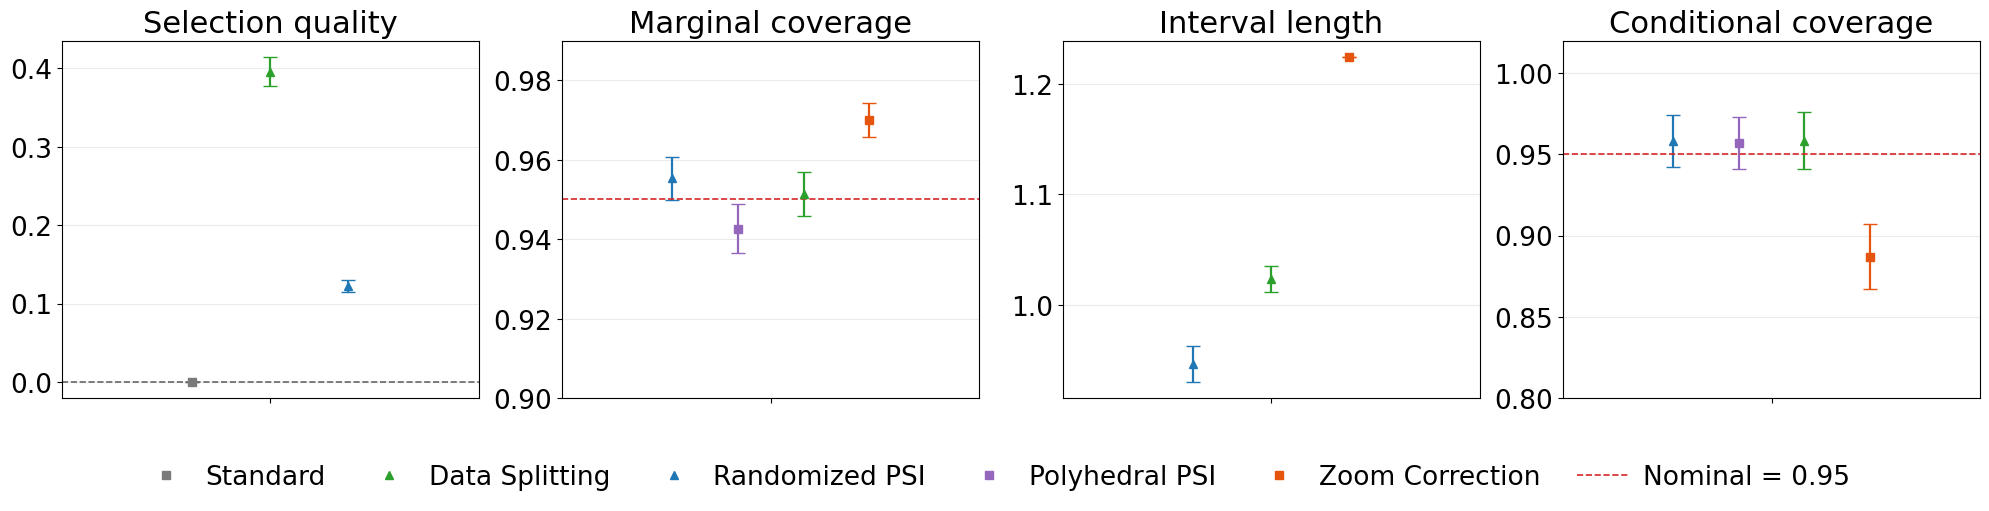

In [30]:
# ============================================================
# 9.1a Gaussian — single-setting 4-panel figure
#   One clear winner (coord 0), a borderline second (coord 1),
#   a high-variance null "decoy" (coord 2, var = 10), a few weak
#   near-competitors, and mildly negative irrelevant coordinates.
# ============================================================
M = 20
mu_g0 = np.zeros(M, dtype=float)
mu_g0[0]    =  0.50      # clear true winner
mu_g0[1]    =  0.25      # borderline second winner
mu_g0[2]    =  0.00      # high-variance decoy (null)
mu_g0[3]    =  0.15
mu_g0[4:8]  =  0.08      # weak near-competitors
mu_g0[8:20] = -0.20      # irrelevant coordinates

variances_g0 = np.ones(M, dtype=float)
variances_g0[2]    = 10.0    # high-variance decoy
variances_g0[8:20] =  2.0    # higher-variance irrelevant coordinates
Sigma_g0 = np.diag(variances_g0)

parameter_settings_gaussian0 = [
    {"setting_id": 0, "label": "High-variance decoy", "mu": mu_g0, "Sigma": Sigma_g0},
]

gaussian_out = simulate_multiple_parameter_settings_compare_hat(
    parameter_settings=parameter_settings_gaussian0,
    n_obs=50, data_type="gaussian", **Gaussian_Setting,
)

four_panel_out = plot_four_panel_selection_inference_summary(
    gaussian_out,
    subset_rank=1,
    layout="1x4",
    epsilon_to_plot=EPSILON,
    hide_xtick_labels=True,
    rotate_xticks=0,
    marginal_coverage_ylim=(0.90, 0.99),
    conditional_coverage_ylim=(0.80, 1.02),
    normalize_regret_by_snoise=True,
    legend_mode="bottom",
)


Gaussian Weak separation: b = -0.0151, gap = 0.085, delta_std = 0.300
Gaussian Strong separation: b = +0.4657, gap = 0.566, delta_std = 2.000

Running parameter setting 1/2
setting_id    = 0
setting_label = Weak separation
data_type     = gaussian
signal_strength = 0.3000001297356339

===== Running naive hat | sigma=known | data_type=gaussian =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
naive rows: 1500

===== Running randomized selective hat | sigma=known | data_type=gaussian =====

=== epsilon = 7.038783541388542 (1/1) ===
Progress: |##################################################| 100% done
randomized eps=7.038783541388542 rows: 1500

===== Running polyhedral hat | sigma=known | data_type=gaussian =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
polyhe

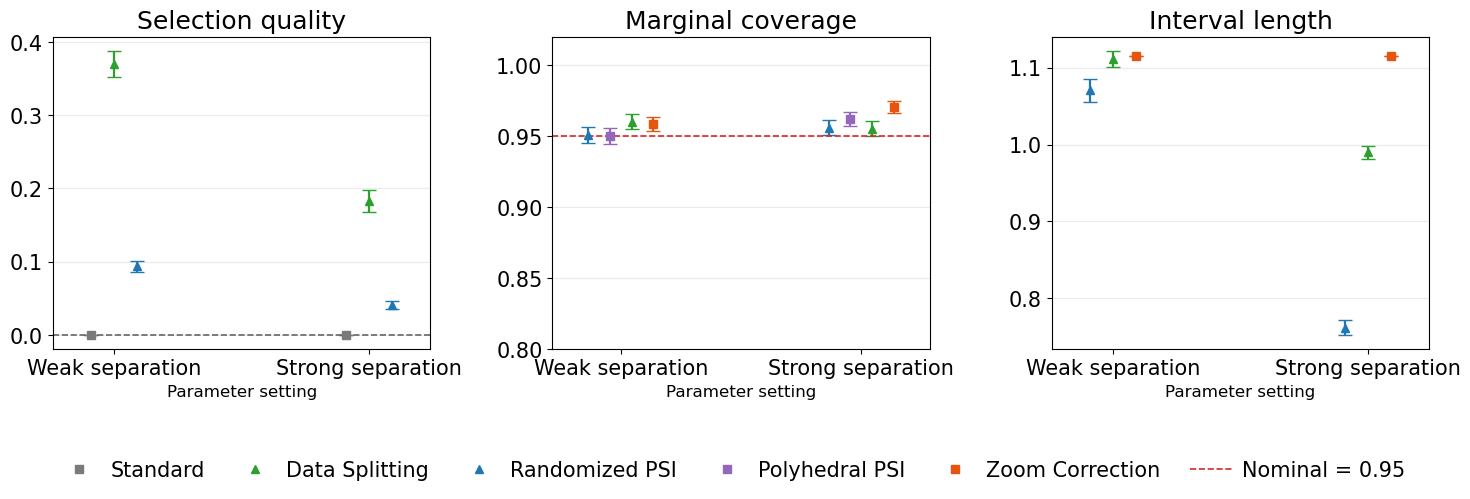

In [31]:
# ============================================================
# 9.1b Gaussian — Low / High signal three-panel
#   mu = z + b * 1{true top-k}: settings differ ONLY in the
#   separation b of the true top-k block {0, 1, 3}.  b is
#   calibrated by bisection so the standardized top-k gap hits
#       Low Signal  : delta_std = 0.3
#       High Signal : delta_std = 2.0
#   exactly, matched to the Binomial and BTD examples below.
#   (Calibrated shifts: b ~ -0.015 for Low, b ~ +0.466 for High.)
# ============================================================
M_g = 20
k = 3
n_obs_gaussian = 50

z_gaussian = np.zeros(M_g, dtype=float)
z_gaussian[0]    =  0.45
z_gaussian[1]    =  0.30
z_gaussian[2]    =  0.00       # high-variance decoy
z_gaussian[3]    =  0.25
z_gaussian[4:8]  =  0.15
z_gaussian[8:20] = -0.20

variances_g = np.ones(M_g, dtype=float)
variances_g[2]   = 10.0        # decoy
variances_g[3:8] =  2.0
Sigma_g = np.diag(variances_g)

top_idx_g = np.argsort(z_gaussian)[::-1][:k]     # true top-k = {0, 1, 3}

def _mu_gaussian(b):
    mu = z_gaussian.copy()
    mu[top_idx_g] += b
    return mu

def _delta_gaussian(b):
    return sampling_se_standardized_gap(
        theta=_mu_gaussian(b), Sigma_hat=Sigma_g / float(n_obs_gaussian), k=k,
    )["delta_std"]

parameter_settings_gaussian = []
for setting_id, (target, signal_label) in enumerate(
    zip(DELTA_STD_TARGETS, SIGNAL_LABELS)
):
    b = calibrate_boundary_shift(_delta_gaussian, target)
    mu_b = _mu_gaussian(b)
    gap_info = sampling_se_standardized_gap(
        theta=mu_b, Sigma_hat=Sigma_g / float(n_obs_gaussian), k=k,
    )
    print(f"Gaussian {signal_label:11s}: b = {b:+.4f}, "
          f"gap = {gap_info['delta_gap']:.3f}, delta_std = {gap_info['delta_std']:.3f}")
    parameter_settings_gaussian.append({
        "setting_id": setting_id,
        "label": signal_label,
        "setting_label": signal_label,
        "boundary_shift": float(b),
        "delta_std": float(gap_info["delta_std"]),
        "delta_gap": float(gap_info["delta_gap"]),
        "mu": mu_b,
        "Sigma": Sigma_g,
    })

gaussian_out = simulate_multiple_parameter_settings_compare_hat(
    parameter_settings=parameter_settings_gaussian,
    n_obs=n_obs_gaussian, data_type="gaussian", **Gaussian_Setting,
)

gaussian_panels = plot_three_panel_selection_inference_summary(
    gaussian_out, epsilon_to_plot=EPSILON, x_axis="setting_label",
    marginal_coverage_ylim=(0.80, 1.02), suptitle="",
)


### 9.2 Binomial / dosage (M=10, k=3)

In [32]:
# ============================================================
# 9.2 Binomial / dosage (M=10, k=3) — shared knobs
#   EPSILON = log(C(10, 3)) = log(120) = 4.79
# ============================================================
EPSILON      = float(np.log(120))           # = 4.79
EPSILON_LIST = [EPSILON]
METHODS      = ["Standard", "Randomized PSI", "Polyhedral PSI",
                "Data Splitting", "Zoom Correction"]
B            = 500
ALPHA        = 0.05
SEED         = 123
GRID_SIZE    = 500
SPAN         = 6.0
K            = 3

Binomial_Setting = dict(
    k=K, B=B, epsilon_list=EPSILON_LIST, methods=METHODS, alpha=ALPHA,
    seed=SEED, grid_size=GRID_SIZE, span=SPAN, verbose=True,
    share_same_data_across_methods=True, sigma="unknown", zoom_sigma_mode="mean", #sigma="unknown"
)


Binomial Weak separation: b = -0.0072, gap = 0.065, delta_std = 0.300, p in [0.279, 0.353]
Binomial Strong separation: b = +0.5055, gap = 0.390, delta_std = 2.000, p in [0.279, 0.476]

Running parameter setting 1/2
setting_id    = 0
setting_label = Weak separation
data_type     = binomial
signal_strength = nan

===== Running naive hat | sigma=unknown | data_type=binomial =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
naive rows: 1500

===== Running randomized selective hat | sigma=unknown | data_type=binomial =====

=== epsilon = 4.787491742782046 (1/1) ===
Progress: |##################################################| 100% done
randomized eps=4.787491742782046 rows: 1500

===== Running polyhedral hat | sigma=unknown | data_type=binomial =====

[polyhedral failure] rep=1
RuntimeError RuntimeError('Could not bracket CI root for j0=3. Observed x=0.340000, trunc=(0.340000, i

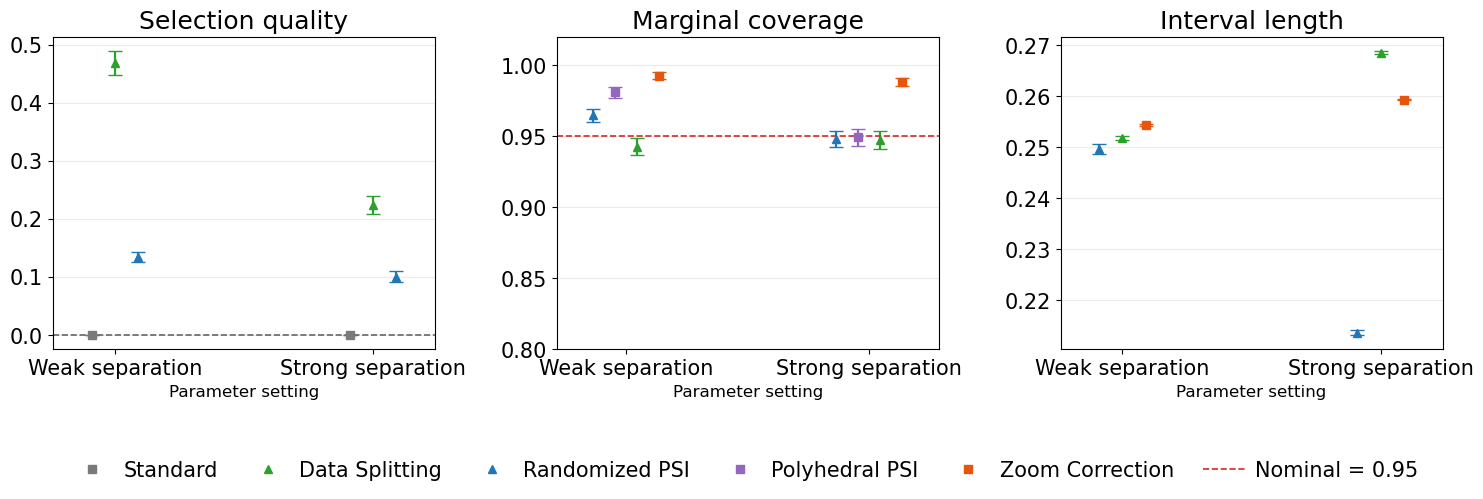

In [33]:
# ============================================================
# 9.2 Binomial / dosage — Low / High signal three-panel
#   Success probabilities p = sigmoid(eta0 + z + b * 1{true top-k}),
#   selection score log(p).  Settings differ ONLY in the top-k block
#   shift b, calibrated so the standardized top-k gap (delta-method
#   SE of log p_hat, Var ~ (1-p)/(m p)) hits
#       Low Signal  : delta_std = 0.3
#       High Signal : delta_std = 2.0
#   exactly, matched to the Gaussian and BTD examples.
#   (Calibrated shifts: b ~ -0.007 for Low, b ~ +0.506 for High;
#    all p stay in [0.28, 0.48], so the Gaussian approximation used
#    by the CI engine remains accurate.)
# ============================================================
M_b = 10
k = 3
m_binom = 100
n_obs_binom = 100
eta0_binom = -1.2
z_binom = np.array([0.60, 0.50, 0.40, 0.30, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25],dtype=float)
#z_binom=np.array([0.65, 0.60, 0.55,0.55, 0.55, 0.55, 0.55,0.55, 0.55, 0.55])

top_idx_b = np.argsort(z_binom)[::-1][:k]        # true top-k = {0, 1, 2}

def _p_binom(b):
    eta = eta0_binom + z_binom.copy()
    eta[top_idx_b] += b
    return sigmoid(eta)

def _delta_binom(b):
    p = _p_binom(b)
    Sigma_logp = np.diag((1.0 - p) / (float(m_binom) * p))    # delta-method
    return sampling_se_standardized_gap(
        theta=np.log(p), Sigma_hat=Sigma_logp, k=k,
    )["delta_std"]

parameter_settings_binom = []
for setting_id, (target, signal_label) in enumerate(
    zip(DELTA_STD_TARGETS, SIGNAL_LABELS)
):
    b = calibrate_boundary_shift(_delta_binom, target)
    p_b = _p_binom(b)
    Sigma_logp = np.diag((1.0 - p_b) / (float(m_binom) * p_b))
    gap_info = sampling_se_standardized_gap(
        theta=np.log(p_b), Sigma_hat=Sigma_logp, k=k,
    )
    print(f"Binomial {signal_label:11s}: b = {b:+.4f}, "
          f"gap = {gap_info['delta_gap']:.3f}, delta_std = {gap_info['delta_std']:.3f}, "
          f"p in [{p_b.min():.3f}, {p_b.max():.3f}]")
    parameter_settings_binom.append({
        "setting_id": setting_id,
        "label": signal_label,
        "setting_label": signal_label,
        "boundary_shift": float(b),
        "delta_std": float(gap_info["delta_std"]),
        "delta_gap": float(gap_info["delta_gap"]),
        "mu": p_b,
        "m": m_binom,
        "statistic": "probability",
        # "covariance": "oracle",
        "covariance": "plugin"
    })

binom_out = simulate_multiple_parameter_settings_compare_hat(
    parameter_settings=parameter_settings_binom,
    n_obs=n_obs_binom, data_type="binomial", **Binomial_Setting,
)

binom_panels = plot_three_panel_selection_inference_summary(
    binom_out, epsilon_to_plot=EPSILON, x_axis="setting_label",
    marginal_coverage_ylim=(0.80, 1.02), suptitle="",
)


### 9.3 Bradley-Terry-Davidson (M=10, k=3)

In [34]:
# ============================================================
# 9.3 Bradley-Terry-Davidson (M=10, k=3) — shared knobs
#   EPSILON = log(C(10, 3)) = log(120) = 4.79
#   GRID_SIZE is larger than the other two examples: the BT log-strength
#   targets are more sensitive to grid resolution (see BTD grid
#   diagnostics in the Debug section).
# ============================================================
EPSILON      = float(np.log(120))           # = 4.79
EPSILON_LIST = [EPSILON]
METHODS      = ["Standard", "Randomized PSI", "Polyhedral PSI",
                "Data Splitting", "Zoom Correction"]
B            = 200
ALPHA        = 0.05
SEED         = 123
GRID_SIZE    = 2000
SPAN         = 6.0
K            = 3

BTD_Setting = dict(
    k=K, B=B, epsilon_list=EPSILON_LIST, methods=METHODS, alpha=ALPHA,
    seed=SEED, grid_size=GRID_SIZE, span=SPAN, verbose=True,
    share_same_data_across_methods=True, sigma="unknown", zoom_sigma_mode="mean",
)


BTD Weak separation: b = -0.0069, gap = 0.093, delta_std = 0.300
BTD Strong separation: b = +0.5376, gap = 0.638, delta_std = 2.000

Running parameter setting 1/2
setting_id    = 0
setting_label = Weak separation
data_type     = bt_davidson
signal_strength = nan

===== Running naive hat | sigma=unknown | data_type=bt_davidson =====
10/200
20/200
30/200
40/200
50/200
60/200
70/200
80/200
90/200
100/200
110/200
120/200
130/200
140/200
150/200
160/200
170/200
180/200
190/200
200/200
naive rows: 600

===== Running randomized selective hat | sigma=unknown | data_type=bt_davidson =====

=== epsilon = 4.787491742782046 (1/1) ===
Progress: |##################################################| 100% done
randomized eps=4.787491742782046 rows: 600

===== Running polyhedral hat | sigma=unknown | data_type=bt_davidson =====
10/200

[polyhedral failure] rep=15
RuntimeError RuntimeError('Could not bracket CI root for j0=9. Observed x=0.123942, trunc=(0.123942, 126.79168803513136).')

[polyhedral failu

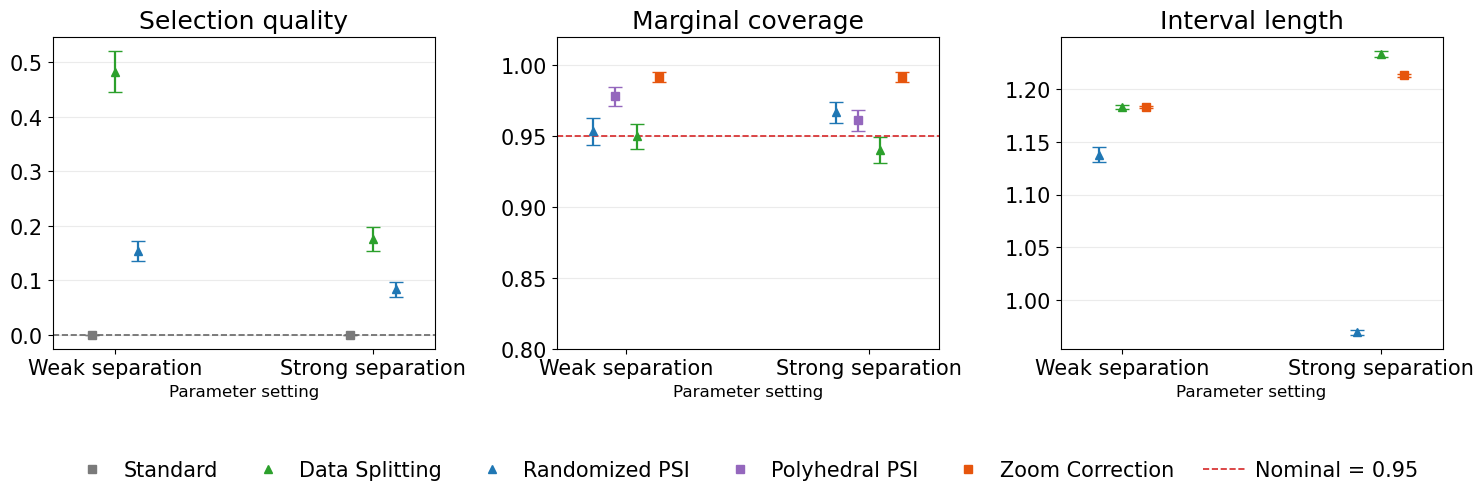

In [35]:
# ============================================================
# 9.3 Bradley-Terry-Davidson — Low / High signal three-panel
#   mu = center(z + b * 1{true top-k}).  nu and n_matches are held
#   FIXED; settings differ ONLY in the top-k block shift b,
#   calibrated against the BTD Fisher-information covariance of
#   mu_hat so the standardized top-k gap hits
#       Low Signal  : delta_std = 0.3   (gap ~ 0.09, selection uncertain)
#       High Signal : delta_std = 2.0   (gap ~ 0.64, selection reliable)
#   exactly, matched to the Gaussian and Binomial examples.
#   Both settings share the same true top-3 set {0, 1, 2}.
#
#   z_bt uses the SAME shape as the Binomial example (separated top-3,
#   bunched tail).  A wide ladder (tail down to -0.9) makes the adaptive
#   randomization scale of the Gumbel top-k mechanism proportional to the
#   cross-sectional score spread, which -- with epsilon = log C(10,3) --
#   costs Randomized PSI more selection accuracy than data splitting's
#   sqrt(2).  Compressing the tail keeps randomized selection strictly
#   better than splitting in BOTH settings
#   (Gaussian-approx MC, P[select true top-3]:
#      Low : full 0.107, randomized 0.091, splitting 0.058
#      High: full 0.877, randomized 0.708, splitting 0.599).
# ============================================================
k = 3
nu_true_bt   = 0.2
n_matches_bt = 10     # keep >= 10: splitting selects on n_matches/2 games per
                      # pair, and the Gaussian approximation behind all CI
                      # methods (incl. Randomized PSI) needs the half-sample
                      # BTD MLE to be stable

def _center(a):
    a = np.asarray(a, dtype=float)
    return a - a.mean()            # BT log-strengths are identified up to a shift

z_bt = np.array([0.60, 0.50, 0.40, 0.30, 0.25, 0.24,0.23, 0.22, 0.21, 0.20], dtype=float)
#z_bt =np.array([0.65, 0.60, 0.55,0.55, 0.55, 0.55, 0.55,0.55, 0.55, 0.55])
M_bt = z_bt.size
top_idx_bt = np.argsort(z_bt)[::-1][:k]          # true top-k = {0, 1, 2}

# Round-robin design: every pair plays n_matches_bt games.
N_bt = n_matches_bt * (np.ones((M_bt, M_bt)) - np.eye(M_bt))

def _mu_bt(b):
    mu = z_bt.copy()
    mu[top_idx_bt] += b
    return _center(mu)

def _delta_bt(b):
    mu = _mu_bt(b)
    Sigma_mu = btd_mu_covariance(N_bt, mu, nu_true_bt)   # Fisher information
    return sampling_se_standardized_gap(theta=mu, Sigma_hat=Sigma_mu, k=k)["delta_std"]

parameter_settings_bt = []
for setting_id, (target, signal_label) in enumerate(
    zip(DELTA_STD_TARGETS, SIGNAL_LABELS)
):
    b = calibrate_boundary_shift(_delta_bt, target)
    mu_b = _mu_bt(b)
    Sigma_mu = btd_mu_covariance(N_bt, mu_b, nu_true_bt)
    gap_info = sampling_se_standardized_gap(theta=mu_b, Sigma_hat=Sigma_mu, k=k)
    print(f"BTD {signal_label:11s}: b = {b:+.4f}, "
          f"gap = {gap_info['delta_gap']:.3f}, delta_std = {gap_info['delta_std']:.3f}")
    parameter_settings_bt.append({
        "setting_id": setting_id,
        "label": signal_label,
        "setting_label": signal_label,
        "boundary_shift": float(b),
        "delta_std": float(gap_info["delta_std"]),
        "delta_gap": float(gap_info["delta_gap"]),
        "mu": mu_b,
        "nu_true": nu_true_bt,
        "n_matches": n_matches_bt,
    })

bt_out = simulate_multiple_parameter_settings_compare_hat(
    parameter_settings=parameter_settings_bt,
    n_obs=n_matches_bt, data_type="bt_davidson", **BTD_Setting,
)

bt_panels = plot_three_panel_selection_inference_summary(
    bt_out, epsilon_to_plot=EPSILON, x_axis="setting_label",
    marginal_coverage_ylim=(0.80, 1.02), suptitle="",
)


### 9.4 Variable Importance

In [36]:
K = 3
z_vi_base = np.array([0.65, 0.60, 0.55,0.55, 0.55, 0.55, 0.55,0.55, 0.55, 0.55])

#z_vi_base =np.array([0.60, 0.50, 0.40, 0.30, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25],dtype=float)
def g_smooth_additive_vi(X):
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    G = np.zeros_like(X, dtype=float)
    for j in range(p):
        x = X[:, j]
        pattern = j % 5
        if pattern == 0:
            G[:, j] = np.sqrt(3.0) * x
        elif pattern == 1:
            G[:, j] = np.sqrt(5.0) * 0.5 * (3.0 * x ** 2 - 1.0)
        elif pattern == 2:
            G[:, j] = np.sqrt(7.0) * 0.5 * (5.0 * x ** 3 - 3.0 * x)
        elif pattern == 3:
            G[:, j] = np.sqrt(2.0) * np.sin(np.pi * x)
        else:
            G[:, j] = np.sqrt(2.0) * np.sin(2.0 * np.pi * x)
    return G


def make_vi_smooth_additive_f(beta):
    beta = np.asarray(beta, dtype=float).copy()
    def f(X):
        G = g_smooth_additive_vi(X)
        return G @ beta
    return f


def make_vi_smooth_additive_m_func(beta):
    beta = np.asarray(beta, dtype=float).copy()
    def m_func(X, cfg=None):
        G = g_smooth_additive_vi(X)
        return G @ beta
    return m_func


def make_vi_smooth_additive_m_minus_func(beta):
    beta = np.asarray(beta, dtype=float).copy()

    def m_minus_func(X, cfg=None):
        X = np.asarray(X, dtype=float)
        G = g_smooth_additive_vi(X)
        m = G @ beta
        n, p = X.shape
        out = np.empty((n, p), dtype=float)
        for j in range(p):
            out[:, j] = m - beta[j] * G[:, j]
        return out
    return m_minus_func


def true_vi_smooth_additive_target(beta, noise_sd=1.0):
    beta = np.asarray(beta, dtype=float)
    raw = beta ** 2
    var_O = float(np.sum(raw) + float(noise_sd) ** 2)
    return raw / var_O


def _I_positive(x):
    return np.where(x > 0.0, 1.0, 0.0)


def make_vi_indicator_f(beta):
    beta = np.asarray(beta, dtype=float).copy()
    def f(X):
        X = np.asarray(X, dtype=float)
        return _I_positive(X) @ beta
    return f


def g_smooth_additive_vi(X):
    X = np.asarray(X, dtype=float)
    n, p = X.shape
    G = np.zeros((n, p), dtype=float)
    for j in range(p):
        x = X[:, j]
        pattern = j % 5
        if pattern == 0:
            G[:, j] = np.sqrt(3.0) * x
        elif pattern == 1:
            G[:, j] = np.sqrt(5.0) * 0.5 * (3.0 * x**2 - 1.0)
        elif pattern == 2:
            G[:, j] = np.sqrt(7.0) * 0.5 * (5.0 * x**3 - 3.0 * x)
        elif pattern == 3:
            G[:, j] = np.sqrt(2.0) * np.sin(np.pi * x)
        elif pattern == 4:
            G[:, j] = np.sqrt(2.0) * np.sin(2.0 * np.pi * x)
    return G


def f_vi_smooth_additive(X, beta=z_vi_base):
    X = np.asarray(X, dtype=float)
    beta = np.asarray(beta, dtype=float).reshape(-1)

    if X.shape[1] != beta.size:
        raise ValueError(
            f"X has p={X.shape[1]} columns, but beta has length {beta.size}."
        )

    G = g_smooth_additive_vi(X)
    return G @ beta


def make_vi_signal_function(beta):
    beta = np.asarray(beta, dtype=float).reshape(-1)

    def f_vi_scaled(X, beta=beta):
        X = np.asarray(X, dtype=float)
        G = g_smooth_additive_vi(X)
        return G @ beta

    return f_vi_scaled


def make_vi_true_m_func(beta):
    beta = np.asarray(beta, dtype=float).reshape(-1).copy()

    def m_func(X):
        X = np.asarray(X, dtype=float)
        G = g_smooth_additive_vi(X)
        return G @ beta

    return m_func


def make_vi_true_m_minus_func(beta):
    beta = np.asarray(beta, dtype=float).reshape(-1).copy()

    def m_minus_func(X):
        X = np.asarray(X, dtype=float)
        G = g_smooth_additive_vi(X)

        # m(X)
        m = G @ beta

        # Column j equals m_{-j}(X_{-j})
        return m[:, None] - G * beta[None, :]

    return m_minus_func


In [37]:
# ============================================================
# Unified Low / High signal calibration
# Same signal-strength definition as Gaussian / Binomial / BTD
# ============================================================

N_OBS_VI = 500
K = 3
P_VI=10
z_vi_base = np.array([0.65, 0.60, 0.55,0.55, 0.55, 0.55, 0.55,0.55, 0.55, 0.55])


#z_vi_base =np.array([0.60, 0.50, 0.40, 0.30, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25],dtype=float)


DELTA_STD_TARGETS = [0.3, 2.0]
SIGNAL_LABELS = ["Low Signal", "High Signal"]
top_idx_vi = np.arange(K)

def _beta_vi(b):
    beta = z_vi_base.copy()
    beta[top_idx_vi] += b
    return beta


def _delta_vi(b):
    beta_s = _beta_vi(b)
    setting = {
        "setting_id": -1,
        "label": "Calibration",
        "setting_label": "Calibration",
        "p": P_VI,
        "f": make_vi_signal_function(beta_s),
        "beta": beta_s,
        "x_dist": "uniform",
        "x_low": -1.0,
        "x_high": 1.0,
        "noise_sd": 1.0,
        "noise_dist": "normal",

        "tree_params": {
            "learner": "spline_gam",
            "learner_params": {
                "n_knots": 8,
                "degree": 3,
                "alpha": 1e-3,
            },
        },

        "vi_statistic": "fixed_nuisance",
        "covariance": "plugin",
    }

    prepared = prepare_variable_importance_holdout_setting(
        setting,
        n_obs=N_OBS_VI,
        holdout_n=50000,
        bootstrap_reps=100,
        bootstrap_n_obs=N_OBS_VI,
        seed=SEED,
        verbose=False,
    )

    gap = sampling_se_standardized_gap(
        theta=np.asarray(prepared["mu"]),
        Sigma_hat=np.asarray(prepared["Sigma"]) / float(N_OBS_VI),
        k=K,
    )

    return gap["delta_std"]
# ------------------------------------------------------------
# Final Low / High settings
# ------------------------------------------------------------

parameter_settings_vi_holdout = []

B_LO_VI = z_vi_base[K] - z_vi_base[K - 1] + 1e-4

for setting_id, (target, signal_label) in enumerate(
    zip(DELTA_STD_TARGETS, SIGNAL_LABELS)
):
    b = calibrate_boundary_shift(
        _delta_vi,
        target,
        lo=B_LO_VI,
        hi=3.0,
    )

    beta_s = _beta_vi(b)

    pilot_delta = _delta_vi(b)

    print(
        f"{signal_label:11s}: "
        f"b={b:+.4f}, "
        f"target={target:.3f}, "
        f"pilot delta_std={pilot_delta:.3f}"
    )

    parameter_settings_vi_holdout.append({
        "setting_id": setting_id,
        "label": signal_label,
        "setting_label": signal_label,

        "boundary_shift": float(b),
        "target_delta_std": float(target),

        "p": P_VI,
        "f": make_vi_signal_function(beta_s),
        "beta": beta_s.copy(),

        "x_dist": "uniform",
        "x_low": -1.0,
        "x_high": 1.0,
        "noise_sd": 1.0,
        "noise_dist": "normal",

        "tree_params": {
            "learner": "spline_gam",
            "learner_params": {
                "n_knots": 8,
                "degree": 3,
                "alpha": 1e-3,
            },
        },

        "holdout_n": 500_000,
        "bootstrap_reps": 500,
        "bootstrap_n_obs": N_OBS_VI,

        "vi_statistic": "fixed_nuisance",
        "covariance": "plugin",
    })

prepared_vi_settings = []

for s, setting_s in enumerate(parameter_settings_vi_holdout):
    prepared_s = prepare_variable_importance_holdout_setting(
        setting_s,
        n_obs=N_OBS_VI,
        holdout_n=setting_s["holdout_n"],
        bootstrap_reps=setting_s["bootstrap_reps"],
        bootstrap_n_obs=setting_s["bootstrap_n_obs"],
        seed=SEED + 10_000 * s,
        verbose=True,
    )
    prepared_setting = dict(prepared_s["setting"])

    final_gap = sampling_se_standardized_gap(
        theta=np.asarray(prepared_s["mu"], dtype=float),
        Sigma_hat=(
            np.asarray(prepared_s["Sigma"], dtype=float)
            / float(N_OBS_VI)
        ),
        k=K,
    )
    prepared_setting.update({
        "label": setting_s["label"],
        "setting_label": setting_s["setting_label"],
        "boundary_shift": float(setting_s["boundary_shift"]),
        "target_delta_std": float(setting_s["target_delta_std"]),
        "delta_std": float(final_gap["delta_std"]),
        "delta_gap": float(final_gap["delta_gap"]),
        "vi_statistic": "fixed_nuisance",
        "covariance": "plugin",
    })
    prepared_vi_settings.append(prepared_setting)




Low Signal : b=+0.0335, target=0.300, pilot delta_std=0.300
High Signal: b=+0.1418, target=2.000, pilot delta_std=2.000

----------------------------------------------------------------------
Fitting fixed VI nuisance functions on holdout dataset
holdout_n = 500000
p = 10
tree_params = {'learner': 'spline_gam', 'learner_params': {'n_knots': 8, 'degree': 3, 'alpha': 0.001}}
----------------------------------------------------------------------


VI holdout bootstrap: 100%|███████████████████| 500/500 [00:11<00:00, 43.74it/s]



----------------------------------------------------------------------
Fitting fixed VI nuisance functions on holdout dataset
holdout_n = 500000
p = 10
tree_params = {'learner': 'spline_gam', 'learner_params': {'n_knots': 8, 'degree': 3, 'alpha': 0.001}}
----------------------------------------------------------------------


VI holdout bootstrap: 100%|███████████████████| 500/500 [00:09<00:00, 51.47it/s]



Running parameter setting 1/2
setting_id    = 0
setting_label = Low Signal
data_type     = variable_importance
signal_strength = 0.5164292611005239

===== Running naive hat | sigma=unknown | data_type=variable_importance =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
naive rows: 1500

===== Running randomized selective hat | sigma=unknown | data_type=variable_importance =====

=== epsilon = 4.787491742782046 (1/1) ===
Progress: |##################################################| 100% done
randomized eps=4.787491742782046 rows: 1500

===== Running polyhedral hat | sigma=unknown | data_type=variable_importance =====
25/500
50/500
75/500
100/500
125/500
150/500
175/500
200/500
225/500
250/500
275/500
300/500
325/500
350/500
375/500
400/500
425/500
450/500
475/500
500/500
polyhedral rows: 1500
polyhedral failures: 0

===== Running data splitting hat | sigma=unknown | data_t

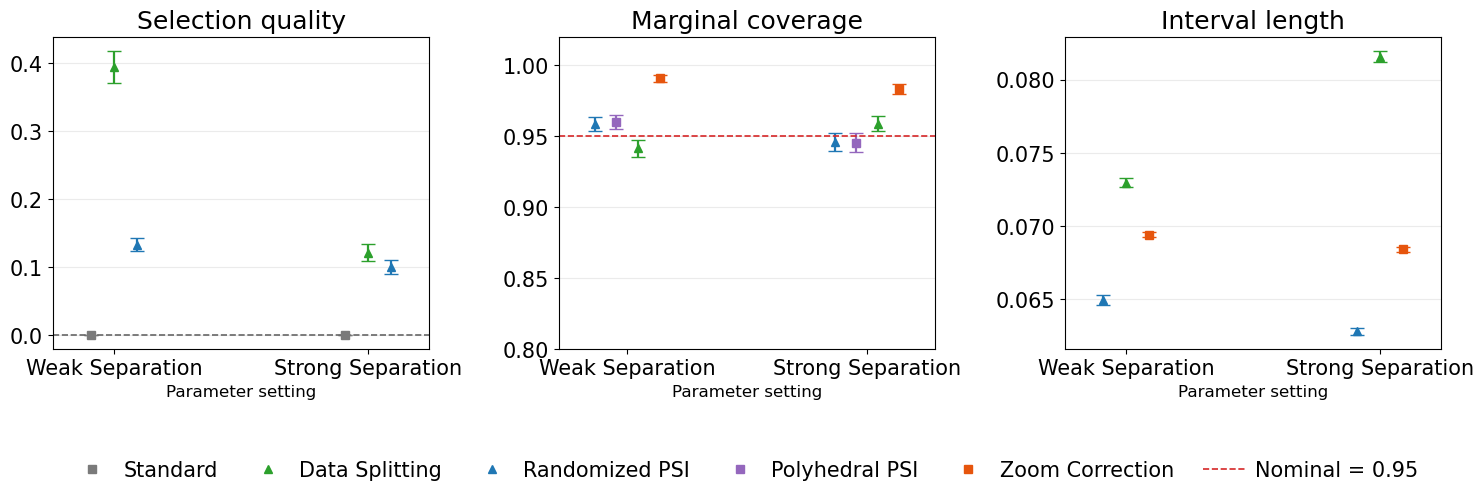

In [38]:
from scipy.special import log_ndtr
P_VI = 10
K = 3

EPSILON = log(comb(P_VI, K))
EPSILON_LIST = [EPSILON]

METHODS = [
    "Standard",
    "Randomized PSI",
    "Data Splitting",
    "Polyhedral PSI",
    "Zoom Correction",
]

B = 500
ALPHA = 0.05
SEED = 123
GRID_SIZE = 500
SPAN = 6.0

VI_Setting = dict(
    k=K,
    B=B,
    epsilon_list=EPSILON_LIST,
    methods=METHODS,
    alpha=ALPHA,
    seed=SEED,
    grid_size=GRID_SIZE,
    span=SPAN,
    verbose=True,
    share_same_data_across_methods=True,
    sigma="unknown",
    zoom_sigma_mode="mean",
)

vi_out_multi_signal = simulate_multiple_parameter_settings_compare_hat(
    parameter_settings=prepared_vi_settings,
    n_obs=N_OBS_VI,
    data_type="variable_importance",
    **VI_Setting,
)


vi_panels = plot_three_panel_selection_inference_summary(
    vi_out_multi_signal,
    epsilon_to_plot=EPSILON,
    x_axis="setting_label",
    marginal_coverage_ylim=(0.8, 1.02),
    suptitle="",
)

